# Step 1 — Load the Final Patient-Level CSV

This step only loads the final patient-level LUAD 301-bp dataset into a DataFrame named `patient_df`.

No validation, no JSON parsing, no preprocessing, no split, and no model training are done in this step.

In [1]:
# Step 1: Load the final patient-level CSV only

from pathlib import Path
import pandas as pd

# Define file path
PATIENT_CSV_PATH = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\data\luad_301bp_patient_level_dataset.csv"
)

# Check file exists
if not PATIENT_CSV_PATH.exists():
    raise FileNotFoundError(f"Patient-level CSV file not found:\n{PATIENT_CSV_PATH}")

# Load CSV
patient_df = pd.read_csv(PATIENT_CSV_PATH, low_memory=False)

# Basic output
print("Patient-level CSV loaded successfully.")
print(f"Shape: {patient_df.shape[0]:,} rows × {patient_df.shape[1]:,} columns")

patient_df.head()

Patient-level CSV loaded successfully.
Shape: 4,998 rows × 172 columns


,COHORT,PATIENT_ID,SAMPLE_ID,CLINICAL_AGE_YEARS,CLINICAL_SEX,CLINICAL_SEX_BINARY,CLINICAL_ACTIVE_SMOKING_STATUS,CLINICAL_ACTIVE_SMOKING_BINARY,CLINICAL_PASSIVE_SMOKING_STATUS,CLINICAL_PASSIVE_SMOKING_BINARY,...,GENE_ZEB1_MUTATED_FLAG,GENE_ZFHX4_MUTATED_FLAG,GENE_ZMYM3_MUTATED_FLAG,GENE_ZNF493_MUTATED_FLAG,GENE_ZNF708_MUTATED_FLAG,GENE_ZNF724_MUTATED_FLAG,HAS_ANY_VALID_MUTATION_FLAG,HAS_HIGH_SEVERITY_MUTATION_FLAG,HAS_FRAMESHIFT_MUTATION_FLAG,MUTATIONS_PER_VALID_GENE
0,LUNG_MSK_2017,P-0000036,P-0000036-T01-IM3,57.0,Female,0.0,Never,0.0,NaN,NaN,...,0,0,0,0,0,0,1,1,0,1.0
1,LUNG_MSK_2017,P-0000110,P-0000110-T01-IM3,66.0,Male,1.0,Ever,1.0,NaN,NaN,...,0,0,0,0,0,0,1,1,1,1.0
2,LUNG_MSK_2017,P-0000133,P-0000133-T01-IM3,79.0,Female,0.0,Never,0.0,NaN,NaN,...,0,0,0,0,0,0,1,0,0,1.0
3,LUNG_MSK_2017,P-0000149,P-0000149-T01-IM3,50.0,Female,0.0,Ever,1.0,NaN,NaN,...,0,0,0,0,0,0,1,0,0,1.0
4,LUNG_MSK_2017,P-0000163,P-0000163-T02-IM3,37.0,Female,0.0,Ever,1.0,NaN,NaN,...,0,0,0,0,0,0,1,0,0,1.0


# Step 2 — Verify Dataset Shape and Required Columns

This step checks that the loaded patient-level dataset has the expected structure.

It verifies:

- `patient_df` exists
- dataset shape is 4,998 rows × 172 columns
- seven approved raw input columns exist
- identifier columns exist
- target-only columns exist
- identifiers and targets are not included in the approved model input list

No JSON parsing, preprocessing, splitting, or model training is done in this step.

In [2]:
# Step 2: Verify dataset shape and required columns

print("=" * 90)
print("STEP 2 — VERIFY DATASET SHAPE AND REQUIRED COLUMNS")
print("=" * 90)

# ============================================================
# 1. Validate that Step 1 has been completed
# ============================================================

if "patient_df" not in globals():
    raise RuntimeError(
        "patient_df was not found. Please run Step 1 first to load the CSV file."
    )

# ============================================================
# 2. Expected dataset shape
# ============================================================

EXPECTED_ROWS = 4998
EXPECTED_COLUMNS = 172

print("Loaded DataFrame:")
print(f"Rows    : {patient_df.shape[0]:,}")
print(f"Columns : {patient_df.shape[1]:,}")

if patient_df.shape != (EXPECTED_ROWS, EXPECTED_COLUMNS):
    raise ValueError(
        f"Unexpected dataset shape.\n"
        f"Expected: {EXPECTED_ROWS:,} rows × {EXPECTED_COLUMNS:,} columns\n"
        f"Found:    {patient_df.shape[0]:,} rows × {patient_df.shape[1]:,} columns"
    )

print("Dataset shape validation PASSED.")

# ============================================================
# 3. Define approved raw input columns
# ============================================================

REQUIRED_INPUT_COLUMNS = [
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
    "CLINICAL_SEX_BINARY",
    "CLINICAL_AGE_YEARS",
    "CLINICAL_ACTIVE_SMOKING_BINARY",
    "CLINICAL_PACK_YEARS",
]

IDENTIFIER_COLUMNS = [
    "COHORT",
    "PATIENT_ID",
    "SAMPLE_ID",
]

TARGET_ONLY_COLUMNS = [
    "TARGET_STAGE_GROUP",
    "TARGET_STAGE_4CLASS",
    "TARGET_STAGE_BINARY",
    "TARGET_STAGE_BINARY_NAME",
    "HAS_STAGE_TARGET_FLAG",
]

# ============================================================
# 4. Check required columns exist
# ============================================================

columns_to_check = (
    REQUIRED_INPUT_COLUMNS
    + IDENTIFIER_COLUMNS
    + TARGET_ONLY_COLUMNS
)

missing_columns = sorted(set(columns_to_check) - set(patient_df.columns))

if missing_columns:
    raise KeyError(
        "The following required columns are missing from patient_df:\n"
        + "\n".join(missing_columns)
    )

print("-" * 90)
print("Required column validation PASSED.")

print("\nApproved raw model input columns:")
for i, col in enumerate(REQUIRED_INPUT_COLUMNS, start=1):
    print(f"{i}. {col}")

if len(REQUIRED_INPUT_COLUMNS) != 7:
    raise ValueError(
        f"Raw model input column count must be 7, but found {len(REQUIRED_INPUT_COLUMNS)}."
    )

# ============================================================
# 5. Confirm identifiers and targets are not model inputs
# ============================================================

identifier_overlap = sorted(set(REQUIRED_INPUT_COLUMNS) & set(IDENTIFIER_COLUMNS))
target_overlap = sorted(set(REQUIRED_INPUT_COLUMNS) & set(TARGET_ONLY_COLUMNS))

if identifier_overlap:
    raise ValueError(
        f"Identifier columns found inside model inputs: {identifier_overlap}"
    )

if target_overlap:
    raise ValueError(
        f"Target-only columns found inside model inputs: {target_overlap}"
    )

print("-" * 90)
print("Feature restriction validation PASSED.")
print("Identifier columns will not be used as model features.")
print("Target-only columns will not be used as model features.")

# ============================================================
# 6. Small column preview
# ============================================================

print("-" * 90)
print("First 20 column names:")
for col in patient_df.columns[:20]:
    print(f"- {col}")

print("=" * 90)
print("STEP 2 COMPLETED SUCCESSFULLY")
print("=" * 90)

print("\nObjects available for next step:")
print("- patient_df")
print("- REQUIRED_INPUT_COLUMNS")
print("- IDENTIFIER_COLUMNS")
print("- TARGET_ONLY_COLUMNS")

STEP 2 — VERIFY DATASET SHAPE AND REQUIRED COLUMNS
Loaded DataFrame:
Rows    : 4,998
Columns : 172
Dataset shape validation PASSED.
------------------------------------------------------------------------------------------
Required column validation PASSED.

Approved raw model input columns:
1. GENE_SYMBOL_LIST
2. MUTATED_WINDOW_301_LIST
3. MUTATED_AFFECTED_MASK_301_LIST
4. CLINICAL_SEX_BINARY
5. CLINICAL_AGE_YEARS
6. CLINICAL_ACTIVE_SMOKING_BINARY
7. CLINICAL_PACK_YEARS
------------------------------------------------------------------------------------------
Feature restriction validation PASSED.
Identifier columns will not be used as model features.
Target-only columns will not be used as model features.
------------------------------------------------------------------------------------------
First 20 column names:
- COHORT
- PATIENT_ID
- SAMPLE_ID
- CLINICAL_AGE_YEARS
- CLINICAL_SEX
- CLINICAL_SEX_BINARY
- CLINICAL_ACTIVE_SMOKING_STATUS
- CLINICAL_ACTIVE_SMOKING_BINARY
- CLINICAL_

# Step 3 — Identify and Restore JSON List Columns

The patient-level CSV stores several variable-length mutation lists as JSON text.

This step will:

- identify JSON/list-valued columns
- confirm that 22 JSON/list columns are present
- convert those JSON strings into Python lists using `json.loads`
- print a short length audit for each list column

No mutation-window validation, preprocessing, splitting, or model training is done in this step.

In [3]:
# Step 3: Identify and restore JSON list columns

import json
import pandas as pd
import numpy as np

print("=" * 90)
print("STEP 3 — IDENTIFY AND RESTORE JSON LIST COLUMNS")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

if "patient_df" not in globals():
    raise RuntimeError("patient_df was not found. Please run Step 1 first.")

EXPECTED_JSON_LIST_COLUMNS = 22

# ============================================================
# 2. Helper function to detect JSON list strings
# ============================================================

def looks_like_json_list(value):
    """Return True if a value appears to be a JSON list string."""
    if isinstance(value, list):
        return True
    
    if pd.isna(value):
        return False
    
    if not isinstance(value, str):
        return False
    
    text = value.strip()
    return text.startswith("[") and text.endswith("]")

# ============================================================
# 3. Identify JSON/list-valued columns
# ============================================================

json_list_columns = []

for col in patient_df.columns:
    non_missing_values = patient_df[col].dropna()
    
    if non_missing_values.empty:
        continue
    
    sample_values = non_missing_values.head(10)
    
    if col.endswith("_LIST") or any(looks_like_json_list(v) for v in sample_values):
        json_list_columns.append(col)

json_list_columns = sorted(json_list_columns)

print(f"Identified JSON/list-valued columns: {len(json_list_columns)}")

for i, col in enumerate(json_list_columns, start=1):
    print(f"{i:02d}. {col}")

if len(json_list_columns) != EXPECTED_JSON_LIST_COLUMNS:
    raise ValueError(
        f"Unexpected number of JSON/list-valued columns.\n"
        f"Expected: {EXPECTED_JSON_LIST_COLUMNS}\n"
        f"Found:    {len(json_list_columns)}"
    )

print("-" * 90)
print("JSON/list column identification PASSED.")

# ============================================================
# 4. Restore JSON strings into Python lists
# ============================================================

def parse_json_list_cell(value, column_name, row_index):
    """
    Convert one JSON-list cell into a Python list.
    Existing lists are returned unchanged, so this cell is rerunnable.
    Missing or blank cells are converted to [].
    """
    if isinstance(value, list):
        return value
    
    if pd.isna(value):
        return []
    
    if not isinstance(value, str):
        raise TypeError(
            f"Invalid value type in JSON column '{column_name}' at row {row_index}: {type(value)}"
        )
    
    text = value.strip()
    
    if text == "":
        return []
    
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError as e:
        raise ValueError(
            f"JSON parsing failed.\n"
            f"Column: {column_name}\n"
            f"Row index: {row_index}\n"
            f"Value preview: {text[:200]}\n"
            f"Error: {e}"
        )
    
    if not isinstance(parsed, list):
        raise TypeError(
            f"Parsed JSON value is not a list.\n"
            f"Column: {column_name}\n"
            f"Row index: {row_index}"
        )
    
    return parsed

for col in json_list_columns:
    patient_df[col] = [
        parse_json_list_cell(value, col, row_index)
        for row_index, value in patient_df[col].items()
    ]

print("JSON restoration PASSED using json.loads().")

# ============================================================
# 5. Confirm restored columns contain Python lists
# ============================================================

non_list_errors = []

for col in json_list_columns:
    non_list_count = int((~patient_df[col].apply(lambda x: isinstance(x, list))).sum())
    
    if non_list_count > 0:
        non_list_errors.append((col, non_list_count))

if non_list_errors:
    print("Columns with non-list values after parsing:")
    for col, count in non_list_errors:
        print(f"{col}: {count}")
    
    raise TypeError("Some JSON columns were not restored correctly.")

print("-" * 90)
print("All JSON/list columns are now Python lists.")

# ============================================================
# 6. Short length audit
# ============================================================

json_length_summary = []

for col in json_list_columns:
    lengths = patient_df[col].apply(len)
    
    json_length_summary.append({
        "column": col,
        "min_len": int(lengths.min()),
        "median_len": float(lengths.median()),
        "max_len": int(lengths.max()),
        "total_entries": int(lengths.sum()),
    })

json_length_summary_df = pd.DataFrame(json_length_summary)

print("-" * 90)
print("JSON/list column length audit:")
display(json_length_summary_df)

print("=" * 90)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 90)

print("\nObjects available for next step:")
print("- patient_df")
print("- json_list_columns")
print("- json_length_summary_df")

STEP 3 — IDENTIFY AND RESTORE JSON LIST COLUMNS
Identified JSON/list-valued columns: 22
01. ALTERNATE_INSERTED_SEQUENCE_LIST
02. CDS_END_1BASED_LIST
03. CDS_START_1BASED_LIST
04. FRAME_SHIFT_FLAG_LIST
05. GENE_SYMBOL_LIST
06. HGVSC_LIST
07. HGVS_OPERATION_LIST
08. IN_FRAME_LENGTH_CHANGE_FLAG_LIST
09. MUTATED_AFFECTED_MASK_301_LIST
10. MUTATED_AFFECTED_POSITION_COUNT_LIST
11. MUTATED_WINDOW_301_LIST
12. MUTATION_LENGTH_EFFECT_LIST
13. MUTATION_ROW_ID_LIST
14. MUTATION_SEVERITY_LIST
15. MUTATION_SEVERITY_SCORE_LIST
16. REFERENCE_AFFECTED_MASK_301_LIST
17. REFERENCE_AFFECTED_POSITION_COUNT_LIST
18. REFERENCE_REMOVED_SEQUENCE_LIST
19. REFERENCE_WINDOW_301_LIST
20. TRANSCRIPT_ID_LIST
21. UNIQUE_VALID_GENE_SYMBOL_LIST
22. VARIANT_CLASSIFICATION_LIST
------------------------------------------------------------------------------------------
JSON/list column identification PASSED.
JSON restoration PASSED using json.loads().
-----------------------------------------------------------------------

,column,min_len,median_len,max_len,total_entries
0,ALTERNATE_INSERTED_SEQUENCE_LIST,0,3.0,39,17987
1,CDS_END_1BASED_LIST,0,3.0,39,17987
2,CDS_START_1BASED_LIST,0,3.0,39,17987
3,FRAME_SHIFT_FLAG_LIST,0,3.0,39,17987
4,GENE_SYMBOL_LIST,0,3.0,39,17987
5,HGVSC_LIST,0,3.0,39,17987
6,HGVS_OPERATION_LIST,0,3.0,39,17987
7,IN_FRAME_LENGTH_CHANGE_FLAG_LIST,0,3.0,39,17987
8,MUTATED_AFFECTED_MASK_301_LIST,0,3.0,39,17987
9,MUTATED_AFFECTED_POSITION_COUNT_LIST,0,3.0,39,17987


STEP 3 COMPLETED SUCCESSFULLY

Objects available for next step:
- patient_df
- json_list_columns
- json_length_summary_df


# Step 4 — Validate Mutation-Level Lists, 301-bp Windows, and Masks

This step validates the restored mutation-level list columns.

It checks:

- mutation-level list columns are aligned for each patient
- total mutation entries equal 17,987
- each mutated DNA window is exactly 301 bp
- each mutated DNA window contains only A, C, G, T, or N
- each affected mask is exactly length 301
- each affected mask contains only binary values

No preprocessing, splitting, or model training is done in this step.
No file is saved in this step.

In [4]:
# Step 4: Validate mutation-level aligned lists, 301-bp windows, and affected masks

import pandas as pd
import numpy as np

print("=" * 90)
print("STEP 4 — VALIDATE MUTATION-LEVEL LISTS, WINDOWS, AND MASKS")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

if "patient_df" not in globals():
    raise RuntimeError("patient_df was not found. Please run Step 1 first.")

if "json_list_columns" not in globals():
    raise RuntimeError("json_list_columns was not found. Please run Step 3 first.")

EXPECTED_TOTAL_MUTATION_ENTRIES = 17987
EXPECTED_WINDOW_LENGTH = 301

# True mutation-level aligned columns.
# These columns should have equal length inside each patient row.
MUTATION_ALIGNED_LIST_COLUMNS = [
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
    "REFERENCE_WINDOW_301_LIST",
    "REFERENCE_AFFECTED_MASK_301_LIST",
    "MUTATION_ROW_ID_LIST",
    "TRANSCRIPT_ID_LIST",
    "HGVSC_LIST",
    "HGVS_OPERATION_LIST",
    "MUTATION_SEVERITY_LIST",
    "MUTATION_SEVERITY_SCORE_LIST",
]

missing_columns = sorted(set(MUTATION_ALIGNED_LIST_COLUMNS) - set(patient_df.columns))

if missing_columns:
    raise KeyError(
        "Missing mutation-level aligned columns:\n"
        + "\n".join(missing_columns)
    )

print("Required mutation-level columns are present.")

# ============================================================
# 2. Confirm mutation-level columns are Python lists
# ============================================================

non_list_errors = []

for col in MUTATION_ALIGNED_LIST_COLUMNS:
    non_list_count = int((~patient_df[col].apply(lambda x: isinstance(x, list))).sum())
    
    if non_list_count > 0:
        non_list_errors.append((col, non_list_count))

if non_list_errors:
    print("Columns with non-list values:")
    for col, count in non_list_errors:
        print(f"{col}: {count}")
    
    raise TypeError(
        "Some mutation-level columns are not Python lists. "
        "Please rerun Step 3 before Step 4."
    )

print("Mutation-level list type validation PASSED.")

# ============================================================
# 3. Validate aligned list lengths per patient
# ============================================================

alignment_errors = []

for row_index, row in patient_df.iterrows():
    lengths = {
        col: len(row[col])
        for col in MUTATION_ALIGNED_LIST_COLUMNS
    }
    
    if len(set(lengths.values())) != 1:
        alignment_errors.append((row_index, lengths))
        
        if len(alignment_errors) >= 5:
            break

if alignment_errors:
    print("-" * 90)
    print("First mutation-level alignment errors:")
    
    for row_index, lengths in alignment_errors:
        print(f"\nRow index: {row_index}")
        print(lengths)
    
    raise ValueError(
        "Mutation-level aligned list validation FAILED. "
        "At least one patient has different list lengths across mutation-level columns."
    )

print("Mutation-level aligned list validation PASSED.")

# ============================================================
# 4. Count total mutation entries
# ============================================================

patient_df["N_VALID_MUTATIONS_CHECK"] = patient_df["GENE_SYMBOL_LIST"].apply(len)

total_mutation_entries = int(patient_df["N_VALID_MUTATIONS_CHECK"].sum())
patients_with_valid_mutations = int((patient_df["N_VALID_MUTATIONS_CHECK"] > 0).sum())
patients_with_empty_mutations = int((patient_df["N_VALID_MUTATIONS_CHECK"] == 0).sum())
max_mutations_one_patient = int(patient_df["N_VALID_MUTATIONS_CHECK"].max())

print("-" * 90)
print("Mutation count audit:")
print(f"Total mutation-list entries       : {total_mutation_entries:,}")
print(f"Patients with valid mutations     : {patients_with_valid_mutations:,}")
print(f"Patients with empty mutation list : {patients_with_empty_mutations:,}")
print(f"Maximum mutations in one patient  : {max_mutations_one_patient:,}")

if total_mutation_entries != EXPECTED_TOTAL_MUTATION_ENTRIES:
    raise ValueError(
        f"Unexpected total mutation-list entries.\n"
        f"Expected: {EXPECTED_TOTAL_MUTATION_ENTRIES:,}\n"
        f"Found:    {total_mutation_entries:,}"
    )

print("Total mutation entry validation PASSED.")

# ============================================================
# 5. Validate mutated 301-bp DNA windows
# ============================================================

valid_dna_characters = set("ACGTN")
window_errors = []

for row_index, windows in patient_df["MUTATED_WINDOW_301_LIST"].items():
    for mutation_index, sequence in enumerate(windows):
        
        if not isinstance(sequence, str):
            window_errors.append((row_index, mutation_index, "not_string", type(sequence)))
        
        elif len(sequence) != EXPECTED_WINDOW_LENGTH:
            window_errors.append((row_index, mutation_index, "bad_length", len(sequence)))
        
        elif not set(sequence.upper()).issubset(valid_dna_characters):
            bad_characters = sorted(set(sequence.upper()) - valid_dna_characters)
            window_errors.append((row_index, mutation_index, "bad_characters", bad_characters))
        
        if len(window_errors) >= 5:
            break
    
    if len(window_errors) >= 5:
        break

if window_errors:
    print("-" * 90)
    print("First mutated-window validation errors:")
    
    for error in window_errors:
        print(error)
    
    raise ValueError(
        "Mutated 301-bp window validation FAILED. "
        "Every mutated window must be a DNA string of length 301."
    )

print("-" * 90)
print("Mutated 301-bp window validation PASSED.")

# ============================================================
# 6. Validate mutated affected masks
# ============================================================

mask_errors = []

def get_mask_length(mask_value):
    if isinstance(mask_value, str):
        return len(mask_value)
    if isinstance(mask_value, list):
        return len(mask_value)
    return None

def mask_is_binary(mask_value):
    if isinstance(mask_value, str):
        return set(mask_value).issubset({"0", "1"})
    
    if isinstance(mask_value, list):
        return all(str(v) in {"0", "1"} for v in mask_value)
    
    return False

for row_index, masks in patient_df["MUTATED_AFFECTED_MASK_301_LIST"].items():
    for mutation_index, mask in enumerate(masks):
        
        current_mask_length = get_mask_length(mask)
        
        if current_mask_length != EXPECTED_WINDOW_LENGTH:
            mask_errors.append((row_index, mutation_index, "bad_length", current_mask_length))
        
        elif not mask_is_binary(mask):
            mask_errors.append((row_index, mutation_index, "non_binary_mask", type(mask)))
        
        if len(mask_errors) >= 5:
            break
    
    if len(mask_errors) >= 5:
        break

if mask_errors:
    print("-" * 90)
    print("First affected-mask validation errors:")
    
    for error in mask_errors:
        print(error)
    
    raise ValueError(
        "Mutated affected-mask validation FAILED. "
        "Every affected mask must have length 301 and binary values."
    )

print("Mutated affected-mask validation PASSED.")

# ============================================================
# 7. Final Step 4 summary
# ============================================================

print("=" * 90)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Mutation-level aligned lists validated.")
print("Mutated 301-bp windows validated.")
print("Mutated affected masks validated.")
print("No preprocessing fitted.")
print("No split created.")
print("No model trained.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for next step:")
print("- patient_df")
print("- MUTATION_ALIGNED_LIST_COLUMNS")
print("- N_VALID_MUTATIONS_CHECK column inside patient_df")

STEP 4 — VALIDATE MUTATION-LEVEL LISTS, WINDOWS, AND MASKS
Required mutation-level columns are present.
Mutation-level list type validation PASSED.
Mutation-level aligned list validation PASSED.
------------------------------------------------------------------------------------------
Mutation count audit:
Total mutation-list entries       : 17,987
Patients with valid mutations     : 4,881
Patients with empty mutation list : 117
Maximum mutations in one patient  : 39
Total mutation entry validation PASSED.
------------------------------------------------------------------------------------------
Mutated 301-bp window validation PASSED.
Mutated affected-mask validation PASSED.
STEP 4 COMPLETED SUCCESSFULLY
Mutation-level aligned lists validated.
Mutated 301-bp windows validated.
Mutated affected masks validated.
No preprocessing fitted.
No split created.
No model trained.
No file saved.

Objects available for next step:
- patient_df
- MUTATION_ALIGNED_LIST_COLUMNS
- N_VALID_MUTATIONS_CH

# Step 5 — Select Labelled Patients and Audit Empty Mutation Lists

This step selects patients with available stage targets for supervised model training.

It will:

- create `PATIENT_GROUP_KEY` using `COHORT + PATIENT_ID`
- verify there are no duplicate patient grouping keys
- select labelled patients using `HAS_STAGE_TARGET_FLAG == 1`
- verify there are 3,558 labelled patients
- print binary target distribution
- print four-class target distribution
- audit labelled patients with valid mutation lists
- audit labelled patients with empty mutation lists
- print target distributions for both groups

No empty-mutation handling decision is made in this step.  
No train/validation/test split is created in this step.  
No preprocessing or model training is done in this step.

In [5]:
# Step 5: Select labelled patients and audit empty mutation lists

import pandas as pd
import numpy as np

print("=" * 90)
print("STEP 5 — SELECT LABELLED PATIENTS AND AUDIT EMPTY MUTATION LISTS")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

if "patient_df" not in globals():
    raise RuntimeError("patient_df was not found. Please run Step 1 first.")

if "N_VALID_MUTATIONS_CHECK" not in patient_df.columns:
    raise RuntimeError(
        "N_VALID_MUTATIONS_CHECK was not found in patient_df. "
        "Please run Step 4 before Step 5."
    )

required_columns = [
    "COHORT",
    "PATIENT_ID",
    "SAMPLE_ID",
    "HAS_STAGE_TARGET_FLAG",
    "TARGET_STAGE_BINARY",
    "TARGET_STAGE_4CLASS",
    "TARGET_STAGE_GROUP",
    "TARGET_STAGE_BINARY_NAME",
    "N_VALID_MUTATIONS_CHECK",
]

missing_columns = sorted(set(required_columns) - set(patient_df.columns))

if missing_columns:
    raise KeyError(
        "The following required columns are missing:\n"
        + "\n".join(missing_columns)
    )

print("Required object and column validation PASSED.")

# ============================================================
# 2. Create patient grouping key
# ============================================================

patient_df["PATIENT_GROUP_KEY"] = (
    patient_df["COHORT"].astype(str).str.strip()
    + "__"
    + patient_df["PATIENT_ID"].astype(str).str.strip()
)

duplicate_group_key_count = int(patient_df["PATIENT_GROUP_KEY"].duplicated().sum())

print("-" * 90)
print("Patient grouping-key audit:")
print(f"Total patient rows             : {len(patient_df):,}")
print(f"Unique patient grouping keys   : {patient_df['PATIENT_GROUP_KEY'].nunique():,}")
print(f"Duplicate patient grouping keys: {duplicate_group_key_count:,}")

if duplicate_group_key_count != 0:
    duplicate_examples = (
        patient_df.loc[
            patient_df["PATIENT_GROUP_KEY"].duplicated(keep=False),
            ["COHORT", "PATIENT_ID", "SAMPLE_ID", "PATIENT_GROUP_KEY"]
        ]
        .head(10)
    )
    
    print("\nDuplicate grouping-key examples:")
    display(duplicate_examples)
    
    raise ValueError(
        "Duplicate COHORT + PATIENT_ID grouping keys were found. "
        "Splitting cannot continue until this is resolved."
    )

print("Patient grouping-key validation PASSED.")

# ============================================================
# 3. Convert stage target columns safely
# ============================================================

patient_df["HAS_STAGE_TARGET_FLAG"] = pd.to_numeric(
    patient_df["HAS_STAGE_TARGET_FLAG"],
    errors="raise"
).astype(int)

patient_df["TARGET_STAGE_BINARY"] = pd.to_numeric(
    patient_df["TARGET_STAGE_BINARY"],
    errors="coerce"
)

patient_df["TARGET_STAGE_4CLASS"] = pd.to_numeric(
    patient_df["TARGET_STAGE_4CLASS"],
    errors="coerce"
)

# ============================================================
# 4. Select labelled and unlabelled patients
# ============================================================

EXPECTED_LABELLED_PATIENTS = 3558
EXPECTED_UNLABELLED_PATIENTS = 1440
EXPECTED_EMPTY_LABELLED_PATIENTS = 99

labelled_df = patient_df[patient_df["HAS_STAGE_TARGET_FLAG"] == 1].copy()
unlabelled_df = patient_df[patient_df["HAS_STAGE_TARGET_FLAG"] == 0].copy()

print("-" * 90)
print("Stage target availability audit:")
print(f"Labelled patients   : {len(labelled_df):,}")
print(f"Unlabelled patients : {len(unlabelled_df):,}")

if len(labelled_df) != EXPECTED_LABELLED_PATIENTS:
    raise ValueError(
        f"Unexpected labelled patient count.\n"
        f"Expected: {EXPECTED_LABELLED_PATIENTS:,}\n"
        f"Found:    {len(labelled_df):,}"
    )

if len(unlabelled_df) != EXPECTED_UNLABELLED_PATIENTS:
    raise ValueError(
        f"Unexpected unlabelled patient count.\n"
        f"Expected: {EXPECTED_UNLABELLED_PATIENTS:,}\n"
        f"Found:    {len(unlabelled_df):,}"
    )

# Labelled rows must have complete target values.
for target_col in ["TARGET_STAGE_BINARY", "TARGET_STAGE_4CLASS"]:
    missing_count = int(labelled_df[target_col].isna().sum())
    
    if missing_count != 0:
        raise ValueError(
            f"Labelled patients contain missing values in {target_col}: {missing_count}"
        )

labelled_df["TARGET_STAGE_BINARY"] = labelled_df["TARGET_STAGE_BINARY"].astype(int)
labelled_df["TARGET_STAGE_4CLASS"] = labelled_df["TARGET_STAGE_4CLASS"].astype(int)

print("Labelled patient selection validation PASSED.")

# ============================================================
# 5. Print target distributions
# ============================================================

binary_distribution = labelled_df["TARGET_STAGE_BINARY"].value_counts().sort_index()
four_class_distribution = labelled_df["TARGET_STAGE_4CLASS"].value_counts().sort_index()

print("-" * 90)
print("Binary target distribution among labelled patients:")
print("0 = Early, Stage I-II")
print("1 = Advanced, Stage III-IV")
print(binary_distribution.to_string())

print("\nFour-class target distribution among labelled patients:")
print("0 = Stage I")
print("1 = Stage II")
print("2 = Stage III")
print("3 = Stage IV")
print(four_class_distribution.to_string())

if set(binary_distribution.index.tolist()) != {0, 1}:
    raise ValueError(
        f"Unexpected binary target labels found: {binary_distribution.index.tolist()}"
    )

if set(four_class_distribution.index.tolist()) != {0, 1, 2, 3}:
    raise ValueError(
        f"Unexpected four-class target labels found: {four_class_distribution.index.tolist()}"
    )

# ============================================================
# 6. Audit labelled patients with valid and empty mutation lists
# ============================================================

labelled_valid_mutation_df = labelled_df[
    labelled_df["N_VALID_MUTATIONS_CHECK"] > 0
].copy()

labelled_empty_mutation_df = labelled_df[
    labelled_df["N_VALID_MUTATIONS_CHECK"] == 0
].copy()

print("-" * 90)
print("Labelled patient mutation-list audit:")
print(f"Labelled patients with valid mutation lists : {len(labelled_valid_mutation_df):,}")
print(f"Labelled patients with empty mutation lists : {len(labelled_empty_mutation_df):,}")

if len(labelled_empty_mutation_df) != EXPECTED_EMPTY_LABELLED_PATIENTS:
    raise ValueError(
        f"Unexpected labelled empty-mutation patient count.\n"
        f"Expected: {EXPECTED_EMPTY_LABELLED_PATIENTS:,}\n"
        f"Found:    {len(labelled_empty_mutation_df):,}"
    )

print("\nBinary distribution among labelled patients WITH valid mutation lists:")
print(labelled_valid_mutation_df["TARGET_STAGE_BINARY"].value_counts().sort_index().to_string())

print("\nBinary distribution among labelled patients WITH empty mutation lists:")
print(labelled_empty_mutation_df["TARGET_STAGE_BINARY"].value_counts().sort_index().to_string())

print("\nFour-class distribution among labelled patients WITH valid mutation lists:")
print(labelled_valid_mutation_df["TARGET_STAGE_4CLASS"].value_counts().sort_index().to_string())

print("\nFour-class distribution among labelled patients WITH empty mutation lists:")
print(labelled_empty_mutation_df["TARGET_STAGE_4CLASS"].value_counts().sort_index().to_string())

# ============================================================
# 7. Final Step 5 summary
# ============================================================

print("=" * 90)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Labelled patients selected and audited.")
print("Empty-mutation labelled patients were audited only.")
print("No empty-mutation handling decision was applied.")
print("No split created.")
print("No preprocessing fitted.")
print("No model trained.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for next step:")
print("- patient_df")
print("- labelled_df")
print("- unlabelled_df")
print("- labelled_valid_mutation_df")
print("- labelled_empty_mutation_df")
print("- PATIENT_GROUP_KEY column inside patient_df and labelled_df")

STEP 5 — SELECT LABELLED PATIENTS AND AUDIT EMPTY MUTATION LISTS
Required object and column validation PASSED.
------------------------------------------------------------------------------------------
Patient grouping-key audit:
Total patient rows             : 4,998
Unique patient grouping keys   : 4,998
Duplicate patient grouping keys: 0
Patient grouping-key validation PASSED.
------------------------------------------------------------------------------------------
Stage target availability audit:
Labelled patients   : 3,558
Unlabelled patients : 1,440
Labelled patient selection validation PASSED.
------------------------------------------------------------------------------------------
Binary target distribution among labelled patients:
0 = Early, Stage I-II
1 = Advanced, Stage III-IV
TARGET_STAGE_BINARY
0    2092
1    1466

Four-class target distribution among labelled patients:
0 = Stage I
1 = Stage II
2 = Stage III
3 = Stage IV
TARGET_STAGE_4CLASS
0    1627
1     465
2     590


In [7]:
print("Full dataset smoking missing:",
      patient_df["CLINICAL_ACTIVE_SMOKING_BINARY"].isna().sum())

print("Labelled patients smoking missing:",
      labelled_df["CLINICAL_ACTIVE_SMOKING_BINARY"].isna().sum())

print("Unlabelled patients smoking missing:",
      unlabelled_df["CLINICAL_ACTIVE_SMOKING_BINARY"].isna().sum())

Full dataset smoking missing: 95
Labelled patients smoking missing: 0
Unlabelled patients smoking missing: 95


# Step 6 — Apply Documented Empty-Mutation Handling

Step 5 showed that 99 labelled patients have empty valid-mutation lists.

For supervised model training, all 3,558 labelled patients will be retained.

Handling method:

- Patients with valid mutation lists keep their original mutation data.
- Patients with empty mutation lists receive one explicit placeholder mutation.
- Placeholder gene token: `NO_MUTATION`
- Placeholder mutated DNA window: 301 `N` characters
- Placeholder affected mask: 301 zeros

This creates a training-ready labelled DataFrame named `supervised_df`.

This step does not create a train/validation/test split.  
This step does not fit preprocessing.  
This step does not train a model.  
This step does not save any file.

In [8]:
# Step 6: Apply documented empty-mutation handling for labelled patients

import pandas as pd
import numpy as np

print("=" * 90)
print("STEP 6 — APPLY DOCUMENTED EMPTY-MUTATION HANDLING")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

required_objects = [
    "patient_df",
    "labelled_df",
    "labelled_empty_mutation_df",
    "REQUIRED_INPUT_COLUMNS",
    "IDENTIFIER_COLUMNS",
    "TARGET_ONLY_COLUMNS",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Required objects are missing. Please rerun previous steps.\n"
        + "\n".join(missing_objects)
    )

required_columns = [
    "PATIENT_GROUP_KEY",
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
    "N_VALID_MUTATIONS_CHECK",
    "TARGET_STAGE_BINARY",
    "TARGET_STAGE_4CLASS",
]

missing_columns = sorted(set(required_columns) - set(labelled_df.columns))

if missing_columns:
    raise KeyError(
        "The following required columns are missing from labelled_df:\n"
        + "\n".join(missing_columns)
    )

print("Required object and column validation PASSED.")

# ============================================================
# 2. Define NO_MUTATION placeholder
# ============================================================

NO_MUTATION_GENE_TOKEN = "NO_MUTATION"
NO_MUTATION_DNA_WINDOW_301 = "N" * 301
NO_MUTATION_AFFECTED_MASK_301 = "0" * 301

EXPECTED_LABELLED_PATIENTS = 3558
EXPECTED_EMPTY_LABELLED_PATIENTS = 99
EXPECTED_WINDOW_LENGTH = 301

if len(NO_MUTATION_DNA_WINDOW_301) != EXPECTED_WINDOW_LENGTH:
    raise ValueError("NO_MUTATION DNA window must be exactly 301 characters.")

if len(NO_MUTATION_AFFECTED_MASK_301) != EXPECTED_WINDOW_LENGTH:
    raise ValueError("NO_MUTATION affected mask must be exactly 301 characters.")

print("-" * 90)
print("NO_MUTATION placeholder configuration:")
print(f"Gene token        : {NO_MUTATION_GENE_TOKEN}")
print(f"DNA window length : {len(NO_MUTATION_DNA_WINDOW_301)}")
print(f"Mask length       : {len(NO_MUTATION_AFFECTED_MASK_301)}")

# ============================================================
# 3. Create supervised_df from labelled patients only
# ============================================================

supervised_df = labelled_df.copy()

if len(supervised_df) != EXPECTED_LABELLED_PATIENTS:
    raise ValueError(
        f"Unexpected supervised patient count.\n"
        f"Expected: {EXPECTED_LABELLED_PATIENTS:,}\n"
        f"Found:    {len(supervised_df):,}"
    )

# Preserve original mutation-list status for audit only.
# This column is not a model feature.
supervised_df["ORIGINAL_N_VALID_MUTATIONS"] = supervised_df["N_VALID_MUTATIONS_CHECK"].astype(int)
supervised_df["ORIGINAL_EMPTY_MUTATION_LIST_FLAG"] = (
    supervised_df["ORIGINAL_N_VALID_MUTATIONS"] == 0
).astype(int)

n_empty_before = int(supervised_df["ORIGINAL_EMPTY_MUTATION_LIST_FLAG"].sum())
n_valid_before = int((supervised_df["ORIGINAL_EMPTY_MUTATION_LIST_FLAG"] == 0).sum())

print("-" * 90)
print("Before placeholder handling:")
print(f"Supervised patients with valid mutation lists : {n_valid_before:,}")
print(f"Supervised patients with empty mutation lists : {n_empty_before:,}")

if n_empty_before != EXPECTED_EMPTY_LABELLED_PATIENTS:
    raise ValueError(
        f"Unexpected empty-mutation labelled patient count.\n"
        f"Expected: {EXPECTED_EMPTY_LABELLED_PATIENTS:,}\n"
        f"Found:    {n_empty_before:,}"
    )

# ============================================================
# 4. Apply placeholder to empty-mutation labelled patients
# ============================================================

empty_indices = supervised_df.index[
    supervised_df["ORIGINAL_EMPTY_MUTATION_LIST_FLAG"] == 1
].tolist()

# Main model input list columns
for idx in empty_indices:
    supervised_df.at[idx, "GENE_SYMBOL_LIST"] = [NO_MUTATION_GENE_TOKEN]
    supervised_df.at[idx, "MUTATED_WINDOW_301_LIST"] = [NO_MUTATION_DNA_WINDOW_301]
    supervised_df.at[idx, "MUTATED_AFFECTED_MASK_301_LIST"] = [NO_MUTATION_AFFECTED_MASK_301]

# Optional aligned mutation-level columns.
# These are filled only to preserve a consistent patient-level representation.
# They are not part of the approved seven raw model input columns.
OPTIONAL_PLACEHOLDER_VALUES = {
    "REFERENCE_WINDOW_301_LIST": [NO_MUTATION_DNA_WINDOW_301],
    "REFERENCE_AFFECTED_MASK_301_LIST": [NO_MUTATION_AFFECTED_MASK_301],
    "MUTATION_ROW_ID_LIST": ["NO_MUTATION"],
    "TRANSCRIPT_ID_LIST": ["NO_TRANSCRIPT"],
    "HGVSC_LIST": ["NO_HGVSC"],
    "HGVS_OPERATION_LIST": ["NO_MUTATION"],
    "MUTATION_SEVERITY_LIST": ["NO_MUTATION"],
    "MUTATION_SEVERITY_SCORE_LIST": [0.0],
    "ALTERNATE_INSERTED_SEQUENCE_LIST": [""],
    "CDS_END_1BASED_LIST": [0],
    "CDS_START_1BASED_LIST": [0],
    "FRAME_SHIFT_FLAG_LIST": [0],
    "IN_FRAME_LENGTH_CHANGE_FLAG_LIST": [0],
    "MUTATED_AFFECTED_POSITION_COUNT_LIST": [0],
    "MUTATION_LENGTH_EFFECT_LIST": ["NO_MUTATION"],
    "REFERENCE_AFFECTED_POSITION_COUNT_LIST": [0],
    "REFERENCE_REMOVED_SEQUENCE_LIST": [""],
    "VARIANT_CLASSIFICATION_LIST": ["NO_MUTATION"],
    "UNIQUE_VALID_GENE_SYMBOL_LIST": [NO_MUTATION_GENE_TOKEN],
}

for col, placeholder_value in OPTIONAL_PLACEHOLDER_VALUES.items():
    if col in supervised_df.columns:
        for idx in empty_indices:
            supervised_df.at[idx, col] = placeholder_value.copy()

# Recalculate model mutation count after placeholder handling.
supervised_df["N_MODEL_MUTATIONS"] = supervised_df["GENE_SYMBOL_LIST"].apply(len)

print("-" * 90)
print("Placeholder handling applied.")

# ============================================================
# 5. Validate after placeholder handling
# ============================================================

n_zero_after = int((supervised_df["N_MODEL_MUTATIONS"] == 0).sum())

n_placeholder_patients = int(
    supervised_df["GENE_SYMBOL_LIST"].apply(
        lambda x: isinstance(x, list) and x == [NO_MUTATION_GENE_TOKEN]
    ).sum()
)

print("After placeholder handling:")
print(f"Patients with zero model mutations        : {n_zero_after:,}")
print(f"Patients with NO_MUTATION placeholder     : {n_placeholder_patients:,}")
print(f"Minimum model mutations per patient       : {int(supervised_df['N_MODEL_MUTATIONS'].min()):,}")
print(f"Median model mutations per patient        : {float(supervised_df['N_MODEL_MUTATIONS'].median()):.1f}")
print(f"Maximum model mutations per patient       : {int(supervised_df['N_MODEL_MUTATIONS'].max()):,}")

if n_zero_after != 0:
    raise ValueError("Some supervised patients still have zero model mutations.")

if n_placeholder_patients != EXPECTED_EMPTY_LABELLED_PATIENTS:
    raise ValueError(
        f"Unexpected NO_MUTATION placeholder count.\n"
        f"Expected: {EXPECTED_EMPTY_LABELLED_PATIENTS:,}\n"
        f"Found:    {n_placeholder_patients:,}"
    )

# Validate main model list-column alignment.
main_model_list_columns = [
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
]

alignment_errors = []

for row_index, row in supervised_df.iterrows():
    lengths = {col: len(row[col]) for col in main_model_list_columns}
    
    if len(set(lengths.values())) != 1:
        alignment_errors.append((row_index, lengths))
        
        if len(alignment_errors) >= 5:
            break

if alignment_errors:
    print("First alignment errors:")
    for row_index, lengths in alignment_errors:
        print(row_index, lengths)
    
    raise ValueError("Main model input list columns are not aligned.")

print("Main model input list alignment validation PASSED.")

# Validate placeholder window and mask lengths.
placeholder_window_errors = []
placeholder_mask_errors = []

for idx in empty_indices:
    windows = supervised_df.at[idx, "MUTATED_WINDOW_301_LIST"]
    masks = supervised_df.at[idx, "MUTATED_AFFECTED_MASK_301_LIST"]
    
    if windows != [NO_MUTATION_DNA_WINDOW_301]:
        placeholder_window_errors.append(idx)
    
    if masks != [NO_MUTATION_AFFECTED_MASK_301]:
        placeholder_mask_errors.append(idx)

if placeholder_window_errors:
    raise ValueError(
        f"NO_MUTATION DNA window mismatch for rows: {placeholder_window_errors[:5]}"
    )

if placeholder_mask_errors:
    raise ValueError(
        f"NO_MUTATION affected mask mismatch for rows: {placeholder_mask_errors[:5]}"
    )

print("NO_MUTATION placeholder content validation PASSED.")

# ============================================================
# 6. Confirm target distributions are unchanged
# ============================================================

print("-" * 90)
print("Binary target distribution after placeholder handling:")
print(supervised_df["TARGET_STAGE_BINARY"].value_counts().sort_index().to_string())

print("\nFour-class target distribution after placeholder handling:")
print(supervised_df["TARGET_STAGE_4CLASS"].value_counts().sort_index().to_string())

# ============================================================
# 7. Confirm feature restrictions remain unchanged
# ============================================================

if len(REQUIRED_INPUT_COLUMNS) != 7:
    raise ValueError("Raw model input column count must remain exactly 7.")

identifier_overlap = sorted(set(REQUIRED_INPUT_COLUMNS) & set(IDENTIFIER_COLUMNS))
target_overlap = sorted(set(REQUIRED_INPUT_COLUMNS) & set(TARGET_ONLY_COLUMNS))

if identifier_overlap:
    raise ValueError(f"Identifier columns found in model inputs: {identifier_overlap}")

if target_overlap:
    raise ValueError(f"Target-only columns found in model inputs: {target_overlap}")

print("-" * 90)
print("Approved raw model input columns remain exactly seven:")
for i, col in enumerate(REQUIRED_INPUT_COLUMNS, start=1):
    print(f"{i}. {col}")

print("Feature restriction validation PASSED.")

# ============================================================
# 8. Final Step 6 summary
# ============================================================

print("=" * 90)
print("STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 90)
print(f"Supervised patients retained              : {len(supervised_df):,}")
print(f"Original empty-mutation labelled patients : {n_empty_before:,}")
print(f"NO_MUTATION placeholder patients          : {n_placeholder_patients:,}")
print("No split created.")
print("No preprocessing fitted.")
print("No model trained.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for next step:")
print("- supervised_df")
print("- NO_MUTATION_GENE_TOKEN")
print("- NO_MUTATION_DNA_WINDOW_301")
print("- NO_MUTATION_AFFECTED_MASK_301")
print("- N_MODEL_MUTATIONS column inside supervised_df")
print("- ORIGINAL_EMPTY_MUTATION_LIST_FLAG column inside supervised_df")

STEP 6 — APPLY DOCUMENTED EMPTY-MUTATION HANDLING
Required object and column validation PASSED.
------------------------------------------------------------------------------------------
NO_MUTATION placeholder configuration:
Gene token        : NO_MUTATION
DNA window length : 301
Mask length       : 301
------------------------------------------------------------------------------------------
Before placeholder handling:
Supervised patients with valid mutation lists : 3,459
Supervised patients with empty mutation lists : 99
------------------------------------------------------------------------------------------
Placeholder handling applied.
After placeholder handling:
Patients with zero model mutations        : 0
Patients with NO_MUTATION placeholder     : 99
Minimum model mutations per patient       : 1
Median model mutations per patient        : 3.0
Maximum model mutations per patient       : 37
Main model input list alignment validation PASSED.
NO_MUTATION placeholder content val

# Step 7 — Create Binary Train/Validation/Test Splits

This step creates leakage-safe train, validation, and test splits for the binary stage task.

Target:

- `TARGET_STAGE_BINARY`
- 0 = Early, Stage I-II
- 1 = Advanced, Stage III-IV

Split strategy:

- Train: approximately 70%
- Validation: approximately 15%
- Test: approximately 15%
- Stratification is based on the binary target.
- `PATIENT_GROUP_KEY` is checked to prevent patient overlap.
- `COHORT + SAMPLE_ID` is checked to prevent sample overlap.

The test set will not be used for preprocessing, early stopping, tuning, or threshold selection.

No preprocessing is fitted in this step.  
No model is trained in this step.  
No file is saved in this step.

In [9]:
# Step 7: Create leakage-safe train/validation/test splits for the binary task

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("=" * 90)
print("STEP 7 — CREATE BINARY TRAIN/VALIDATION/TEST SPLITS")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

if "supervised_df" not in globals():
    raise RuntimeError("supervised_df was not found. Please run Step 6 first.")

required_columns = [
    "COHORT",
    "PATIENT_ID",
    "SAMPLE_ID",
    "PATIENT_GROUP_KEY",
    "TARGET_STAGE_BINARY",
    "TARGET_STAGE_4CLASS",
    "N_MODEL_MUTATIONS",
    "ORIGINAL_EMPTY_MUTATION_LIST_FLAG",
]

missing_columns = sorted(set(required_columns) - set(supervised_df.columns))

if missing_columns:
    raise KeyError(
        "The following required columns are missing from supervised_df:\n"
        + "\n".join(missing_columns)
    )

print("Required object and column validation PASSED.")

# ============================================================
# 2. Prepare split source DataFrame
# ============================================================

SEED = 42

binary_split_df = supervised_df.copy()

binary_split_df["TARGET_STAGE_BINARY"] = pd.to_numeric(
    binary_split_df["TARGET_STAGE_BINARY"],
    errors="raise"
).astype(int)

binary_split_df["TARGET_STAGE_4CLASS"] = pd.to_numeric(
    binary_split_df["TARGET_STAGE_4CLASS"],
    errors="raise"
).astype(int)

# Create sample grouping key for overlap audit.
binary_split_df["SAMPLE_GROUP_KEY"] = (
    binary_split_df["COHORT"].astype(str).str.strip()
    + "__"
    + binary_split_df["SAMPLE_ID"].astype(str).str.strip()
)

expected_patients = 3558

if len(binary_split_df) != expected_patients:
    raise ValueError(
        f"Unexpected supervised patient count.\n"
        f"Expected: {expected_patients:,}\n"
        f"Found:    {len(binary_split_df):,}"
    )

duplicate_patient_keys = int(binary_split_df["PATIENT_GROUP_KEY"].duplicated().sum())

if duplicate_patient_keys != 0:
    raise ValueError(
        f"Duplicate PATIENT_GROUP_KEY values found before splitting: {duplicate_patient_keys}"
    )

print("-" * 90)
print("Binary split source audit:")
print(f"Patients available for binary split : {len(binary_split_df):,}")
print(f"Unique patient grouping keys        : {binary_split_df['PATIENT_GROUP_KEY'].nunique():,}")
print(f"Duplicate patient grouping keys     : {duplicate_patient_keys:,}")
print(f"Patients with NO_MUTATION placeholder: {int(binary_split_df['ORIGINAL_EMPTY_MUTATION_LIST_FLAG'].sum()):,}")

print("\nOverall binary target distribution:")
print(binary_split_df["TARGET_STAGE_BINARY"].value_counts().sort_index().to_string())

print("\nOverall four-class distribution:")
print(binary_split_df["TARGET_STAGE_4CLASS"].value_counts().sort_index().to_string())

# ============================================================
# 3. Create stratified train/temp split
# ============================================================

train_df, temp_df = train_test_split(
    binary_split_df,
    test_size=0.30,
    random_state=SEED,
    stratify=binary_split_df["TARGET_STAGE_BINARY"],
    shuffle=True,
)

# ============================================================
# 4. Split temp into validation/test
# ============================================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["TARGET_STAGE_BINARY"],
    shuffle=True,
)

# Reset indices for clean downstream use
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("-" * 90)
print("Split sizes:")
print(f"Train      : {len(train_df):,} patients ({len(train_df) / len(binary_split_df) * 100:.2f}%)")
print(f"Validation : {len(val_df):,} patients ({len(val_df) / len(binary_split_df) * 100:.2f}%)")
print(f"Test       : {len(test_df):,} patients ({len(test_df) / len(binary_split_df) * 100:.2f}%)")
print(f"Total      : {len(train_df) + len(val_df) + len(test_df):,} patients")

if len(train_df) + len(val_df) + len(test_df) != len(binary_split_df):
    raise ValueError("Split sizes do not sum to the full supervised dataset size.")

# ============================================================
# 5. Leakage checks
# ============================================================

def check_no_overlap(split_a, split_b, key_col, name_a, name_b):
    overlap = set(split_a[key_col]) & set(split_b[key_col])
    
    if overlap:
        overlap_examples = list(overlap)[:10]
        raise ValueError(
            f"Leakage detected in {key_col} between {name_a} and {name_b}.\n"
            f"Overlap count: {len(overlap):,}\n"
            f"Examples: {overlap_examples}"
        )
    
    print(f"No {key_col} overlap between {name_a} and {name_b}.")

print("-" * 90)
print("Leakage audit:")

for df_name, df_part in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df,
}.items():
    duplicated_keys = int(df_part["PATIENT_GROUP_KEY"].duplicated().sum())
    
    if duplicated_keys != 0:
        raise ValueError(f"{df_name} contains duplicated PATIENT_GROUP_KEY values: {duplicated_keys}")
    
    print(f"{df_name}: no duplicated PATIENT_GROUP_KEY values.")

check_no_overlap(train_df, val_df, "PATIENT_GROUP_KEY", "train", "validation")
check_no_overlap(train_df, test_df, "PATIENT_GROUP_KEY", "train", "test")
check_no_overlap(val_df, test_df, "PATIENT_GROUP_KEY", "validation", "test")

check_no_overlap(train_df, val_df, "SAMPLE_GROUP_KEY", "train", "validation")
check_no_overlap(train_df, test_df, "SAMPLE_GROUP_KEY", "train", "test")
check_no_overlap(val_df, test_df, "SAMPLE_GROUP_KEY", "validation", "test")

# Target-only columns are present for labels/evaluation but must not be model features.
if "REQUIRED_INPUT_COLUMNS" in globals():
    target_feature_overlap = sorted(set(REQUIRED_INPUT_COLUMNS) & {
        "TARGET_STAGE_GROUP",
        "TARGET_STAGE_4CLASS",
        "TARGET_STAGE_BINARY",
        "TARGET_STAGE_BINARY_NAME",
        "HAS_STAGE_TARGET_FLAG",
    })
    
    if target_feature_overlap:
        raise ValueError(f"Target leakage columns found in model inputs: {target_feature_overlap}")

print("Target leakage feature check PASSED.")

# ============================================================
# 6. Distribution reporting helpers
# ============================================================

def print_class_distribution(df, split_name, target_col):
    counts = df[target_col].value_counts().sort_index()
    percentages = df[target_col].value_counts(normalize=True).sort_index() * 100
    
    summary = pd.DataFrame({
        "count": counts,
        "percent": percentages.round(2),
    })
    
    print(f"\n{split_name} — {target_col} distribution:")
    print(summary.to_string())

def print_cohort_distribution(df, split_name):
    cohort_counts = df["COHORT"].value_counts().sort_index()
    cohort_percent = df["COHORT"].value_counts(normalize=True).sort_index() * 100
    
    summary = pd.DataFrame({
        "count": cohort_counts,
        "percent": cohort_percent.round(2),
    })
    
    print(f"\n{split_name} — cohort distribution:")
    print(summary.to_string())

def print_cohort_by_binary(df, split_name):
    table = pd.crosstab(
        df["COHORT"],
        df["TARGET_STAGE_BINARY"],
        margins=True
    )
    
    print(f"\n{split_name} — cohort by binary target:")
    print(table.to_string())

# ============================================================
# 7. Print split distributions
# ============================================================

print("-" * 90)
print("Split target distributions:")

for split_name, df_part in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    print_class_distribution(df_part, split_name, "TARGET_STAGE_BINARY")
    print_class_distribution(df_part, split_name, "TARGET_STAGE_4CLASS")

print("-" * 90)
print("Split cohort distributions:")

for split_name, df_part in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    print_cohort_distribution(df_part, split_name)
    print_cohort_by_binary(df_part, split_name)

# ============================================================
# 8. NO_MUTATION placeholder distribution by split
# ============================================================

print("-" * 90)
print("NO_MUTATION placeholder distribution by split:")

for split_name, df_part in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    placeholder_count = int(df_part["ORIGINAL_EMPTY_MUTATION_LIST_FLAG"].sum())
    print(
        f"{split_name}: {placeholder_count:,} patients "
        f"({placeholder_count / len(df_part) * 100:.2f}%)"
    )

# ============================================================
# 9. Final Step 7 summary
# ============================================================

print("=" * 90)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Binary train/validation/test splits created.")
print("Binary target stratification applied.")
print("Patient and sample overlap checks passed.")
print("No preprocessing fitted.")
print("No model trained.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for next step:")
print("- train_df")
print("- val_df")
print("- test_df")
print("- binary_split_df")
print("- SAMPLE_GROUP_KEY column inside train_df, val_df, test_df")

STEP 7 — CREATE BINARY TRAIN/VALIDATION/TEST SPLITS
Required object and column validation PASSED.
------------------------------------------------------------------------------------------
Binary split source audit:
Patients available for binary split : 3,558
Unique patient grouping keys        : 3,558
Duplicate patient grouping keys     : 0
Patients with NO_MUTATION placeholder: 99

Overall binary target distribution:
TARGET_STAGE_BINARY
0    2092
1    1466

Overall four-class distribution:
TARGET_STAGE_4CLASS
0    1627
1     465
2     590
3     876
------------------------------------------------------------------------------------------
Split sizes:
Train      : 2,490 patients (69.98%)
Validation : 534 patients (15.01%)
Test       : 534 patients (15.01%)
Total      : 3,558 patients
------------------------------------------------------------------------------------------
Leakage audit:
train_df: no duplicated PATIENT_GROUP_KEY values.
val_df: no duplicated PATIENT_GROUP_KEY values.


# Step 8 — Fit Train-Only Clinical Preprocessing and Gene Vocabulary

This step prepares preprocessing objects using the training split only.

It will:

- define the four clinical feature columns
- calculate missing-value imputation values from `train_df` only
- fit clinical scaling using `train_df` only
- transform clinical features for train, validation, and test
- define a fixed DNA vocabulary
- build the gene vocabulary from training genes only
- include special gene tokens for padding, unknown genes, and no-mutation patients

The validation and test sets are transformed using training-fitted objects only.

No model is trained in this step.  
No file is saved in this step.

In [10]:
# Step 8: Fit train-only clinical preprocessing and gene vocabulary

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("=" * 90)
print("STEP 8 — FIT TRAIN-ONLY CLINICAL PREPROCESSING AND GENE VOCABULARY")
print("=" * 90)

# ============================================================
# 1. Validate required split objects
# ============================================================

required_objects = [
    "train_df",
    "val_df",
    "test_df",
    "REQUIRED_INPUT_COLUMNS",
    "NO_MUTATION_GENE_TOKEN",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Required objects are missing. Please rerun previous steps.\n"
        + "\n".join(missing_objects)
    )

CLINICAL_FEATURE_COLUMNS = [
    "CLINICAL_SEX_BINARY",
    "CLINICAL_AGE_YEARS",
    "CLINICAL_ACTIVE_SMOKING_BINARY",
    "CLINICAL_PACK_YEARS",
]

LIST_INPUT_COLUMNS = [
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
]

required_columns = (
    CLINICAL_FEATURE_COLUMNS
    + LIST_INPUT_COLUMNS
    + ["TARGET_STAGE_BINARY", "TARGET_STAGE_4CLASS", "PATIENT_GROUP_KEY"]
)

for split_name, split_df in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df,
}.items():
    missing_columns = sorted(set(required_columns) - set(split_df.columns))
    
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing from {split_name}:\n"
            + "\n".join(missing_columns)
        )

print("Required object and column validation PASSED.")

# ============================================================
# 2. Confirm raw model input column rule
# ============================================================

if len(REQUIRED_INPUT_COLUMNS) != 7:
    raise ValueError(
        f"REQUIRED_INPUT_COLUMNS must contain exactly 7 columns. "
        f"Found: {len(REQUIRED_INPUT_COLUMNS)}"
    )

expected_raw_inputs = set(LIST_INPUT_COLUMNS + CLINICAL_FEATURE_COLUMNS)

if set(REQUIRED_INPUT_COLUMNS) != expected_raw_inputs:
    raise ValueError(
        "REQUIRED_INPUT_COLUMNS does not match the approved seven raw input columns."
    )

print("-" * 90)
print("Approved seven raw input columns confirmed:")
for i, col in enumerate(REQUIRED_INPUT_COLUMNS, start=1):
    print(f"{i}. {col}")

# ============================================================
# 3. Convert clinical columns to numeric copies
# ============================================================

def make_numeric_clinical_copy(df, split_name):
    df_copy = df.copy()
    
    for col in CLINICAL_FEATURE_COLUMNS:
        df_copy[col] = pd.to_numeric(df_copy[col], errors="coerce")
    
    print(f"{split_name}: clinical numeric conversion completed.")
    return df_copy

train_df = make_numeric_clinical_copy(train_df, "train_df")
val_df = make_numeric_clinical_copy(val_df, "val_df")
test_df = make_numeric_clinical_copy(test_df, "test_df")

# ============================================================
# 4. Missing-value audit before imputation
# ============================================================

def print_missing_audit(df, split_name):
    missing_counts = df[CLINICAL_FEATURE_COLUMNS].isna().sum()
    missing_percent = df[CLINICAL_FEATURE_COLUMNS].isna().mean() * 100
    
    summary = pd.DataFrame({
        "missing_count": missing_counts,
        "missing_percent": missing_percent.round(2),
    })
    
    print(f"\n{split_name} clinical missing-value audit:")
    print(summary.to_string())

print("-" * 90)
print_missing_audit(train_df, "Train")
print_missing_audit(val_df, "Validation")
print_missing_audit(test_df, "Test")

# ============================================================
# 5. Fit imputation values from train_df only
# ============================================================

def get_train_median(series, column_name):
    median_value = series.median(skipna=True)
    
    if pd.isna(median_value):
        raise ValueError(
            f"Cannot compute training median for {column_name}; all training values are missing."
        )
    
    return float(median_value)

def get_train_mode_or_unknown(series, column_name, unknown_value=-1.0):
    mode_values = series.dropna().mode()
    
    if len(mode_values) == 0:
        print(
            f"Warning: all training values are missing for {column_name}. "
            f"Using explicit unknown value {unknown_value}."
        )
        return float(unknown_value)
    
    return float(mode_values.iloc[0])

clinical_imputation_values = {
    "CLINICAL_SEX_BINARY": get_train_mode_or_unknown(
        train_df["CLINICAL_SEX_BINARY"],
        "CLINICAL_SEX_BINARY"
    ),
    "CLINICAL_AGE_YEARS": get_train_median(
        train_df["CLINICAL_AGE_YEARS"],
        "CLINICAL_AGE_YEARS"
    ),
    "CLINICAL_ACTIVE_SMOKING_BINARY": get_train_mode_or_unknown(
        train_df["CLINICAL_ACTIVE_SMOKING_BINARY"],
        "CLINICAL_ACTIVE_SMOKING_BINARY"
    ),
    "CLINICAL_PACK_YEARS": get_train_median(
        train_df["CLINICAL_PACK_YEARS"],
        "CLINICAL_PACK_YEARS"
    ),
}

print("-" * 90)
print("Clinical imputation values fitted from train_df only:")
for col, value in clinical_imputation_values.items():
    print(f"{col}: {value}")

# ============================================================
# 6. Apply train-fitted imputation to all splits
# ============================================================

def apply_clinical_imputation(df, split_name, imputation_values):
    df_copy = df.copy()
    
    for col, fill_value in imputation_values.items():
        df_copy[col] = df_copy[col].fillna(fill_value)
    
    remaining_missing = int(df_copy[CLINICAL_FEATURE_COLUMNS].isna().sum().sum())
    
    if remaining_missing != 0:
        raise ValueError(
            f"{split_name} still has missing clinical values after imputation: {remaining_missing}"
        )
    
    print(f"{split_name}: clinical imputation applied successfully.")
    return df_copy

train_df = apply_clinical_imputation(train_df, "train_df", clinical_imputation_values)
val_df = apply_clinical_imputation(val_df, "val_df", clinical_imputation_values)
test_df = apply_clinical_imputation(test_df, "test_df", clinical_imputation_values)

# ============================================================
# 7. Fit clinical scaler on train_df only
# ============================================================

clinical_scaler = StandardScaler()

clinical_scaler.fit(train_df[CLINICAL_FEATURE_COLUMNS].values.astype(np.float32))

train_clinical_array = clinical_scaler.transform(
    train_df[CLINICAL_FEATURE_COLUMNS].values.astype(np.float32)
).astype(np.float32)

val_clinical_array = clinical_scaler.transform(
    val_df[CLINICAL_FEATURE_COLUMNS].values.astype(np.float32)
).astype(np.float32)

test_clinical_array = clinical_scaler.transform(
    test_df[CLINICAL_FEATURE_COLUMNS].values.astype(np.float32)
).astype(np.float32)

print("-" * 90)
print("Clinical scaler fitted on train_df only.")
print(f"train_clinical_array shape: {train_clinical_array.shape}")
print(f"val_clinical_array shape  : {val_clinical_array.shape}")
print(f"test_clinical_array shape : {test_clinical_array.shape}")

if train_clinical_array.shape[1] != 4:
    raise ValueError("Clinical feature array must have 4 columns.")

# ============================================================
# 8. Define fixed DNA vocabulary
# ============================================================

DNA_VOCAB = {
    "PAD": 0,
    "A": 1,
    "C": 2,
    "G": 3,
    "T": 4,
    "N": 5,
}

DNA_PAD_IDX = DNA_VOCAB["PAD"]

print("-" * 90)
print("Fixed DNA vocabulary:")
print(DNA_VOCAB)

# ============================================================
# 9. Build gene vocabulary from train_df only
# ============================================================

GENE_PAD_TOKEN = "PAD_GENE"
GENE_UNK_TOKEN = "UNK_GENE"

train_gene_set = set()

for gene_list in train_df["GENE_SYMBOL_LIST"]:
    if not isinstance(gene_list, list):
        raise TypeError("GENE_SYMBOL_LIST contains non-list values. Please rerun Step 3.")
    
    for gene in gene_list:
        train_gene_set.add(str(gene))

# Ensure special no-mutation token exists.
train_gene_set.add(NO_MUTATION_GENE_TOKEN)

gene_tokens_sorted = sorted(train_gene_set)

gene_to_idx = {
    GENE_PAD_TOKEN: 0,
    GENE_UNK_TOKEN: 1,
}

for gene in gene_tokens_sorted:
    if gene not in gene_to_idx:
        gene_to_idx[gene] = len(gene_to_idx)

idx_to_gene = {idx: gene for gene, idx in gene_to_idx.items()}

GENE_PAD_IDX = gene_to_idx[GENE_PAD_TOKEN]
GENE_UNK_IDX = gene_to_idx[GENE_UNK_TOKEN]
NO_MUTATION_GENE_IDX = gene_to_idx[NO_MUTATION_GENE_TOKEN]

print("-" * 90)
print("Gene vocabulary fitted from train_df only.")
print(f"Total gene vocabulary size: {len(gene_to_idx):,}")
print(f"PAD gene index           : {GENE_PAD_IDX}")
print(f"UNK gene index           : {GENE_UNK_IDX}")
print(f"NO_MUTATION gene index   : {NO_MUTATION_GENE_IDX}")

# ============================================================
# 10. Audit unseen validation/test genes
# ============================================================

def collect_gene_set(df):
    genes = set()
    for gene_list in df["GENE_SYMBOL_LIST"]:
        for gene in gene_list:
            genes.add(str(gene))
    return genes

val_gene_set = collect_gene_set(val_df)
test_gene_set = collect_gene_set(test_df)

train_vocab_gene_set = set(gene_to_idx.keys())

unseen_val_genes = sorted(val_gene_set - train_vocab_gene_set)
unseen_test_genes = sorted(test_gene_set - train_vocab_gene_set)

print("-" * 90)
print("Unseen gene audit using train-fitted vocabulary:")
print(f"Validation unseen genes: {len(unseen_val_genes):,}")
print(f"Test unseen genes      : {len(unseen_test_genes):,}")

if unseen_val_genes:
    print(f"Validation unseen gene examples: {unseen_val_genes[:10]}")

if unseen_test_genes:
    print(f"Test unseen gene examples: {unseen_test_genes[:10]}")

print("Unseen genes will later map to UNK_GENE during Dataset encoding.")

# ============================================================
# 11. Final Step 8 summary
# ============================================================

print("=" * 90)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Clinical imputation values fitted from train_df only.")
print("Clinical scaler fitted from train_df only.")
print("DNA vocabulary defined.")
print("Gene vocabulary fitted from train_df only.")
print("No model trained.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for next step:")
print("- train_df")
print("- val_df")
print("- test_df")
print("- CLINICAL_FEATURE_COLUMNS")
print("- clinical_imputation_values")
print("- clinical_scaler")
print("- train_clinical_array")
print("- val_clinical_array")
print("- test_clinical_array")
print("- DNA_VOCAB")
print("- DNA_PAD_IDX")
print("- gene_to_idx")
print("- idx_to_gene")
print("- GENE_PAD_IDX")
print("- GENE_UNK_IDX")
print("- NO_MUTATION_GENE_IDX")

STEP 8 — FIT TRAIN-ONLY CLINICAL PREPROCESSING AND GENE VOCABULARY
Required object and column validation PASSED.
------------------------------------------------------------------------------------------
Approved seven raw input columns confirmed:
1. GENE_SYMBOL_LIST
2. MUTATED_WINDOW_301_LIST
3. MUTATED_AFFECTED_MASK_301_LIST
4. CLINICAL_SEX_BINARY
5. CLINICAL_AGE_YEARS
6. CLINICAL_ACTIVE_SMOKING_BINARY
7. CLINICAL_PACK_YEARS
train_df: clinical numeric conversion completed.
val_df: clinical numeric conversion completed.
test_df: clinical numeric conversion completed.
------------------------------------------------------------------------------------------

Train clinical missing-value audit:
                                missing_count  missing_percent
CLINICAL_SEX_BINARY                         0             0.00
CLINICAL_AGE_YEARS                         28             1.12
CLINICAL_ACTIVE_SMOKING_BINARY              0             0.00
CLINICAL_PACK_YEARS                      1735

# Step 9 — Prepare Keras Model Arrays

This step prepares TensorFlow/Keras-ready arrays for the binary LUAD stage classification model.

The approved raw input components are:

1. Gene symbols
2. Mutated 301-bp DNA windows
3. Mutation-position masks
4. Clinical sex
5. Clinical age
6. Active smoking status
7. Pack-years

This step creates padded arrays for train, validation, and test sets.

No patient mutations are truncated.  
Padding is applied up to the maximum mutation count observed in the supervised train/validation/test splits.

No model is built in this step.  
No model is trained in this step.  
No file is saved in this step.

In [11]:
# Step 9: Prepare Keras model arrays for binary LUAD stage classification

import random
import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 90)
print("STEP 9 — PREPARE KERAS MODEL ARRAYS")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

required_objects = [
    "train_df",
    "val_df",
    "test_df",
    "train_clinical_array",
    "val_clinical_array",
    "test_clinical_array",
    "DNA_VOCAB",
    "gene_to_idx",
    "GENE_PAD_IDX",
    "GENE_UNK_IDX",
    "REQUIRED_INPUT_COLUMNS",
    "CLINICAL_FEATURE_COLUMNS",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please run Steps 1–8 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Confirm approved seven input components
# ============================================================

APPROVED_RAW_INPUT_COLUMNS = [
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
    "CLINICAL_SEX_BINARY",
    "CLINICAL_AGE_YEARS",
    "CLINICAL_ACTIVE_SMOKING_BINARY",
    "CLINICAL_PACK_YEARS",
]

if set(REQUIRED_INPUT_COLUMNS) != set(APPROVED_RAW_INPUT_COLUMNS):
    raise ValueError(
        "REQUIRED_INPUT_COLUMNS does not match the approved seven raw input columns."
    )

print("-" * 90)
print("Approved seven raw input components confirmed:")
for i, col in enumerate(APPROVED_RAW_INPUT_COLUMNS, start=1):
    print(f"{i}. {col}")

# ============================================================
# 3. Constants
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

WINDOW_LENGTH = 301
DNA_PAD_INDEX = DNA_VOCAB["PAD"]
DNA_N_INDEX = DNA_VOCAB["N"]

# No truncation: pad to the maximum mutation count in current supervised splits.
MAX_MUTATIONS = int(
    max(
        train_df["N_MODEL_MUTATIONS"].max(),
        val_df["N_MODEL_MUTATIONS"].max(),
        test_df["N_MODEL_MUTATIONS"].max(),
    )
)

if MAX_MUTATIONS <= 0:
    raise ValueError("MAX_MUTATIONS must be greater than zero.")

print("-" * 90)
print("Array configuration:")
print(f"WINDOW_LENGTH : {WINDOW_LENGTH}")
print(f"MAX_MUTATIONS : {MAX_MUTATIONS}")
print(f"DNA_PAD_INDEX : {DNA_PAD_INDEX}")
print(f"DNA_N_INDEX   : {DNA_N_INDEX}")
print(f"GENE_PAD_IDX  : {GENE_PAD_IDX}")
print(f"GENE_UNK_IDX  : {GENE_UNK_IDX}")

# ============================================================
# 4. Validate split columns
# ============================================================

required_split_columns = [
    "GENE_SYMBOL_LIST",
    "MUTATED_WINDOW_301_LIST",
    "MUTATED_AFFECTED_MASK_301_LIST",
    "TARGET_STAGE_BINARY",
    "TARGET_STAGE_4CLASS",
    "PATIENT_GROUP_KEY",
    "N_MODEL_MUTATIONS",
]

for split_name, split_df in {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df,
}.items():
    missing_columns = sorted(set(required_split_columns) - set(split_df.columns))
    
    if missing_columns:
        raise KeyError(
            f"Missing required columns from {split_name}:\n"
            + "\n".join(missing_columns)
        )

print("-" * 90)
print("Split column validation PASSED.")

# ============================================================
# 5. Encoding helper functions
# ============================================================

def encode_dna_sequence(sequence):
    """Encode one 301-bp DNA sequence into integer nucleotide IDs."""
    if not isinstance(sequence, str):
        raise TypeError(f"DNA sequence must be a string. Found: {type(sequence)}")
    
    sequence = sequence.upper()
    
    if len(sequence) != WINDOW_LENGTH:
        raise ValueError(
            f"DNA sequence length must be {WINDOW_LENGTH}. Found: {len(sequence)}"
        )
    
    return np.asarray(
        [DNA_VOCAB.get(base, DNA_N_INDEX) for base in sequence],
        dtype=np.int32,
    )


def encode_position_mask(mask):
    """Encode one 301-position affected mask into float values."""
    if isinstance(mask, str):
        values = list(mask)
    elif isinstance(mask, list):
        values = mask
    else:
        raise TypeError(f"Mask must be a string or list. Found: {type(mask)}")
    
    if len(values) != WINDOW_LENGTH:
        raise ValueError(
            f"Mutation-position mask length must be {WINDOW_LENGTH}. Found: {len(values)}"
        )
    
    encoded = []
    
    for value in values:
        value_str = str(value)
        
        if value_str not in {"0", "1"}:
            raise ValueError(f"Mask contains non-binary value: {value}")
        
        encoded.append(float(value_str))
    
    return np.asarray(encoded, dtype=np.float32)


def encode_gene_symbol(gene_symbol):
    """Encode gene symbol using the train-fitted gene vocabulary."""
    gene_symbol = str(gene_symbol)
    return int(gene_to_idx.get(gene_symbol, GENE_UNK_IDX))


print("Encoding helper functions defined.")

# ============================================================
# 6. Build Keras arrays
# ============================================================

def build_keras_arrays(split_df, clinical_array, split_name):
    """
    Convert a patient-level split into fixed padded Keras arrays.

    No mutation truncation is performed.
    Real mutations are placed first.
    Remaining mutation slots are padded.
    """
    split_df = split_df.reset_index(drop=True).copy()
    clinical_array = np.asarray(clinical_array, dtype=np.float32)
    
    n_patients = len(split_df)
    
    if clinical_array.shape != (n_patients, 4):
        raise ValueError(
            f"{split_name}: clinical_array must have shape ({n_patients}, 4). "
            f"Found: {clinical_array.shape}"
        )
    
    gene_tokens = np.full(
        shape=(n_patients, MAX_MUTATIONS),
        fill_value=GENE_PAD_IDX,
        dtype=np.int32,
    )
    
    mutated_dna = np.full(
        shape=(n_patients, MAX_MUTATIONS, WINDOW_LENGTH),
        fill_value=DNA_PAD_INDEX,
        dtype=np.int32,
    )
    
    mutation_position_mask = np.zeros(
        shape=(n_patients, MAX_MUTATIONS, WINDOW_LENGTH),
        dtype=np.float32,
    )
    
    binary_labels = pd.to_numeric(
        split_df["TARGET_STAGE_BINARY"],
        errors="raise",
    ).astype(np.float32).values
    
    four_class_labels = pd.to_numeric(
        split_df["TARGET_STAGE_4CLASS"],
        errors="raise",
    ).astype(np.int32).values
    
    n_mutations_array = split_df["N_MODEL_MUTATIONS"].astype(int).values
    
    for row_idx, row in split_df.iterrows():
        gene_list = row["GENE_SYMBOL_LIST"]
        window_list = row["MUTATED_WINDOW_301_LIST"]
        mask_list = row["MUTATED_AFFECTED_MASK_301_LIST"]
        
        if not isinstance(gene_list, list):
            raise TypeError(f"{split_name}, row {row_idx}: GENE_SYMBOL_LIST is not a list.")
        
        if not isinstance(window_list, list):
            raise TypeError(f"{split_name}, row {row_idx}: MUTATED_WINDOW_301_LIST is not a list.")
        
        if not isinstance(mask_list, list):
            raise TypeError(f"{split_name}, row {row_idx}: MUTATED_AFFECTED_MASK_301_LIST is not a list.")
        
        n_mutations = len(gene_list)
        
        if n_mutations == 0:
            raise ValueError(
                f"{split_name}, row {row_idx}: zero mutations found. "
                "Step 6 NO_MUTATION handling must be applied before this step."
            )
        
        if n_mutations > MAX_MUTATIONS:
            raise ValueError(
                f"{split_name}, row {row_idx}: n_mutations={n_mutations} exceeds "
                f"MAX_MUTATIONS={MAX_MUTATIONS}. Do not truncate; increase MAX_MUTATIONS."
            )
        
        if len(window_list) != n_mutations or len(mask_list) != n_mutations:
            raise ValueError(
                f"{split_name}, row {row_idx}: gene/window/mask lists are not aligned."
            )
        
        for mut_idx in range(n_mutations):
            gene_tokens[row_idx, mut_idx] = encode_gene_symbol(gene_list[mut_idx])
            mutated_dna[row_idx, mut_idx, :] = encode_dna_sequence(window_list[mut_idx])
            mutation_position_mask[row_idx, mut_idx, :] = encode_position_mask(mask_list[mut_idx])
    
    arrays = {
        "gene_tokens": gene_tokens,
        "mutated_dna": mutated_dna,
        "mutation_position_mask": mutation_position_mask,
        "clinical_sex": clinical_array[:, 0:1].astype(np.float32),
        "clinical_age": clinical_array[:, 1:2].astype(np.float32),
        "clinical_active_smoking": clinical_array[:, 2:3].astype(np.float32),
        "clinical_pack_years": clinical_array[:, 3:4].astype(np.float32),
        "binary_labels": binary_labels,
        "four_class_labels": four_class_labels,
        "n_mutations": n_mutations_array,
        "patient_group_key": split_df["PATIENT_GROUP_KEY"].astype(str).values,
        "cohort": split_df["COHORT"].astype(str).values,
    }
    
    print(f"\n{split_name} arrays:")
    print(f"gene_tokens            : {arrays['gene_tokens'].shape}")
    print(f"mutated_dna            : {arrays['mutated_dna'].shape}")
    print(f"mutation_position_mask : {arrays['mutation_position_mask'].shape}")
    print(f"clinical_sex           : {arrays['clinical_sex'].shape}")
    print(f"clinical_age           : {arrays['clinical_age'].shape}")
    print(f"clinical_active_smoking: {arrays['clinical_active_smoking'].shape}")
    print(f"clinical_pack_years    : {arrays['clinical_pack_years'].shape}")
    print(f"binary_labels          : {arrays['binary_labels'].shape}")
    print(f"four_class_labels      : {arrays['four_class_labels'].shape}")
    
    return arrays


print("-" * 90)
print("Building train, validation, and test arrays...")

train_arrays = build_keras_arrays(
    split_df=train_df,
    clinical_array=train_clinical_array,
    split_name="train",
)

validation_arrays = build_keras_arrays(
    split_df=val_df,
    clinical_array=val_clinical_array,
    split_name="validation",
)

test_arrays = build_keras_arrays(
    split_df=test_df,
    clinical_array=test_clinical_array,
    split_name="test",
)

# ============================================================
# 7. Prepare Keras input dictionaries
# ============================================================

train_inputs = {
    "gene_tokens": train_arrays["gene_tokens"],
    "mutated_dna": train_arrays["mutated_dna"],
    "mutation_position_mask": train_arrays["mutation_position_mask"],
    "clinical_sex": train_arrays["clinical_sex"],
    "clinical_age": train_arrays["clinical_age"],
    "clinical_active_smoking": train_arrays["clinical_active_smoking"],
    "clinical_pack_years": train_arrays["clinical_pack_years"],
}

validation_inputs = {
    "gene_tokens": validation_arrays["gene_tokens"],
    "mutated_dna": validation_arrays["mutated_dna"],
    "mutation_position_mask": validation_arrays["mutation_position_mask"],
    "clinical_sex": validation_arrays["clinical_sex"],
    "clinical_age": validation_arrays["clinical_age"],
    "clinical_active_smoking": validation_arrays["clinical_active_smoking"],
    "clinical_pack_years": validation_arrays["clinical_pack_years"],
}

test_inputs = {
    "gene_tokens": test_arrays["gene_tokens"],
    "mutated_dna": test_arrays["mutated_dna"],
    "mutation_position_mask": test_arrays["mutation_position_mask"],
    "clinical_sex": test_arrays["clinical_sex"],
    "clinical_age": test_arrays["clinical_age"],
    "clinical_active_smoking": test_arrays["clinical_active_smoking"],
    "clinical_pack_years": test_arrays["clinical_pack_years"],
}

# ============================================================
# 8. Class weights from training labels only
# ============================================================

train_binary_labels_int = train_arrays["binary_labels"].astype(int)
class_counts = np.bincount(train_binary_labels_int, minlength=2)

if np.any(class_counts == 0):
    raise ValueError(f"At least one binary class has zero training samples: {class_counts}")

total_train = class_counts.sum()

binary_class_weights = {
    0: float(total_train / (2.0 * class_counts[0])),
    1: float(total_train / (2.0 * class_counts[1])),
}

print("-" * 90)
print("Binary class weights calculated from training labels only:")
print(f"Class counts: {class_counts.tolist()}")
print(binary_class_weights)

# ============================================================
# 9. Final validation
# ============================================================

expected_train_rows = len(train_df)
expected_val_rows = len(val_df)
expected_test_rows = len(test_df)

if train_arrays["mutated_dna"].shape[0] != expected_train_rows:
    raise ValueError("Train array row count mismatch.")

if validation_arrays["mutated_dna"].shape[0] != expected_val_rows:
    raise ValueError("Validation array row count mismatch.")

if test_arrays["mutated_dna"].shape[0] != expected_test_rows:
    raise ValueError("Test array row count mismatch.")

print("=" * 90)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Keras train, validation, and test arrays prepared.")
print("No mutation truncation was applied.")
print("Input dictionaries prepared for Keras model.fit.")
print("Binary class weights calculated from training labels only.")
print("No model built.")
print("No model trained.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for Step 10:")
print("- train_arrays")
print("- validation_arrays")
print("- test_arrays")
print("- train_inputs")
print("- validation_inputs")
print("- test_inputs")
print("- binary_class_weights")
print("- MAX_MUTATIONS")
print("- WINDOW_LENGTH")

STEP 9 — PREPARE KERAS MODEL ARRAYS
Required object validation PASSED.
------------------------------------------------------------------------------------------
Approved seven raw input components confirmed:
1. GENE_SYMBOL_LIST
2. MUTATED_WINDOW_301_LIST
3. MUTATED_AFFECTED_MASK_301_LIST
4. CLINICAL_SEX_BINARY
5. CLINICAL_AGE_YEARS
6. CLINICAL_ACTIVE_SMOKING_BINARY
7. CLINICAL_PACK_YEARS
------------------------------------------------------------------------------------------
Array configuration:
WINDOW_LENGTH : 301
MAX_MUTATIONS : 37
DNA_PAD_INDEX : 0
DNA_N_INDEX   : 5
GENE_PAD_IDX  : 0
GENE_UNK_IDX  : 1
------------------------------------------------------------------------------------------
Split column validation PASSED.
Encoding helper functions defined.
------------------------------------------------------------------------------------------
Building train, validation, and test arrays...

train arrays:
gene_tokens            : (2490, 37)
mutated_dna            : (2490, 37, 30

# Step 10 — Binary LSTM Model Architecture for LUAD Stage Classification

This step defines and compiles the binary LSTM model for LUAD stage classification.

The model uses the prepared Keras arrays from Step 9 and includes:

- gene token input
- mutated 301-bp DNA window input
- mutation-position mask input
- clinical sex input
- clinical age input
- active smoking status input
- pack-years input

The model architecture includes DNA embedding, per-mutation bidirectional LSTM encoding, mutation-position mask-aware pooling, gene embedding, patient-level masked aggregation, clinical feature processing, and a binary stage classification output.

No model training is performed in this step.
No file is saved in this step.

In [12]:
# ============================================================
# STEP 10 — GENUINE BINARY LSTM MODEL ARCHITECTURE
# LUAD 301-bp stage classification
# ============================================================

import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

print("=" * 90)
print("STEP 10 — GENUINE BINARY LSTM MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION")
print("=" * 90)

# ============================================================
# 1. Validate Step 9 outputs
# ============================================================

required_objects = [
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "binary_class_weights",
    "MAX_MUTATIONS",
    "WINDOW_LENGTH",
    "DNA_VOCAB",
    "gene_to_idx",
    "GENE_PAD_IDX",
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please run Step 9 before Step 10:\n"
        + "\n".join(missing_objects)
    )

print("Step 9 output validation PASSED.")

# ============================================================
# 2. Reproducibility settings
# ============================================================

tf.keras.backend.clear_session()

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("-" * 90)
print(f"Random seed set to {SEED}.")

# ============================================================
# 3. Model configuration
# ============================================================

DNA_VOCAB_SIZE = len(DNA_VOCAB)
GENE_VOCAB_SIZE = len(gene_to_idx)

DNA_EMBEDDING_DIM = 8
GENE_EMBEDDING_DIM = 8
LSTM_UNITS = 32
L2_WEIGHT = 1e-4

if WINDOW_LENGTH != 301:
    raise ValueError(
        f"WINDOW_LENGTH must be 301. Found: {WINDOW_LENGTH}"
    )

if MAX_MUTATIONS <= 0:
    raise ValueError(
        f"MAX_MUTATIONS must be greater than zero. Found: {MAX_MUTATIONS}"
    )

print("-" * 90)
print("Model configuration:")
print(f"MAX_MUTATIONS       : {MAX_MUTATIONS}")
print(f"WINDOW_LENGTH       : {WINDOW_LENGTH}")
print(f"DNA_VOCAB_SIZE      : {DNA_VOCAB_SIZE}")
print(f"GENE_VOCAB_SIZE     : {GENE_VOCAB_SIZE}")
print(f"DNA_EMBEDDING_DIM   : {DNA_EMBEDDING_DIM}")
print(f"GENE_EMBEDDING_DIM  : {GENE_EMBEDDING_DIM}")
print(f"LSTM_UNITS          : {LSTM_UNITS}")
print(f"L2_WEIGHT           : {L2_WEIGHT}")
print("LSTM_DIRECTION      : FORWARD ONLY")

# ============================================================
# 4. Mask-aware pooling functions
# ============================================================

def position_masked_mean_pooling(inputs):
    """
    Compute mean sequence representation over mutation-affected positions.

    sequence_features:
        [batch_size, max_mutations, 301, feature_dim]

    position_mask:
        [batch_size, max_mutations, 301]
    """

    sequence_features, position_mask = inputs

    position_mask = tf.cast(
        tf.expand_dims(position_mask, axis=-1),
        sequence_features.dtype,
    )

    feature_sum = tf.reduce_sum(
        sequence_features * position_mask,
        axis=2,
    )

    valid_position_count = tf.reduce_sum(
        position_mask,
        axis=2,
    )

    valid_position_count = tf.maximum(
        valid_position_count,
        1.0,
    )

    pooled_features = (
        feature_sum / valid_position_count
    )

    has_affected_position = tf.cast(
        tf.reduce_sum(
            position_mask,
            axis=2,
        ) > 0,
        sequence_features.dtype,
    )

    pooled_features = (
        pooled_features
        * has_affected_position
    )

    return pooled_features


def masked_mean_pooling(inputs):
    """
    Mean patient-level mutation representation
    while ignoring padded mutation slots.
    """

    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(
            mutation_padding_mask,
            axis=-1,
        ),
        mutation_features.dtype,
    )

    feature_sum = tf.reduce_sum(
        mutation_features
        * mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.reduce_sum(
        mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.maximum(
        valid_mutation_count,
        1.0,
    )

    return (
        feature_sum
        / valid_mutation_count
    )


def masked_max_pooling(inputs):
    """
    Max patient-level mutation representation
    while ignoring padded mutation slots.
    """

    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(
            mutation_padding_mask,
            axis=-1,
        ),
        tf.bool,
    )

    very_negative_value = tf.fill(
        tf.shape(mutation_features),
        tf.cast(
            -1e9,
            mutation_features.dtype,
        ),
    )

    masked_features = tf.where(
        mutation_padding_mask,
        mutation_features,
        very_negative_value,
    )

    return tf.reduce_max(
        masked_features,
        axis=1,
    )


print("-" * 90)
print("Mask-aware pooling functions defined.")

# ============================================================
# 5. Define model inputs
# ============================================================

gene_tokens_input = layers.Input(
    shape=(MAX_MUTATIONS,),
    dtype="int32",
    name="gene_tokens",
)

mutated_dna_input = layers.Input(
    shape=(
        MAX_MUTATIONS,
        WINDOW_LENGTH,
    ),
    dtype="int32",
    name="mutated_dna",
)

mutation_position_mask_input = layers.Input(
    shape=(
        MAX_MUTATIONS,
        WINDOW_LENGTH,
    ),
    dtype="float32",
    name="mutation_position_mask",
)

clinical_sex_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_sex",
)

clinical_age_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_age",
)

clinical_active_smoking_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_active_smoking",
)

clinical_pack_years_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_pack_years",
)

# Internal patient-level mutation-slot padding mask.
mutation_padding_mask = layers.Lambda(
    lambda x: tf.cast(
        tf.not_equal(
            x,
            GENE_PAD_IDX,
        ),
        tf.float32,
    ),
    name="mutation_padding_mask",
)(gene_tokens_input)

print("-" * 90)
print("Model inputs defined.")

# ============================================================
# 6. DNA sequence branch
# ============================================================

dna_embedding = layers.Embedding(
    input_dim=DNA_VOCAB_SIZE,
    output_dim=DNA_EMBEDDING_DIM,
    mask_zero=False,
    name="mutated_dna_embedding",
)(mutated_dna_input)

position_mask_channel = layers.Lambda(
    lambda x: tf.expand_dims(
        x,
        axis=-1,
    ),
    name="position_mask_channel",
)(mutation_position_mask_input)

dna_features_with_position_mask = layers.Concatenate(
    axis=-1,
    name="dna_features_with_position_mask",
)([
    dna_embedding,
    position_mask_channel,
])

# ============================================================
# IMPORTANT CORRECTION:
# Genuine one-direction LSTM.
# NO Bidirectional wrapper.
# ============================================================

sequence_lstm_features = layers.TimeDistributed(
    layers.LSTM(
        units=LSTM_UNITS,
        return_sequences=True,
        dropout=0.10,
        recurrent_dropout=0.0,
    ),
    name="per_mutation_lstm",
)(dna_features_with_position_mask)

global_sequence_features = layers.TimeDistributed(
    layers.GlobalMaxPooling1D(),
    name="global_sequence_pooling",
)(sequence_lstm_features)

affected_sequence_features = layers.Lambda(
    position_masked_mean_pooling,
    name="affected_position_pooling",
)([
    sequence_lstm_features,
    mutation_position_mask_input,
])

sequence_features = layers.Concatenate(
    name="sequence_features",
)([
    global_sequence_features,
    affected_sequence_features,
])

# ============================================================
# 7. Gene branch
# ============================================================

gene_features = layers.Embedding(
    input_dim=GENE_VOCAB_SIZE,
    output_dim=GENE_EMBEDDING_DIM,
    mask_zero=False,
    name="gene_embedding",
)(gene_tokens_input)

# ============================================================
# 8. Per-mutation feature representation
# ============================================================

mutation_features = layers.Concatenate(
    name="mutation_sequence_gene_features",
)([
    sequence_features,
    gene_features,
])

mutation_features = layers.Dense(
    units=64,
    activation="relu",
    kernel_regularizer=regularizers.l2(
        L2_WEIGHT
    ),
    name="mutation_dense",
)(mutation_features)

mutation_features = layers.Dropout(
    rate=0.20,
    name="mutation_dropout",
)(mutation_features)

# ============================================================
# 9. Patient-level masked mutation aggregation
# ============================================================

masked_mean_features = layers.Lambda(
    masked_mean_pooling,
    name="masked_mean_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

masked_max_features = layers.Lambda(
    masked_max_pooling,
    name="masked_max_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

patient_mutation_features = layers.Concatenate(
    name="patient_mutation_features",
)([
    masked_mean_features,
    masked_max_features,
])

# ============================================================
# 10. Clinical feature branch
# ============================================================

clinical_features = layers.Concatenate(
    name="clinical_features",
)([
    clinical_sex_input,
    clinical_age_input,
    clinical_active_smoking_input,
    clinical_pack_years_input,
])

clinical_features = layers.Dense(
    units=16,
    activation="relu",
    name="clinical_dense",
)(clinical_features)

# ============================================================
# 11. Final binary classification head
# ============================================================

combined_patient_features = layers.Concatenate(
    name="combined_patient_features",
)([
    patient_mutation_features,
    clinical_features,
])

classifier = layers.Dense(
    units=64,
    activation="relu",
    kernel_regularizer=regularizers.l2(
        L2_WEIGHT
    ),
    name="classifier_dense_1",
)(combined_patient_features)

classifier = layers.Dropout(
    rate=0.30,
    name="classifier_dropout_1",
)(classifier)

classifier = layers.Dense(
    units=32,
    activation="relu",
    kernel_regularizer=regularizers.l2(
        L2_WEIGHT
    ),
    name="classifier_dense_2",
)(classifier)

classifier = layers.Dropout(
    rate=0.20,
    name="classifier_dropout_2",
)(classifier)

binary_output = layers.Dense(
    units=1,
    activation="sigmoid",
    name="binary_stage_output",
)(classifier)

# Keep variable name binary_model so Step 11 can use it.
binary_model = models.Model(
    inputs=[
        gene_tokens_input,
        mutated_dna_input,
        mutation_position_mask_input,
        clinical_sex_input,
        clinical_age_input,
        clinical_active_smoking_input,
        clinical_pack_years_input,
    ],
    outputs=binary_output,
    name="LUAD_301bp_Genuine_Binary_LSTM",
)

# ============================================================
# 12. Compile binary classification model
# ============================================================

binary_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.Precision(
            name="precision",
        ),
        tf.keras.metrics.Recall(
            name="advanced_recall",
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC",
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR",
        ),
    ],
)

print("-" * 90)
print("Genuine Binary LSTM model compiled successfully.")

# ============================================================
# 13. Display model summary
# ============================================================

print("=" * 90)
print("GENUINE BINARY LSTM MODEL SUMMARY")
print("=" * 90)

binary_model.summary()

# ============================================================
# 14. Architecture safety checks
# ============================================================

parameter_count = binary_model.count_params()

print("-" * 90)
print(f"Total model parameters: {parameter_count:,}")

EXPECTED_PARAMETER_COUNT = 22305

if parameter_count != EXPECTED_PARAMETER_COUNT:
    raise ValueError(
        f"Unexpected parameter count. "
        f"Expected {EXPECTED_PARAMETER_COUNT:,}, "
        f"found {parameter_count:,}."
    )

bidirectional_layers = [
    layer.name
    for layer in binary_model.layers
    if isinstance(
        layer,
        tf.keras.layers.Bidirectional
    )
]

if bidirectional_layers:
    raise ValueError(
        "Bidirectional layer detected: "
        + ", ".join(bidirectional_layers)
    )

print("Architecture validation PASSED.")
print("Confirmed genuine one-direction LSTM.")
print("Expected parameter count confirmed: 22,305.")

# ============================================================
# 15. Validate model output using a small training batch
# ============================================================

preview_inputs = {
    "gene_tokens":
        train_inputs["gene_tokens"][:2],

    "mutated_dna":
        train_inputs["mutated_dna"][:2],

    "mutation_position_mask":
        train_inputs["mutation_position_mask"][:2],

    "clinical_sex":
        train_inputs["clinical_sex"][:2],

    "clinical_age":
        train_inputs["clinical_age"][:2],

    "clinical_active_smoking":
        train_inputs[
            "clinical_active_smoking"
        ][:2],

    "clinical_pack_years":
        train_inputs[
            "clinical_pack_years"
        ][:2],
}

preview_predictions = binary_model.predict(
    preview_inputs,
    verbose=0,
)

print("-" * 90)
print("Forward-pass validation:")
print(
    f"Preview prediction shape: "
    f"{preview_predictions.shape}"
)
print("Preview prediction values:")
print(preview_predictions)

if preview_predictions.shape != (2, 1):
    raise ValueError(
        "Expected preview prediction shape "
        f"(2, 1), found "
        f"{preview_predictions.shape}"
    )

if not np.isfinite(
    preview_predictions
).all():
    raise ValueError(
        "Non-finite prediction values detected."
    )

# ============================================================
# 16. Final step summary
# ============================================================

print("=" * 90)
print("STEP 10 COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Genuine one-direction Binary LSTM architecture defined.")
print("LSTM units: 32.")
print("DNA embedding dimension: 8.")
print("Gene embedding dimension: 8.")
print("Total parameters: 22,305.")
print("Optimizer: Adam, initial learning rate 1e-3.")
print("Loss: binary cross-entropy.")
print("Forward-pass validation completed.")
print("NO model training performed.")
print("NO file saved.")
print("=" * 90)

print("\nObject ready for Step 11:")
print("- binary_model")

STEP 10 — GENUINE BINARY LSTM MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION
Step 9 output validation PASSED.

------------------------------------------------------------------------------------------
Random seed set to 42.
------------------------------------------------------------------------------------------
Model configuration:
MAX_MUTATIONS       : 37
WINDOW_LENGTH       : 301
DNA_VOCAB_SIZE      : 6
GENE_VOCAB_SIZE     : 92
DNA_EMBEDDING_DIM   : 8
GENE_EMBEDDING_DIM  : 8
LSTM_UNITS          : 32
L2_WEIGHT           : 0.0001
LSTM_DIRECTION      : FORWARD ONLY
------------------------------------------------------------------------------------------
Mask-aware pooling functions defined.
------------------------------------------------------------------------------------------
Model inputs defined.
------------------------------------------------------------------------------------------
Genuine Binary LSTM model compiled successfully.
GENUINE BINARY LSTM MODEL SUMMARY


Model: "LUAD_301bp_Genuine_Binary_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mutated_dna         │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna_embedd… │ (None, 37, 301,   │         48 │ mutated_dna[0][0] │
│ (Embedding)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_mask_chan… │ (None, 37, 301,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_features_with_… │ (None, 37, 301,   │          0 │ mutated_dna_embe… │
│ (Concatenate)       │ 9)                │            │ position_mask_ch… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ per_mutation_lstm   │ (None, 37, 301,   │      5,376 │ dna_features_wit… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_sequence_po… │ (None, 37, 32)    │          0 │ per_mutation_lst… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ affected_position_… │ (None, 37, 32)    │          0 │ per_mutation_lst… │
│ (Lambda)            │                   │            │ mutation_positio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_tokens         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_features   │ (None, 37, 64)    │          0 │ global_sequence_… │
│ (Concatenate)       │                   │            │ affected_positio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_embedding      │ (None, 37, 8)     │        736 │ gene_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_sequence_… │ (None, 37, 72)    │          0 │ sequence_feature… │
│ (Concatenate)       │                   │            │ gene_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dense      │ (None, 37, 64)    │      4,672 │ mutation_sequenc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dropout    │ (None, 37, 64)    │          0 │ mutation_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_padding_m… │ (None, 37)        │          0 │ gene_tokens[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_sex        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_age        │ (None, 1)         │          0 │ -               

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

------------------------------------------------------------------------------------------
Total model parameters: 22,305
Architecture validation PASSED.
Confirmed genuine one-direction LSTM.
Expected parameter count confirmed: 22,305.
------------------------------------------------------------------------------------------
Forward-pass validation:
Preview prediction shape: (2, 1)
Preview prediction values:
[[0.49459216]
 [0.50832236]]
STEP 10 COMPLETED SUCCESSFULLY
Genuine one-direction Binary LSTM architecture defined.
LSTM units: 32.
DNA embedding dimension: 8.
Gene embedding dimension: 8.
Total parameters: 22,305.
Optimizer: Adam, initial learning rate 1e-3.
Loss: binary cross-entropy.
Forward-pass validation completed.
NO model training performed.
NO file saved.

Object ready for Step 11:
- binary_model


# Step 11A — Binary LSTM Training Configuration

This step prepares the training configuration for the binary LSTM model.

It validates the model inputs, target labels, class weights, checkpoint path, and training callbacks.

The final test set is not used in this step.

No model training is performed in this step.

In [14]:
# ============================================================
# STEP 11A — GENUINE BINARY LSTM TRAINING CONFIGURATION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 90)
print("STEP 11A — GENUINE BINARY LSTM TRAINING CONFIGURATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects from Steps 9 and 10
# ============================================================

required_objects = [
    "binary_model",
    "train_inputs",
    "validation_inputs",
    "train_arrays",
    "validation_arrays",
    "binary_class_weights",
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please run Step 9 and corrected Step 10 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Confirm this is the genuine unidirectional LSTM
# ============================================================

EXPECTED_MODEL_NAME = "LUAD_301bp_Genuine_Binary_LSTM"
EXPECTED_PARAMETER_COUNT = 22305

if binary_model.name != EXPECTED_MODEL_NAME:
    raise ValueError(
        f"Wrong model detected.\n"
        f"Expected: {EXPECTED_MODEL_NAME}\n"
        f"Found: {binary_model.name}"
    )

parameter_count = binary_model.count_params()

if parameter_count != EXPECTED_PARAMETER_COUNT:
    raise ValueError(
        f"Wrong parameter count.\n"
        f"Expected genuine LSTM: {EXPECTED_PARAMETER_COUNT:,}\n"
        f"Found: {parameter_count:,}"
    )

bidirectional_layers = [
    layer.name
    for layer in binary_model.layers
    if isinstance(layer, tf.keras.layers.Bidirectional)
]

if bidirectional_layers:
    raise ValueError(
        "Bidirectional layer detected. "
        "This is not the genuine plain LSTM."
    )

print("-" * 90)
print("Genuine LSTM architecture validation PASSED.")
print(f"Model name       : {binary_model.name}")
print(f"Model parameters : {parameter_count:,}")
print("Bidirectional layers: NONE")

# ============================================================
# 3. Validate model input names
# ============================================================

expected_input_names = [
    "gene_tokens",
    "mutated_dna",
    "mutation_position_mask",
    "clinical_sex",
    "clinical_age",
    "clinical_active_smoking",
    "clinical_pack_years",
]

for split_name, input_dict in {
    "train_inputs": train_inputs,
    "validation_inputs": validation_inputs,
}.items():

    found_keys = list(input_dict.keys())

    if found_keys != expected_input_names:
        raise ValueError(
            f"{split_name} keys do not match expected model input names.\n"
            f"Expected: {expected_input_names}\n"
            f"Found:    {found_keys}"
        )

print("-" * 90)
print("Model input dictionary validation PASSED.")

# ============================================================
# 4. Prepare training and validation target labels
# ============================================================

train_binary_labels = np.asarray(
    train_arrays["binary_labels"],
    dtype=np.float32,
)

validation_binary_labels = np.asarray(
    validation_arrays["binary_labels"],
    dtype=np.float32,
)

if train_binary_labels.ndim != 1:
    raise ValueError(
        f"train_binary_labels must be 1D. "
        f"Found: {train_binary_labels.shape}"
    )

if validation_binary_labels.ndim != 1:
    raise ValueError(
        f"validation_binary_labels must be 1D. "
        f"Found: {validation_binary_labels.shape}"
    )

print("-" * 90)
print("Target label validation PASSED.")

print(f"Training labels shape   : {train_binary_labels.shape}")
print(f"Validation labels shape : {validation_binary_labels.shape}")

print("\nTraining binary label distribution:")
print(
    pd.Series(
        train_binary_labels.astype(int)
    ).value_counts().sort_index()
)

print("\nValidation binary label distribution:")
print(
    pd.Series(
        validation_binary_labels.astype(int)
    ).value_counts().sort_index()
)

print("\nTest data are NOT used in Step 11A.")

# ============================================================
# 5. Validate class weights
# ============================================================

if not isinstance(binary_class_weights, dict):
    raise TypeError(
        "binary_class_weights must be a dictionary."
    )

if sorted(binary_class_weights.keys()) != [0, 1]:
    raise ValueError(
        "binary_class_weights must contain keys [0, 1]. "
        f"Found: {binary_class_weights.keys()}"
    )

print("-" * 90)
print("Binary class weights:")
print(binary_class_weights)

# ============================================================
# 6. Training configuration
# ============================================================

EPOCHS = 50
BATCH_SIZE = 16

EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 0.001

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

MODELS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "models"
)

if not MODELS_DIR.exists():
    raise FileNotFoundError(
        f"Models folder not found:\n{MODELS_DIR}"
    )

# IMPORTANT:
# New filename so the old BiLSTM checkpoint is NOT overwritten.
BINARY_LSTM_WEIGHTS_PATH = (
    MODELS_DIR
    / "best_binary_genuine_lstm_301bp.weights.h5"
)

print("-" * 90)
print("Training configuration:")

print(f"Epochs                    : {EPOCHS}")
print(f"Batch size                : {BATCH_SIZE}")
print("Optimizer                 : Adam")
print("Initial learning rate     : 0.001")
print("Loss                      : binary_crossentropy")
print("Early stopping monitor    : val_roc_auc")
print("Early stopping mode       : max")
print(
    f"Early stopping patience   : "
    f"{EARLY_STOPPING_PATIENCE}"
)
print(
    f"Early stopping min delta  : "
    f"{EARLY_STOPPING_MIN_DELTA}"
)
print(
    f"Best weights path         : "
    f"{BINARY_LSTM_WEIGHTS_PATH}"
)

# ============================================================
# 7. Training callbacks
# ============================================================

training_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            BINARY_LSTM_WEIGHTS_PATH
        ),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

print("-" * 90)
print("Training callbacks:")

for callback in training_callbacks:
    print(
        f"- {callback.__class__.__name__}"
    )

# ============================================================
# 8. Final configuration summary
# ============================================================

print("=" * 90)
print("STEP 11A COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Genuine Binary LSTM training configuration is ready.")
print("Model verified as unidirectional LSTM.")
print("Parameter count verified: 22,305.")
print("Early stopping configured.")
print("No training performed.")
print("Test set was not used.")
print("=" * 90)

print("\nObjects available for Step 11B:")
print("- binary_model")
print("- train_inputs")
print("- validation_inputs")
print("- train_binary_labels")
print("- validation_binary_labels")
print("- binary_class_weights")
print("- training_callbacks")
print("- BINARY_LSTM_WEIGHTS_PATH")
print("- EPOCHS")
print("- BATCH_SIZE")

STEP 11A — GENUINE BINARY LSTM TRAINING CONFIGURATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Genuine LSTM architecture validation PASSED.
Model name       : LUAD_301bp_Genuine_Binary_LSTM
Model parameters : 22,305
Bidirectional layers: NONE
------------------------------------------------------------------------------------------
Model input dictionary validation PASSED.
------------------------------------------------------------------------------------------
Target label validation PASSED.
Training labels shape   : (2490,)
Validation labels shape : (534,)

Training binary label distribution:
0    1464
1    1026
Name: count, dtype: int64

Validation binary label distribution:
0    314
1    220
Name: count, dtype: int64

Test data are NOT used in Step 11A.
------------------------------------------------------------------------------------------
Binary class weights:
{0: 0.8504098360655737, 1: 1.2134

# Step 11B — Train Binary LSTM Model with Visible Progress

This step trains the binary LSTM model for LUAD stage classification.

The model is trained using the training set and monitored using the validation set.

This version uses visible Keras batch progress during every epoch.

The final test set is not used during training.

In [15]:
# ============================================================
# STEP 11B — TRAIN GENUINE BINARY LSTM WITH VISIBLE PROGRESS
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 90)
print("STEP 11B — TRAIN GENUINE BINARY LSTM MODEL WITH VISIBLE PROGRESS")
print("=" * 90)

# ============================================================
# 1. Validate Step 11A outputs
# ============================================================

required_objects = [
    "binary_model",
    "train_inputs",
    "validation_inputs",
    "train_binary_labels",
    "validation_binary_labels",
    "binary_class_weights",
    "training_callbacks",
    "BINARY_LSTM_WEIGHTS_PATH",
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please run Step 11A before Step 11B:\n"
        + "\n".join(missing_objects)
    )

print("Step 11A output validation PASSED.")

# ============================================================
# 2. Re-confirm genuine LSTM before training
# ============================================================

EXPECTED_MODEL_NAME = "LUAD_301bp_Genuine_Binary_LSTM"
EXPECTED_PARAMETER_COUNT = 22305

if binary_model.name != EXPECTED_MODEL_NAME:
    raise ValueError(
        f"Wrong model detected.\n"
        f"Expected: {EXPECTED_MODEL_NAME}\n"
        f"Found: {binary_model.name}"
    )

if binary_model.count_params() != EXPECTED_PARAMETER_COUNT:
    raise ValueError(
        f"Wrong parameter count.\n"
        f"Expected: {EXPECTED_PARAMETER_COUNT:,}\n"
        f"Found: {binary_model.count_params():,}"
    )

print("-" * 90)
print("Genuine LSTM verification PASSED.")
print(f"Model name       : {binary_model.name}")
print(f"Model parameters : {binary_model.count_params():,}")

# ============================================================
# 3. Final training settings
# ============================================================

# These match the faster training setup used in the previous run.
EPOCHS = 20
BATCH_SIZE = 32

print("-" * 90)
print("Training data check:")
print(f"Training samples   : {len(train_binary_labels)}")
print(f"Validation samples : {len(validation_binary_labels)}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Maximum epochs     : {EPOCHS}")
print("Early stopping     : ACTIVE")
print("Monitor            : val_roc_auc")
print("Test set           : NOT USED")
print("Keras verbose=1 will show progress inside each epoch.")

# ============================================================
# 4. Train model
# ============================================================

print("=" * 90)
print("GENUINE LSTM TRAINING STARTED")
print("=" * 90)
print("Training partition is used for model fitting.")
print("Validation partition is used for monitoring and early stopping.")
print("Final test set is NOT used during training.")
print("=" * 90)

binary_history = binary_model.fit(
    train_inputs,
    train_binary_labels,

    validation_data=(
        validation_inputs,
        validation_binary_labels,
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    class_weight=binary_class_weights,

    callbacks=training_callbacks,

    shuffle=True,
    verbose=1,
)

# ============================================================
# 5. Convert training history to DataFrame
# ============================================================

binary_history_df = pd.DataFrame(
    binary_history.history
)

binary_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(binary_history_df) + 1
    ),
)

if "val_roc_auc" not in binary_history_df.columns:
    raise KeyError(
        "val_roc_auc was not found in training history. "
        "Check model.compile metrics in Step 10."
    )

best_val_roc_auc = float(
    binary_history_df[
        "val_roc_auc"
    ].max()
)

best_epoch = int(
    binary_history_df.loc[
        binary_history_df[
            "val_roc_auc"
        ].idxmax(),
        "epoch",
    ]
)

best_val_loss = float(
    binary_history_df[
        "val_loss"
    ].min()
)

# ============================================================
# 6. Validate saved best genuine-LSTM weights
# ============================================================

if not BINARY_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        "Best genuine LSTM weights were not saved:\n"
        f"{BINARY_LSTM_WEIGHTS_PATH}"
    )

print("-" * 90)
print("Best checkpoint successfully saved:")
print(BINARY_LSTM_WEIGHTS_PATH)

# ============================================================
# 7. Display compact training history
# ============================================================

display_columns = [
    "epoch",
    "loss",
    "accuracy",
    "precision",
    "advanced_recall",
    "roc_auc",
    "pr_auc",
    "val_loss",
    "val_accuracy",
    "val_precision",
    "val_advanced_recall",
    "val_roc_auc",
    "val_pr_auc",
    "learning_rate",
]

available_display_columns = [
    col
    for col in display_columns
    if col in binary_history_df.columns
]

print("-" * 90)
print("Training history:")

display(
    binary_history_df[
        available_display_columns
    ]
)

# ============================================================
# 8. Final training summary
# ============================================================

print("=" * 90)
print("STEP 11B COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Genuine Binary LSTM training completed.")
print(f"Epochs completed        : {len(binary_history_df)}")
print(f"Best validation ROC-AUC : {best_val_roc_auc:.6f}")
print(f"Best validation loss    : {best_val_loss:.6f}")
print(f"Best epoch              : {best_epoch}")
print(f"Best weights saved at   : {BINARY_LSTM_WEIGHTS_PATH}")
print("Final test set was NOT used during training.")
print("=" * 90)

print("\nObjects available for Step 12:")
print("- binary_model")
print("- binary_history")
print("- binary_history_df")
print("- BINARY_LSTM_WEIGHTS_PATH")
print("- train_binary_labels")
print("- validation_binary_labels")

STEP 11B — TRAIN GENUINE BINARY LSTM MODEL WITH VISIBLE PROGRESS
Step 11A output validation PASSED.
------------------------------------------------------------------------------------------
Genuine LSTM verification PASSED.
Model name       : LUAD_301bp_Genuine_Binary_LSTM
Model parameters : 22,305
------------------------------------------------------------------------------------------
Training data check:
Training samples   : 2490
Validation samples : 534
Batch size         : 32
Maximum epochs     : 20
Early stopping     : ACTIVE
Monitor            : val_roc_auc
Test set           : NOT USED
Keras verbose=1 will show progress inside each epoch.
GENUINE LSTM TRAINING STARTED
Training partition is used for model fitting.
Validation partition is used for monitoring and early stopping.
Final test set is NOT used during training.
Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5744 - advanced_recall: 0.4796 - loss: 0.6992 - pr_auc: 0.4576 - precision: 0.4737 - roc_auc: 0.

,epoch,loss,accuracy,precision,advanced_recall,roc_auc,pr_auc,val_loss,val_accuracy,val_precision,val_advanced_recall,val_roc_auc,val_pr_auc,learning_rate
0,1,0.689262,0.594378,0.507463,0.530214,0.619719,0.505078,0.666841,0.616105,0.529183,0.618182,0.674660,0.571398,0.001
1,2,0.651690,0.623695,0.537052,0.628655,0.683036,0.581394,0.625830,0.653558,0.566038,0.681818,0.726658,0.615657,0.001
2,3,0.612955,0.664659,0.573974,0.722222,0.736347,0.619430,0.576633,0.707865,0.623077,0.736364,0.772242,0.660413,0.001
3,4,0.589563,0.689558,0.592268,0.791423,0.762848,0.652602,0.568903,0.700375,0.608696,0.763636,0.783382,0.676859,0.001
4,5,0.574530,0.706426,0.611658,0.787524,0.781269,0.671472,0.560950,0.705993,0.612100,0.781818,0.789910,0.682369,0.001
5,6,0.565617,0.714458,0.617977,0.804094,0.790909,0.686528,0.562824,0.698502,0.602787,0.786364,0.793413,0.683825,0.001
6,7,0.560345,0.711647,0.615442,0.800195,0.794291,0.691533,0.560608,0.711610,0.618705,0.781818,0.795310,0.678317,0.001
7,8,0.556984,0.723293,0.629915,0.796296,0.795914,0.690618,0.565231,0.704120,0.603333,0.822727,0.796772,0.681608,0.001
8,9,0.550070,0.726908,0.632061,0.807018,0.803515,0.708349,0.559243,0.709738,0.608696,0.827273,0.799124,0.684587,0.001
9,10,0.550703,0.725703,0.631822,0.801170,0.803601,0.706501,0.559829,0.709738,0.608696,0.827273,0.799667,0.684596,0.001


STEP 11B COMPLETED SUCCESSFULLY
Genuine Binary LSTM training completed.
Epochs completed        : 20
Best validation ROC-AUC : 0.813426
Best validation loss    : 0.541467
Best epoch              : 20
Best weights saved at   : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_genuine_lstm_301bp.weights.h5
Final test set was NOT used during training.

Objects available for Step 12:
- binary_model
- binary_history
- binary_history_df
- BINARY_LSTM_WEIGHTS_PATH
- train_binary_labels
- validation_binary_labels


# Step 12 — Train and Test Performance Comparison

This step evaluates the trained binary LSTM model on the training and test sets.

The comparison includes:

- accuracy
- balanced accuracy
- precision
- recall
- F1-score
- ROC-AUC
- PR-AUC
- specificity
- confusion matrix values

The best saved model weights are loaded before evaluation.

The test set is used here only after model training has completed.

In [17]:
# ============================================================
# STEP 12 — FINAL EVALUATION OF GENUINE BINARY LSTM
# Train vs Held-Out Test Performance
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

from IPython.display import display

print("=" * 90)
print("STEP 12 — FINAL GENUINE LSTM TRAIN AND TEST PERFORMANCE")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "binary_model",
    "train_inputs",
    "test_inputs",
    "train_binary_labels",
    "test_arrays",
    "BINARY_LSTM_WEIGHTS_PATH",
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 9, 10, 11A and 11B first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Confirm genuine unidirectional LSTM
# ============================================================

EXPECTED_MODEL_NAME = "LUAD_301bp_Genuine_Binary_LSTM"
EXPECTED_PARAMETER_COUNT = 22305

if binary_model.name != EXPECTED_MODEL_NAME:
    raise ValueError(
        f"Wrong model detected.\n"
        f"Expected: {EXPECTED_MODEL_NAME}\n"
        f"Found: {binary_model.name}"
    )

if binary_model.count_params() != EXPECTED_PARAMETER_COUNT:
    raise ValueError(
        f"Wrong parameter count.\n"
        f"Expected genuine LSTM: {EXPECTED_PARAMETER_COUNT:,}\n"
        f"Found: {binary_model.count_params():,}"
    )

print("-" * 90)
print("Genuine LSTM verification PASSED.")
print(f"Model name       : {binary_model.name}")
print(f"Model parameters : {binary_model.count_params():,}")

# ============================================================
# 3. Prepare held-out test labels NOW
# ============================================================

test_binary_labels = np.asarray(
    test_arrays["binary_labels"],
    dtype=np.float32,
)

if test_binary_labels.ndim != 1:
    raise ValueError(
        f"test_binary_labels must be 1D. "
        f"Found: {test_binary_labels.shape}"
    )

print("-" * 90)
print("Held-out test labels prepared for FINAL evaluation.")
print(f"Test labels shape : {test_binary_labels.shape}")

print("\nTest binary label distribution:")
print(
    pd.Series(
        test_binary_labels.astype(int)
    ).value_counts().sort_index()
)

# ============================================================
# 4. Load best genuine-LSTM weights
# ============================================================

BINARY_LSTM_WEIGHTS_PATH = Path(
    BINARY_LSTM_WEIGHTS_PATH
)

if not BINARY_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best genuine LSTM weights not found:\n"
        f"{BINARY_LSTM_WEIGHTS_PATH}"
    )

binary_model.load_weights(
    str(BINARY_LSTM_WEIGHTS_PATH)
)

print("-" * 90)
print("Best genuine LSTM weights loaded successfully.")
print(f"Weights path: {BINARY_LSTM_WEIGHTS_PATH}")

# ============================================================
# 5. Evaluation function
# ============================================================

def evaluate_binary_classifier(
    model,
    input_data,
    true_labels,
    dataset_name,
    threshold=0.50,
    batch_size=32,
):

    y_true = np.asarray(
        true_labels
    ).astype(int)

    y_probability = model.predict(
        input_data,
        batch_size=batch_size,
        verbose=0,
    ).reshape(-1)

    y_pred = (
        y_probability >= threshold
    ).astype(int)

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{dataset_name}: label/prediction count mismatch.\n"
            f"Labels: {len(y_true)}\n"
            f"Predictions: {len(y_pred)}"
        )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability,
    )

    pr_auc = average_precision_score(
        y_true,
        y_probability,
    )

    metrics_dict = {
        "model": "Genuine_LSTM",
        "dataset": dataset_name,
        "samples": len(y_true),
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall_sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

    prediction_df = pd.DataFrame({
        "model": "Genuine_LSTM",
        "dataset": dataset_name,
        "true_label": y_true,
        "predicted_probability_advanced":
            y_probability,
        "predicted_label": y_pred,
    })

    print("-" * 90)
    print(
        f"{dataset_name.upper()} "
        f"CLASSIFICATION REPORT"
    )
    print("-" * 90)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Early Stage I-II",
                "Advanced Stage III-IV",
            ],
            digits=4,
            zero_division=0,
        )
    )

    print(
        f"{dataset_name} confusion matrix:"
    )

    display(
        pd.DataFrame(
            [
                [tn, fp],
                [fn, tp],
            ],
            index=[
                "Actual Early",
                "Actual Advanced",
            ],
            columns=[
                "Predicted Early",
                "Predicted Advanced",
            ],
        )
    )

    return (
        metrics_dict,
        prediction_df,
    )

# ============================================================
# 6. Evaluate train and held-out test
# ============================================================

THRESHOLD = 0.50
EVAL_BATCH_SIZE = 32

print("=" * 90)
print("EVALUATING TRAINING PARTITION")
print("=" * 90)

train_metrics, train_predictions_df = (
    evaluate_binary_classifier(
        model=binary_model,
        input_data=train_inputs,
        true_labels=train_binary_labels,
        dataset_name="Train",
        threshold=THRESHOLD,
        batch_size=EVAL_BATCH_SIZE,
    )
)

print("=" * 90)
print("EVALUATING HELD-OUT TEST PARTITION")
print("=" * 90)

test_metrics, test_predictions_df = (
    evaluate_binary_classifier(
        model=binary_model,
        input_data=test_inputs,
        true_labels=test_binary_labels,
        dataset_name="Test",
        threshold=THRESHOLD,
        batch_size=EVAL_BATCH_SIZE,
    )
)

# ============================================================
# 7. Comparison table
# ============================================================

train_test_metrics_df = pd.DataFrame(
    [
        train_metrics,
        test_metrics,
    ]
)

metric_display_columns = [
    "model",
    "dataset",
    "samples",
    "threshold",
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc",
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive",
]

train_test_metrics_df = (
    train_test_metrics_df[
        metric_display_columns
    ]
)

print("=" * 90)
print("GENUINE LSTM — TRAIN VS TEST METRICS")
print("=" * 90)

display(
    train_test_metrics_df
)

# ============================================================
# 8. Generalization gap
# ============================================================

generalization_gap_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall_sensitivity",
        "specificity",
        "f1_score",
        "balanced_accuracy",
        "roc_auc",
        "pr_auc",
    ],

    "train_score": [
        train_metrics["accuracy"],
        train_metrics["precision"],
        train_metrics["recall_sensitivity"],
        train_metrics["specificity"],
        train_metrics["f1_score"],
        train_metrics["balanced_accuracy"],
        train_metrics["roc_auc"],
        train_metrics["pr_auc"],
    ],

    "test_score": [
        test_metrics["accuracy"],
        test_metrics["precision"],
        test_metrics["recall_sensitivity"],
        test_metrics["specificity"],
        test_metrics["f1_score"],
        test_metrics["balanced_accuracy"],
        test_metrics["roc_auc"],
        test_metrics["pr_auc"],
    ],
})

generalization_gap_df[
    "train_minus_test"
] = (
    generalization_gap_df[
        "train_score"
    ]
    -
    generalization_gap_df[
        "test_score"
    ]
)

print("-" * 90)
print("Generalization gap:")

display(
    generalization_gap_df
)

# ============================================================
# 9. Combine prediction outputs
# ============================================================

binary_predictions_df = pd.concat(
    [
        train_predictions_df,
        test_predictions_df,
    ],
    axis=0,
    ignore_index=True,
)

# ============================================================
# 10. Save NEW genuine-LSTM results
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GENUINE_LSTM_METRICS_PATH = (
    RESULTS_DIR
    / "binary_genuine_lstm_train_test_metrics.csv"
)

GENUINE_LSTM_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "binary_genuine_lstm_train_test_predictions.csv"
)

train_test_metrics_df.to_csv(
    GENUINE_LSTM_METRICS_PATH,
    index=False,
)

binary_predictions_df.to_csv(
    GENUINE_LSTM_PREDICTIONS_PATH,
    index=False,
)

# ============================================================
# 11. Final TEST result summary
# ============================================================

print("=" * 90)
print("FINAL GENUINE LSTM TEST RESULTS")
print("=" * 90)

print(
    f"Accuracy             : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision            : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Advanced recall      : "
    f"{test_metrics['recall_sensitivity']:.4f}"
)

print(
    f"Early specificity    : "
    f"{test_metrics['specificity']:.4f}"
)

print(
    f"F1-score             : "
    f"{test_metrics['f1_score']:.4f}"
)

print(
    f"Balanced accuracy    : "
    f"{test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"ROC-AUC              : "
    f"{test_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC               : "
    f"{test_metrics['pr_auc']:.4f}"
)

print(
    "Confusion matrix     : "
    f"TN={test_metrics['true_negative']}, "
    f"FP={test_metrics['false_positive']}, "
    f"FN={test_metrics['false_negative']}, "
    f"TP={test_metrics['true_positive']}"
)

print("=" * 90)
print("STEP 12 COMPLETED SUCCESSFULLY")
print("=" * 90)

print(
    f"Metrics saved at:\n"
    f"{GENUINE_LSTM_METRICS_PATH}"
)

print(
    f"\nPredictions saved at:\n"
    f"{GENUINE_LSTM_PREDICTIONS_PATH}"
)

print(
    "\nIMPORTANT: These are the genuine "
    "unidirectional LSTM results."
)

STEP 12 — FINAL GENUINE LSTM TRAIN AND TEST PERFORMANCE
Required object validation PASSED.
------------------------------------------------------------------------------------------
Genuine LSTM verification PASSED.
Model name       : LUAD_301bp_Genuine_Binary_LSTM
Model parameters : 22,305
------------------------------------------------------------------------------------------
Held-out test labels prepared for FINAL evaluation.
Test labels shape : (534,)

Test binary label distribution:
0    314
1    220
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Best genuine LSTM weights loaded successfully.
Weights path: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_genuine_lstm_301bp.weights.h5
EVALUATING TRAINING PARTITION
------------------------------------------------------------------------------------------
TRAIN CLASSIFICATION REPORT
------------------------------------------------

,Predicted Early,Predicted Advanced
Actual Early,988,476
Actual Advanced,128,898


EVALUATING HELD-OUT TEST PARTITION
------------------------------------------------------------------------------------------
TEST CLASSIFICATION REPORT
------------------------------------------------------------------------------------------
                       precision    recall  f1-score   support

     Early Stage I-II     0.8125    0.6210    0.7040       314
Advanced Stage III-IV     0.5952    0.7955    0.6809       220

             accuracy                         0.6929       534
            macro avg     0.7039    0.7082    0.6925       534
         weighted avg     0.7230    0.6929    0.6945       534

Test confusion matrix:


,Predicted Early,Predicted Advanced
Actual Early,195,119
Actual Advanced,45,175


GENUINE LSTM — TRAIN VS TEST METRICS


,model,dataset,samples,threshold,accuracy,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,Genuine_LSTM,Train,2490,0.5,0.757430,0.653566,0.875244,0.674863,0.748333,0.775054,0.842600,0.762834,988,476,128,898
1,Genuine_LSTM,Test,534,0.5,0.692884,0.595238,0.795455,0.621019,0.680934,0.708237,0.774754,0.684427,195,119,45,175


------------------------------------------------------------------------------------------
Generalization gap:


,metric,train_score,test_score,train_minus_test
0,accuracy,0.757430,0.692884,0.064546
1,precision,0.653566,0.595238,0.058328
2,recall_sensitivity,0.875244,0.795455,0.079789
3,specificity,0.674863,0.621019,0.053844
4,f1_score,0.748333,0.680934,0.067399
5,balanced_accuracy,0.775054,0.708237,0.066817
6,roc_auc,0.842600,0.774754,0.067846
7,pr_auc,0.762834,0.684427,0.078407


FINAL GENUINE LSTM TEST RESULTS
Accuracy             : 0.6929
Precision            : 0.5952
Advanced recall      : 0.7955
Early specificity    : 0.6210
F1-score             : 0.6809
Balanced accuracy    : 0.7082
ROC-AUC              : 0.7748
PR-AUC               : 0.6844
Confusion matrix     : TN=195, FP=119, FN=45, TP=175
STEP 12 COMPLETED SUCCESSFULLY
Metrics saved at:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_genuine_lstm_train_test_metrics.csv

Predictions saved at:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_genuine_lstm_train_test_predictions.csv

IMPORTANT: These are the genuine unidirectional LSTM results.


# Step 12 — Binary LSTM Performance Summary

This step evaluates the best saved binary LSTM model on the training, validation, and test sets.

The best validation checkpoint is loaded before evaluation.

The performance summary includes:

- accuracy
- precision
- recall for advanced stage
- specificity for early stage
- F1-score
- balanced accuracy
- ROC-AUC
- PR-AUC
- confusion-matrix counts

The test set is used only after model training has completed.

In [18]:
# Step 12: Binary LSTM performance summary for training, validation, and test sets

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from IPython.display import display

print("=" * 90)
print("STEP 12 — BINARY LSTM PERFORMANCE SUMMARY")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "binary_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_binary_labels",
    "validation_binary_labels",
    "test_binary_labels",
    "BINARY_LSTM_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Step 11 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Load best saved validation checkpoint
# ============================================================

BINARY_LSTM_WEIGHTS_PATH = Path(BINARY_LSTM_WEIGHTS_PATH)

if not BINARY_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best binary LSTM weights file not found:\n{BINARY_LSTM_WEIGHTS_PATH}"
    )

binary_model.load_weights(str(BINARY_LSTM_WEIGHTS_PATH))

print("-" * 90)
print("Best saved binary LSTM weights loaded successfully.")
print(f"Weights path: {BINARY_LSTM_WEIGHTS_PATH}")

# ============================================================
# 3. Evaluation configuration
# ============================================================

DECISION_THRESHOLD = 0.50
PREDICTION_BATCH_SIZE = 128

print("-" * 90)
print(f"Decision threshold: {DECISION_THRESHOLD}")
print("Positive class: Advanced = 1")
print(f"Prediction batch size: {PREDICTION_BATCH_SIZE}")

# ============================================================
# 4. Evaluation function
# ============================================================

def evaluate_binary_split(
    model,
    input_data,
    true_labels,
    split_name,
    threshold=0.50,
    batch_size=128,
):
    """
    Evaluate one binary classification split.

    Positive class:
        Advanced stage = 1

    Negative class:
        Early stage = 0
    """

    y_true = np.asarray(true_labels).astype(int)

    print("-" * 90)
    print(f"Predicting {split_name} split...")
    print(f"Samples: {len(y_true)}")

    y_probability = model.predict(
        input_data,
        batch_size=batch_size,
        verbose=1,
    ).reshape(-1)

    y_pred = (y_probability >= threshold).astype(int)

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{split_name}: label count and prediction count do not match."
        )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity_early = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    if len(np.unique(y_true)) == 2:
        roc_auc = roc_auc_score(y_true, y_probability)
        pr_auc = average_precision_score(y_true, y_probability)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    performance_row = {
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall_Advanced": recall_score(y_true, y_pred, zero_division=0),
        "Specificity_Early": specificity_early,
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
    }

    confusion_row = {
        "Split": split_name,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

    prediction_df = pd.DataFrame({
        "Split": split_name,
        "True_Label": y_true,
        "Predicted_Probability_Advanced": y_probability,
        "Predicted_Label": y_pred,
    })

    return performance_row, confusion_row, prediction_df

# ============================================================
# 5. Evaluate training, validation, and test splits
# ============================================================

performance_rows = []
confusion_rows = []
prediction_frames = []

for split_name, input_data, labels in [
    ("Training", train_inputs, train_binary_labels),
    ("Validation", validation_inputs, validation_binary_labels),
    ("Test", test_inputs, test_binary_labels),
]:
    performance_row, confusion_row, prediction_df = evaluate_binary_split(
        model=binary_model,
        input_data=input_data,
        true_labels=labels,
        split_name=split_name,
        threshold=DECISION_THRESHOLD,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    performance_rows.append(performance_row)
    confusion_rows.append(confusion_row)
    prediction_frames.append(prediction_df)

# ============================================================
# 6. Create clean summary tables
# ============================================================

model_performance_df = pd.DataFrame(performance_rows)
confusion_counts_df = pd.DataFrame(confusion_rows)

binary_all_predictions_df = pd.concat(
    prediction_frames,
    axis=0,
    ignore_index=True,
)

# Round metric table for clean display
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall_Advanced",
    "Specificity_Early",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC",
]

model_performance_display_df = model_performance_df.copy()
model_performance_display_df[metric_columns] = (
    model_performance_display_df[metric_columns].round(4)
)

# ============================================================
# 7. Display results
# ============================================================

print("=" * 90)
print("BINARY LSTM MODEL PERFORMANCE")
print("=" * 90)
print(f"Decision threshold: {DECISION_THRESHOLD}")
print("Positive class: Advanced = 1")

print("\nModel performance:")
display(model_performance_display_df)

print("\nConfusion-matrix counts:")
display(confusion_counts_df)

# ============================================================
# 8. Optional save for research record
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    performance_path = RESULTS_DIR / "binary_lstm_train_validation_test_performance.csv"
    confusion_path = RESULTS_DIR / "binary_lstm_train_validation_test_confusion_counts.csv"
    predictions_path = RESULTS_DIR / "binary_lstm_train_validation_test_predictions.csv"

    model_performance_df.to_csv(performance_path, index=False)
    confusion_counts_df.to_csv(confusion_path, index=False)
    binary_all_predictions_df.to_csv(predictions_path, index=False)

    print("-" * 90)
    print("Result files saved:")
    print(performance_path)
    print(confusion_path)
    print(predictions_path)
else:
    print("-" * 90)
    print("RESULTS_DIR not found. Tables displayed but not saved.")

# ============================================================
# 9. Final summary
# ============================================================

print("=" * 90)
print("STEP 12 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Training, validation, and test performance comparison completed.")
print("Best saved binary LSTM weights were used.")
print("=" * 90)

print("\nObjects available:")
print("- model_performance_df")
print("- model_performance_display_df")
print("- confusion_counts_df")
print("- binary_all_predictions_df")

STEP 12 — BINARY LSTM PERFORMANCE SUMMARY
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best saved binary LSTM weights loaded successfully.
Weights path: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_genuine_lstm_301bp.weights.h5
------------------------------------------------------------------------------------------
Decision threshold: 0.5
Positive class: Advanced = 1
Prediction batch size: 128
------------------------------------------------------------------------------------------
Predicting Training split...
Samples: 2490
20/20 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step
------------------------------------------------------------------------------------------
Predicting Validation split...
Samples: 534
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step
------------------------------------------------------------------------------------------
Predicting Test split...
Samples: 534
5/5 ━━━━━

,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.7574,0.6536,0.8752,0.6749,0.7483,0.7751,0.8426,0.7628
1,Validation,0.7378,0.6379,0.8409,0.6656,0.7255,0.7533,0.8137,0.7072
2,Test,0.6929,0.5952,0.7955,0.6210,0.6809,0.7082,0.7748,0.6844



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,988,476,128,898
1,Validation,209,105,35,185
2,Test,195,119,45,175


------------------------------------------------------------------------------------------
Result files saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_lstm_train_validation_test_performance.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_lstm_train_validation_test_confusion_counts.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_lstm_train_validation_test_predictions.csv
STEP 12 COMPLETED SUCCESSFULLY
Training, validation, and test performance comparison completed.
Best saved binary LSTM weights were used.

Objects available:
- model_performance_df
- model_performance_display_df
- confusion_counts_df
- binary_all_predictions_df


# Step 13A — Load Best BLSTM Checkpoint and Display Model Summary

This step loads the best saved BLSTM checkpoint and displays the model architecture summary.

The current binary model is already a BLSTM model because it uses a bidirectional LSTM layer.

No training is performed in this step.
No test evaluation is performed in this step.

In [51]:
# Step 13A: Load best BLSTM checkpoint and display model summary

from pathlib import Path
import tensorflow as tf

print("=" * 90)
print("STEP 13A — LOAD BEST BLSTM CHECKPOINT AND DISPLAY MODEL SUMMARY")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "binary_model",
    "BINARY_LSTM_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 10 and 11 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Load best saved BLSTM weights
# ============================================================

BINARY_LSTM_WEIGHTS_PATH = Path(BINARY_LSTM_WEIGHTS_PATH)

if not BINARY_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best BLSTM weights file not found:\n{BINARY_LSTM_WEIGHTS_PATH}"
    )

binary_model.load_weights(str(BINARY_LSTM_WEIGHTS_PATH))

print("-" * 90)
print("Best saved BLSTM weights loaded successfully.")
print(f"Weights path: {BINARY_LSTM_WEIGHTS_PATH}")

# ============================================================
# 3. Display model summary
# ============================================================

print("=" * 90)
print("BLSTM MODEL SUMMARY")
print("=" * 90)

binary_model.summary()

# ============================================================
# 4. Final summary
# ============================================================

print("=" * 90)
print("STEP 13A COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Best BLSTM checkpoint loaded.")
print("Model summary displayed.")
print("No training performed.")
print("=" * 90)

STEP 13A — LOAD BEST BLSTM CHECKPOINT AND DISPLAY MODEL SUMMARY
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best saved BLSTM weights loaded successfully.
Weights path: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_lstm_301bp.weights.h5
BLSTM MODEL SUMMARY


Model: "LUAD_301bp_Binary_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mutated_dna         │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna_embedd… │ (None, 37, 301,   │         48 │ mutated_dna[0][0] │
│ (Embedding)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_mask_chan… │ (None, 37, 301,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_features_with_… │ (None, 37, 301,   │          0 │ mutated_dna_embe… │
│ (Concatenate)       │ 9)                │            │ position_mask_ch… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ per_mutation_bilstm │ (None, 37, 301,   │     10,752 │ dna_features_wit… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_sequence_po… │ (None, 37, 64)    │          0 │ per_mutation_bil… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ affected_position_… │ (None, 37, 64)    │          0 │ per_mutation_bil… │
│ (Lambda)            │                   │            │ mutation_positio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_tokens         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_features   │ (None, 37, 128)   │          0 │ global_sequence_… │
│ (Concatenate)       │                   │            │ affected_positio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_embedding      │ (None, 37, 8)     │        736 │ gene_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_sequence_… │ (None, 37, 136)   │          0 │ sequence_feature… │
│ (Concatenate)       │                   │            │ gene_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dense      │ (None, 37, 64)    │      8,768 │ mutation_sequenc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dropout    │ (None, 37, 64)    │          0 │ mutation_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_padding_m… │ (None, 37)        │          0 │ gene_tokens[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_sex        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_age        │ (None, 1)         │          0 │ -               

 Total params: 95,333 (372.40 KB)

 Trainable params: 31,777 (124.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,556 (248.27 KB)

STEP 13A COMPLETED SUCCESSFULLY
Best BLSTM checkpoint loaded.
Model summary displayed.
No training performed.


In [54]:
# Step 13B: Continue BLSTM training with standard Keras progress bar

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

print("=" * 90)
print("STEP 13B — CONTINUE BLSTM TRAINING WITH KERAS PROGRESS BAR")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "binary_model",
    "train_inputs",
    "validation_inputs",
    "train_binary_labels",
    "validation_binary_labels",
    "binary_class_weights",
    "BINARY_LSTM_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 10, 11A, and 11B first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Load best saved BLSTM weights
# ============================================================

BINARY_LSTM_WEIGHTS_PATH = Path(BINARY_LSTM_WEIGHTS_PATH)

if not BINARY_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best BLSTM weights file not found:\n{BINARY_LSTM_WEIGHTS_PATH}"
    )

binary_model.load_weights(str(BINARY_LSTM_WEIGHTS_PATH))

print("-" * 90)
print("Best saved BLSTM weights loaded successfully.")
print(f"Loaded weights: {BINARY_LSTM_WEIGHTS_PATH}")

# ============================================================
# 3. Continued-training configuration
# ============================================================

CONTINUE_EPOCHS = 20
CONTINUE_BATCH_SIZE = 32
CONTINUE_PATIENCE = 2
CONTINUE_MIN_DELTA = 0.001

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
MODELS_DIR = PROJECT_DIR / "final_luad_results" / "models"
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if not MODELS_DIR.exists():
    raise FileNotFoundError(f"Models folder not found:\n{MODELS_DIR}")

BLSTM_CONTINUED_WEIGHTS_PATH = MODELS_DIR / "best_binary_blstm_301bp_continued.weights.h5"

print("-" * 90)
print("Continued BLSTM training configuration:")
print(f"Maximum additional epochs : {CONTINUE_EPOCHS}")
print(f"Batch size                : {CONTINUE_BATCH_SIZE}")
print(f"Early stopping monitor    : val_roc_auc")
print(f"Early stopping mode       : max")
print(f"Early stopping patience   : {CONTINUE_PATIENCE}")
print(f"Minimum improvement       : {CONTINUE_MIN_DELTA}")
print(f"Continued weights path    : {BLSTM_CONTINUED_WEIGHTS_PATH}")
print("Keras verbose=1 will show the normal progress bar.")
print("Original best checkpoint will not be overwritten.")

# ============================================================
# 4. Define Keras callbacks
# ============================================================

continued_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BLSTM_CONTINUED_WEIGHTS_PATH),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=CONTINUE_PATIENCE,
        min_delta=CONTINUE_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

print("-" * 90)
print("Callbacks created:")
for callback in continued_callbacks:
    print(f"- {callback.__class__.__name__}")

# ============================================================
# 5. Continue BLSTM training
# ============================================================

print("=" * 90)
print("CONTINUED BLSTM TRAINING STARTED")
print("=" * 90)
print("Training set is used for model fitting.")
print("Validation set is used for monitoring.")
print("Final test set is not used during training.")
print("=" * 90)

continued_blstm_history = binary_model.fit(
    train_inputs,
    train_binary_labels,

    validation_data=(
        validation_inputs,
        validation_binary_labels,
    ),

    epochs=CONTINUE_EPOCHS,
    batch_size=CONTINUE_BATCH_SIZE,

    class_weight=binary_class_weights,

    callbacks=continued_callbacks,

    shuffle=True,

    # Standard Keras progress bar like your screenshot
    verbose=1,
)

# ============================================================
# 6. Build continued-training history table
# ============================================================

continued_blstm_history_df = pd.DataFrame(
    continued_blstm_history.history
)

continued_blstm_history_df.insert(
    0,
    "continued_epoch",
    np.arange(1, len(continued_blstm_history_df) + 1),
)

if "val_roc_auc" not in continued_blstm_history_df.columns:
    raise KeyError("val_roc_auc was not found in continued training history.")

best_continued_val_roc_auc = float(
    continued_blstm_history_df["val_roc_auc"].max()
)

best_continued_epoch = int(
    continued_blstm_history_df.loc[
        continued_blstm_history_df["val_roc_auc"].idxmax(),
        "continued_epoch",
    ]
)

display_columns = [
    "continued_epoch",
    "loss",
    "accuracy",
    "precision",
    "advanced_recall",
    "roc_auc",
    "pr_auc",
    "val_loss",
    "val_accuracy",
    "val_precision",
    "val_advanced_recall",
    "val_roc_auc",
    "val_pr_auc",
]

available_display_columns = [
    col for col in display_columns
    if col in continued_blstm_history_df.columns
]

print("=" * 90)
print("CONTINUED BLSTM TRAINING SUMMARY TABLE")
print("=" * 90)
display(continued_blstm_history_df[available_display_columns])

# ============================================================
# 7. Save continued-training history
# ============================================================

if RESULTS_DIR.exists():
    continued_history_path = RESULTS_DIR / "binary_blstm_continued_training_history.csv"
    continued_blstm_history_df.to_csv(continued_history_path, index=False)

    print("-" * 90)
    print("Continued training history saved:")
    print(continued_history_path)

# ============================================================
# 8. Final summary
# ============================================================

if BLSTM_CONTINUED_WEIGHTS_PATH.exists():
    print("-" * 90)
    print("Continued best BLSTM weights saved:")
    print(BLSTM_CONTINUED_WEIGHTS_PATH)
else:
    print("-" * 90)
    print("No new continued checkpoint was saved.")
    print("Use the original best checkpoint:")
    print(BINARY_LSTM_WEIGHTS_PATH)

print("=" * 90)
print("STEP 13B COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Continued BLSTM training completed.")
print(f"Additional epochs completed       : {len(continued_blstm_history_df)}")
print(f"Best continued validation ROC-AUC : {best_continued_val_roc_auc:.4f}")
print(f"Best continued epoch              : {best_continued_epoch}")
print("Short early stopping patience was used.")
print("Final test set was not used during training.")
print("=" * 90)

print("\nObjects available for next step:")
print("- continued_blstm_history")
print("- continued_blstm_history_df")
print("- BLSTM_CONTINUED_WEIGHTS_PATH")

STEP 13B — CONTINUE BLSTM TRAINING WITH KERAS PROGRESS BAR
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best saved BLSTM weights loaded successfully.
Loaded weights: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_lstm_301bp.weights.h5
------------------------------------------------------------------------------------------
Continued BLSTM training configuration:
Maximum additional epochs : 20
Batch size                : 32
Early stopping monitor    : val_roc_auc
Early stopping mode       : max
Early stopping patience   : 2
Minimum improvement       : 0.001
Continued weights path    : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_blstm_301bp_continued.weights.h5
Keras verbose=1 will show the normal progress bar.
Original best checkpoint will not be overwritten.
----------------------------------------------------------------------------

,continued_epoch,loss,accuracy,precision,advanced_recall,roc_auc,pr_auc,val_loss,val_accuracy,val_precision,val_advanced_recall,val_roc_auc,val_pr_auc
0,1,0.538183,0.730522,0.630227,0.837232,0.811218,0.704790,0.548264,0.722846,0.617647,0.859091,0.810256,0.695862
1,2,0.535365,0.733333,0.634673,0.831384,0.812142,0.718914,0.544060,0.734082,0.631757,0.850000,0.812913,0.701052
2,3,0.532227,0.739759,0.643617,0.825536,0.818160,0.724909,0.541913,0.743446,0.639731,0.863636,0.815084,0.702672
3,4,0.531163,0.736546,0.640577,0.821637,0.817604,0.723217,0.546132,0.728464,0.620579,0.877273,0.817255,0.706769
4,5,0.530536,0.738554,0.638992,0.840156,0.820379,0.726175,0.538763,0.750936,0.647458,0.868182,0.818406,0.708937
5,6,0.523583,0.746988,0.650000,0.836257,0.821811,0.724346,0.537165,0.745318,0.643836,0.854545,0.818935,0.711850
6,7,0.521002,0.742570,0.645503,0.832359,0.823784,0.729911,0.536305,0.745318,0.642857,0.859091,0.818464,0.713638


------------------------------------------------------------------------------------------
Continued training history saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_continued_training_history.csv
------------------------------------------------------------------------------------------
Continued best BLSTM weights saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_blstm_301bp_continued.weights.h5
STEP 13B COMPLETED SUCCESSFULLY
Continued BLSTM training completed.
Additional epochs completed       : 7
Best continued validation ROC-AUC : 0.8189
Best continued epoch              : 6
Short early stopping patience was used.
Final test set was not used during training.

Objects available for next step:
- continued_blstm_history
- continued_blstm_history_df
- BLSTM_CONTINUED_WEIGHTS_PATH


# Step 14 — Train and Test Performance Evaluation Function

This step defines a reusable evaluation function for the binary BLSTM model.

The function evaluates the trained model on the training and test sets and reports:

- accuracy
- precision
- recall for advanced stage
- specificity for early stage
- F1-score
- balanced accuracy
- ROC-AUC
- PR-AUC
- confusion-matrix counts

The best available checkpoint is loaded before evaluation.

In [55]:
# Step 14: Train and test performance evaluation function for binary BLSTM model

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from IPython.display import display

print("=" * 90)
print("STEP 14 — TRAIN AND TEST PERFORMANCE EVALUATION FUNCTION")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "binary_model",
    "train_inputs",
    "test_inputs",
    "train_binary_labels",
    "test_binary_labels",
    "BINARY_LSTM_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete model training first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Select best available checkpoint
# ============================================================

original_weights_path = Path(BINARY_LSTM_WEIGHTS_PATH)

continued_weights_path = None

if "BLSTM_CONTINUED_WEIGHTS_PATH" in globals():
    continued_weights_path = Path(BLSTM_CONTINUED_WEIGHTS_PATH)

if continued_weights_path is not None and continued_weights_path.exists():
    selected_weights_path = continued_weights_path
    selected_checkpoint_name = "Continued BLSTM checkpoint"
elif original_weights_path.exists():
    selected_weights_path = original_weights_path
    selected_checkpoint_name = "Initial BLSTM checkpoint"
else:
    raise FileNotFoundError(
        "No trained BLSTM checkpoint was found.\n"
        f"Initial checkpoint path: {original_weights_path}\n"
        f"Continued checkpoint path: {continued_weights_path}"
    )

binary_model.load_weights(str(selected_weights_path))

print("-" * 90)
print("Best available BLSTM checkpoint loaded.")
print(f"Checkpoint type : {selected_checkpoint_name}")
print(f"Weights path    : {selected_weights_path}")

# ============================================================
# 3. Define reusable evaluation function
# ============================================================

def evaluate_train_test_binary_model(
    model,
    train_inputs,
    train_labels,
    test_inputs,
    test_labels,
    threshold=0.50,
    batch_size=128,
    save_results=True,
):
    """
    Evaluate a trained binary BLSTM model on training and test sets.

    Positive class:
        Advanced stage = 1

    Negative class:
        Early stage = 0
    """

    def evaluate_one_split(input_data, labels, split_name):
        y_true = np.asarray(labels).astype(int)

        print("-" * 90)
        print(f"Predicting {split_name} set")
        print(f"Samples    : {len(y_true)}")
        print(f"Batch size : {batch_size}")

        y_probability = model.predict(
            input_data,
            batch_size=batch_size,
            verbose=1,
        ).reshape(-1)

        y_pred = (y_probability >= threshold).astype(int)

        if len(y_true) != len(y_pred):
            raise ValueError(
                f"{split_name}: prediction count does not match label count."
            )

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        specificity_early = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        performance_row = {
            "Split": split_name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall_Advanced": recall_score(y_true, y_pred, zero_division=0),
            "Specificity_Early": specificity_early,
            "F1_Score": f1_score(y_true, y_pred, zero_division=0),
            "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
            "ROC_AUC": roc_auc_score(y_true, y_probability),
            "PR_AUC": average_precision_score(y_true, y_probability),
        }

        confusion_row = {
            "Split": split_name,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
        }

        prediction_df = pd.DataFrame({
            "Split": split_name,
            "True_Label": y_true,
            "Predicted_Probability_Advanced": y_probability,
            "Predicted_Label": y_pred,
        })

        return performance_row, confusion_row, prediction_df

    performance_rows = []
    confusion_rows = []
    prediction_frames = []

    for split_name, input_data, labels in [
        ("Training", train_inputs, train_labels),
        ("Test", test_inputs, test_labels),
    ]:
        performance_row, confusion_row, prediction_df = evaluate_one_split(
            input_data=input_data,
            labels=labels,
            split_name=split_name,
        )

        performance_rows.append(performance_row)
        confusion_rows.append(confusion_row)
        prediction_frames.append(prediction_df)

    performance_df = pd.DataFrame(performance_rows)
    confusion_counts_df = pd.DataFrame(confusion_rows)

    all_predictions_df = pd.concat(
        prediction_frames,
        axis=0,
        ignore_index=True,
    )

    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall_Advanced",
        "Specificity_Early",
        "F1_Score",
        "Balanced_Accuracy",
        "ROC_AUC",
        "PR_AUC",
    ]

    performance_display_df = performance_df.copy()
    performance_display_df[metric_columns] = (
        performance_display_df[metric_columns].round(4)
    )

    print("=" * 90)
    print("BINARY BLSTM MODEL PERFORMANCE")
    print("=" * 90)
    print(f"Decision threshold: {threshold}")
    print("Positive class: Advanced = 1")

    print("\nModel performance:")
    display(performance_display_df)

    print("\nConfusion-matrix counts:")
    display(confusion_counts_df)

    if save_results:
        PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
        RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

        if RESULTS_DIR.exists():
            performance_path = RESULTS_DIR / "binary_blstm_train_test_performance.csv"
            confusion_path = RESULTS_DIR / "binary_blstm_train_test_confusion_counts.csv"
            predictions_path = RESULTS_DIR / "binary_blstm_train_test_predictions.csv"

            performance_df.to_csv(performance_path, index=False)
            confusion_counts_df.to_csv(confusion_path, index=False)
            all_predictions_df.to_csv(predictions_path, index=False)

            print("-" * 90)
            print("Result files saved:")
            print(performance_path)
            print(confusion_path)
            print(predictions_path)
        else:
            print("-" * 90)
            print("Results folder not found. Results were displayed but not saved.")

    return performance_df, performance_display_df, confusion_counts_df, all_predictions_df

# ============================================================
# 4. Run train and test evaluation
# ============================================================

train_test_performance_df, train_test_performance_display_df, train_test_confusion_counts_df, train_test_predictions_df = evaluate_train_test_binary_model(
    model=binary_model,
    train_inputs=train_inputs,
    train_labels=train_binary_labels,
    test_inputs=test_inputs,
    test_labels=test_binary_labels,
    threshold=0.50,
    batch_size=128,
    save_results=True,
)

# ============================================================
# 5. Final summary
# ============================================================

print("=" * 90)
print("STEP 14 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Train and test performance evaluation completed.")
print("Best available BLSTM checkpoint was used.")
print("=" * 90)

print("\nObjects available:")
print("- train_test_performance_df")
print("- train_test_performance_display_df")
print("- train_test_confusion_counts_df")
print("- train_test_predictions_df")

STEP 14 — TRAIN AND TEST PERFORMANCE EVALUATION FUNCTION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best available BLSTM checkpoint loaded.
Checkpoint type : Continued BLSTM checkpoint
Weights path    : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_blstm_301bp_continued.weights.h5
------------------------------------------------------------------------------------------
Predicting Training set
Samples    : 2490
Batch size : 128
20/20 ━━━━━━━━━━━━━━━━━━━━ 194s 10s/step
------------------------------------------------------------------------------------------
Predicting Test set
Samples    : 534
Batch size : 128
5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 8s/step
BINARY BLSTM MODEL PERFORMANCE
Decision threshold: 0.5
Positive class: Advanced = 1

Model performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.7478,0.6428,0.8733,0.6598,0.7405,0.7666,0.8373,0.7541
1,Test,0.6891,0.5925,0.7864,0.6210,0.6758,0.7037,0.7769,0.6760



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,966,498,130,896
1,Test,195,119,47,173


------------------------------------------------------------------------------------------
Result files saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_train_test_performance.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_train_test_confusion_counts.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_train_test_predictions.csv
STEP 14 COMPLETED SUCCESSFULLY
Train and test performance evaluation completed.
Best available BLSTM checkpoint was used.

Objects available:
- train_test_performance_df
- train_test_performance_display_df
- train_test_confusion_counts_df
- train_test_predictions_df


# Step 15 — Binary CNN Model Architecture for LUAD Stage Classification

This step defines and compiles a binary convolutional neural network model for LUAD stage classification.

The CNN model uses the same prepared Keras inputs as the BLSTM model:

1. gene tokens
2. mutated 301-bp DNA windows
3. mutation-position masks
4. clinical sex
5. clinical age
6. active smoking status
7. pack-years

The architecture includes:

- DNA embedding
- mutation-position mask channel
- per-mutation 1D convolutional sequence encoder
- gene embedding
- patient-level masked aggregation
- clinical feature branch
- final binary stage classification output

No model training is performed in this step.  
No test evaluation is performed in this step.  
No file is saved in this step.

In [56]:
# Step 15: Binary CNN model architecture for LUAD stage classification

import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

print("=" * 90)
print("STEP 15 — BINARY CNN MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects from Step 9
# ============================================================

required_objects = [
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "binary_class_weights",
    "MAX_MUTATIONS",
    "WINDOW_LENGTH",
    "DNA_VOCAB",
    "gene_to_idx",
    "GENE_PAD_IDX",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please run Step 9 before Step 15:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Reproducibility settings
# ============================================================

tf.keras.backend.clear_session()

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("-" * 90)
print(f"Random seed set to {SEED}.")

# ============================================================
# 3. CNN model configuration
# ============================================================

DNA_VOCAB_SIZE = len(DNA_VOCAB)
GENE_VOCAB_SIZE = len(gene_to_idx)

DNA_EMBEDDING_DIM = 8
GENE_EMBEDDING_DIM = 8

CNN_FILTERS_1 = 32
CNN_FILTERS_2 = 64
CNN_KERNEL_SIZE_1 = 7
CNN_KERNEL_SIZE_2 = 5

MUTATION_DENSE_UNITS = 64
CLINICAL_DENSE_UNITS = 16

CLASSIFIER_DENSE_1 = 64
CLASSIFIER_DENSE_2 = 32

L2_WEIGHT = 1e-4

if WINDOW_LENGTH != 301:
    raise ValueError(f"WINDOW_LENGTH must be 301. Found: {WINDOW_LENGTH}")

if MAX_MUTATIONS <= 0:
    raise ValueError(f"MAX_MUTATIONS must be greater than zero. Found: {MAX_MUTATIONS}")

print("-" * 90)
print("CNN model configuration:")
print(f"MAX_MUTATIONS       : {MAX_MUTATIONS}")
print(f"WINDOW_LENGTH       : {WINDOW_LENGTH}")
print(f"DNA_VOCAB_SIZE      : {DNA_VOCAB_SIZE}")
print(f"GENE_VOCAB_SIZE     : {GENE_VOCAB_SIZE}")
print(f"DNA_EMBEDDING_DIM   : {DNA_EMBEDDING_DIM}")
print(f"GENE_EMBEDDING_DIM  : {GENE_EMBEDDING_DIM}")
print(f"CNN_FILTERS_1       : {CNN_FILTERS_1}")
print(f"CNN_FILTERS_2       : {CNN_FILTERS_2}")
print(f"L2_WEIGHT           : {L2_WEIGHT}")

# ============================================================
# 4. Mask-aware pooling functions
# ============================================================

def masked_mean_pooling(inputs):
    """
    Compute mean patient-level mutation representation while ignoring padded mutation slots.

    mutation_features shape:
        [batch_size, max_mutations, feature_dim]

    mutation_padding_mask shape:
        [batch_size, max_mutations]
    """
    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(mutation_padding_mask, axis=-1),
        mutation_features.dtype,
    )

    feature_sum = tf.reduce_sum(
        mutation_features * mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.reduce_sum(
        mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.maximum(
        valid_mutation_count,
        1.0,
    )

    return feature_sum / valid_mutation_count


def masked_max_pooling(inputs):
    """
    Compute max patient-level mutation representation while ignoring padded mutation slots.

    mutation_features shape:
        [batch_size, max_mutations, feature_dim]

    mutation_padding_mask shape:
        [batch_size, max_mutations]
    """
    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(mutation_padding_mask, axis=-1),
        tf.bool,
    )

    very_negative_value = tf.fill(
        tf.shape(mutation_features),
        tf.cast(-1e9, mutation_features.dtype),
    )

    masked_features = tf.where(
        mutation_padding_mask,
        mutation_features,
        very_negative_value,
    )

    return tf.reduce_max(
        masked_features,
        axis=1,
    )


print("-" * 90)
print("Mask-aware pooling functions defined.")

# ============================================================
# 5. Define model inputs
# ============================================================

gene_tokens_input = layers.Input(
    shape=(MAX_MUTATIONS,),
    dtype="int32",
    name="gene_tokens",
)

mutated_dna_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="int32",
    name="mutated_dna",
)

mutation_position_mask_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="float32",
    name="mutation_position_mask",
)

clinical_sex_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_sex",
)

clinical_age_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_age",
)

clinical_active_smoking_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_active_smoking",
)

clinical_pack_years_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_pack_years",
)

# Internal mutation-padding mask derived from gene tokens.
# This is used only to ignore padded mutation slots.
mutation_padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, GENE_PAD_IDX), tf.float32),
    name="mutation_padding_mask",
)(gene_tokens_input)

print("-" * 90)
print("Model inputs defined.")

# ============================================================
# 6. DNA sequence CNN branch
# ============================================================

dna_embedding = layers.Embedding(
    input_dim=DNA_VOCAB_SIZE,
    output_dim=DNA_EMBEDDING_DIM,
    mask_zero=False,
    name="mutated_dna_embedding",
)(mutated_dna_input)

position_mask_channel = layers.Lambda(
    lambda x: tf.expand_dims(x, axis=-1),
    name="position_mask_channel",
)(mutation_position_mask_input)

dna_features_with_position_mask = layers.Concatenate(
    axis=-1,
    name="dna_features_with_position_mask",
)([
    dna_embedding,
    position_mask_channel,
])

window_features = layers.TimeDistributed(
    layers.Conv1D(
        filters=CNN_FILTERS_1,
        kernel_size=CNN_KERNEL_SIZE_1,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT),
    ),
    name="window_conv_1",
)(dna_features_with_position_mask)

window_features = layers.TimeDistributed(
    layers.MaxPooling1D(
        pool_size=2,
    ),
    name="window_pool_1",
)(window_features)

window_features = layers.TimeDistributed(
    layers.Conv1D(
        filters=CNN_FILTERS_2,
        kernel_size=CNN_KERNEL_SIZE_2,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT),
    ),
    name="window_conv_2",
)(window_features)

sequence_features = layers.TimeDistributed(
    layers.GlobalMaxPooling1D(),
    name="window_sequence_pooling",
)(window_features)

# ============================================================
# 7. Gene branch
# ============================================================

gene_features = layers.Embedding(
    input_dim=GENE_VOCAB_SIZE,
    output_dim=GENE_EMBEDDING_DIM,
    mask_zero=False,
    name="gene_embedding",
)(gene_tokens_input)

# ============================================================
# 8. Per-mutation feature representation
# ============================================================

mutation_features = layers.Concatenate(
    name="mutation_sequence_gene_features",
)([
    sequence_features,
    gene_features,
])

mutation_features = layers.Dense(
    units=MUTATION_DENSE_UNITS,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="mutation_dense",
)(mutation_features)

mutation_features = layers.Dropout(
    rate=0.20,
    name="mutation_dropout",
)(mutation_features)

# ============================================================
# 9. Patient-level masked mutation aggregation
# ============================================================

masked_mean_features = layers.Lambda(
    masked_mean_pooling,
    name="masked_mean_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

masked_max_features = layers.Lambda(
    masked_max_pooling,
    name="masked_max_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

patient_mutation_features = layers.Concatenate(
    name="patient_mutation_features",
)([
    masked_mean_features,
    masked_max_features,
])

# ============================================================
# 10. Clinical feature branch
# ============================================================

clinical_features = layers.Concatenate(
    name="clinical_features",
)([
    clinical_sex_input,
    clinical_age_input,
    clinical_active_smoking_input,
    clinical_pack_years_input,
])

clinical_features = layers.Dense(
    units=CLINICAL_DENSE_UNITS,
    activation="relu",
    name="clinical_dense",
)(clinical_features)

# ============================================================
# 11. Final binary classification head
# ============================================================

combined_patient_features = layers.Concatenate(
    name="combined_patient_features",
)([
    patient_mutation_features,
    clinical_features,
])

classifier = layers.Dense(
    units=CLASSIFIER_DENSE_1,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_1",
)(combined_patient_features)

classifier = layers.Dropout(
    rate=0.30,
    name="classifier_dropout_1",
)(classifier)

classifier = layers.Dense(
    units=CLASSIFIER_DENSE_2,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_2",
)(classifier)

classifier = layers.Dropout(
    rate=0.20,
    name="classifier_dropout_2",
)(classifier)

binary_output = layers.Dense(
    units=1,
    activation="sigmoid",
    name="binary_stage_output",
)(classifier)

binary_cnn_model = models.Model(
    inputs=[
        gene_tokens_input,
        mutated_dna_input,
        mutation_position_mask_input,
        clinical_sex_input,
        clinical_age_input,
        clinical_active_smoking_input,
        clinical_pack_years_input,
    ],
    outputs=binary_output,
    name="LUAD_301bp_Binary_CNN",
)

# ============================================================
# 12. Compile binary CNN model
# ============================================================

binary_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.Precision(
            name="precision",
        ),
        tf.keras.metrics.Recall(
            name="advanced_recall",
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC",
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR",
        ),
    ],
)

print("-" * 90)
print("Binary CNN model compiled successfully.")

# ============================================================
# 13. Display model summary
# ============================================================

print("=" * 90)
print("BINARY CNN MODEL SUMMARY")
print("=" * 90)

binary_cnn_model.summary()

# ============================================================
# 14. Validate model output using a small training batch
# ============================================================

preview_inputs = {
    "gene_tokens": train_inputs["gene_tokens"][:2],
    "mutated_dna": train_inputs["mutated_dna"][:2],
    "mutation_position_mask": train_inputs["mutation_position_mask"][:2],
    "clinical_sex": train_inputs["clinical_sex"][:2],
    "clinical_age": train_inputs["clinical_age"][:2],
    "clinical_active_smoking": train_inputs["clinical_active_smoking"][:2],
    "clinical_pack_years": train_inputs["clinical_pack_years"][:2],
}

preview_predictions = binary_cnn_model.predict(
    preview_inputs,
    verbose=0,
)

print("-" * 90)
print("Forward-pass validation:")
print(f"Preview prediction shape: {preview_predictions.shape}")
print("Preview prediction values:")
print(preview_predictions)

if preview_predictions.shape != (2, 1):
    raise ValueError(
        f"Expected preview prediction shape (2, 1), found {preview_predictions.shape}"
    )

if not np.isfinite(preview_predictions).all():
    raise ValueError("Non-finite prediction values detected.")

# ============================================================
# 15. Final step summary
# ============================================================

print("=" * 90)
print("STEP 15 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Binary CNN model architecture defined.")
print("Model compiled with binary cross-entropy loss.")
print("Keras model.summary() displayed.")
print("Forward-pass validation completed.")
print("No model training performed.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for Step 16:")
print("- binary_cnn_model")
print("- train_inputs")
print("- validation_inputs")
print("- test_inputs")
print("- train_arrays")
print("- validation_arrays")
print("- test_arrays")
print("- binary_class_weights")

STEP 15 — BINARY CNN MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Random seed set to 42.
------------------------------------------------------------------------------------------
CNN model configuration:
MAX_MUTATIONS       : 37
WINDOW_LENGTH       : 301
DNA_VOCAB_SIZE      : 6
GENE_VOCAB_SIZE     : 92
DNA_EMBEDDING_DIM   : 8
GENE_EMBEDDING_DIM  : 8
CNN_FILTERS_1       : 32
CNN_FILTERS_2       : 64
L2_WEIGHT           : 0.0001
------------------------------------------------------------------------------------------
Mask-aware pooling functions defined.
------------------------------------------------------------------------------------------
Model inputs defined.
------------------------------------------------------------------------------------------
Binary CNN model compiled successfully.
BINARY CNN MODEL SUMMARY


Model: "LUAD_301bp_Binary_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mutated_dna         │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna_embedd… │ (None, 37, 301,   │         48 │ mutated_dna[0][0] │
│ (Embedding)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_mask_chan… │ (None, 37, 301,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_features_with_… │ (None, 37, 301,   │          0 │ mutated_dna_embe… │
│ (Concatenate)       │ 9)                │            │ position_mask_ch… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_conv_1       │ (None, 37, 301,   │      2,048 │ dna_features_wit… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_pool_1       │ (None, 37, 150,   │          0 │ window_conv_1[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_conv_2       │ (None, 37, 150,   │     10,304 │ window_pool_1[0]… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_tokens         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_sequence_po… │ (None, 37, 64)    │          0 │ window_conv_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_embedding      │ (None, 37, 8)     │        736 │ gene_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_sequence_… │ (None, 37, 72)    │          0 │ window_sequence_… │
│ (Concatenate)       │                   │            │ gene_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dense      │ (None, 37, 64)    │      4,672 │ mutation_sequenc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dropout    │ (None, 37, 64)    │          0 │ mutation_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_padding_m… │ (None, 37)        │          0 │ gene_tokens[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_sex        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_age        │ (None, 1)         │          0 │ -               

 Total params: 29,281 (114.38 KB)

 Trainable params: 29,281 (114.38 KB)

 Non-trainable params: 0 (0.00 B)

------------------------------------------------------------------------------------------
Forward-pass validation:
Preview prediction shape: (2, 1)
Preview prediction values:
[[0.49706572]
 [0.4698451 ]]
STEP 15 COMPLETED SUCCESSFULLY
Binary CNN model architecture defined.
Model compiled with binary cross-entropy loss.
Keras model.summary() displayed.
Forward-pass validation completed.
No model training performed.
No file saved.

Objects available for Step 16:
- binary_cnn_model
- train_inputs
- validation_inputs
- test_inputs
- train_arrays
- validation_arrays
- test_arrays
- binary_class_weights


# Step 16 — Binary CNN Training Configuration

This step prepares the training configuration for the binary CNN model.

The model is not trained in this step.

This step defines:

- training labels
- validation labels
- test labels
- CNN checkpoint path
- early stopping callback
- model checkpoint callback
- learning-rate reduction callback
- NaN termination callback



In [57]:
# Step 16: Binary CNN training configuration

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 90)
print("STEP 16 — BINARY CNN TRAINING CONFIGURATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects from Step 15
# ============================================================

required_objects = [
    "binary_cnn_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "binary_class_weights",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please run Step 15 before Step 16:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Prepare binary labels
# ============================================================

cnn_train_binary_labels = np.asarray(
    train_arrays["binary_labels"],
    dtype=np.float32,
)

cnn_validation_binary_labels = np.asarray(
    validation_arrays["binary_labels"],
    dtype=np.float32,
)

cnn_test_binary_labels = np.asarray(
    test_arrays["binary_labels"],
    dtype=np.float32,
)

if cnn_train_binary_labels.ndim != 1:
    raise ValueError(
        f"cnn_train_binary_labels must be 1D. Found: {cnn_train_binary_labels.shape}"
    )

if cnn_validation_binary_labels.ndim != 1:
    raise ValueError(
        f"cnn_validation_binary_labels must be 1D. Found: {cnn_validation_binary_labels.shape}"
    )

if cnn_test_binary_labels.ndim != 1:
    raise ValueError(
        f"cnn_test_binary_labels must be 1D. Found: {cnn_test_binary_labels.shape}"
    )

print("-" * 90)
print("Binary label validation PASSED.")
print(f"Training labels shape   : {cnn_train_binary_labels.shape}")
print(f"Validation labels shape : {cnn_validation_binary_labels.shape}")
print(f"Test labels shape       : {cnn_test_binary_labels.shape}")

print("\nTraining binary label distribution:")
print(pd.Series(cnn_train_binary_labels.astype(int)).value_counts().sort_index())

print("\nValidation binary label distribution:")
print(pd.Series(cnn_validation_binary_labels.astype(int)).value_counts().sort_index())

print("\nTest binary label distribution:")
print(pd.Series(cnn_test_binary_labels.astype(int)).value_counts().sort_index())

# ============================================================
# 3. Validate input dictionaries
# ============================================================

expected_input_names = [
    "gene_tokens",
    "mutated_dna",
    "mutation_position_mask",
    "clinical_sex",
    "clinical_age",
    "clinical_active_smoking",
    "clinical_pack_years",
]

for split_name, input_dict in {
    "train_inputs": train_inputs,
    "validation_inputs": validation_inputs,
    "test_inputs": test_inputs,
}.items():
    found_keys = list(input_dict.keys())

    if found_keys != expected_input_names:
        raise ValueError(
            f"{split_name} keys do not match expected model input names.\n"
            f"Expected: {expected_input_names}\n"
            f"Found:    {found_keys}"
        )

print("-" * 90)
print("Input dictionary validation PASSED.")

# ============================================================
# 4. Training configuration
# ============================================================

CNN_EPOCHS = 30
CNN_BATCH_SIZE = 64

CNN_EARLY_STOPPING_PATIENCE = 4
CNN_EARLY_STOPPING_MIN_DELTA = 0.001

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
MODELS_DIR = PROJECT_DIR / "final_luad_results" / "models"

if not MODELS_DIR.exists():
    raise FileNotFoundError(f"Models folder not found:\n{MODELS_DIR}")

BINARY_CNN_WEIGHTS_PATH = MODELS_DIR / "best_binary_cnn_301bp.weights.h5"

print("-" * 90)
print("CNN training configuration:")
print(f"Maximum epochs             : {CNN_EPOCHS}")
print(f"Batch size                 : {CNN_BATCH_SIZE}")
print(f"Early stopping monitor     : val_roc_auc")
print(f"Early stopping mode        : max")
print(f"Early stopping patience    : {CNN_EARLY_STOPPING_PATIENCE}")
print(f"Early stopping min delta   : {CNN_EARLY_STOPPING_MIN_DELTA}")
print(f"Best CNN weights path      : {BINARY_CNN_WEIGHTS_PATH}")

# ============================================================
# 5. CNN training callbacks
# ============================================================

cnn_training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BINARY_CNN_WEIGHTS_PATH),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=CNN_EARLY_STOPPING_PATIENCE,
        min_delta=CNN_EARLY_STOPPING_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

print("-" * 90)
print("CNN training callbacks:")
for callback in cnn_training_callbacks:
    print(f"- {callback.__class__.__name__}")

# ============================================================
# 6. Final configuration summary
# ============================================================

print("=" * 90)
print("STEP 16 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Binary CNN training configuration is ready.")
print("No model training was performed.")
print("No test evaluation was performed.")
print("=" * 90)

print("\nObjects available for Step 17:")
print("- binary_cnn_model")
print("- cnn_train_binary_labels")
print("- cnn_validation_binary_labels")
print("- cnn_test_binary_labels")
print("- cnn_training_callbacks")
print("- BINARY_CNN_WEIGHTS_PATH")
print("- CNN_EPOCHS")
print("- CNN_BATCH_SIZE")

STEP 16 — BINARY CNN TRAINING CONFIGURATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Binary label validation PASSED.
Training labels shape   : (2490,)
Validation labels shape : (534,)
Test labels shape       : (534,)

Training binary label distribution:
0    1464
1    1026
Name: count, dtype: int64

Validation binary label distribution:
0    314
1    220
Name: count, dtype: int64

Test binary label distribution:
0    314
1    220
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Input dictionary validation PASSED.
------------------------------------------------------------------------------------------
CNN training configuration:
Maximum epochs             : 30
Batch size                 : 64
Early stopping monitor     : val_roc_auc
Early stopping mode        : max
Early stopping patience    : 4
Early stopping min delta   : 0.001
Best 

# Step 17 — Validation-Guided Training of the Binary CNN Model

This step trains the binary CNN model for LUAD stage classification.

The model is trained using the training set and monitored using the validation set. The best checkpoint is selected using validation ROC-AUC.

The final test set is not used during this training step.

Training uses the standard Keras progress display so that epoch progress can be monitored clearly.

In [58]:
# Step 17: Validation-guided training of the binary CNN model

import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

print("=" * 90)
print("STEP 17 — VALIDATION-GUIDED TRAINING OF THE BINARY CNN MODEL")
print("=" * 90)

# ============================================================
# 1. Validate required objects from Step 16
# ============================================================

required_objects = [
    "binary_cnn_model",
    "train_inputs",
    "validation_inputs",
    "cnn_train_binary_labels",
    "cnn_validation_binary_labels",
    "binary_class_weights",
    "cnn_training_callbacks",
    "BINARY_CNN_WEIGHTS_PATH",
    "CNN_EPOCHS",
    "CNN_BATCH_SIZE",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Step 16 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Display training setup
# ============================================================

BINARY_CNN_WEIGHTS_PATH = Path(BINARY_CNN_WEIGHTS_PATH)

print("-" * 90)
print("CNN training setup:")
print(f"Training samples      : {len(cnn_train_binary_labels)}")
print(f"Validation samples    : {len(cnn_validation_binary_labels)}")
print(f"Maximum epochs        : {CNN_EPOCHS}")
print(f"Batch size            : {CNN_BATCH_SIZE}")
print(f"Checkpoint monitor    : val_roc_auc")
print(f"Best weights path     : {BINARY_CNN_WEIGHTS_PATH}")
print("Final test set        : not used during training")

# ============================================================
# 3. Train binary CNN model
# ============================================================

print("=" * 90)
print("CNN MODEL TRAINING STARTED")
print("=" * 90)

binary_cnn_history = binary_cnn_model.fit(
    train_inputs,
    cnn_train_binary_labels,

    validation_data=(
        validation_inputs,
        cnn_validation_binary_labels,
    ),

    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,

    class_weight=binary_class_weights,

    callbacks=cnn_training_callbacks,

    shuffle=True,

    # Standard Keras epoch progress display
    verbose=1,
)

# ============================================================
# 4. Convert training history to DataFrame
# ============================================================

binary_cnn_history_df = pd.DataFrame(
    binary_cnn_history.history
)

binary_cnn_history_df.insert(
    0,
    "epoch",
    np.arange(1, len(binary_cnn_history_df) + 1),
)

if "val_roc_auc" not in binary_cnn_history_df.columns:
    raise KeyError("val_roc_auc was not found in CNN training history.")

best_cnn_val_roc_auc = float(
    binary_cnn_history_df["val_roc_auc"].max()
)

best_cnn_epoch = int(
    binary_cnn_history_df.loc[
        binary_cnn_history_df["val_roc_auc"].idxmax(),
        "epoch",
    ]
)

# ============================================================
# 5. Display CNN training history
# ============================================================

display_columns = [
    "epoch",
    "loss",
    "accuracy",
    "precision",
    "advanced_recall",
    "roc_auc",
    "pr_auc",
    "val_loss",
    "val_accuracy",
    "val_precision",
    "val_advanced_recall",
    "val_roc_auc",
    "val_pr_auc",
]

available_display_columns = [
    col for col in display_columns
    if col in binary_cnn_history_df.columns
]

print("=" * 90)
print("CNN TRAINING HISTORY")
print("=" * 90)

display(binary_cnn_history_df[available_display_columns])

# ============================================================
# 6. Save CNN training history
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    cnn_history_path = RESULTS_DIR / "binary_cnn_training_history.csv"
    binary_cnn_history_df.to_csv(cnn_history_path, index=False)

    print("-" * 90)
    print("CNN training history saved:")
    print(cnn_history_path)
else:
    print("-" * 90)
    print("Results folder not found. Training history was displayed but not saved.")

# ============================================================
# 7. Validate saved best checkpoint
# ============================================================

if not BINARY_CNN_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best CNN checkpoint was not saved:\n{BINARY_CNN_WEIGHTS_PATH}"
    )

print("-" * 90)
print("Best CNN checkpoint saved successfully:")
print(BINARY_CNN_WEIGHTS_PATH)

# ============================================================
# 8. Final summary
# ============================================================

print("=" * 90)
print("STEP 17 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Binary CNN model training completed.")
print(f"Epochs completed          : {len(binary_cnn_history_df)}")
print(f"Best validation ROC-AUC   : {best_cnn_val_roc_auc:.4f}")
print(f"Best validation epoch     : {best_cnn_epoch}")
print("Final test set was not used during training.")
print("=" * 90)

print("\nObjects available for Step 18:")
print("- binary_cnn_model")
print("- binary_cnn_history")
print("- binary_cnn_history_df")
print("- BINARY_CNN_WEIGHTS_PATH")

STEP 17 — VALIDATION-GUIDED TRAINING OF THE BINARY CNN MODEL
Required object validation PASSED.
------------------------------------------------------------------------------------------
CNN training setup:
Training samples      : 2490
Validation samples    : 534
Maximum epochs        : 30
Batch size            : 64
Checkpoint monitor    : val_roc_auc
Best weights path     : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_cnn_301bp.weights.h5
Final test set        : not used during training
CNN MODEL TRAINING STARTED
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5733 - advanced_recall: 0.1739 - loss: 0.7118 - pr_auc: 0.4218 - precision: 0.4109 - roc_auc: 0.5330
Epoch 1: val_roc_auc improved from None to 0.65051, saving model to C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_cnn_301bp.weights.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 258s 6s/step - accuracy: 0.5723 - advanced_recall: 0.2963 - loss: 0.7088 - pr_auc

,epoch,loss,accuracy,precision,advanced_recall,roc_auc,pr_auc,val_loss,val_accuracy,val_precision,val_advanced_recall,val_roc_auc,val_pr_auc
0,1,0.708816,0.572289,0.469861,0.296296,0.570943,0.466374,0.694785,0.601124,0.513109,0.622727,0.650514,0.531414
1,2,0.684763,0.602811,0.517602,0.530214,0.645981,0.526468,0.680968,0.574906,0.490085,0.786364,0.661270,0.543081
2,3,0.670447,0.610843,0.523152,0.627680,0.664066,0.539613,0.659620,0.588015,0.500000,0.763636,0.688231,0.582281
3,4,0.642008,0.633333,0.542322,0.705653,0.704548,0.596795,0.631623,0.631086,0.535168,0.795455,0.728272,0.625246
4,5,0.621537,0.648996,0.555556,0.740741,0.727362,0.625740,0.606557,0.664794,0.562310,0.840909,0.770085,0.659412
5,6,0.589932,0.687149,0.594636,0.756335,0.767627,0.658371,0.576429,0.696629,0.592357,0.845455,0.795882,0.684461
6,7,0.578207,0.696787,0.601044,0.785575,0.776362,0.668412,0.575851,0.698502,0.591331,0.868182,0.801071,0.694614
7,8,0.571727,0.715261,0.618905,0.804094,0.786749,0.668888,0.567704,0.719101,0.611465,0.872727,0.802598,0.696209
8,9,0.562434,0.722088,0.624627,0.815789,0.797025,0.695144,0.562375,0.715356,0.614094,0.831818,0.804574,0.699730
9,10,0.556815,0.722892,0.625373,0.816764,0.799720,0.690262,0.560794,0.719101,0.615894,0.845455,0.806333,0.699295


------------------------------------------------------------------------------------------
CNN training history saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_cnn_training_history.csv
------------------------------------------------------------------------------------------
Best CNN checkpoint saved successfully:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_cnn_301bp.weights.h5
STEP 17 COMPLETED SUCCESSFULLY
Binary CNN model training completed.
Epochs completed          : 14
Best validation ROC-AUC   : 0.8063
Best validation epoch     : 10
Final test set was not used during training.

Objects available for Step 18:
- binary_cnn_model
- binary_cnn_history
- binary_cnn_history_df
- BINARY_CNN_WEIGHTS_PATH


# Step 18 — Performance Evaluation of the Binary CNN Model

This step evaluates the trained binary CNN model for LUAD stage classification.

The best CNN checkpoint selected by validation ROC-AUC is loaded before evaluation.

The model is evaluated on:

- training set
- validation set
- independent test set

The evaluation summary includes accuracy, precision, recall, specificity, F1-score, balanced accuracy, ROC-AUC, PR-AUC, and confusion-matrix counts.

No model training is performed in this step.

In [59]:
# Step 18: Performance evaluation of the binary CNN model

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from IPython.display import display

print("=" * 90)
print("STEP 18 — PERFORMANCE EVALUATION OF THE BINARY CNN MODEL")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "binary_cnn_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "cnn_train_binary_labels",
    "cnn_validation_binary_labels",
    "cnn_test_binary_labels",
    "BINARY_CNN_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 15, 16, and 17 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Load best CNN checkpoint
# ============================================================

BINARY_CNN_WEIGHTS_PATH = Path(BINARY_CNN_WEIGHTS_PATH)

if not BINARY_CNN_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best CNN checkpoint was not found:\n{BINARY_CNN_WEIGHTS_PATH}"
    )

binary_cnn_model.load_weights(str(BINARY_CNN_WEIGHTS_PATH))

print("-" * 90)
print("Best binary CNN checkpoint loaded successfully.")
print(f"Weights path: {BINARY_CNN_WEIGHTS_PATH}")

# ============================================================
# 3. Evaluation configuration
# ============================================================

CNN_DECISION_THRESHOLD = 0.50
CNN_EVALUATION_BATCH_SIZE = 128

print("-" * 90)
print(f"Decision threshold : {CNN_DECISION_THRESHOLD}")
print("Positive class     : Advanced = 1")
print(f"Batch size         : {CNN_EVALUATION_BATCH_SIZE}")

# ============================================================
# 4. Define evaluation function
# ============================================================

def evaluate_binary_cnn_split(
    model,
    input_data,
    true_labels,
    split_name,
    threshold=0.50,
    batch_size=128,
):
    """
    Evaluate one split for the binary CNN model.

    Positive class:
        Advanced stage = 1

    Negative class:
        Early stage = 0
    """

    y_true = np.asarray(true_labels).astype(int)

    print("-" * 90)
    print(f"Predicting {split_name} set")
    print(f"Samples    : {len(y_true)}")
    print(f"Batch size : {batch_size}")

    y_probability = model.predict(
        input_data,
        batch_size=batch_size,
        verbose=1,
    ).reshape(-1)

    y_pred = (y_probability >= threshold).astype(int)

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{split_name}: prediction count does not match label count."
        )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity_early = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    performance_row = {
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall_Advanced": recall_score(y_true, y_pred, zero_division=0),
        "Specificity_Early": specificity_early,
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_probability),
        "PR_AUC": average_precision_score(y_true, y_probability),
    }

    confusion_row = {
        "Split": split_name,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

    prediction_df = pd.DataFrame({
        "Split": split_name,
        "True_Label": y_true,
        "Predicted_Probability_Advanced": y_probability,
        "Predicted_Label": y_pred,
    })

    return performance_row, confusion_row, prediction_df

# ============================================================
# 5. Evaluate training, validation, and test sets
# ============================================================

cnn_performance_rows = []
cnn_confusion_rows = []
cnn_prediction_frames = []

for split_name, input_data, labels in [
    ("Training", train_inputs, cnn_train_binary_labels),
    ("Validation", validation_inputs, cnn_validation_binary_labels),
    ("Test", test_inputs, cnn_test_binary_labels),
]:
    performance_row, confusion_row, prediction_df = evaluate_binary_cnn_split(
        model=binary_cnn_model,
        input_data=input_data,
        true_labels=labels,
        split_name=split_name,
        threshold=CNN_DECISION_THRESHOLD,
        batch_size=CNN_EVALUATION_BATCH_SIZE,
    )

    cnn_performance_rows.append(performance_row)
    cnn_confusion_rows.append(confusion_row)
    cnn_prediction_frames.append(prediction_df)

# ============================================================
# 6. Create summary tables
# ============================================================

cnn_model_performance_df = pd.DataFrame(cnn_performance_rows)
cnn_confusion_counts_df = pd.DataFrame(cnn_confusion_rows)

cnn_all_predictions_df = pd.concat(
    cnn_prediction_frames,
    axis=0,
    ignore_index=True,
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall_Advanced",
    "Specificity_Early",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC",
]

cnn_model_performance_display_df = cnn_model_performance_df.copy()
cnn_model_performance_display_df[metric_columns] = (
    cnn_model_performance_display_df[metric_columns].round(4)
)

# ============================================================
# 7. Display results
# ============================================================

print("=" * 90)
print("BINARY CNN MODEL PERFORMANCE")
print("=" * 90)
print(f"Decision threshold: {CNN_DECISION_THRESHOLD}")
print("Positive class: Advanced = 1")

print("\nModel performance:")
display(cnn_model_performance_display_df)

print("\nConfusion-matrix counts:")
display(cnn_confusion_counts_df)

# ============================================================
# 8. Save evaluation results
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    cnn_performance_path = RESULTS_DIR / "binary_cnn_train_validation_test_performance.csv"
    cnn_confusion_path = RESULTS_DIR / "binary_cnn_train_validation_test_confusion_counts.csv"
    cnn_predictions_path = RESULTS_DIR / "binary_cnn_train_validation_test_predictions.csv"

    cnn_model_performance_df.to_csv(cnn_performance_path, index=False)
    cnn_confusion_counts_df.to_csv(cnn_confusion_path, index=False)
    cnn_all_predictions_df.to_csv(cnn_predictions_path, index=False)

    print("-" * 90)
    print("CNN evaluation results saved:")
    print(cnn_performance_path)
    print(cnn_confusion_path)
    print(cnn_predictions_path)
else:
    print("-" * 90)
    print("Results folder not found. Results were displayed but not saved.")

# ============================================================
# 9. Final summary
# ============================================================

print("=" * 90)
print("STEP 18 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Binary CNN performance evaluation completed.")
print("Best validation-selected CNN checkpoint was used.")
print("No model training was performed.")
print("=" * 90)

print("\nObjects available:")
print("- cnn_model_performance_df")
print("- cnn_model_performance_display_df")
print("- cnn_confusion_counts_df")
print("- cnn_all_predictions_df")

STEP 18 — PERFORMANCE EVALUATION OF THE BINARY CNN MODEL
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best binary CNN checkpoint loaded successfully.
Weights path: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_binary_cnn_301bp.weights.h5
------------------------------------------------------------------------------------------
Decision threshold : 0.5
Positive class     : Advanced = 1
Batch size         : 128
------------------------------------------------------------------------------------------
Predicting Training set
Samples    : 2490
Batch size : 128
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 444ms/step
------------------------------------------------------------------------------------------
Predicting Validation set
Samples    : 534
Batch size : 128
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step
------------------------------------------------------------------------------------------
Pred

,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.7369,0.6320,0.8655,0.6469,0.7306,0.7562,0.8318,0.7482
1,Validation,0.7191,0.6159,0.8455,0.6306,0.7126,0.7380,0.8064,0.7027
2,Test,0.6891,0.5918,0.7909,0.6178,0.6770,0.7044,0.7652,0.6664



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,947,517,138,888
1,Validation,198,116,34,186
2,Test,194,120,46,174


------------------------------------------------------------------------------------------
CNN evaluation results saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_cnn_train_validation_test_performance.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_cnn_train_validation_test_confusion_counts.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_cnn_train_validation_test_predictions.csv
STEP 18 COMPLETED SUCCESSFULLY
Binary CNN performance evaluation completed.
Best validation-selected CNN checkpoint was used.
No model training was performed.

Objects available:
- cnn_model_performance_df
- cnn_model_performance_display_df
- cnn_confusion_counts_df
- cnn_all_predictions_df


# Step 18B — Binary Model Test-Performance Comparison Chart

This step creates a comparative visualization of binary LUAD stage-classification models.

The chart compares the test-set performance of the trained binary models using key evaluation metrics:

- accuracy
- precision
- recall for advanced stage
- specificity for early stage
- F1-score
- balanced accuracy
- ROC-AUC
- PR-AUC

No model training is performed in this step.

STEP 18B — BINARY MODEL TEST-PERFORMANCE COMPARISON CHART
Project folder validation PASSED.
------------------------------------------------------------------------------------------
Genuine LSTM results loaded from:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_lstm_train_validation_test_performance.csv

Genuine LSTM test metrics:
Accuracy            : 0.6929
Precision           : 0.5952
Recall_Advanced     : 0.7955
Specificity_Early   : 0.6210
F1_Score            : 0.6809
Balanced_Accuracy   : 0.7082
ROC_AUC             : 0.7748
PR_AUC              : 0.6844
------------------------------------------------------------------------------------------
Genuine LSTM result verification PASSED.
ROC-AUC confirmed: 0.7748
------------------------------------------------------------------------------------------
BiLSTM results loaded from:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_train_test_performance.csv
--------------

,Model,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,CNN,0.6891,0.5918,0.7909,0.6178,0.6770,0.7044,0.7652,0.6664
1,LSTM,0.6929,0.5952,0.7955,0.6210,0.6809,0.7082,0.7748,0.6844
2,BiLSTM,0.6891,0.5925,0.7864,0.6210,0.6758,0.7037,0.7769,0.6760


------------------------------------------------------------------------------------------
Corrected comparison table saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_model_test_performance_comparison.csv


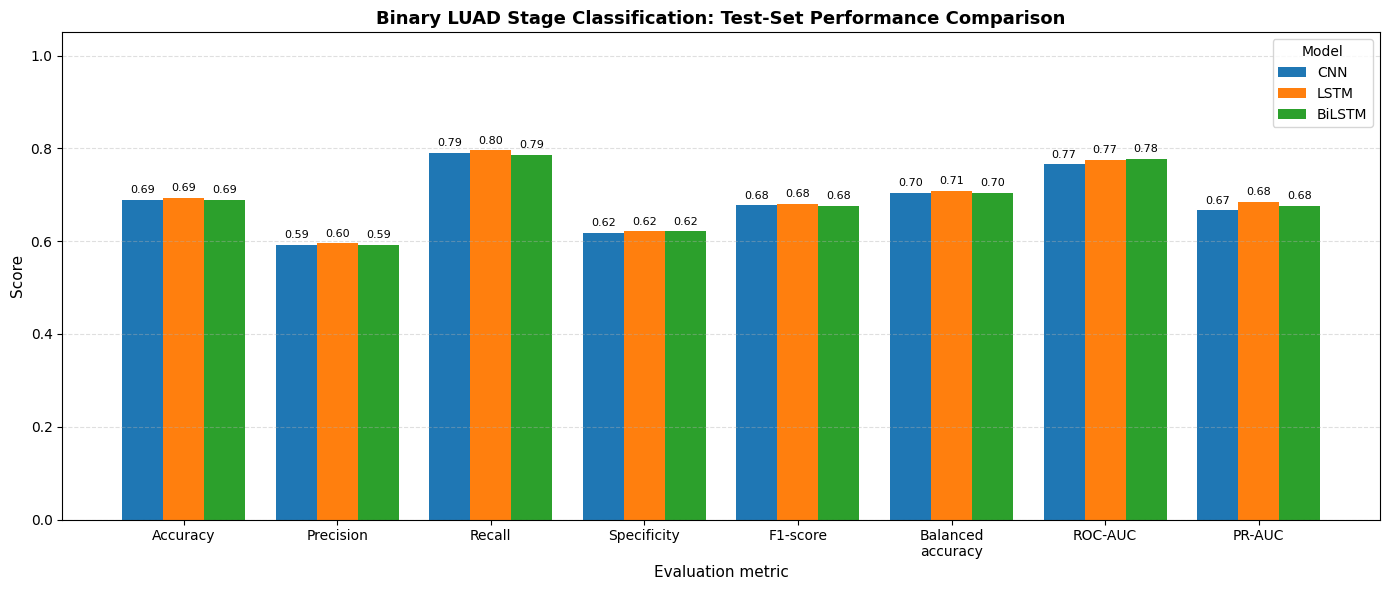

STEP 18B COMPLETED SUCCESSFULLY
Corrected binary comparison completed.
Models included:
['CNN', 'LSTM', 'BiLSTM']

LSTM result used:
Accuracy : 0.6929
F1-score : 0.6809
ROC-AUC  : 0.7748
PR-AUC   : 0.6844

Comparison CSV:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_model_test_performance_comparison.csv

Corrected chart:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\binary_model_test_performance_comparison.png

Objects available:
- binary_model_comparison_df
- binary_model_comparison_display_df
- chart_path


In [22]:
# ============================================================
# STEP 18B — BINARY MODEL TEST-PERFORMANCE COMPARISON CHART
# Corrected after genuine unidirectional LSTM rerun
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

print("=" * 90)
print("STEP 18B — BINARY MODEL TEST-PERFORMANCE COMPARISON CHART")
print("=" * 90)

# ============================================================
# 1. Project folders
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "figures"
)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Results folder not found:\n{RESULTS_DIR}"
    )

if not FIGURES_DIR.exists():
    raise FileNotFoundError(
        f"Figures folder not found:\n{FIGURES_DIR}"
    )

print("Project folder validation PASSED.")

# ============================================================
# 2. Required metric columns
# ============================================================

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall_Advanced",
    "Specificity_Early",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC",
]

# ============================================================
# 3. Helper function: extract test metrics
# ============================================================

def extract_test_metrics(
    performance_df,
    model_name,
):

    if "Split" not in performance_df.columns:
        raise KeyError(
            f"{model_name}: 'Split' column not found."
        )

    test_rows = performance_df[
        performance_df[
            "Split"
        ].astype(str).str.lower().eq("test")
    ]

    if test_rows.empty:
        raise ValueError(
            f"{model_name}: Test row not found."
        )

    missing_metrics = [
        col
        for col in metric_columns
        if col not in performance_df.columns
    ]

    if missing_metrics:
        raise KeyError(
            f"{model_name}: missing metric columns:\n"
            + "\n".join(missing_metrics)
        )

    test_row = test_rows.iloc[0]

    output_row = {
        "Model": model_name,
    }

    for col in metric_columns:
        output_row[col] = float(
            test_row[col]
        )

    return output_row


# ============================================================
# 4. Define result files
# ============================================================

# IMPORTANT:
# This file was regenerated by the genuine LSTM Step 12.
GENUINE_LSTM_FILE = (
    RESULTS_DIR
    / "binary_lstm_train_validation_test_performance.csv"
)

BLSTM_FILES = [
    RESULTS_DIR
    / "binary_blstm_train_validation_test_performance.csv",

    RESULTS_DIR
    / "binary_blstm_train_test_performance.csv",
]

CNN_FILES = [
    RESULTS_DIR
    / "binary_cnn_train_validation_test_performance.csv",

    RESULTS_DIR
    / "binary_cnn_train_test_performance.csv",
]

# ============================================================
# 5. Load GENUINE LSTM result
# ============================================================

if not GENUINE_LSTM_FILE.exists():
    raise FileNotFoundError(
        "Genuine LSTM performance file not found:\n"
        f"{GENUINE_LSTM_FILE}"
    )

lstm_performance_df = pd.read_csv(
    GENUINE_LSTM_FILE
)

lstm_row = extract_test_metrics(
    performance_df=lstm_performance_df,
    model_name="LSTM",
)

print("-" * 90)
print("Genuine LSTM results loaded from:")
print(GENUINE_LSTM_FILE)

print("\nGenuine LSTM test metrics:")
for metric in metric_columns:
    print(
        f"{metric:20s}: "
        f"{lstm_row[metric]:.4f}"
    )

# ============================================================
# 6. SAFETY CHECK — confirm this is the NEW genuine LSTM
# ============================================================

EXPECTED_LSTM_TEST = {
    "Accuracy": 0.6929,
    "Precision": 0.5952,
    "Recall_Advanced": 0.7955,
    "Specificity_Early": 0.6210,
    "F1_Score": 0.6809,
    "Balanced_Accuracy": 0.7082,
    "ROC_AUC": 0.7748,
    "PR_AUC": 0.6844,
}

for metric_name, expected_value in (
    EXPECTED_LSTM_TEST.items()
):

    actual_value = lstm_row[
        metric_name
    ]

    if not np.isclose(
        actual_value,
        expected_value,
        atol=0.00015,
    ):
        raise ValueError(
            "\nWRONG LSTM RESULT FILE DETECTED.\n"
            f"Metric: {metric_name}\n"
            f"Expected genuine LSTM: "
            f"{expected_value:.4f}\n"
            f"Found: {actual_value:.4f}\n\n"
            "Do NOT create the comparison chart "
            "until the genuine LSTM result file is loaded."
        )

print("-" * 90)
print(
    "Genuine LSTM result verification PASSED."
)
print(
    "ROC-AUC confirmed: 0.7748"
)

# ============================================================
# 7. Load BiLSTM result
# ============================================================

blstm_row = None

for file_path in BLSTM_FILES:

    if file_path.exists():

        blstm_df = pd.read_csv(
            file_path
        )

        blstm_row = extract_test_metrics(
            performance_df=blstm_df,
            model_name="BiLSTM",
        )

        print("-" * 90)
        print("BiLSTM results loaded from:")
        print(file_path)

        break

if blstm_row is None:

    if (
        "train_test_performance_df"
        in globals()
    ):

        blstm_row = extract_test_metrics(
            performance_df=
                train_test_performance_df,
            model_name="BiLSTM",
        )

        print(
            "BiLSTM results loaded from "
            "notebook object."
        )

    else:

        raise FileNotFoundError(
            "BiLSTM result file was not found."
        )

# ============================================================
# 8. Load CNN result
# ============================================================

cnn_row = None

for file_path in CNN_FILES:

    if file_path.exists():

        cnn_df = pd.read_csv(
            file_path
        )

        cnn_row = extract_test_metrics(
            performance_df=cnn_df,
            model_name="CNN",
        )

        print("-" * 90)
        print("CNN results loaded from:")
        print(file_path)

        break

if cnn_row is None:

    if (
        "cnn_model_performance_df"
        in globals()
    ):

        cnn_row = extract_test_metrics(
            performance_df=
                cnn_model_performance_df,
            model_name="CNN",
        )

        print(
            "CNN results loaded from "
            "notebook object."
        )

    else:

        raise FileNotFoundError(
            "CNN result file was not found."
        )

# ============================================================
# 9. Create corrected comparison table
# ============================================================

comparison_rows = [
    cnn_row,
    lstm_row,
    blstm_row,
]

binary_model_comparison_df = pd.DataFrame(
    comparison_rows
)

# Scientific/model order
model_order = [
    "CNN",
    "LSTM",
    "BiLSTM",
]

binary_model_comparison_df[
    "Model"
] = pd.Categorical(
    binary_model_comparison_df["Model"],
    categories=model_order,
    ordered=True,
)

binary_model_comparison_df = (
    binary_model_comparison_df
    .sort_values("Model")
    .reset_index(drop=True)
)

binary_model_comparison_display_df = (
    binary_model_comparison_df.copy()
)

binary_model_comparison_display_df[
    metric_columns
] = (
    binary_model_comparison_display_df[
        metric_columns
    ].round(4)
)

print("=" * 90)
print(
    "CORRECTED BINARY MODEL "
    "TEST-PERFORMANCE COMPARISON"
)
print("=" * 90)

display(
    binary_model_comparison_display_df
)

# ============================================================
# 10. Save corrected comparison table
# ============================================================

comparison_csv_path = (
    RESULTS_DIR
    / "binary_model_test_performance_comparison.csv"
)

binary_model_comparison_df.to_csv(
    comparison_csv_path,
    index=False,
)

print("-" * 90)
print("Corrected comparison table saved:")
print(comparison_csv_path)

# ============================================================
# 11. Create corrected grouped bar chart
# ============================================================

plot_metrics = [
    "Accuracy",
    "Precision",
    "Recall_Advanced",
    "Specificity_Early",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC",
]

plot_metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1-score",
    "Balanced\naccuracy",
    "ROC-AUC",
    "PR-AUC",
]

models_available = (
    binary_model_comparison_df[
        "Model"
    ]
    .astype(str)
    .tolist()
)

x_positions = np.arange(
    len(plot_metrics)
)

bar_width = (
    0.8 / len(models_available)
)

plt.figure(
    figsize=(14, 6)
)

for model_index, model_name in enumerate(
    models_available
):

    model_values = (
        binary_model_comparison_df.loc[
            binary_model_comparison_df[
                "Model"
            ].astype(str) == model_name,
            plot_metrics,
        ]
        .iloc[0]
        .values
        .astype(float)
    )

    bar_positions = (
        x_positions
        - 0.4
        + (model_index + 0.5)
        * bar_width
    )

    bars = plt.bar(
        bar_positions,
        model_values,
        width=bar_width,
        label=model_name,
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.xticks(
    x_positions,
    plot_metric_labels,
    fontsize=10,
)

plt.yticks(
    fontsize=10
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score",
    fontsize=11,
)

plt.xlabel(
    "Evaluation metric",
    fontsize=11,
)

plt.title(
    "Binary LUAD Stage Classification: "
    "Test-Set Performance Comparison",
    fontsize=13,
    fontweight="bold",
)

plt.legend(
    title="Model",
    fontsize=10,
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

chart_path = (
    FIGURES_DIR
    / "binary_model_test_performance_comparison.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# 12. Final verification
# ============================================================

print("=" * 90)
print("STEP 18B COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Corrected binary comparison completed.")
print("Models included:")
print(models_available)

print("\nLSTM result used:")
print(
    f"Accuracy : "
    f"{lstm_row['Accuracy']:.4f}"
)
print(
    f"F1-score : "
    f"{lstm_row['F1_Score']:.4f}"
)
print(
    f"ROC-AUC  : "
    f"{lstm_row['ROC_AUC']:.4f}"
)
print(
    f"PR-AUC   : "
    f"{lstm_row['PR_AUC']:.4f}"
)

print("\nComparison CSV:")
print(comparison_csv_path)

print("\nCorrected chart:")
print(chart_path)

print("=" * 90)

print("\nObjects available:")
print("- binary_model_comparison_df")
print("- binary_model_comparison_display_df")
print("- chart_path")

# Step 18C — Binary Model Test-Set ROC Curve Comparison

This step creates a test-set ROC curve comparison for the binary LUAD stage-classification models.

The ROC curve compares the ability of each model to distinguish between:

- early-stage LUAD
- advanced-stage LUAD

The chart includes available binary models such as LSTM, BLSTM, and CNN.

No model training is performed in this step.

STEP 18C — CORRECTED BINARY MODEL TEST-SET ROC CURVE COMPARISON
Project folder validation PASSED.


------------------------------------------------------------------------------------------
CNN predictions loaded from:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_cnn_train_validation_test_predictions.csv
CNN test samples : 534
CNN ROC-AUC      : 0.765185
------------------------------------------------------------------------------------------
LSTM predictions loaded from:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_lstm_train_validation_test_predictions.csv
LSTM test samples : 534
LSTM ROC-AUC      : 0.774754
------------------------------------------------------------------------------------------
BiLSTM predictions loaded from:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_train_test_predictions.csv
BiLSTM test samples : 534
BiLSTM ROC-AUC      : 0.776853
------------------------------------------------------------------------------------------
Held-out test-label consistency 

,Model,Test_Samples,ROC_AUC,Prediction_Source
0,CNN,534,0.7652,C:\Users\LAPTOP\Downloads\luad_reserch_code\fi...
1,LSTM,534,0.7748,C:\Users\LAPTOP\Downloads\luad_reserch_code\fi...
2,BiLSTM,534,0.7769,C:\Users\LAPTOP\Downloads\luad_reserch_code\fi...


------------------------------------------------------------------------------------------
Corrected ROC-AUC table saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_model_test_roc_auc_comparison.csv


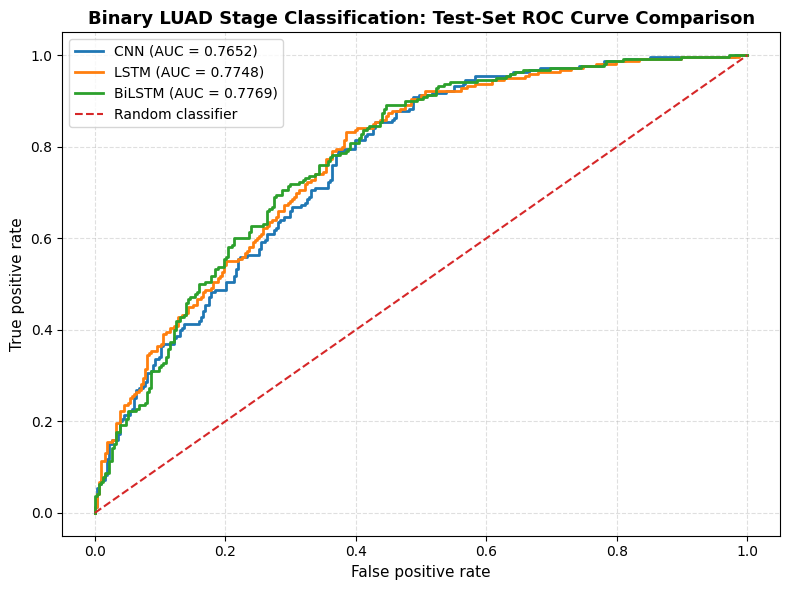

STEP 18C COMPLETED SUCCESSFULLY
Corrected ROC comparison created.

Final test ROC-AUC values:
CNN    : 0.7652
LSTM   : 0.7748
BiLSTM : 0.7769

ROC summary CSV:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_model_test_roc_auc_comparison.csv

ROC figure:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\binary_model_test_roc_curve_comparison.png

Objects available:
- binary_roc_summary_df
- binary_roc_summary_display_df
- roc_data
- roc_chart_path


In [23]:
# ============================================================
# STEP 18C — CORRECTED BINARY MODEL TEST-SET ROC CURVE COMPARISON
# CNN vs Genuine LSTM vs BiLSTM
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
)

from IPython.display import display

print("=" * 90)
print("STEP 18C — CORRECTED BINARY MODEL TEST-SET ROC CURVE COMPARISON")
print("=" * 90)

# ============================================================
# 1. Project folders
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "figures"
)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Results folder not found:\n{RESULTS_DIR}"
    )

if not FIGURES_DIR.exists():
    raise FileNotFoundError(
        f"Figures folder not found:\n{FIGURES_DIR}"
    )

print("Project folder validation PASSED.")

# ============================================================
# 2. Helper function to load TEST predictions
# ============================================================

def load_test_predictions(
    prediction_path,
    model_name,
):

    prediction_df = pd.read_csv(
        prediction_path
    )

    required_columns = [
        "Split",
        "True_Label",
        "Predicted_Probability_Advanced",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in prediction_df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{model_name}: missing required columns:\n"
            + "\n".join(missing_columns)
        )

    test_df = prediction_df[
        prediction_df[
            "Split"
        ].astype(str).str.lower().eq("test")
    ].copy()

    if test_df.empty:
        raise ValueError(
            f"{model_name}: no Test rows found."
        )

    y_true = (
        test_df["True_Label"]
        .astype(int)
        .to_numpy()
    )

    y_score = (
        test_df[
            "Predicted_Probability_Advanced"
        ]
        .astype(float)
        .to_numpy()
    )

    if len(y_true) != len(y_score):
        raise ValueError(
            f"{model_name}: label and probability "
            "counts do not match."
        )

    if len(np.unique(y_true)) != 2:
        raise ValueError(
            f"{model_name}: test labels do not "
            "contain both classes."
        )

    if not np.isfinite(y_score).all():
        raise ValueError(
            f"{model_name}: non-finite prediction "
            "probabilities detected."
        )

    return (
        y_true,
        y_score,
        test_df,
    )

# ============================================================
# 3. Correct prediction-file definitions
# ============================================================

# IMPORTANT:
# This LSTM file now contains the predictions from the
# corrected genuine unidirectional LSTM Step 12.
LSTM_FILES = [
    RESULTS_DIR
    / "binary_lstm_train_validation_test_predictions.csv",

    RESULTS_DIR
    / "binary_lstm_train_test_predictions.csv",
]

# IMPORTANT:
# BiLSTM can ONLY use BiLSTM prediction files.
# Do NOT use any LSTM file as a fallback.
BILSTM_FILES = [
    RESULTS_DIR
    / "binary_blstm_train_validation_test_predictions.csv",

    RESULTS_DIR
    / "binary_blstm_train_test_predictions.csv",
]

CNN_FILES = [
    RESULTS_DIR
    / "binary_cnn_train_validation_test_predictions.csv",

    RESULTS_DIR
    / "binary_cnn_train_test_predictions.csv",
]

model_prediction_files = {
    "CNN": CNN_FILES,
    "LSTM": LSTM_FILES,
    "BiLSTM": BILSTM_FILES,
}

# ============================================================
# 4. Expected values from verified test results
# ============================================================

EXPECTED_AUC = {
    "CNN": 0.7652,
    "LSTM": 0.7748,
    "BiLSTM": 0.7769,
}

EXPECTED_TEST_SAMPLES = 534

# ============================================================
# 5. Load prediction files
# ============================================================

roc_data = {}

for model_name, candidate_files in (
    model_prediction_files.items()
):

    selected_path = None

    for candidate_path in candidate_files:

        if candidate_path.exists():
            selected_path = candidate_path
            break

    if selected_path is None:
        raise FileNotFoundError(
            f"{model_name} prediction file not found.\n"
            f"Checked:\n"
            + "\n".join(
                str(path)
                for path in candidate_files
            )
        )

    y_true, y_score, test_df = (
        load_test_predictions(
            prediction_path=selected_path,
            model_name=model_name,
        )
    )

    if len(y_true) != EXPECTED_TEST_SAMPLES:
        raise ValueError(
            f"{model_name}: expected "
            f"{EXPECTED_TEST_SAMPLES} test patients, "
            f"found {len(y_true)}."
        )

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score,
    )

    auc_value = roc_auc_score(
        y_true,
        y_score,
    )

    roc_data[model_name] = {
        "y_true": y_true,
        "y_score": y_score,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": auc_value,
        "prediction_path": selected_path,
        "n_test_samples": len(y_true),
    }

    print("-" * 90)
    print(f"{model_name} predictions loaded from:")
    print(selected_path)

    print(
        f"{model_name} test samples : "
        f"{len(y_true)}"
    )

    print(
        f"{model_name} ROC-AUC      : "
        f"{auc_value:.6f}"
    )

# ============================================================
# 6. Verify same held-out labels across models
# ============================================================

cnn_labels = roc_data[
    "CNN"
]["y_true"]

lstm_labels = roc_data[
    "LSTM"
]["y_true"]

bilstm_labels = roc_data[
    "BiLSTM"
]["y_true"]

if not np.array_equal(
    cnn_labels,
    lstm_labels,
):
    raise ValueError(
        "CNN and LSTM test-label arrays do not match."
    )

if not np.array_equal(
    cnn_labels,
    bilstm_labels,
):
    raise ValueError(
        "CNN and BiLSTM test-label arrays do not match."
    )

print("-" * 90)
print(
    "Held-out test-label consistency PASSED."
)
print(
    "CNN, LSTM and BiLSTM use the same "
    "534 test labels."
)

# ============================================================
# 7. Safety check expected ROC-AUC values
# ============================================================

for model_name, expected_auc in (
    EXPECTED_AUC.items()
):

    actual_auc = roc_data[
        model_name
    ]["auc"]

    if not np.isclose(
        actual_auc,
        expected_auc,
        atol=0.00015,
    ):
        raise ValueError(
            "\nWRONG OR STALE PREDICTION FILE DETECTED.\n"
            f"Model: {model_name}\n"
            f"Expected ROC-AUC: {expected_auc:.4f}\n"
            f"Found ROC-AUC   : {actual_auc:.4f}\n\n"
            "Do not generate the ROC comparison "
            "until the correct prediction file is loaded."
        )

print("-" * 90)
print("ROC-AUC verification PASSED.")

print(
    f"CNN    : "
    f"{roc_data['CNN']['auc']:.4f}"
)

print(
    f"LSTM   : "
    f"{roc_data['LSTM']['auc']:.4f}"
)

print(
    f"BiLSTM : "
    f"{roc_data['BiLSTM']['auc']:.4f}"
)

# ============================================================
# 8. Build corrected ROC-AUC summary table
# ============================================================

model_order = [
    "CNN",
    "LSTM",
    "BiLSTM",
]

roc_summary_rows = []

for model_name in model_order:

    model_data = roc_data[
        model_name
    ]

    roc_summary_rows.append({
        "Model": model_name,
        "Test_Samples":
            model_data[
                "n_test_samples"
            ],
        "ROC_AUC":
            model_data["auc"],
        "Prediction_Source":
            str(
                model_data[
                    "prediction_path"
                ]
            ),
    })

binary_roc_summary_df = pd.DataFrame(
    roc_summary_rows
)

binary_roc_summary_display_df = (
    binary_roc_summary_df.copy()
)

binary_roc_summary_display_df[
    "ROC_AUC"
] = (
    binary_roc_summary_display_df[
        "ROC_AUC"
    ].round(4)
)

print("=" * 90)
print(
    "CORRECTED BINARY MODEL "
    "TEST-SET ROC-AUC SUMMARY"
)
print("=" * 90)

display(
    binary_roc_summary_display_df
)

# ============================================================
# 9. Save corrected ROC-AUC summary
# ============================================================

roc_summary_path = (
    RESULTS_DIR
    / "binary_model_test_roc_auc_comparison.csv"
)

binary_roc_summary_df.to_csv(
    roc_summary_path,
    index=False,
)

print("-" * 90)
print("Corrected ROC-AUC table saved:")
print(roc_summary_path)

# ============================================================
# 10. Plot corrected ROC curves
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in model_order:

    model_data = roc_data[
        model_name
    ]

    plt.plot(
        model_data["fpr"],
        model_data["tpr"],
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {model_data['auc']:.4f})"
        ),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier",
)

plt.xlabel(
    "False positive rate",
    fontsize=11,
)

plt.ylabel(
    "True positive rate",
    fontsize=11,
)

plt.title(
    "Binary LUAD Stage Classification: "
    "Test-Set ROC Curve Comparison",
    fontsize=13,
    fontweight="bold",
)

plt.legend(
    fontsize=10
)

plt.grid(
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

roc_chart_path = (
    FIGURES_DIR
    / "binary_model_test_roc_curve_comparison.png"
)

plt.savefig(
    roc_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# 11. Final summary
# ============================================================

print("=" * 90)
print("STEP 18C COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Corrected ROC comparison created.")

print("\nFinal test ROC-AUC values:")
print(
    f"CNN    : "
    f"{roc_data['CNN']['auc']:.4f}"
)
print(
    f"LSTM   : "
    f"{roc_data['LSTM']['auc']:.4f}"
)
print(
    f"BiLSTM : "
    f"{roc_data['BiLSTM']['auc']:.4f}"
)

print("\nROC summary CSV:")
print(roc_summary_path)

print("\nROC figure:")
print(roc_chart_path)

print("=" * 90)

print("\nObjects available:")
print("- binary_roc_summary_df")
print("- binary_roc_summary_display_df")
print("- roc_data")
print("- roc_chart_path")

# Step 18D — Confusion Matrix Visualization for the Best Binary Model

This step creates a confusion matrix visualization for the best-performing binary LUAD stage-classification model.

The best model is selected using test ROC-AUC from the binary model comparison table.

The confusion matrix shows how many test samples were classified as:

- true early-stage cases
- early-stage cases misclassified as advanced
- advanced-stage cases misclassified as early
- true advanced-stage cases

No model training is performed in this step.

STEP 18D — CONFUSION MATRIX FOR THE BEST BINARY MODEL
Project folder validation PASSED.
------------------------------------------------------------------------------------------
Corrected binary comparison table loaded:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_model_test_performance_comparison.csv


,Model,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,CNN,0.689139,0.591837,0.790909,0.617834,0.677043,0.704372,0.765185,0.666427
1,LSTM,0.692884,0.595238,0.795455,0.621019,0.680934,0.708237,0.774754,0.684427
2,BiLSTM,0.689139,0.592466,0.786364,0.621019,0.675781,0.703691,0.776853,0.675986


------------------------------------------------------------------------------------------
Best binary model selected:
Model        : BiLSTM
Test ROC-AUC : 0.7769
Best-model verification PASSED.
BiLSTM confirmed as highest ROC-AUC model.
------------------------------------------------------------------------------------------
Prediction file selected:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_blstm_train_test_predictions.csv
------------------------------------------------------------------------------------------
Test samples used: 534
ROC-AUC recomputed from prediction file: 0.7769
BiLSTM prediction-file verification PASSED.
BiLSTM TEST CONFUSION MATRIX COUNTS


,Outcome,Confusion_Matrix_Term,Count
0,True Early predicted as Early,TN,195
1,Early misclassified as Advanced,FP,119
2,Advanced misclassified as Early,FN,47
3,True Advanced predicted as Advanced,TP,173


TN=195, FP=119, FN=47, TP=173
------------------------------------------------------------------------------------------
Confusion-matrix verification PASSED.
Expected counts confirmed:
TN=195, FP=119, FN=47, TP=173


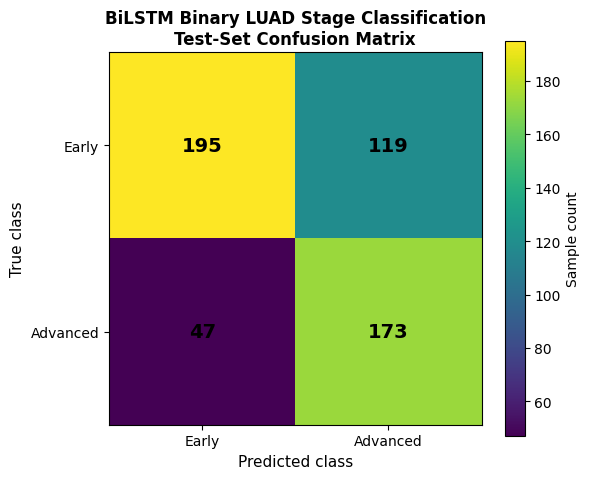

------------------------------------------------------------------------------------------
Confusion matrix figure saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\best_binary_model_bilstm_confusion_matrix.png
------------------------------------------------------------------------------------------
Confusion matrix counts saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\best_binary_model_bilstm_confusion_matrix_counts.csv
STEP 18D COMPLETED SUCCESSFULLY
Best binary model : BiLSTM
Test ROC-AUC      : 0.7769
Test samples      : 534
Confusion matrix  : TN=195, FP=119, FN=47, TP=173

Objects available:
- best_binary_model_name
- confusion_summary_df
- confusion_chart_path
- confusion_summary_path


In [24]:
# ============================================================
# STEP 18D — CONFUSION MATRIX FOR BEST BINARY MODEL
# Corrected CNN vs Genuine LSTM vs BiLSTM comparison
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
)

from IPython.display import display

print("=" * 90)
print("STEP 18D — CONFUSION MATRIX FOR THE BEST BINARY MODEL")
print("=" * 90)

# ============================================================
# 1. Project folders
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "figures"
)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Results folder not found:\n{RESULTS_DIR}"
    )

if not FIGURES_DIR.exists():
    raise FileNotFoundError(
        f"Figures folder not found:\n{FIGURES_DIR}"
    )

print("Project folder validation PASSED.")

# ============================================================
# 2. Load corrected binary comparison table
# ============================================================

comparison_path = (
    RESULTS_DIR
    / "binary_model_test_performance_comparison.csv"
)

if not comparison_path.exists():
    raise FileNotFoundError(
        "Corrected binary comparison table not found.\n"
        "Please run corrected Step 18B first."
    )

binary_model_comparison_df = pd.read_csv(
    comparison_path
)

required_comparison_columns = [
    "Model",
    "ROC_AUC",
]

missing_columns = [
    col
    for col in required_comparison_columns
    if col not in binary_model_comparison_df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )

print("-" * 90)
print("Corrected binary comparison table loaded:")
print(comparison_path)

display(
    binary_model_comparison_df
)

# ============================================================
# 3. Select best model by TEST ROC-AUC
# ============================================================

best_model_row = (
    binary_model_comparison_df
    .sort_values(
        by="ROC_AUC",
        ascending=False,
    )
    .iloc[0]
)

best_binary_model_name = str(
    best_model_row["Model"]
)

best_binary_model_roc_auc = float(
    best_model_row["ROC_AUC"]
)

print("-" * 90)
print("Best binary model selected:")
print(f"Model        : {best_binary_model_name}")
print(f"Test ROC-AUC : {best_binary_model_roc_auc:.4f}")

# ============================================================
# 4. Safety check
# ============================================================

EXPECTED_BEST_MODEL = "BiLSTM"
EXPECTED_BEST_AUC = 0.7769

if best_binary_model_name != EXPECTED_BEST_MODEL:
    raise ValueError(
        "Unexpected best model detected.\n"
        f"Expected: {EXPECTED_BEST_MODEL}\n"
        f"Found: {best_binary_model_name}"
    )

if not np.isclose(
    best_binary_model_roc_auc,
    EXPECTED_BEST_AUC,
    atol=0.00015,
):
    raise ValueError(
        "Unexpected best-model ROC-AUC.\n"
        f"Expected approximately: {EXPECTED_BEST_AUC:.4f}\n"
        f"Found: {best_binary_model_roc_auc:.4f}"
    )

print("Best-model verification PASSED.")
print("BiLSTM confirmed as highest ROC-AUC model.")

# ============================================================
# 5. Prediction-file candidates
# ============================================================

prediction_file_candidates = {

    "CNN": [
        RESULTS_DIR
        / "binary_cnn_train_validation_test_predictions.csv",

        RESULTS_DIR
        / "binary_cnn_train_test_predictions.csv",
    ],

    "LSTM": [
        RESULTS_DIR
        / "binary_lstm_train_validation_test_predictions.csv",

        RESULTS_DIR
        / "binary_lstm_train_test_predictions.csv",
    ],

    # IMPORTANT:
    # Only BiLSTM files are allowed here.
    "BiLSTM": [
        RESULTS_DIR
        / "binary_blstm_train_validation_test_predictions.csv",

        RESULTS_DIR
        / "binary_blstm_train_test_predictions.csv",
    ],
}

if (
    best_binary_model_name
    not in prediction_file_candidates
):
    raise ValueError(
        "No prediction-file candidates defined "
        f"for model: {best_binary_model_name}"
    )

selected_prediction_path = None

for candidate_path in (
    prediction_file_candidates[
        best_binary_model_name
    ]
):

    if candidate_path.exists():
        selected_prediction_path = (
            candidate_path
        )
        break

if selected_prediction_path is None:
    raise FileNotFoundError(
        f"No prediction file found for "
        f"{best_binary_model_name}.\n"
        "Please confirm the BiLSTM evaluation files exist."
    )

print("-" * 90)
print("Prediction file selected:")
print(selected_prediction_path)

# ============================================================
# 6. Load prediction file
# ============================================================

prediction_df = pd.read_csv(
    selected_prediction_path
)

required_prediction_columns = [
    "Split",
    "True_Label",
    "Predicted_Label",
    "Predicted_Probability_Advanced",
]

missing_prediction_columns = [
    col
    for col in required_prediction_columns
    if col not in prediction_df.columns
]

if missing_prediction_columns:
    raise KeyError(
        "Missing required prediction columns:\n"
        + "\n".join(
            missing_prediction_columns
        )
    )

# ============================================================
# 7. Extract held-out TEST predictions
# ============================================================

test_prediction_df = prediction_df[
    prediction_df[
        "Split"
    ].astype(str).str.lower().eq("test")
].copy()

if test_prediction_df.empty:
    raise ValueError(
        "No test rows found in selected "
        "BiLSTM prediction file."
    )

y_true = (
    test_prediction_df[
        "True_Label"
    ]
    .astype(int)
    .to_numpy()
)

y_pred = (
    test_prediction_df[
        "Predicted_Label"
    ]
    .astype(int)
    .to_numpy()
)

y_probability = (
    test_prediction_df[
        "Predicted_Probability_Advanced"
    ]
    .astype(float)
    .to_numpy()
)

EXPECTED_TEST_SAMPLES = 534

if len(y_true) != EXPECTED_TEST_SAMPLES:
    raise ValueError(
        f"Expected {EXPECTED_TEST_SAMPLES} test patients, "
        f"found {len(y_true)}."
    )

print("-" * 90)
print(
    f"Test samples used: {len(y_true)}"
)

# ============================================================
# 8. Verify ROC-AUC directly from prediction file
# ============================================================

prediction_auc = roc_auc_score(
    y_true,
    y_probability,
)

print(
    f"ROC-AUC recomputed from prediction file: "
    f"{prediction_auc:.4f}"
)

if not np.isclose(
    prediction_auc,
    EXPECTED_BEST_AUC,
    atol=0.00015,
):
    raise ValueError(
        "\nWRONG BiLSTM PREDICTION FILE DETECTED.\n"
        f"Expected ROC-AUC: {EXPECTED_BEST_AUC:.4f}\n"
        f"Found ROC-AUC   : {prediction_auc:.4f}"
    )

print("BiLSTM prediction-file verification PASSED.")

# ============================================================
# 9. Compute confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1],
)

tn, fp, fn, tp = cm.ravel()

confusion_summary_df = pd.DataFrame({
    "Outcome": [
        "True Early predicted as Early",
        "Early misclassified as Advanced",
        "Advanced misclassified as Early",
        "True Advanced predicted as Advanced",
    ],

    "Confusion_Matrix_Term": [
        "TN",
        "FP",
        "FN",
        "TP",
    ],

    "Count": [
        int(tn),
        int(fp),
        int(fn),
        int(tp),
    ],
})

print("=" * 90)
print("BiLSTM TEST CONFUSION MATRIX COUNTS")
print("=" * 90)

display(
    confusion_summary_df
)

print(
    f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
)

# ============================================================
# 10. Safety check expected confusion matrix
# ============================================================

EXPECTED_CM = {
    "TN": 195,
    "FP": 119,
    "FN": 47,
    "TP": 173,
}

actual_cm = {
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
}

if actual_cm != EXPECTED_CM:
    raise ValueError(
        "Unexpected BiLSTM confusion matrix.\n"
        f"Expected: {EXPECTED_CM}\n"
        f"Found:    {actual_cm}"
    )

print("-" * 90)
print("Confusion-matrix verification PASSED.")
print("Expected counts confirmed:")
print("TN=195, FP=119, FN=47, TP=173")

# ============================================================
# 11. Plot confusion matrix
# ============================================================

class_labels = [
    "Early",
    "Advanced",
]

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm
)

plt.title(
    "BiLSTM Binary LUAD Stage Classification\n"
    "Test-Set Confusion Matrix",
    fontsize=12,
    fontweight="bold",
)

plt.xlabel(
    "Predicted class",
    fontsize=11,
)

plt.ylabel(
    "True class",
    fontsize=11,
)

plt.xticks(
    ticks=np.arange(
        len(class_labels)
    ),
    labels=class_labels,
    fontsize=10,
)

plt.yticks(
    ticks=np.arange(
        len(class_labels)
    ),
    labels=class_labels,
    fontsize=10,
)

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
        )

plt.colorbar(
    label="Sample count"
)

plt.tight_layout()

confusion_chart_path = (
    FIGURES_DIR
    / "best_binary_model_bilstm_confusion_matrix.png"
)

plt.savefig(
    confusion_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# 12. Save confusion matrix counts
# ============================================================

confusion_summary_path = (
    RESULTS_DIR
    / "best_binary_model_bilstm_confusion_matrix_counts.csv"
)

confusion_summary_df.to_csv(
    confusion_summary_path,
    index=False,
)

print("-" * 90)
print("Confusion matrix figure saved:")
print(confusion_chart_path)

print("-" * 90)
print("Confusion matrix counts saved:")
print(confusion_summary_path)

# ============================================================
# 13. Final summary
# ============================================================

print("=" * 90)
print("STEP 18D COMPLETED SUCCESSFULLY")
print("=" * 90)

print(
    f"Best binary model : "
    f"{best_binary_model_name}"
)

print(
    f"Test ROC-AUC      : "
    f"{best_binary_model_roc_auc:.4f}"
)

print(
    f"Test samples      : "
    f"{len(y_true)}"
)

print(
    f"Confusion matrix  : "
    f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
)

print("=" * 90)

print("\nObjects available:")
print("- best_binary_model_name")
print("- confusion_summary_df")
print("- confusion_chart_path")
print("- confusion_summary_path")

# Step 18E — Training and Validation Learning-Curve Visualization

This step creates a learning-curve visualization for the best available binary LUAD stage-classification model.

The curve compares training ROC-AUC and validation ROC-AUC across epochs.

This visualization helps assess whether the model learned consistently or started to overfit.

No model training is performed in this step.

In [26]:
# ============================================================
# CHECK BiLSTM INITIAL VS CONTINUATION HISTORY
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "results"
)

initial_path = (
    RESULTS_DIR
    / "binary_blstm_learning_curve_history.csv"
)

continued_path = (
    RESULTS_DIR
    / "binary_blstm_continued_training_history.csv"
)

initial_df = pd.read_csv(initial_path)
continued_df = pd.read_csv(continued_path)

print("=" * 90)
print("BiLSTM HISTORY DUPLICATION AUDIT")
print("=" * 90)

print(f"Initial rows   : {len(initial_df)}")
print(f"Continued rows : {len(continued_df)}")

common_metric_columns = [
    col
    for col in [
        "loss",
        "accuracy",
        "precision",
        "advanced_recall",
        "roc_auc",
        "pr_auc",
        "val_loss",
        "val_accuracy",
        "val_precision",
        "val_advanced_recall",
        "val_roc_auc",
        "val_pr_auc",
    ]
    if col in initial_df.columns
    and col in continued_df.columns
]

print("\nCommon metric columns:")
print(common_metric_columns)

same_shape = (
    initial_df[common_metric_columns].shape
    ==
    continued_df[common_metric_columns].shape
)

if same_shape:
    exact_duplicate = np.allclose(
        initial_df[common_metric_columns].to_numpy(dtype=float),
        continued_df[common_metric_columns].to_numpy(dtype=float),
        rtol=0,
        atol=1e-12,
        equal_nan=True,
    )
else:
    exact_duplicate = False

print("-" * 90)
print(f"Same metric-table shape : {same_shape}")
print(f"Exact metric duplicate  : {exact_duplicate}")

if exact_duplicate:
    print("\nWARNING:")
    print(
        "The continued-training history is an exact duplicate "
        "of the initial BiLSTM history."
    )
    print(
        "Do NOT use the combined 14-epoch learning curve "
        "for the manuscript."
    )
else:
    print("\nHistories are different.")
    print("Continuation history appears independent.")

BiLSTM HISTORY DUPLICATION AUDIT
Initial rows   : 7
Continued rows : 7

Common metric columns:
['loss', 'accuracy', 'precision', 'advanced_recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_advanced_recall', 'val_roc_auc', 'val_pr_auc']
------------------------------------------------------------------------------------------
Same metric-table shape : True
Exact metric duplicate  : True

The continued-training history is an exact duplicate of the initial BiLSTM history.
Do NOT use the combined 14-epoch learning curve for the manuscript.


STEP 18E — VERIFIED BiLSTM INITIAL LEARNING-CURVE VISUALIZATION
Project folder validation PASSED.
------------------------------------------------------------------------------------------
Best binary test model:
Model        : BiLSTM
Test ROC-AUC : 0.7769
Best-model verification PASSED.
------------------------------------------------------------------------------------------
Initial history rows   : 7
Continued history rows : 7
------------------------------------------------------------------------------------------
Continuation-history audit:
Same metric shape       : True
Exact metric duplicate : True

Confirmed: continuation-history CSV duplicates the initial history.
The duplicate continuation rows will NOT be plotted.
VERIFIED INITIAL BiLSTM TRAINING HISTORY


,epoch,loss,accuracy,roc_auc,val_loss,val_accuracy,val_roc_auc
0,1,0.5382,0.7305,0.8112,0.5483,0.7228,0.8103
1,2,0.5354,0.7333,0.8121,0.5441,0.7341,0.8129
2,3,0.5322,0.7398,0.8182,0.5419,0.7434,0.8151
3,4,0.5312,0.7365,0.8176,0.5461,0.7285,0.8173
4,5,0.5305,0.7386,0.8204,0.5388,0.7509,0.8184
5,6,0.5236,0.7470,0.8218,0.5372,0.7453,0.8189
6,7,0.5210,0.7426,0.8238,0.5363,0.7453,0.8185


------------------------------------------------------------------------------------------
Best VERIFIED initial validation epoch:
Epoch       : 6
Val ROC-AUC : 0.8189


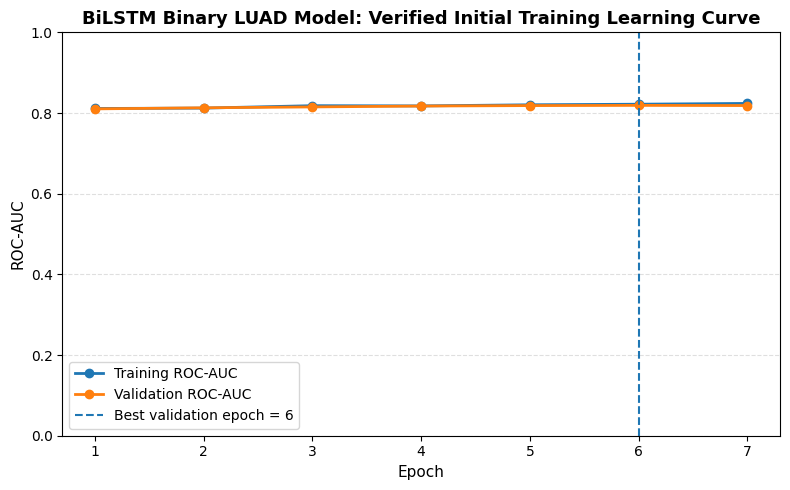

STEP 18E COMPLETED SUCCESSFULLY
Best binary model              : BiLSTM
Final test ROC-AUC             : 0.7769
Verified history epochs plotted: 7
Best initial validation epoch  : 6
Best initial validation ROC-AUC: 0.8189
Continuation history used      : NO
Reason                         : saved continuation history is an exact duplicate of initial history

Corrected figure:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\binary_bilstm_verified_initial_learning_curve_roc_auc.png

Verified history CSV:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\binary_bilstm_verified_initial_learning_curve_history.csv

Objects available:
- history_df
- best_epoch
- best_val_roc_auc
- learning_curve_path
- verified_history_path


In [28]:
# ============================================================
# STEP 18E — VERIFIED BiLSTM INITIAL LEARNING CURVE
# Duplicate continuation history is excluded
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

print("=" * 90)
print("STEP 18E — VERIFIED BiLSTM INITIAL LEARNING-CURVE VISUALIZATION")
print("=" * 90)

# ============================================================
# 1. Project folders
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "final_luad_results"
    / "figures"
)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Results folder not found:\n{RESULTS_DIR}"
    )

if not FIGURES_DIR.exists():
    raise FileNotFoundError(
        f"Figures folder not found:\n{FIGURES_DIR}"
    )

print("Project folder validation PASSED.")

# ============================================================
# 2. Confirm BiLSTM is still best test model
# ============================================================

comparison_path = (
    RESULTS_DIR
    / "binary_model_test_performance_comparison.csv"
)

if not comparison_path.exists():
    raise FileNotFoundError(
        "Corrected binary model comparison file not found.\n"
        "Please run corrected Step 18B first."
    )

comparison_df = pd.read_csv(
    comparison_path
)

best_row = (
    comparison_df
    .sort_values(
        "ROC_AUC",
        ascending=False,
    )
    .iloc[0]
)

best_model = str(
    best_row["Model"]
)

best_test_auc = float(
    best_row["ROC_AUC"]
)

print("-" * 90)
print("Best binary test model:")
print(f"Model        : {best_model}")
print(f"Test ROC-AUC : {best_test_auc:.4f}")

if best_model != "BiLSTM":
    raise ValueError(
        f"Expected BiLSTM as best model, found: {best_model}"
    )

if not np.isclose(
    best_test_auc,
    0.7769,
    atol=0.00015,
):
    raise ValueError(
        "Unexpected BiLSTM test ROC-AUC.\n"
        f"Expected approximately 0.7769, found {best_test_auc:.4f}"
    )

print("Best-model verification PASSED.")

# ============================================================
# 3. BiLSTM history files
# ============================================================

INITIAL_HISTORY_PATH = (
    RESULTS_DIR
    / "binary_blstm_learning_curve_history.csv"
)

CONTINUED_HISTORY_PATH = (
    RESULTS_DIR
    / "binary_blstm_continued_training_history.csv"
)

if not INITIAL_HISTORY_PATH.exists():
    raise FileNotFoundError(
        "Initial BiLSTM history not found:\n"
        f"{INITIAL_HISTORY_PATH}"
    )

if not CONTINUED_HISTORY_PATH.exists():
    raise FileNotFoundError(
        "Continuation-history file not found:\n"
        f"{CONTINUED_HISTORY_PATH}"
    )

initial_df = pd.read_csv(
    INITIAL_HISTORY_PATH
)

continued_df = pd.read_csv(
    CONTINUED_HISTORY_PATH
)

print("-" * 90)
print(f"Initial history rows   : {len(initial_df)}")
print(f"Continued history rows : {len(continued_df)}")

# ============================================================
# 4. Audit continuation-history duplication
# ============================================================

metric_columns = [
    "loss",
    "accuracy",
    "precision",
    "advanced_recall",
    "roc_auc",
    "pr_auc",
    "val_loss",
    "val_accuracy",
    "val_precision",
    "val_advanced_recall",
    "val_roc_auc",
    "val_pr_auc",
]

common_metric_columns = [
    col
    for col in metric_columns
    if col in initial_df.columns
    and col in continued_df.columns
]

if not common_metric_columns:
    raise ValueError(
        "No common training metrics found between history files."
    )

same_shape = (
    initial_df[common_metric_columns].shape
    ==
    continued_df[common_metric_columns].shape
)

if same_shape:

    continuation_is_duplicate = np.allclose(
        initial_df[
            common_metric_columns
        ].to_numpy(dtype=float),

        continued_df[
            common_metric_columns
        ].to_numpy(dtype=float),

        rtol=0,
        atol=1e-12,
        equal_nan=True,
    )

else:
    continuation_is_duplicate = False

print("-" * 90)
print("Continuation-history audit:")
print(f"Same metric shape       : {same_shape}")
print(
    f"Exact metric duplicate : "
    f"{continuation_is_duplicate}"
)

if not continuation_is_duplicate:
    raise ValueError(
        "Continuation history is no longer an exact duplicate.\n"
        "Stop here and re-audit before changing the learning curve."
    )

print(
    "\nConfirmed: continuation-history CSV duplicates "
    "the initial history."
)
print(
    "The duplicate continuation rows will NOT be plotted."
)

# ============================================================
# 5. Prepare VERIFIED initial BiLSTM history only
# ============================================================

history_df = initial_df.copy()

history_df = history_df.reset_index(
    drop=True
)

history_df["epoch"] = np.arange(
    1,
    len(history_df) + 1,
)

history_df["history_status"] = (
    "Verified initial BiLSTM training"
)

required_history_columns = [
    "roc_auc",
    "val_roc_auc",
]

missing_history_columns = [
    col
    for col in required_history_columns
    if col not in history_df.columns
]

if missing_history_columns:
    raise KeyError(
        "Initial BiLSTM history missing required columns:\n"
        + "\n".join(
            missing_history_columns
        )
    )

# ============================================================
# 6. Display verified history
# ============================================================

display_columns = [
    "epoch",
    "loss",
    "accuracy",
    "roc_auc",
    "val_loss",
    "val_accuracy",
    "val_roc_auc",
]

available_columns = [
    col
    for col in display_columns
    if col in history_df.columns
]

print("=" * 90)
print("VERIFIED INITIAL BiLSTM TRAINING HISTORY")
print("=" * 90)

display(
    history_df[
        available_columns
    ].round(4)
)

# ============================================================
# 7. Best validation epoch in VERIFIED history
# ============================================================

best_epoch_index = (
    history_df[
        "val_roc_auc"
    ].idxmax()
)

best_epoch = int(
    history_df.loc[
        best_epoch_index,
        "epoch",
    ]
)

best_val_roc_auc = float(
    history_df.loc[
        best_epoch_index,
        "val_roc_auc",
    ]
)

print("-" * 90)
print("Best VERIFIED initial validation epoch:")
print(f"Epoch       : {best_epoch}")
print(f"Val ROC-AUC : {best_val_roc_auc:.4f}")

# ============================================================
# 8. Plot only VERIFIED initial history
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["roc_auc"],
    marker="o",
    linewidth=2,
    label="Training ROC-AUC",
)

plt.plot(
    history_df["epoch"],
    history_df["val_roc_auc"],
    marker="o",
    linewidth=2,
    label="Validation ROC-AUC",
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best validation epoch = "
        f"{best_epoch}"
    ),
)

plt.xlabel(
    "Epoch",
    fontsize=11,
)

plt.ylabel(
    "ROC-AUC",
    fontsize=11,
)

plt.title(
    "BiLSTM Binary LUAD Model: "
    "Verified Initial Training Learning Curve",
    fontsize=13,
    fontweight="bold",
)

plt.ylim(
    0.0,
    1.0,
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

plt.legend(
    fontsize=10,
)

plt.tight_layout()

# ============================================================
# 9. Save corrected figure
# ============================================================

learning_curve_path = (
    FIGURES_DIR
    / "binary_bilstm_verified_initial_learning_curve_roc_auc.png"
)

plt.savefig(
    learning_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# 10. Save verified history only
# ============================================================

verified_history_path = (
    RESULTS_DIR
    / "binary_bilstm_verified_initial_learning_curve_history.csv"
)

history_df.to_csv(
    verified_history_path,
    index=False,
)

# ============================================================
# 11. Final summary
# ============================================================

print("=" * 90)
print("STEP 18E COMPLETED SUCCESSFULLY")
print("=" * 90)

print("Best binary model              : BiLSTM")
print(f"Final test ROC-AUC             : {best_test_auc:.4f}")

print(
    f"Verified history epochs plotted: "
    f"{len(history_df)}"
)

print(
    f"Best initial validation epoch  : "
    f"{best_epoch}"
)

print(
    f"Best initial validation ROC-AUC: "
    f"{best_val_roc_auc:.4f}"
)

print(
    "Continuation history used      : NO"
)

print(
    "Reason                         : "
    "saved continuation history is an exact duplicate "
    "of initial history"
)

print("\nCorrected figure:")
print(learning_curve_path)

print("\nVerified history CSV:")
print(verified_history_path)

print("=" * 90)

print("\nObjects available:")
print("- history_df")
print("- best_epoch")
print("- best_val_roc_auc")
print("- learning_curve_path")
print("- verified_history_path")

# Step 19 — Four-Class Stage Label Distribution Audit

This step checks the number of samples available for four-class LUAD stage prediction.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

This step reports the stage distribution in the training, validation, test, and full supervised datasets.



In [60]:
# Step 19: Four-class stage label distribution audit

import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 90)
print("STEP 19 — FOUR-CLASS STAGE LABEL DISTRIBUTION AUDIT")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "train_arrays",
    "validation_arrays",
    "test_arrays",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Step 9 before this step:\n"
        + "\n".join(missing_objects)
    )

for split_name, split_arrays in {
    "Training": train_arrays,
    "Validation": validation_arrays,
    "Test": test_arrays,
}.items():
    if "four_class_labels" not in split_arrays:
        raise KeyError(f"'four_class_labels' not found in {split_name} arrays.")

print("Required object validation PASSED.")

# ============================================================
# 2. Extract four-class labels
# ============================================================

train_four_class_labels = np.asarray(
    train_arrays["four_class_labels"],
    dtype=int,
)

validation_four_class_labels = np.asarray(
    validation_arrays["four_class_labels"],
    dtype=int,
)

test_four_class_labels = np.asarray(
    test_arrays["four_class_labels"],
    dtype=int,
)

all_four_class_labels = np.concatenate([
    train_four_class_labels,
    validation_four_class_labels,
    test_four_class_labels,
])

stage_label_mapping = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

expected_classes = [0, 1, 2, 3]

for split_name, labels in {
    "Training": train_four_class_labels,
    "Validation": validation_four_class_labels,
    "Test": test_four_class_labels,
    "Full Supervised": all_four_class_labels,
}.items():
    unique_labels = sorted(np.unique(labels).tolist())

    unexpected_labels = [
        label for label in unique_labels
        if label not in expected_classes
    ]

    if unexpected_labels:
        raise ValueError(
            f"{split_name} contains unexpected labels: {unexpected_labels}"
        )

print("-" * 90)
print("Four-class label validation PASSED.")

# ============================================================
# 3. Distribution function
# ============================================================

def build_stage_distribution(labels, split_name):
    labels = np.asarray(labels, dtype=int)
    total_samples = len(labels)

    rows = []

    for class_id in expected_classes:
        count = int(np.sum(labels == class_id))
        percentage = (count / total_samples) * 100 if total_samples > 0 else 0.0

        if class_id in [0, 1]:
            stage_group = "Early"
        else:
            stage_group = "Advanced"

        rows.append({
            "Split": split_name,
            "Class_ID": class_id,
            "Stage_Label": stage_label_mapping[class_id],
            "Stage_Group": stage_group,
            "Sample_Count": count,
            "Percentage": percentage,
        })

    return pd.DataFrame(rows)

# ============================================================
# 4. Build distribution tables
# ============================================================

stage_distribution_df = pd.concat(
    [
        build_stage_distribution(train_four_class_labels, "Training"),
        build_stage_distribution(validation_four_class_labels, "Validation"),
        build_stage_distribution(test_four_class_labels, "Test"),
        build_stage_distribution(all_four_class_labels, "Full Supervised"),
    ],
    axis=0,
    ignore_index=True,
)

stage_distribution_display_df = stage_distribution_df.copy()
stage_distribution_display_df["Percentage"] = (
    stage_distribution_display_df["Percentage"].round(2)
)

stage_count_matrix_df = stage_distribution_df.pivot(
    index="Split",
    columns="Stage_Label",
    values="Sample_Count",
).reset_index()

stage_percentage_matrix_df = stage_distribution_df.pivot(
    index="Split",
    columns="Stage_Label",
    values="Percentage",
).reset_index()

stage_percentage_matrix_df[
    ["Stage I", "Stage II", "Stage III", "Stage IV"]
] = stage_percentage_matrix_df[
    ["Stage I", "Stage II", "Stage III", "Stage IV"]
].round(2)

# ============================================================
# 5. Display results
# ============================================================

print("=" * 90)
print("FOUR-CLASS SAMPLE COUNTS")
print("=" * 90)
display(stage_count_matrix_df)

print("=" * 90)
print("FOUR-CLASS SAMPLE PERCENTAGES")
print("=" * 90)
display(stage_percentage_matrix_df)

print("=" * 90)
print("DETAILED FOUR-CLASS DISTRIBUTION")
print("=" * 90)
display(stage_distribution_display_df)

# ============================================================
# 6. Final summary
# ============================================================

print("=" * 90)
print("STEP 19 COMPLETED SUCCESSFULLY")
print("=" * 90)
print(f"Training samples        : {len(train_four_class_labels)}")
print(f"Validation samples      : {len(validation_four_class_labels)}")
print(f"Test samples            : {len(test_four_class_labels)}")
print(f"Full supervised samples : {len(all_four_class_labels)}")
print("=" * 90)

print("\nObjects available for next step:")
print("- train_four_class_labels")
print("- validation_four_class_labels")
print("- test_four_class_labels")
print("- all_four_class_labels")
print("- stage_distribution_df")
print("- stage_count_matrix_df")
print("- stage_percentage_matrix_df")

STEP 19 — FOUR-CLASS STAGE LABEL DISTRIBUTION AUDIT
Required object validation PASSED.
------------------------------------------------------------------------------------------
Four-class label validation PASSED.
FOUR-CLASS SAMPLE COUNTS


Stage_Label,Split,Stage I,Stage II,Stage III,Stage IV
0,Full Supervised,1627,465,590,876
1,Test,242,72,100,120
2,Training,1139,325,400,626
3,Validation,246,68,90,130


FOUR-CLASS SAMPLE PERCENTAGES


Stage_Label,Split,Stage I,Stage II,Stage III,Stage IV
0,Full Supervised,45.73,13.07,16.58,24.62
1,Test,45.32,13.48,18.73,22.47
2,Training,45.74,13.05,16.06,25.14
3,Validation,46.07,12.73,16.85,24.34


DETAILED FOUR-CLASS DISTRIBUTION


,Split,Class_ID,Stage_Label,Stage_Group,Sample_Count,Percentage
0,Training,0,Stage I,Early,1139,45.74
1,Training,1,Stage II,Early,325,13.05
2,Training,2,Stage III,Advanced,400,16.06
3,Training,3,Stage IV,Advanced,626,25.14
4,Validation,0,Stage I,Early,246,46.07
5,Validation,1,Stage II,Early,68,12.73
6,Validation,2,Stage III,Advanced,90,16.85
7,Validation,3,Stage IV,Advanced,130,24.34
8,Test,0,Stage I,Early,242,45.32
9,Test,1,Stage II,Early,72,13.48


STEP 19 COMPLETED SUCCESSFULLY
Training samples        : 2490
Validation samples      : 534
Test samples            : 534
Full supervised samples : 3558

Objects available for next step:
- train_four_class_labels
- validation_four_class_labels
- test_four_class_labels
- all_four_class_labels
- stage_distribution_df
- stage_count_matrix_df
- stage_percentage_matrix_df


# Step 20 — Four-Class Class Weight Computation

This step computes class weights for four-class LUAD stage prediction.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

Class weights are calculated from the training set only. These weights help reduce the effect of class imbalance during model training.

Higher weights are assigned to minority classes, especially Stage II and Stage III.

No model training is performed in this step.

In [61]:
# Step 20: Four-class class weight computation

import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display

print("=" * 90)
print("STEP 20 — FOUR-CLASS CLASS WEIGHT COMPUTATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "train_four_class_labels",
    "validation_four_class_labels",
    "test_four_class_labels",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Step 19 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Define stage labels
# ============================================================

stage_label_mapping = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

stage_group_mapping = {
    0: "Early",
    1: "Early",
    2: "Advanced",
    3: "Advanced",
}

expected_classes = np.array([0, 1, 2, 3])

# ============================================================
# 3. Validate training labels
# ============================================================

train_four_class_labels = np.asarray(
    train_four_class_labels,
    dtype=int,
)

validation_four_class_labels = np.asarray(
    validation_four_class_labels,
    dtype=int,
)

test_four_class_labels = np.asarray(
    test_four_class_labels,
    dtype=int,
)

unique_train_classes = np.unique(train_four_class_labels)

if set(unique_train_classes.tolist()) != set(expected_classes.tolist()):
    raise ValueError(
        "Training set must contain all four stage classes.\n"
        f"Expected classes: {expected_classes.tolist()}\n"
        f"Found classes: {unique_train_classes.tolist()}"
    )

print("-" * 90)
print("Training label validation PASSED.")

# ============================================================
# 4. Compute class weights using training labels only
# ============================================================

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=expected_classes,
    y=train_four_class_labels,
)

four_class_class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(expected_classes, computed_weights)
}

# ============================================================
# 5. Build class-weight summary table
# ============================================================

rows = []

total_training_samples = len(train_four_class_labels)

for class_id in expected_classes:
    count = int(np.sum(train_four_class_labels == class_id))
    percentage = (count / total_training_samples) * 100

    rows.append({
        "Class_ID": int(class_id),
        "Stage_Label": stage_label_mapping[int(class_id)],
        "Stage_Group": stage_group_mapping[int(class_id)],
        "Training_Sample_Count": count,
        "Training_Percentage": percentage,
        "Class_Weight": four_class_class_weights[int(class_id)],
    })

four_class_weight_summary_df = pd.DataFrame(rows)

four_class_weight_display_df = four_class_weight_summary_df.copy()
four_class_weight_display_df["Training_Percentage"] = (
    four_class_weight_display_df["Training_Percentage"].round(2)
)
four_class_weight_display_df["Class_Weight"] = (
    four_class_weight_display_df["Class_Weight"].round(4)
)

largest_class_count = four_class_weight_summary_df["Training_Sample_Count"].max()
smallest_class_count = four_class_weight_summary_df["Training_Sample_Count"].min()
imbalance_ratio = largest_class_count / smallest_class_count

# ============================================================
# 6. Display results
# ============================================================

print("=" * 90)
print("FOUR-CLASS TRAINING DISTRIBUTION AND CLASS WEIGHTS")
print("=" * 90)
display(four_class_weight_display_df)

print("-" * 90)
print("Class-weight dictionary for Keras training:")
print(four_class_class_weights)

print("-" * 90)
print(f"Largest class count  : {largest_class_count}")
print(f"Smallest class count : {smallest_class_count}")
print(f"Imbalance ratio      : {imbalance_ratio:.2f}:1")

# ============================================================
# 7. Final summary
# ============================================================

print("=" * 90)
print("STEP 20 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class class weights were computed from the training set only.")
print("These weights will be used during four-class CNN model training.")
print("No validation or test labels were used to compute class weights.")
print("=" * 90)

print("\nObjects available for next step:")
print("- four_class_class_weights")
print("- four_class_weight_summary_df")
print("- four_class_weight_display_df")

STEP 20 — FOUR-CLASS CLASS WEIGHT COMPUTATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Training label validation PASSED.
FOUR-CLASS TRAINING DISTRIBUTION AND CLASS WEIGHTS


,Class_ID,Stage_Label,Stage_Group,Training_Sample_Count,Training_Percentage,Class_Weight
0,0,Stage I,Early,1139,45.74,0.5465
1,1,Stage II,Early,325,13.05,1.9154
2,2,Stage III,Advanced,400,16.06,1.5562
3,3,Stage IV,Advanced,626,25.14,0.9944


------------------------------------------------------------------------------------------
Class-weight dictionary for Keras training:
{0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
------------------------------------------------------------------------------------------
Largest class count  : 1139
Smallest class count : 325
Imbalance ratio      : 3.50:1
STEP 20 COMPLETED SUCCESSFULLY
Four-class class weights were computed from the training set only.
These weights will be used during four-class CNN model training.
No validation or test labels were used to compute class weights.

Objects available for next step:
- four_class_class_weights
- four_class_weight_summary_df
- four_class_weight_display_df


# Step 21 — Four-Class LSTM Model Architecture for LUAD Stage Classification

This step defines and compiles a four-class LSTM model for LUAD stage classification.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

The model uses the same approved input features used in binary classification:

1. gene tokens
2. mutated 301-bp DNA windows
3. mutation-position masks
4. clinical sex
5. clinical age
6. active smoking status
7. pack-years

The model output is a four-class probability distribution over Stage I, Stage II, Stage III, and Stage IV.

No model training is performed in this step.  
No test evaluation is performed in this step.  
No file is saved in this step.

In [68]:
# Step 21: Four-class LSTM model architecture for LUAD stage classification

import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

print("=" * 90)
print("STEP 21 — FOUR-CLASS LSTM MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "MAX_MUTATIONS",
    "WINDOW_LENGTH",
    "DNA_VOCAB",
    "gene_to_idx",
    "GENE_PAD_IDX",
    "four_class_class_weights",
    "train_four_class_labels",
    "validation_four_class_labels",
    "test_four_class_labels",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 9, 19, and 20 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Reproducibility settings
# ============================================================

tf.keras.backend.clear_session()

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("-" * 90)
print(f"Random seed set to {SEED}.")

# ============================================================
# 3. Four-class LSTM model configuration
# ============================================================

DNA_VOCAB_SIZE = len(DNA_VOCAB)
GENE_VOCAB_SIZE = len(gene_to_idx)

DNA_EMBEDDING_DIM = 8
GENE_EMBEDDING_DIM = 8

LSTM_UNITS = 32
MUTATION_DENSE_UNITS = 64
CLINICAL_DENSE_UNITS = 16

CLASSIFIER_DENSE_1 = 64
CLASSIFIER_DENSE_2 = 32

NUMBER_OF_STAGE_CLASSES = 4
L2_WEIGHT = 1e-4

if WINDOW_LENGTH != 301:
    raise ValueError(f"WINDOW_LENGTH must be 301. Found: {WINDOW_LENGTH}")

if MAX_MUTATIONS <= 0:
    raise ValueError(f"MAX_MUTATIONS must be greater than zero. Found: {MAX_MUTATIONS}")

print("-" * 90)
print("Four-class LSTM model configuration:")
print(f"MAX_MUTATIONS           : {MAX_MUTATIONS}")
print(f"WINDOW_LENGTH           : {WINDOW_LENGTH}")
print(f"DNA_VOCAB_SIZE          : {DNA_VOCAB_SIZE}")
print(f"GENE_VOCAB_SIZE         : {GENE_VOCAB_SIZE}")
print(f"DNA_EMBEDDING_DIM       : {DNA_EMBEDDING_DIM}")
print(f"GENE_EMBEDDING_DIM      : {GENE_EMBEDDING_DIM}")
print(f"LSTM_UNITS              : {LSTM_UNITS}")
print(f"NUMBER_OF_STAGE_CLASSES : {NUMBER_OF_STAGE_CLASSES}")
print(f"L2_WEIGHT               : {L2_WEIGHT}")

# ============================================================
# 4. Mask-aware patient-level pooling functions
# ============================================================

def four_class_lstm_masked_mean_pooling(inputs):
    """
    Compute mean patient-level mutation representation while ignoring padded mutation slots.
    """

    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(mutation_padding_mask, axis=-1),
        mutation_features.dtype,
    )

    feature_sum = tf.reduce_sum(
        mutation_features * mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.reduce_sum(
        mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.maximum(
        valid_mutation_count,
        1.0,
    )

    return feature_sum / valid_mutation_count


def four_class_lstm_masked_max_pooling(inputs):
    """
    Compute max patient-level mutation representation while ignoring padded mutation slots.
    """

    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(mutation_padding_mask, axis=-1),
        tf.bool,
    )

    very_negative_value = tf.fill(
        tf.shape(mutation_features),
        tf.cast(-1e9, mutation_features.dtype),
    )

    masked_features = tf.where(
        mutation_padding_mask,
        mutation_features,
        very_negative_value,
    )

    return tf.reduce_max(
        masked_features,
        axis=1,
    )


print("-" * 90)
print("Mask-aware pooling functions defined.")

# ============================================================
# 5. Define model inputs
# ============================================================

gene_tokens_input = layers.Input(
    shape=(MAX_MUTATIONS,),
    dtype="int32",
    name="gene_tokens",
)

mutated_dna_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="int32",
    name="mutated_dna",
)

mutation_position_mask_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="float32",
    name="mutation_position_mask",
)

clinical_sex_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_sex",
)

clinical_age_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_age",
)

clinical_active_smoking_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_active_smoking",
)

clinical_pack_years_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_pack_years",
)

mutation_padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, GENE_PAD_IDX), tf.float32),
    name="mutation_padding_mask",
)(gene_tokens_input)

print("-" * 90)
print("Model inputs defined.")

# ============================================================
# 6. DNA sequence LSTM branch
# ============================================================

dna_embedding = layers.Embedding(
    input_dim=DNA_VOCAB_SIZE,
    output_dim=DNA_EMBEDDING_DIM,
    mask_zero=False,
    name="mutated_dna_embedding",
)(mutated_dna_input)

position_mask_channel = layers.Lambda(
    lambda x: tf.expand_dims(x, axis=-1),
    name="position_mask_channel",
)(mutation_position_mask_input)

dna_features_with_position_mask = layers.Concatenate(
    axis=-1,
    name="dna_features_with_position_mask",
)([
    dna_embedding,
    position_mask_channel,
])

sequence_features = layers.TimeDistributed(
    layers.LSTM(
        units=LSTM_UNITS,
        return_sequences=False,
        dropout=0.10,
        name="per_window_lstm",
    ),
    name="per_mutation_lstm_encoder",
)(dna_features_with_position_mask)

# ============================================================
# 7. Gene branch
# ============================================================

gene_features = layers.Embedding(
    input_dim=GENE_VOCAB_SIZE,
    output_dim=GENE_EMBEDDING_DIM,
    mask_zero=False,
    name="gene_embedding",
)(gene_tokens_input)

# ============================================================
# 8. Per-mutation feature representation
# ============================================================

mutation_features = layers.Concatenate(
    name="mutation_sequence_gene_features",
)([
    sequence_features,
    gene_features,
])

mutation_features = layers.Dense(
    units=MUTATION_DENSE_UNITS,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="mutation_dense",
)(mutation_features)

mutation_features = layers.Dropout(
    rate=0.20,
    name="mutation_dropout",
)(mutation_features)

# ============================================================
# 9. Patient-level masked mutation aggregation
# ============================================================

masked_mean_features = layers.Lambda(
    four_class_lstm_masked_mean_pooling,
    name="masked_mean_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

masked_max_features = layers.Lambda(
    four_class_lstm_masked_max_pooling,
    name="masked_max_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

patient_mutation_features = layers.Concatenate(
    name="patient_mutation_features",
)([
    masked_mean_features,
    masked_max_features,
])

# ============================================================
# 10. Clinical feature branch
# ============================================================

clinical_features = layers.Concatenate(
    name="clinical_features",
)([
    clinical_sex_input,
    clinical_age_input,
    clinical_active_smoking_input,
    clinical_pack_years_input,
])

clinical_features = layers.Dense(
    units=CLINICAL_DENSE_UNITS,
    activation="relu",
    name="clinical_dense",
)(clinical_features)

# ============================================================
# 11. Four-class classification head
# ============================================================

combined_patient_features = layers.Concatenate(
    name="combined_patient_features",
)([
    patient_mutation_features,
    clinical_features,
])

classifier = layers.Dense(
    units=CLASSIFIER_DENSE_1,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_1",
)(combined_patient_features)

classifier = layers.Dropout(
    rate=0.30,
    name="classifier_dropout_1",
)(classifier)

classifier = layers.Dense(
    units=CLASSIFIER_DENSE_2,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_2",
)(classifier)

classifier = layers.Dropout(
    rate=0.20,
    name="classifier_dropout_2",
)(classifier)

stage_output = layers.Dense(
    units=NUMBER_OF_STAGE_CLASSES,
    activation="softmax",
    name="four_class_stage_output",
)(classifier)

four_class_lstm_model = models.Model(
    inputs=[
        gene_tokens_input,
        mutated_dna_input,
        mutation_position_mask_input,
        clinical_sex_input,
        clinical_age_input,
        clinical_active_smoking_input,
        clinical_pack_years_input,
    ],
    outputs=stage_output,
    name="LUAD_301bp_FourClass_LSTM",
)

# ============================================================
# 12. Compile four-class LSTM model
# ============================================================

four_class_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy",
        ),
    ],
)

print("-" * 90)
print("Four-class LSTM model compiled successfully.")

# ============================================================
# 13. Display model summary
# ============================================================

print("=" * 90)
print("FOUR-CLASS LSTM MODEL SUMMARY")
print("=" * 90)

four_class_lstm_model.summary()

# ============================================================
# 14. Validate model output using a small training batch
# ============================================================

preview_inputs = {
    "gene_tokens": train_inputs["gene_tokens"][:2],
    "mutated_dna": train_inputs["mutated_dna"][:2],
    "mutation_position_mask": train_inputs["mutation_position_mask"][:2],
    "clinical_sex": train_inputs["clinical_sex"][:2],
    "clinical_age": train_inputs["clinical_age"][:2],
    "clinical_active_smoking": train_inputs["clinical_active_smoking"][:2],
    "clinical_pack_years": train_inputs["clinical_pack_years"][:2],
}

preview_probabilities = four_class_lstm_model.predict(
    preview_inputs,
    verbose=0,
)

print("-" * 90)
print("Forward-pass validation:")
print(f"Preview probability shape: {preview_probabilities.shape}")
print("Preview probability values:")
print(preview_probabilities)

if preview_probabilities.shape != (2, NUMBER_OF_STAGE_CLASSES):
    raise ValueError(
        f"Expected preview probability shape (2, 4), found {preview_probabilities.shape}"
    )

if not np.isfinite(preview_probabilities).all():
    raise ValueError("Non-finite probability values detected.")

probability_sums = preview_probabilities.sum(axis=1)

if not np.allclose(probability_sums, 1.0, atol=1e-5):
    raise ValueError(
        "Softmax probabilities do not sum to 1 for each sample."
    )

print("Softmax probability validation PASSED.")

# ============================================================
# 15. Final step summary
# ============================================================

print("=" * 90)
print("STEP 21 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class LSTM model architecture defined.")
print("Model compiled with sparse categorical cross-entropy loss.")
print("Keras model.summary() displayed.")
print("Forward-pass validation completed.")
print("No model training performed.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for Step 22:")
print("- four_class_lstm_model")
print("- train_inputs")
print("- validation_inputs")
print("- test_inputs")
print("- train_arrays")
print("- validation_arrays")
print("- test_arrays")
print("- four_class_class_weights")
print("- train_four_class_labels")
print("- validation_four_class_labels")
print("- test_four_class_labels")

STEP 21 — FOUR-CLASS LSTM MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Random seed set to 42.
------------------------------------------------------------------------------------------
Four-class LSTM model configuration:
MAX_MUTATIONS           : 37
WINDOW_LENGTH           : 301
DNA_VOCAB_SIZE          : 6
GENE_VOCAB_SIZE         : 92
DNA_EMBEDDING_DIM       : 8
GENE_EMBEDDING_DIM      : 8
LSTM_UNITS              : 32
NUMBER_OF_STAGE_CLASSES : 4
L2_WEIGHT               : 0.0001
------------------------------------------------------------------------------------------
Mask-aware pooling functions defined.
------------------------------------------------------------------------------------------
Model inputs defined.
------------------------------------------------------------------------------------------
Four-class LSTM model compiled successfully.
FOUR-CLA

Model: "LUAD_301bp_FourClass_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mutated_dna         │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna_embedd… │ (None, 37, 301,   │         48 │ mutated_dna[0][0] │
│ (Embedding)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_mask_chan… │ (None, 37, 301,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_features_with_… │ (None, 37, 301,   │          0 │ mutated_dna_embe… │
│ (Concatenate)       │ 9)                │            │ position_mask_ch… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_tokens         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ per_mutation_lstm_… │ (None, 37, 32)    │      5,376 │ dna_features_wit… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_embedding      │ (None, 37, 8)     │        736 │ gene_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_sequence_… │ (None, 37, 40)    │          0 │ per_mutation_lst… │
│ (Concatenate)       │                   │            │ gene_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dense      │ (None, 37, 64)    │      2,624 │ mutation_sequenc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dropout    │ (None, 37, 64)    │          0 │ mutation_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_padding_m… │ (None, 37)        │          0 │ gene_tokens[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_sex        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_active_sm… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_pack_years │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pooling │ (None, 64)        │          0 │ mutation_dropout

 Total params: 20,356 (79.52 KB)

 Trainable params: 20,356 (79.52 KB)

 Non-trainable params: 0 (0.00 B)

------------------------------------------------------------------------------------------
Forward-pass validation:
Preview probability shape: (2, 4)
Preview probability values:
[[0.24760473 0.24706024 0.25573486 0.24960019]
 [0.29059044 0.24599156 0.24064969 0.22276826]]
Softmax probability validation PASSED.
STEP 21 COMPLETED SUCCESSFULLY
Four-class LSTM model architecture defined.
Model compiled with sparse categorical cross-entropy loss.
Keras model.summary() displayed.
Forward-pass validation completed.
No model training performed.
No file saved.

Objects available for Step 22:
- four_class_lstm_model
- train_inputs
- validation_inputs
- test_inputs
- train_arrays
- validation_arrays
- test_arrays
- four_class_class_weights
- train_four_class_labels
- validation_four_class_labels
- test_four_class_labels


# Step 22 — Four-Class LSTM Training Configuration

This step prepares the training configuration for the four-class LSTM model.

The model is not trained in this step.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

This step defines:

- training labels
- validation labels
- test labels
- class weights for imbalanced stage classes
- LSTM checkpoint path
- model checkpoint callback
- early stopping callback
- learning-rate reduction callback
- NaN termination callback

The validation loss is used for checkpoint selection because this is a four-class classification task.

The final test set is not used during training configuration.

In [69]:
# Step 22: Four-class LSTM training configuration

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

print("=" * 90)
print("STEP 22 — FOUR-CLASS LSTM TRAINING CONFIGURATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

required_objects = [
    "four_class_lstm_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "four_class_class_weights",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 9, 20, and 21 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Prepare four-class labels
# ============================================================

four_class_lstm_train_labels = np.asarray(
    train_arrays["four_class_labels"],
    dtype=np.int32,
)

four_class_lstm_validation_labels = np.asarray(
    validation_arrays["four_class_labels"],
    dtype=np.int32,
)

four_class_lstm_test_labels = np.asarray(
    test_arrays["four_class_labels"],
    dtype=np.int32,
)

for label_name, labels in {
    "four_class_lstm_train_labels": four_class_lstm_train_labels,
    "four_class_lstm_validation_labels": four_class_lstm_validation_labels,
    "four_class_lstm_test_labels": four_class_lstm_test_labels,
}.items():
    if labels.ndim != 1:
        raise ValueError(
            f"{label_name} must be 1D. Found shape: {labels.shape}"
        )

    unique_labels = sorted(np.unique(labels).tolist())

    unexpected_labels = [
        label for label in unique_labels
        if label not in [0, 1, 2, 3]
    ]

    if unexpected_labels:
        raise ValueError(
            f"{label_name} contains unexpected labels: {unexpected_labels}"
        )

print("-" * 90)
print("Four-class label validation PASSED.")
print(f"Training labels shape   : {four_class_lstm_train_labels.shape}")
print(f"Validation labels shape : {four_class_lstm_validation_labels.shape}")
print(f"Test labels shape       : {four_class_lstm_test_labels.shape}")

# ============================================================
# 3. Display class distributions
# ============================================================

stage_label_mapping = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

def build_distribution_table(labels, split_name):
    rows = []

    for class_id in [0, 1, 2, 3]:
        count = int(np.sum(labels == class_id))
        percentage = (count / len(labels)) * 100

        rows.append({
            "Split": split_name,
            "Class_ID": class_id,
            "Stage_Label": stage_label_mapping[class_id],
            "Sample_Count": count,
            "Percentage": percentage,
        })

    return pd.DataFrame(rows)

four_class_lstm_distribution_df = pd.concat(
    [
        build_distribution_table(four_class_lstm_train_labels, "Training"),
        build_distribution_table(four_class_lstm_validation_labels, "Validation"),
        build_distribution_table(four_class_lstm_test_labels, "Test"),
    ],
    axis=0,
    ignore_index=True,
)

four_class_lstm_distribution_display_df = four_class_lstm_distribution_df.copy()
four_class_lstm_distribution_display_df["Percentage"] = (
    four_class_lstm_distribution_display_df["Percentage"].round(2)
)

print("=" * 90)
print("FOUR-CLASS LABEL DISTRIBUTION")
print("=" * 90)
display(four_class_lstm_distribution_display_df)

# ============================================================
# 4. Validate class-weight dictionary
# ============================================================

expected_class_weight_keys = [0, 1, 2, 3]

if sorted(four_class_class_weights.keys()) != expected_class_weight_keys:
    raise ValueError(
        "four_class_class_weights must contain keys [0, 1, 2, 3].\n"
        f"Found keys: {sorted(four_class_class_weights.keys())}"
    )

for class_id, weight_value in four_class_class_weights.items():
    if not np.isfinite(weight_value):
        raise ValueError(
            f"Class weight for class {class_id} is not finite: {weight_value}"
        )

print("-" * 90)
print("Four-class class weights:")
print(four_class_class_weights)

# ============================================================
# 5. Validate model input dictionaries
# ============================================================

expected_input_names = [
    "gene_tokens",
    "mutated_dna",
    "mutation_position_mask",
    "clinical_sex",
    "clinical_age",
    "clinical_active_smoking",
    "clinical_pack_years",
]

for split_name, input_dict in {
    "train_inputs": train_inputs,
    "validation_inputs": validation_inputs,
    "test_inputs": test_inputs,
}.items():
    found_keys = list(input_dict.keys())

    if found_keys != expected_input_names:
        raise ValueError(
            f"{split_name} keys do not match expected model input names.\n"
            f"Expected: {expected_input_names}\n"
            f"Found:    {found_keys}"
        )

print("-" * 90)
print("Input dictionary validation PASSED.")

# ============================================================
# 6. Four-class LSTM training configuration
# ============================================================

FOUR_CLASS_LSTM_EPOCHS = 20
FOUR_CLASS_LSTM_BATCH_SIZE = 32

FOUR_CLASS_LSTM_EARLY_STOPPING_PATIENCE = 3
FOUR_CLASS_LSTM_EARLY_STOPPING_MIN_DELTA = 0.001

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
MODELS_DIR = PROJECT_DIR / "final_luad_results" / "models"

if not MODELS_DIR.exists():
    raise FileNotFoundError(f"Models folder not found:\n{MODELS_DIR}")

FOUR_CLASS_LSTM_WEIGHTS_PATH = MODELS_DIR / "best_four_class_lstm_301bp.weights.h5"

print("-" * 90)
print("Four-class LSTM training configuration:")
print(f"Maximum epochs             : {FOUR_CLASS_LSTM_EPOCHS}")
print(f"Batch size                 : {FOUR_CLASS_LSTM_BATCH_SIZE}")
print(f"Checkpoint monitor         : val_loss")
print(f"Checkpoint mode            : min")
print(f"Early stopping monitor     : val_loss")
print(f"Early stopping patience    : {FOUR_CLASS_LSTM_EARLY_STOPPING_PATIENCE}")
print(f"Early stopping min delta   : {FOUR_CLASS_LSTM_EARLY_STOPPING_MIN_DELTA}")
print(f"Best LSTM weights path     : {FOUR_CLASS_LSTM_WEIGHTS_PATH}")

# ============================================================
# 7. Four-class LSTM training callbacks
# ============================================================

four_class_lstm_training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FOUR_CLASS_LSTM_WEIGHTS_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FOUR_CLASS_LSTM_EARLY_STOPPING_PATIENCE,
        min_delta=FOUR_CLASS_LSTM_EARLY_STOPPING_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

print("-" * 90)
print("Four-class LSTM training callbacks:")
for callback in four_class_lstm_training_callbacks:
    print(f"- {callback.__class__.__name__}")

# ============================================================
# 8. Final configuration summary
# ============================================================

print("=" * 90)
print("STEP 22 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class LSTM training configuration is ready.")
print("No model training was performed.")
print("No test evaluation was performed.")
print("The final test set will remain unused until final evaluation.")
print("=" * 90)

print("\nObjects available for Step 23:")
print("- four_class_lstm_model")
print("- four_class_lstm_train_labels")
print("- four_class_lstm_validation_labels")
print("- four_class_lstm_test_labels")
print("- four_class_class_weights")
print("- four_class_lstm_training_callbacks")
print("- FOUR_CLASS_LSTM_WEIGHTS_PATH")
print("- FOUR_CLASS_LSTM_EPOCHS")
print("- FOUR_CLASS_LSTM_BATCH_SIZE")

STEP 22 — FOUR-CLASS LSTM TRAINING CONFIGURATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Four-class label validation PASSED.
Training labels shape   : (2490,)
Validation labels shape : (534,)
Test labels shape       : (534,)
FOUR-CLASS LABEL DISTRIBUTION


,Split,Class_ID,Stage_Label,Sample_Count,Percentage
0,Training,0,Stage I,1139,45.74
1,Training,1,Stage II,325,13.05
2,Training,2,Stage III,400,16.06
3,Training,3,Stage IV,626,25.14
4,Validation,0,Stage I,246,46.07
5,Validation,1,Stage II,68,12.73
6,Validation,2,Stage III,90,16.85
7,Validation,3,Stage IV,130,24.34
8,Test,0,Stage I,242,45.32
9,Test,1,Stage II,72,13.48


------------------------------------------------------------------------------------------
Four-class class weights:
{0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
------------------------------------------------------------------------------------------
Input dictionary validation PASSED.
------------------------------------------------------------------------------------------
Four-class LSTM training configuration:
Maximum epochs             : 20
Batch size                 : 32
Checkpoint monitor         : val_loss
Checkpoint mode            : min
Early stopping monitor     : val_loss
Early stopping patience    : 3
Early stopping min delta   : 0.001
Best LSTM weights path     : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_lstm_301bp.weights.h5
------------------------------------------------------------------------------------------
Four-class LSTM training callbacks:
- ModelCheckpoint
- EarlyStopping
- Reduc

# Step 23 — Validation-Guided Training of the Four-Class LSTM Model

This step trains the four-class LSTM model for LUAD stage classification.

The model is trained using the training set and monitored using the validation set. The best checkpoint is selected using validation loss.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

Class weights are applied during training to reduce the effect of class imbalance.

The final test set is not used during this training step.

In [70]:
# Step 23: Validation-guided training of the four-class LSTM model

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 90)
print("STEP 23 — VALIDATION-GUIDED TRAINING OF THE FOUR-CLASS LSTM MODEL")
print("=" * 90)

# ============================================================
# 1. Validate required objects from Step 22
# ============================================================

required_objects = [
    "four_class_lstm_model",
    "train_inputs",
    "validation_inputs",
    "four_class_lstm_train_labels",
    "four_class_lstm_validation_labels",
    "four_class_class_weights",
    "four_class_lstm_training_callbacks",
    "FOUR_CLASS_LSTM_WEIGHTS_PATH",
    "FOUR_CLASS_LSTM_EPOCHS",
    "FOUR_CLASS_LSTM_BATCH_SIZE",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Step 22 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Display training setup
# ============================================================

FOUR_CLASS_LSTM_WEIGHTS_PATH = Path(FOUR_CLASS_LSTM_WEIGHTS_PATH)

print("-" * 90)
print("Four-class LSTM training setup:")
print(f"Training samples      : {len(four_class_lstm_train_labels)}")
print(f"Validation samples    : {len(four_class_lstm_validation_labels)}")
print(f"Maximum epochs        : {FOUR_CLASS_LSTM_EPOCHS}")
print(f"Batch size            : {FOUR_CLASS_LSTM_BATCH_SIZE}")
print(f"Checkpoint monitor    : val_loss")
print(f"Checkpoint mode       : min")
print(f"Best weights path     : {FOUR_CLASS_LSTM_WEIGHTS_PATH}")
print("Final test set        : not used during training")

print("-" * 90)
print("Class weights used during training:")
print(four_class_class_weights)

# ============================================================
# 3. Train four-class LSTM model
# ============================================================

print("=" * 90)
print("FOUR-CLASS LSTM MODEL TRAINING STARTED")
print("=" * 90)

four_class_lstm_history = four_class_lstm_model.fit(
    train_inputs,
    four_class_lstm_train_labels,

    validation_data=(
        validation_inputs,
        four_class_lstm_validation_labels,
    ),

    epochs=FOUR_CLASS_LSTM_EPOCHS,
    batch_size=FOUR_CLASS_LSTM_BATCH_SIZE,

    class_weight=four_class_class_weights,

    callbacks=four_class_lstm_training_callbacks,

    shuffle=True,

    # Standard Keras progress bar
    verbose=1,
)

# ============================================================
# 4. Convert training history to DataFrame
# ============================================================

four_class_lstm_history_df = pd.DataFrame(
    four_class_lstm_history.history
)

four_class_lstm_history_df.insert(
    0,
    "epoch",
    np.arange(1, len(four_class_lstm_history_df) + 1),
)

if "val_loss" not in four_class_lstm_history_df.columns:
    raise KeyError("val_loss was not found in four-class LSTM training history.")

best_four_class_lstm_val_loss = float(
    four_class_lstm_history_df["val_loss"].min()
)

best_four_class_lstm_epoch = int(
    four_class_lstm_history_df.loc[
        four_class_lstm_history_df["val_loss"].idxmin(),
        "epoch",
    ]
)

# ============================================================
# 5. Display four-class LSTM training history
# ============================================================

display_columns = [
    "epoch",
    "loss",
    "accuracy",
    "top2_accuracy",
    "val_loss",
    "val_accuracy",
    "val_top2_accuracy",
]

available_display_columns = [
    col for col in display_columns
    if col in four_class_lstm_history_df.columns
]

print("=" * 90)
print("FOUR-CLASS LSTM TRAINING HISTORY")
print("=" * 90)

display(four_class_lstm_history_df[available_display_columns].round(4))

# ============================================================
# 6. Save training history
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    four_class_lstm_history_path = RESULTS_DIR / "four_class_lstm_training_history.csv"
    four_class_lstm_history_df.to_csv(four_class_lstm_history_path, index=False)

    print("-" * 90)
    print("Four-class LSTM training history saved:")
    print(four_class_lstm_history_path)
else:
    print("-" * 90)
    print("Results folder not found. Training history was displayed but not saved.")

# ============================================================
# 7. Validate saved best checkpoint
# ============================================================

if not FOUR_CLASS_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best four-class LSTM checkpoint was not saved:\n{FOUR_CLASS_LSTM_WEIGHTS_PATH}"
    )

print("-" * 90)
print("Best four-class LSTM checkpoint saved successfully:")
print(FOUR_CLASS_LSTM_WEIGHTS_PATH)

# ============================================================
# 8. Final summary
# ============================================================

print("=" * 90)
print("STEP 23 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class LSTM model training completed.")
print(f"Epochs completed          : {len(four_class_lstm_history_df)}")
print(f"Best validation loss      : {best_four_class_lstm_val_loss:.4f}")
print(f"Best validation epoch     : {best_four_class_lstm_epoch}")
print("Final test set was not used during training.")
print("=" * 90)

print("\nObjects available for Step 24:")
print("- four_class_lstm_model")
print("- four_class_lstm_history")
print("- four_class_lstm_history_df")
print("- FOUR_CLASS_LSTM_WEIGHTS_PATH")

STEP 23 — VALIDATION-GUIDED TRAINING OF THE FOUR-CLASS LSTM MODEL
Required object validation PASSED.
------------------------------------------------------------------------------------------
Four-class LSTM training setup:
Training samples      : 2490
Validation samples    : 534
Maximum epochs        : 20
Batch size            : 32
Checkpoint monitor    : val_loss
Checkpoint mode       : min
Best weights path     : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_lstm_301bp.weights.h5
Final test set        : not used during training
------------------------------------------------------------------------------------------
Class weights used during training:
{0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
FOUR-CLASS LSTM MODEL TRAINING STARTED
Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3034 - loss: 1.4169 - top2_accuracy: 0.5071
Epoch 1: val_loss improved from None to 1.38872, saving model to C:\U

,epoch,loss,accuracy,top2_accuracy,val_loss,val_accuracy,val_top2_accuracy
0,1,1.4035,0.3048,0.5112,1.3887,0.3015,0.5075
1,2,1.3664,0.3345,0.5707,1.3540,0.3240,0.6142
2,3,1.3354,0.3671,0.6289,1.3033,0.3820,0.6667
3,4,1.2854,0.3960,0.6566,1.2599,0.4139,0.6948
4,5,1.2518,0.4116,0.6952,1.2448,0.4157,0.7041
5,6,1.2387,0.4309,0.7076,1.2455,0.4082,0.6723
6,7,1.2258,0.4189,0.7092,1.2464,0.3858,0.6667
7,8,1.2101,0.4442,0.7153,1.2371,0.4251,0.6704
8,9,1.2111,0.4470,0.7104,1.2377,0.4157,0.6779
9,10,1.2050,0.4470,0.7088,1.2288,0.4213,0.6891


------------------------------------------------------------------------------------------
Four-class LSTM training history saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_training_history.csv
------------------------------------------------------------------------------------------
Best four-class LSTM checkpoint saved successfully:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_lstm_301bp.weights.h5
STEP 23 COMPLETED SUCCESSFULLY
Four-class LSTM model training completed.
Epochs completed          : 20
Best validation loss      : 1.2123
Best validation epoch     : 17
Final test set was not used during training.

Objects available for Step 24:
- four_class_lstm_model
- four_class_lstm_history
- four_class_lstm_history_df
- FOUR_CLASS_LSTM_WEIGHTS_PATH


# Step 24 — Performance Evaluation of the Four-Class LSTM Model

This step evaluates the trained four-class LSTM model for LUAD stage classification.

The best four-class LSTM checkpoint selected by validation loss is loaded before evaluation.

The model is evaluated on:

- training set
- validation set
- independent test set

The evaluation summary includes accuracy, balanced accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, top-2 accuracy, and confusion-matrix counts.

The predicted four-class stage is also converted into stage group:

- Stage I and Stage II = Early
- Stage III and Stage IV = Advanced

No model training is performed in this step.

In [72]:
# Step 24: Performance evaluation of the four-class LSTM model

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)

from IPython.display import display

print("=" * 90)
print("STEP 24 — PERFORMANCE EVALUATION OF THE FOUR-CLASS LSTM MODEL")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "four_class_lstm_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "four_class_lstm_train_labels",
    "four_class_lstm_validation_labels",
    "four_class_lstm_test_labels",
    "FOUR_CLASS_LSTM_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 21, 22, and 23 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Load best four-class LSTM checkpoint
# ============================================================

FOUR_CLASS_LSTM_WEIGHTS_PATH = Path(FOUR_CLASS_LSTM_WEIGHTS_PATH)

if not FOUR_CLASS_LSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best four-class LSTM checkpoint was not found:\n{FOUR_CLASS_LSTM_WEIGHTS_PATH}"
    )

four_class_lstm_model.load_weights(str(FOUR_CLASS_LSTM_WEIGHTS_PATH))

print("-" * 90)
print("Best four-class LSTM checkpoint loaded successfully.")
print(f"Weights path: {FOUR_CLASS_LSTM_WEIGHTS_PATH}")

# ============================================================
# 3. Evaluation configuration
# ============================================================

FOUR_CLASS_EVALUATION_BATCH_SIZE = 128
STAGE_CLASS_IDS = [0, 1, 2, 3]

stage_label_mapping = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

stage_group_mapping = {
    0: "Early",
    1: "Early",
    2: "Advanced",
    3: "Advanced",
}

print("-" * 90)
print("Four-class evaluation configuration:")
print(f"Batch size: {FOUR_CLASS_EVALUATION_BATCH_SIZE}")
print("Class 0: Stage I")
print("Class 1: Stage II")
print("Class 2: Stage III")
print("Class 3: Stage IV")

# ============================================================
# 4. Define evaluation function
# ============================================================

def evaluate_four_class_lstm_split(
    model,
    input_data,
    true_labels,
    split_name,
    batch_size=128,
):
    """
    Evaluate one split for four-class LUAD stage classification.

    Classes:
        0 = Stage I
        1 = Stage II
        2 = Stage III
        3 = Stage IV
    """

    y_true = np.asarray(true_labels).astype(int)

    print("-" * 90)
    print(f"Predicting {split_name} set")
    print(f"Samples    : {len(y_true)}")
    print(f"Batch size : {batch_size}")

    y_probability = model.predict(
        input_data,
        batch_size=batch_size,
        verbose=1,
    )

    if y_probability.ndim != 2 or y_probability.shape[1] != 4:
        raise ValueError(
            f"{split_name}: expected probability shape (n_samples, 4), "
            f"found {y_probability.shape}"
        )

    if len(y_true) != len(y_probability):
        raise ValueError(
            f"{split_name}: prediction count does not match label count."
        )

    y_pred = np.argmax(y_probability, axis=1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
        average="macro",
        zero_division=0,
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
        average="weighted",
        zero_division=0,
    )

    top2_accuracy = top_k_accuracy_score(
        y_true,
        y_probability,
        k=2,
        labels=STAGE_CLASS_IDS,
    )

    y_true_group = np.where(y_true <= 1, 0, 1)
    y_pred_group = np.where(y_pred <= 1, 0, 1)

    derived_group_accuracy = accuracy_score(
        y_true_group,
        y_pred_group,
    )

    performance_row = {
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1,
        "Weighted_Precision": weighted_precision,
        "Weighted_Recall": weighted_recall,
        "Weighted_F1": weighted_f1,
        "Top2_Accuracy": top2_accuracy,
        "Derived_Early_Advanced_Accuracy": derived_group_accuracy,
    }

    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
        average=None,
        zero_division=0,
    )

    per_class_rows = []

    for class_id, precision, recall, f1, support in zip(
        STAGE_CLASS_IDS,
        per_class_precision,
        per_class_recall,
        per_class_f1,
        per_class_support,
    ):
        per_class_rows.append({
            "Split": split_name,
            "Class_ID": class_id,
            "Stage_Label": stage_label_mapping[class_id],
            "Stage_Group": stage_group_mapping[class_id],
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Support": int(support),
        })

    confusion_array = confusion_matrix(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
    )

    confusion_df = pd.DataFrame(
        confusion_array,
        index=[f"True {stage_label_mapping[i]}" for i in STAGE_CLASS_IDS],
        columns=[f"Pred {stage_label_mapping[i]}" for i in STAGE_CLASS_IDS],
    )

    prediction_df = pd.DataFrame({
        "Split": split_name,
        "True_Class_ID": y_true,
        "True_Stage": [stage_label_mapping[i] for i in y_true],
        "True_Group": [stage_group_mapping[i] for i in y_true],
        "Predicted_Class_ID": y_pred,
        "Predicted_Stage": [stage_label_mapping[i] for i in y_pred],
        "Predicted_Group": [stage_group_mapping[i] for i in y_pred],
        "Probability_Stage_I": y_probability[:, 0],
        "Probability_Stage_II": y_probability[:, 1],
        "Probability_Stage_III": y_probability[:, 2],
        "Probability_Stage_IV": y_probability[:, 3],
    })

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=STAGE_CLASS_IDS,
            target_names=[
                "Stage I",
                "Stage II",
                "Stage III",
                "Stage IV",
            ],
            zero_division=0,
        )
    )

    print("\nConfusion matrix:")
    display(confusion_df)

    return performance_row, per_class_rows, confusion_df, prediction_df

# ============================================================
# 5. Evaluate training, validation, and test sets
# ============================================================

four_class_lstm_performance_rows = []
four_class_lstm_per_class_rows = []
four_class_lstm_prediction_frames = []
four_class_lstm_confusion_matrices = {}

for split_name, input_data, labels in [
    ("Training", train_inputs, four_class_lstm_train_labels),
    ("Validation", validation_inputs, four_class_lstm_validation_labels),
    ("Test", test_inputs, four_class_lstm_test_labels),
]:
    performance_row, per_class_rows, confusion_df, prediction_df = evaluate_four_class_lstm_split(
        model=four_class_lstm_model,
        input_data=input_data,
        true_labels=labels,
        split_name=split_name,
        batch_size=FOUR_CLASS_EVALUATION_BATCH_SIZE,
    )

    four_class_lstm_performance_rows.append(performance_row)
    four_class_lstm_per_class_rows.extend(per_class_rows)
    four_class_lstm_prediction_frames.append(prediction_df)
    four_class_lstm_confusion_matrices[split_name] = confusion_df

# ============================================================
# 6. Create summary tables
# ============================================================

four_class_lstm_performance_df = pd.DataFrame(
    four_class_lstm_performance_rows
)

four_class_lstm_per_class_metrics_df = pd.DataFrame(
    four_class_lstm_per_class_rows
)

four_class_lstm_all_predictions_df = pd.concat(
    four_class_lstm_prediction_frames,
    axis=0,
    ignore_index=True,
)

performance_metric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",
    "Weighted_Precision",
    "Weighted_Recall",
    "Weighted_F1",
    "Top2_Accuracy",
    "Derived_Early_Advanced_Accuracy",
]

four_class_lstm_performance_display_df = four_class_lstm_performance_df.copy()
four_class_lstm_performance_display_df[performance_metric_columns] = (
    four_class_lstm_performance_display_df[performance_metric_columns].round(4)
)

four_class_lstm_per_class_display_df = four_class_lstm_per_class_metrics_df.copy()

for col in ["Precision", "Recall", "F1_Score"]:
    four_class_lstm_per_class_display_df[col] = (
        four_class_lstm_per_class_display_df[col].round(4)
    )

# ============================================================
# 7. Display final results
# ============================================================

print("=" * 90)
print("FOUR-CLASS LSTM MODEL PERFORMANCE")
print("=" * 90)

display(four_class_lstm_performance_display_df)

print("=" * 90)
print("FOUR-CLASS LSTM PER-CLASS METRICS")
print("=" * 90)

display(four_class_lstm_per_class_display_df)

print("=" * 90)
print("TEST SET CONFUSION MATRIX")
print("=" * 90)

display(four_class_lstm_confusion_matrices["Test"])

print("=" * 90)
print("SAMPLE TEST PREDICTIONS")
print("=" * 90)

display(
    four_class_lstm_all_predictions_df[
        four_class_lstm_all_predictions_df["Split"] == "Test"
    ].head(10)
)

# ============================================================
# 8. Save evaluation results
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    performance_path = RESULTS_DIR / "four_class_lstm_train_validation_test_performance.csv"
    per_class_path = RESULTS_DIR / "four_class_lstm_per_class_metrics.csv"
    predictions_path = RESULTS_DIR / "four_class_lstm_train_validation_test_predictions.csv"
    test_confusion_path = RESULTS_DIR / "four_class_lstm_test_confusion_matrix.csv"

    four_class_lstm_performance_df.to_csv(performance_path, index=False)
    four_class_lstm_per_class_metrics_df.to_csv(per_class_path, index=False)
    four_class_lstm_all_predictions_df.to_csv(predictions_path, index=False)
    four_class_lstm_confusion_matrices["Test"].to_csv(test_confusion_path)

    print("-" * 90)
    print("Four-class LSTM evaluation results saved:")
    print(performance_path)
    print(per_class_path)
    print(predictions_path)
    print(test_confusion_path)
else:
    print("-" * 90)
    print("Results folder not found. Results were displayed but not saved.")

# ============================================================
# 9. Final summary
# ============================================================

print("=" * 90)
print("STEP 24 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class LSTM performance evaluation completed.")
print("Best validation-selected LSTM checkpoint was used.")
print("No model training was performed.")
print("=" * 90)

print("\nObjects available:")
print("- four_class_lstm_performance_df")
print("- four_class_lstm_performance_display_df")
print("- four_class_lstm_per_class_metrics_df")
print("- four_class_lstm_per_class_display_df")
print("- four_class_lstm_confusion_matrices")
print("- four_class_lstm_all_predictions_df")

STEP 24 — PERFORMANCE EVALUATION OF THE FOUR-CLASS LSTM MODEL
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best four-class LSTM checkpoint loaded successfully.
Weights path: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_lstm_301bp.weights.h5
------------------------------------------------------------------------------------------
Four-class evaluation configuration:
Batch size: 128
Class 0: Stage I
Class 1: Stage II
Class 2: Stage III
Class 3: Stage IV
------------------------------------------------------------------------------------------
Predicting Training set
Samples    : 2490
Batch size : 128
20/20 ━━━━━━━━━━━━━━━━━━━━ 284s 13s/step

Classification report:
              precision    recall  f1-score   support

     Stage I       0.75      0.37      0.50      1139
    Stage II       0.29      0.47      0.36       325
   Stage III       0.26      0.17      0.20

,Pred Stage I,Pred Stage II,Pred Stage III,Pred Stage IV
True Stage I,425,293,118,303
True Stage II,79,153,33,60
True Stage III,52,65,68,215
True Stage IV,13,16,45,552


------------------------------------------------------------------------------------------
Predicting Validation set
Samples    : 534
Batch size : 128
5/5 ━━━━━━━━━━━━━━━━━━━━ 58s 11s/step

Classification report:
              precision    recall  f1-score   support

     Stage I       0.79      0.34      0.48       246
    Stage II       0.25      0.44      0.32        68
   Stage III       0.18      0.12      0.15        90
    Stage IV       0.45      0.85      0.59       130

    accuracy                           0.44       534
   macro avg       0.42      0.44      0.38       534
weighted avg       0.53      0.44      0.43       534


Confusion matrix:


,Pred Stage I,Pred Stage II,Pred Stage III,Pred Stage IV
True Stage I,84,69,28,65
True Stage II,14,30,8,16
True Stage III,7,18,11,54
True Stage IV,2,5,13,110


------------------------------------------------------------------------------------------
Predicting Test set
Samples    : 534
Batch size : 128
5/5 ━━━━━━━━━━━━━━━━━━━━ 55s 10s/step

Classification report:
              precision    recall  f1-score   support

     Stage I       0.66      0.36      0.47       242
    Stage II       0.18      0.26      0.21        72
   Stage III       0.31      0.20      0.24       100
    Stage IV       0.41      0.79      0.54       120

    accuracy                           0.41       534
   macro avg       0.39      0.40      0.37       534
weighted avg       0.48      0.41      0.41       534


Confusion matrix:


...

TEST SET CONFUSION MATRIX


,Pred Stage I,Pred Stage II,Pred Stage III,Pred Stage IV
True Stage I,87,67,16,72
True Stage II,24,19,14,15
True Stage III,13,18,20,49
True Stage IV,7,4,14,95


SAMPLE TEST PREDICTIONS


,Split,True_Class_ID,True_Stage,True_Group,Predicted_Class_ID,Predicted_Stage,Predicted_Group,Probability_Stage_I,Probability_Stage_II,Probability_Stage_III,Probability_Stage_IV
3024,Test,1,Stage II,Early,1,Stage II,Early,0.225216,0.430546,0.304938,0.039300
3025,Test,3,Stage IV,Advanced,3,Stage IV,Advanced,0.194375,0.130548,0.278683,0.396393
3026,Test,0,Stage I,Early,3,Stage IV,Advanced,0.143326,0.108388,0.266037,0.482249
3027,Test,0,Stage I,Early,1,Stage II,Early,0.241935,0.449557,0.242859,0.065648
3028,Test,3,Stage IV,Advanced,3,Stage IV,Advanced,0.161679,0.079183,0.248631,0.510508
3029,Test,1,Stage II,Early,1,Stage II,Early,0.284914,0.487510,0.207089,0.020487
3030,Test,3,Stage IV,Advanced,3,Stage IV,Advanced,0.160790,0.130751,0.274701,0.433757
3031,Test,1,Stage II,Early,3,Stage IV,Advanced,0.150819,0.182128,0.293160,0.373893
3032,Test,0,Stage I,Early,3,Stage IV,Advanced,0.129921,0.102567,0.249672,0.517840
3033,Test,2,Stage III,Advanced,3,Stage IV,Advanced,0.178747,0.139204,0.298179,0.383870


------------------------------------------------------------------------------------------
Four-class LSTM evaluation results saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_train_validation_test_performance.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_per_class_metrics.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_train_validation_test_predictions.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_test_confusion_matrix.csv
STEP 24 COMPLETED SUCCESSFULLY
Four-class LSTM performance evaluation completed.
Best validation-selected LSTM checkpoint was used.
No model training was performed.

Objects available:
- four_class_lstm_performance_df
- four_class_lstm_performance_display_df
- four_class_lstm_per_class_metrics_df
- four_class_lstm_per_class_display_df
- four_class_lstm_confusion_matrices
- four_class_lstm_all

# Step 25 — Four-Class BLSTM Model Architecture for LUAD Stage Classification

This step defines and compiles a four-class bidirectional LSTM model for LUAD stage classification.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

The model uses the same approved input features:

1. gene tokens
2. mutated 301-bp DNA windows
3. mutation-position masks
4. clinical sex
5. clinical age
6. active smoking status
7. pack-years

The BLSTM model reads each 301-bp mutation window in both forward and backward directions.

The model output is a four-class probability distribution over Stage I, Stage II, Stage III, and Stage IV.

No model training is performed in this step.  
No test evaluation is performed in this step.  
No file is saved in this step.

In [73]:
# Step 25: Four-class BLSTM model architecture for LUAD stage classification

import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

print("=" * 90)
print("STEP 25 — FOUR-CLASS BLSTM MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "MAX_MUTATIONS",
    "WINDOW_LENGTH",
    "DNA_VOCAB",
    "gene_to_idx",
    "GENE_PAD_IDX",
    "four_class_class_weights",
    "train_four_class_labels",
    "validation_four_class_labels",
    "test_four_class_labels",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 9, 19, and 20 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Reproducibility settings
# ============================================================

tf.keras.backend.clear_session()

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("-" * 90)
print(f"Random seed set to {SEED}.")

# ============================================================
# 3. Four-class BLSTM model configuration
# ============================================================

DNA_VOCAB_SIZE = len(DNA_VOCAB)
GENE_VOCAB_SIZE = len(gene_to_idx)

DNA_EMBEDDING_DIM = 8
GENE_EMBEDDING_DIM = 8

BLSTM_UNITS = 32
MUTATION_DENSE_UNITS = 64
CLINICAL_DENSE_UNITS = 16

CLASSIFIER_DENSE_1 = 64
CLASSIFIER_DENSE_2 = 32

NUMBER_OF_STAGE_CLASSES = 4
L2_WEIGHT = 1e-4

if WINDOW_LENGTH != 301:
    raise ValueError(f"WINDOW_LENGTH must be 301. Found: {WINDOW_LENGTH}")

if MAX_MUTATIONS <= 0:
    raise ValueError(f"MAX_MUTATIONS must be greater than zero. Found: {MAX_MUTATIONS}")

print("-" * 90)
print("Four-class BLSTM model configuration:")
print(f"MAX_MUTATIONS           : {MAX_MUTATIONS}")
print(f"WINDOW_LENGTH           : {WINDOW_LENGTH}")
print(f"DNA_VOCAB_SIZE          : {DNA_VOCAB_SIZE}")
print(f"GENE_VOCAB_SIZE         : {GENE_VOCAB_SIZE}")
print(f"DNA_EMBEDDING_DIM       : {DNA_EMBEDDING_DIM}")
print(f"GENE_EMBEDDING_DIM      : {GENE_EMBEDDING_DIM}")
print(f"BLSTM_UNITS             : {BLSTM_UNITS}")
print(f"NUMBER_OF_STAGE_CLASSES : {NUMBER_OF_STAGE_CLASSES}")
print(f"L2_WEIGHT               : {L2_WEIGHT}")

# ============================================================
# 4. Mask-aware patient-level pooling functions
# ============================================================

def four_class_blstm_masked_mean_pooling(inputs):
    """
    Compute mean patient-level mutation representation while ignoring padded mutation slots.
    """

    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(mutation_padding_mask, axis=-1),
        mutation_features.dtype,
    )

    feature_sum = tf.reduce_sum(
        mutation_features * mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.reduce_sum(
        mutation_padding_mask,
        axis=1,
    )

    valid_mutation_count = tf.maximum(
        valid_mutation_count,
        1.0,
    )

    return feature_sum / valid_mutation_count


def four_class_blstm_masked_max_pooling(inputs):
    """
    Compute max patient-level mutation representation while ignoring padded mutation slots.
    """

    mutation_features, mutation_padding_mask = inputs

    mutation_padding_mask = tf.cast(
        tf.expand_dims(mutation_padding_mask, axis=-1),
        tf.bool,
    )

    very_negative_value = tf.fill(
        tf.shape(mutation_features),
        tf.cast(-1e9, mutation_features.dtype),
    )

    masked_features = tf.where(
        mutation_padding_mask,
        mutation_features,
        very_negative_value,
    )

    return tf.reduce_max(
        masked_features,
        axis=1,
    )


print("-" * 90)
print("Mask-aware pooling functions defined.")

# ============================================================
# 5. Define model inputs
# ============================================================

gene_tokens_input = layers.Input(
    shape=(MAX_MUTATIONS,),
    dtype="int32",
    name="gene_tokens",
)

mutated_dna_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="int32",
    name="mutated_dna",
)

mutation_position_mask_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="float32",
    name="mutation_position_mask",
)

clinical_sex_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_sex",
)

clinical_age_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_age",
)

clinical_active_smoking_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_active_smoking",
)

clinical_pack_years_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_pack_years",
)

mutation_padding_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, GENE_PAD_IDX), tf.float32),
    name="mutation_padding_mask",
)(gene_tokens_input)

print("-" * 90)
print("Model inputs defined.")

# ============================================================
# 6. DNA sequence BLSTM branch
# ============================================================

dna_embedding = layers.Embedding(
    input_dim=DNA_VOCAB_SIZE,
    output_dim=DNA_EMBEDDING_DIM,
    mask_zero=False,
    name="mutated_dna_embedding",
)(mutated_dna_input)

position_mask_channel = layers.Lambda(
    lambda x: tf.expand_dims(x, axis=-1),
    name="position_mask_channel",
)(mutation_position_mask_input)

dna_features_with_position_mask = layers.Concatenate(
    axis=-1,
    name="dna_features_with_position_mask",
)([
    dna_embedding,
    position_mask_channel,
])

sequence_features = layers.TimeDistributed(
    layers.Bidirectional(
        layers.LSTM(
            units=BLSTM_UNITS,
            return_sequences=False,
            dropout=0.10,
        ),
        name="bidirectional_lstm",
    ),
    name="per_mutation_blstm_encoder",
)(dna_features_with_position_mask)

# ============================================================
# 7. Gene branch
# ============================================================

gene_features = layers.Embedding(
    input_dim=GENE_VOCAB_SIZE,
    output_dim=GENE_EMBEDDING_DIM,
    mask_zero=False,
    name="gene_embedding",
)(gene_tokens_input)

# ============================================================
# 8. Per-mutation feature representation
# ============================================================

mutation_features = layers.Concatenate(
    name="mutation_sequence_gene_features",
)([
    sequence_features,
    gene_features,
])

mutation_features = layers.Dense(
    units=MUTATION_DENSE_UNITS,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="mutation_dense",
)(mutation_features)

mutation_features = layers.Dropout(
    rate=0.20,
    name="mutation_dropout",
)(mutation_features)

# ============================================================
# 9. Patient-level masked mutation aggregation
# ============================================================

masked_mean_features = layers.Lambda(
    four_class_blstm_masked_mean_pooling,
    name="masked_mean_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

masked_max_features = layers.Lambda(
    four_class_blstm_masked_max_pooling,
    name="masked_max_pooling",
)([
    mutation_features,
    mutation_padding_mask,
])

patient_mutation_features = layers.Concatenate(
    name="patient_mutation_features",
)([
    masked_mean_features,
    masked_max_features,
])

# ============================================================
# 10. Clinical feature branch
# ============================================================

clinical_features = layers.Concatenate(
    name="clinical_features",
)([
    clinical_sex_input,
    clinical_age_input,
    clinical_active_smoking_input,
    clinical_pack_years_input,
])

clinical_features = layers.Dense(
    units=CLINICAL_DENSE_UNITS,
    activation="relu",
    name="clinical_dense",
)(clinical_features)

# ============================================================
# 11. Four-class classification head
# ============================================================

combined_patient_features = layers.Concatenate(
    name="combined_patient_features",
)([
    patient_mutation_features,
    clinical_features,
])

classifier = layers.Dense(
    units=CLASSIFIER_DENSE_1,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_1",
)(combined_patient_features)

classifier = layers.Dropout(
    rate=0.30,
    name="classifier_dropout_1",
)(classifier)

classifier = layers.Dense(
    units=CLASSIFIER_DENSE_2,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_2",
)(classifier)

classifier = layers.Dropout(
    rate=0.20,
    name="classifier_dropout_2",
)(classifier)

stage_output = layers.Dense(
    units=NUMBER_OF_STAGE_CLASSES,
    activation="softmax",
    name="four_class_stage_output",
)(classifier)

four_class_blstm_model = models.Model(
    inputs=[
        gene_tokens_input,
        mutated_dna_input,
        mutation_position_mask_input,
        clinical_sex_input,
        clinical_age_input,
        clinical_active_smoking_input,
        clinical_pack_years_input,
    ],
    outputs=stage_output,
    name="LUAD_301bp_FourClass_BLSTM",
)

# ============================================================
# 12. Compile four-class BLSTM model
# ============================================================

four_class_blstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy",
        ),
    ],
)

print("-" * 90)
print("Four-class BLSTM model compiled successfully.")

# ============================================================
# 13. Display model summary
# ============================================================

print("=" * 90)
print("FOUR-CLASS BLSTM MODEL SUMMARY")
print("=" * 90)

four_class_blstm_model.summary()

# ============================================================
# 14. Validate model output using a small training batch
# ============================================================

preview_inputs = {
    "gene_tokens": train_inputs["gene_tokens"][:2],
    "mutated_dna": train_inputs["mutated_dna"][:2],
    "mutation_position_mask": train_inputs["mutation_position_mask"][:2],
    "clinical_sex": train_inputs["clinical_sex"][:2],
    "clinical_age": train_inputs["clinical_age"][:2],
    "clinical_active_smoking": train_inputs["clinical_active_smoking"][:2],
    "clinical_pack_years": train_inputs["clinical_pack_years"][:2],
}

preview_probabilities = four_class_blstm_model.predict(
    preview_inputs,
    verbose=0,
)

print("-" * 90)
print("Forward-pass validation:")
print(f"Preview probability shape: {preview_probabilities.shape}")
print("Preview probability values:")
print(preview_probabilities)

if preview_probabilities.shape != (2, NUMBER_OF_STAGE_CLASSES):
    raise ValueError(
        f"Expected preview probability shape (2, 4), found {preview_probabilities.shape}"
    )

if not np.isfinite(preview_probabilities).all():
    raise ValueError("Non-finite probability values detected.")

probability_sums = preview_probabilities.sum(axis=1)

if not np.allclose(probability_sums, 1.0, atol=1e-5):
    raise ValueError(
        "Softmax probabilities do not sum to 1 for each sample."
    )

print("Softmax probability validation PASSED.")

# ============================================================
# 15. Final step summary
# ============================================================

print("=" * 90)
print("STEP 25 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class BLSTM model architecture defined.")
print("Model compiled with sparse categorical cross-entropy loss.")
print("Keras model.summary() displayed.")
print("Forward-pass validation completed.")
print("No model training performed.")
print("No file saved.")
print("=" * 90)

print("\nObjects available for Step 26:")
print("- four_class_blstm_model")
print("- train_inputs")
print("- validation_inputs")
print("- test_inputs")
print("- train_arrays")
print("- validation_arrays")
print("- test_arrays")
print("- four_class_class_weights")
print("- train_four_class_labels")
print("- validation_four_class_labels")
print("- test_four_class_labels")

STEP 25 — FOUR-CLASS BLSTM MODEL ARCHITECTURE FOR LUAD STAGE CLASSIFICATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Random seed set to 42.
------------------------------------------------------------------------------------------
Four-class BLSTM model configuration:
MAX_MUTATIONS           : 37
WINDOW_LENGTH           : 301
DNA_VOCAB_SIZE          : 6
GENE_VOCAB_SIZE         : 92
DNA_EMBEDDING_DIM       : 8
GENE_EMBEDDING_DIM      : 8
BLSTM_UNITS             : 32
NUMBER_OF_STAGE_CLASSES : 4
L2_WEIGHT               : 0.0001
------------------------------------------------------------------------------------------
Mask-aware pooling functions defined.
------------------------------------------------------------------------------------------
Model inputs defined.
------------------------------------------------------------------------------------------
Four-class BLSTM model compiled successfully.
FOUR-

Model: "LUAD_301bp_FourClass_BLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mutated_dna         │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna_embedd… │ (None, 37, 301,   │         48 │ mutated_dna[0][0] │
│ (Embedding)         │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_mask_chan… │ (None, 37, 301,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_features_with_… │ (None, 37, 301,   │          0 │ mutated_dna_embe… │
│ (Concatenate)       │ 9)                │            │ position_mask_ch… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_tokens         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ per_mutation_blstm… │ (None, 37, 64)    │     10,752 │ dna_features_wit… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_embedding      │ (None, 37, 8)     │        736 │ gene_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_sequence_… │ (None, 37, 72)    │          0 │ per_mutation_bls… │
│ (Concatenate)       │                   │            │ gene_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dense      │ (None, 37, 64)    │      4,672 │ mutation_sequenc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_dropout    │ (None, 37, 64)    │          0 │ mutation_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_padding_m… │ (None, 37)        │          0 │ gene_tokens[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_sex        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_active_sm… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_pack_years │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pooling │ (None, 64)        │          0 │ mutation_dropout

 Total params: 27,780 (108.52 KB)

 Trainable params: 27,780 (108.52 KB)

 Non-trainable params: 0 (0.00 B)

------------------------------------------------------------------------------------------
Forward-pass validation:
Preview probability shape: (2, 4)
Preview probability values:
[[0.2462188  0.25814945 0.2649186  0.23071319]
 [0.23414473 0.24937041 0.2659522  0.2505327 ]]
Softmax probability validation PASSED.
STEP 25 COMPLETED SUCCESSFULLY
Four-class BLSTM model architecture defined.
Model compiled with sparse categorical cross-entropy loss.
Keras model.summary() displayed.
Forward-pass validation completed.
No model training performed.
No file saved.

Objects available for Step 26:
- four_class_blstm_model
- train_inputs
- validation_inputs
- test_inputs
- train_arrays
- validation_arrays
- test_arrays
- four_class_class_weights
- train_four_class_labels
- validation_four_class_labels
- test_four_class_labels


# Step 26 — Training Protocol for the Four-Class BLSTM Stage-Classification Model

This step defines the training protocol for the four-class bidirectional long short-term memory model used for LUAD stage classification.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

The training protocol includes target-label preparation, input validation, class-weight application for stage imbalance, validation-based checkpointing, learning-rate scheduling, and early stopping.

Model selection is based on validation loss. Early stopping patience is set to 2 epochs to prevent unnecessary training when validation loss no longer improves.

No model training is performed in this step.  
The independent test set is not used during training configuration.

In [74]:
# Step 26: Four-class BLSTM training configuration

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

print("=" * 90)
print("STEP 26 — FOUR-CLASS BLSTM TRAINING CONFIGURATION")
print("=" * 90)

# ============================================================
# 1. Validate required objects from previous steps
# ============================================================

required_objects = [
    "four_class_blstm_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_arrays",
    "validation_arrays",
    "test_arrays",
    "four_class_class_weights",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 9, 20, and 25 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Prepare four-class labels
# ============================================================

four_class_blstm_train_labels = np.asarray(
    train_arrays["four_class_labels"],
    dtype=np.int32,
)

four_class_blstm_validation_labels = np.asarray(
    validation_arrays["four_class_labels"],
    dtype=np.int32,
)

four_class_blstm_test_labels = np.asarray(
    test_arrays["four_class_labels"],
    dtype=np.int32,
)

for label_name, labels in {
    "four_class_blstm_train_labels": four_class_blstm_train_labels,
    "four_class_blstm_validation_labels": four_class_blstm_validation_labels,
    "four_class_blstm_test_labels": four_class_blstm_test_labels,
}.items():
    if labels.ndim != 1:
        raise ValueError(
            f"{label_name} must be 1D. Found shape: {labels.shape}"
        )

    unique_labels = sorted(np.unique(labels).tolist())

    unexpected_labels = [
        label for label in unique_labels
        if label not in [0, 1, 2, 3]
    ]

    if unexpected_labels:
        raise ValueError(
            f"{label_name} contains unexpected labels: {unexpected_labels}"
        )

print("-" * 90)
print("Four-class label validation PASSED.")
print(f"Training labels shape   : {four_class_blstm_train_labels.shape}")
print(f"Validation labels shape : {four_class_blstm_validation_labels.shape}")
print(f"Test labels shape       : {four_class_blstm_test_labels.shape}")

# ============================================================
# 3. Display class distributions
# ============================================================

stage_label_mapping = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

def build_distribution_table(labels, split_name):
    rows = []

    for class_id in [0, 1, 2, 3]:
        count = int(np.sum(labels == class_id))
        percentage = (count / len(labels)) * 100

        rows.append({
            "Split": split_name,
            "Class_ID": class_id,
            "Stage_Label": stage_label_mapping[class_id],
            "Sample_Count": count,
            "Percentage": percentage,
        })

    return pd.DataFrame(rows)

four_class_blstm_distribution_df = pd.concat(
    [
        build_distribution_table(four_class_blstm_train_labels, "Training"),
        build_distribution_table(four_class_blstm_validation_labels, "Validation"),
        build_distribution_table(four_class_blstm_test_labels, "Test"),
    ],
    axis=0,
    ignore_index=True,
)

four_class_blstm_distribution_display_df = four_class_blstm_distribution_df.copy()
four_class_blstm_distribution_display_df["Percentage"] = (
    four_class_blstm_distribution_display_df["Percentage"].round(2)
)

print("=" * 90)
print("FOUR-CLASS BLSTM LABEL DISTRIBUTION")
print("=" * 90)
display(four_class_blstm_distribution_display_df)

# ============================================================
# 4. Validate class-weight dictionary
# ============================================================

expected_class_weight_keys = [0, 1, 2, 3]

if sorted(four_class_class_weights.keys()) != expected_class_weight_keys:
    raise ValueError(
        "four_class_class_weights must contain keys [0, 1, 2, 3].\n"
        f"Found keys: {sorted(four_class_class_weights.keys())}"
    )

for class_id, weight_value in four_class_class_weights.items():
    if not np.isfinite(weight_value):
        raise ValueError(
            f"Class weight for class {class_id} is not finite: {weight_value}"
        )

print("-" * 90)
print("Four-class class weights:")
print(four_class_class_weights)

# ============================================================
# 5. Validate model input dictionaries
# ============================================================

expected_input_names = [
    "gene_tokens",
    "mutated_dna",
    "mutation_position_mask",
    "clinical_sex",
    "clinical_age",
    "clinical_active_smoking",
    "clinical_pack_years",
]

for split_name, input_dict in {
    "train_inputs": train_inputs,
    "validation_inputs": validation_inputs,
    "test_inputs": test_inputs,
}.items():
    found_keys = list(input_dict.keys())

    if found_keys != expected_input_names:
        raise ValueError(
            f"{split_name} keys do not match expected model input names.\n"
            f"Expected: {expected_input_names}\n"
            f"Found:    {found_keys}"
        )

print("-" * 90)
print("Input dictionary validation PASSED.")

# ============================================================
# 6. Four-class BLSTM training configuration
# ============================================================

FOUR_CLASS_BLSTM_EPOCHS = 20
FOUR_CLASS_BLSTM_BATCH_SIZE = 32

FOUR_CLASS_BLSTM_EARLY_STOPPING_PATIENCE = 2
FOUR_CLASS_BLSTM_EARLY_STOPPING_MIN_DELTA = 0.001

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
MODELS_DIR = PROJECT_DIR / "final_luad_results" / "models"

if not MODELS_DIR.exists():
    raise FileNotFoundError(f"Models folder not found:\n{MODELS_DIR}")

FOUR_CLASS_BLSTM_WEIGHTS_PATH = MODELS_DIR / "best_four_class_blstm_301bp.weights.h5"

print("-" * 90)
print("Four-class BLSTM training configuration:")
print(f"Maximum epochs             : {FOUR_CLASS_BLSTM_EPOCHS}")
print(f"Batch size                 : {FOUR_CLASS_BLSTM_BATCH_SIZE}")
print(f"Checkpoint monitor         : val_loss")
print(f"Checkpoint mode            : min")
print(f"Early stopping monitor     : val_loss")
print(f"Early stopping patience    : {FOUR_CLASS_BLSTM_EARLY_STOPPING_PATIENCE}")
print(f"Early stopping min delta   : {FOUR_CLASS_BLSTM_EARLY_STOPPING_MIN_DELTA}")
print(f"Best BLSTM weights path    : {FOUR_CLASS_BLSTM_WEIGHTS_PATH}")

# ============================================================
# 7. Four-class BLSTM training callbacks
# ============================================================

four_class_blstm_training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FOUR_CLASS_BLSTM_WEIGHTS_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FOUR_CLASS_BLSTM_EARLY_STOPPING_PATIENCE,
        min_delta=FOUR_CLASS_BLSTM_EARLY_STOPPING_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.TerminateOnNaN(),
]

print("-" * 90)
print("Four-class BLSTM training callbacks:")
for callback in four_class_blstm_training_callbacks:
    print(f"- {callback.__class__.__name__}")

# ============================================================
# 8. Final configuration summary
# ============================================================

print("=" * 90)
print("STEP 26 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class BLSTM training configuration is ready.")
print("Early stopping patience is set to 2 epochs.")
print("No model training was performed.")
print("No test evaluation was performed.")
print("The final test set will remain unused until final evaluation.")
print("=" * 90)

print("\nObjects available for Step 27:")
print("- four_class_blstm_model")
print("- four_class_blstm_train_labels")
print("- four_class_blstm_validation_labels")
print("- four_class_blstm_test_labels")
print("- four_class_class_weights")
print("- four_class_blstm_training_callbacks")
print("- FOUR_CLASS_BLSTM_WEIGHTS_PATH")
print("- FOUR_CLASS_BLSTM_EPOCHS")
print("- FOUR_CLASS_BLSTM_BATCH_SIZE")

STEP 26 — FOUR-CLASS BLSTM TRAINING CONFIGURATION
Required object validation PASSED.
------------------------------------------------------------------------------------------
Four-class label validation PASSED.
Training labels shape   : (2490,)
Validation labels shape : (534,)
Test labels shape       : (534,)
FOUR-CLASS BLSTM LABEL DISTRIBUTION


,Split,Class_ID,Stage_Label,Sample_Count,Percentage
0,Training,0,Stage I,1139,45.74
1,Training,1,Stage II,325,13.05
2,Training,2,Stage III,400,16.06
3,Training,3,Stage IV,626,25.14
4,Validation,0,Stage I,246,46.07
5,Validation,1,Stage II,68,12.73
6,Validation,2,Stage III,90,16.85
7,Validation,3,Stage IV,130,24.34
8,Test,0,Stage I,242,45.32
9,Test,1,Stage II,72,13.48


------------------------------------------------------------------------------------------
Four-class class weights:
{0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
------------------------------------------------------------------------------------------
Input dictionary validation PASSED.
------------------------------------------------------------------------------------------
Four-class BLSTM training configuration:
Maximum epochs             : 20
Batch size                 : 32
Checkpoint monitor         : val_loss
Checkpoint mode            : min
Early stopping monitor     : val_loss
Early stopping patience    : 2
Early stopping min delta   : 0.001
Best BLSTM weights path    : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_blstm_301bp.weights.h5
------------------------------------------------------------------------------------------
Four-class BLSTM training callbacks:
- ModelCheckpoint
- EarlyStopping
- Re

# Step 27 — Validation-Guided Training of the Four-Class BLSTM Model

This step trains the four-class BLSTM model for LUAD stage classification.

The model is trained using the training set and monitored using the validation set. Model selection is based on validation loss.

The four-class target is defined as:

- 0 = Stage I
- 1 = Stage II
- 2 = Stage III
- 3 = Stage IV

Class weights are applied during training to reduce the effect of stage-class imbalance.

Early stopping patience is set to 2 epochs.

The independent test set is not used during this training step.

In [75]:
# Step 27: Validation-guided training of the four-class BLSTM model

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 90)
print("STEP 27 — VALIDATION-GUIDED TRAINING OF THE FOUR-CLASS BLSTM MODEL")
print("=" * 90)

# ============================================================
# 1. Validate required objects from Step 26
# ============================================================

required_objects = [
    "four_class_blstm_model",
    "train_inputs",
    "validation_inputs",
    "four_class_blstm_train_labels",
    "four_class_blstm_validation_labels",
    "four_class_class_weights",
    "four_class_blstm_training_callbacks",
    "FOUR_CLASS_BLSTM_WEIGHTS_PATH",
    "FOUR_CLASS_BLSTM_EPOCHS",
    "FOUR_CLASS_BLSTM_BATCH_SIZE",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Step 26 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Display training setup
# ============================================================

FOUR_CLASS_BLSTM_WEIGHTS_PATH = Path(FOUR_CLASS_BLSTM_WEIGHTS_PATH)

print("-" * 90)
print("Four-class BLSTM training setup:")
print(f"Training samples      : {len(four_class_blstm_train_labels)}")
print(f"Validation samples    : {len(four_class_blstm_validation_labels)}")
print(f"Maximum epochs        : {FOUR_CLASS_BLSTM_EPOCHS}")
print(f"Batch size            : {FOUR_CLASS_BLSTM_BATCH_SIZE}")
print(f"Checkpoint monitor    : val_loss")
print(f"Checkpoint mode       : min")
print(f"Early stopping        : patience = 2 epochs")
print(f"Best weights path     : {FOUR_CLASS_BLSTM_WEIGHTS_PATH}")
print("Final test set        : not used during training")

print("-" * 90)
print("Class weights used during training:")
print(four_class_class_weights)

# ============================================================
# 3. Train four-class BLSTM model
# ============================================================

print("=" * 90)
print("FOUR-CLASS BLSTM MODEL TRAINING STARTED")
print("=" * 90)

four_class_blstm_history = four_class_blstm_model.fit(
    train_inputs,
    four_class_blstm_train_labels,

    validation_data=(
        validation_inputs,
        four_class_blstm_validation_labels,
    ),

    epochs=FOUR_CLASS_BLSTM_EPOCHS,
    batch_size=FOUR_CLASS_BLSTM_BATCH_SIZE,

    class_weight=four_class_class_weights,

    callbacks=four_class_blstm_training_callbacks,

    shuffle=True,

    # Standard Keras progress bar
    verbose=1,
)

# ============================================================
# 4. Convert training history to DataFrame
# ============================================================

four_class_blstm_history_df = pd.DataFrame(
    four_class_blstm_history.history
)

four_class_blstm_history_df.insert(
    0,
    "epoch",
    np.arange(1, len(four_class_blstm_history_df) + 1),
)

if "val_loss" not in four_class_blstm_history_df.columns:
    raise KeyError("val_loss was not found in four-class BLSTM training history.")

best_four_class_blstm_val_loss = float(
    four_class_blstm_history_df["val_loss"].min()
)

best_four_class_blstm_epoch = int(
    four_class_blstm_history_df.loc[
        four_class_blstm_history_df["val_loss"].idxmin(),
        "epoch",
    ]
)

# ============================================================
# 5. Display four-class BLSTM training history
# ============================================================

display_columns = [
    "epoch",
    "loss",
    "accuracy",
    "top2_accuracy",
    "val_loss",
    "val_accuracy",
    "val_top2_accuracy",
]

available_display_columns = [
    col for col in display_columns
    if col in four_class_blstm_history_df.columns
]

print("=" * 90)
print("FOUR-CLASS BLSTM TRAINING HISTORY")
print("=" * 90)

display(four_class_blstm_history_df[available_display_columns].round(4))

# ============================================================
# 6. Save training history
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    four_class_blstm_history_path = RESULTS_DIR / "four_class_blstm_training_history.csv"
    four_class_blstm_history_df.to_csv(four_class_blstm_history_path, index=False)

    print("-" * 90)
    print("Four-class BLSTM training history saved:")
    print(four_class_blstm_history_path)
else:
    print("-" * 90)
    print("Results folder not found. Training history was displayed but not saved.")

# ============================================================
# 7. Validate saved best checkpoint
# ============================================================

if not FOUR_CLASS_BLSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best four-class BLSTM checkpoint was not saved:\n{FOUR_CLASS_BLSTM_WEIGHTS_PATH}"
    )

print("-" * 90)
print("Best four-class BLSTM checkpoint saved successfully:")
print(FOUR_CLASS_BLSTM_WEIGHTS_PATH)

# ============================================================
# 8. Final summary
# ============================================================

print("=" * 90)
print("STEP 27 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class BLSTM model training completed.")
print(f"Epochs completed          : {len(four_class_blstm_history_df)}")
print(f"Best validation loss      : {best_four_class_blstm_val_loss:.4f}")
print(f"Best validation epoch     : {best_four_class_blstm_epoch}")
print("Final test set was not used during training.")
print("=" * 90)

print("\nObjects available for Step 28:")
print("- four_class_blstm_model")
print("- four_class_blstm_history")
print("- four_class_blstm_history_df")
print("- FOUR_CLASS_BLSTM_WEIGHTS_PATH")

STEP 27 — VALIDATION-GUIDED TRAINING OF THE FOUR-CLASS BLSTM MODEL
Required object validation PASSED.
------------------------------------------------------------------------------------------
Four-class BLSTM training setup:
Training samples      : 2490
Validation samples    : 534
Maximum epochs        : 20
Batch size            : 32
Checkpoint monitor    : val_loss
Checkpoint mode       : min
Early stopping        : patience = 2 epochs
Best weights path     : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_blstm_301bp.weights.h5
Final test set        : not used during training
------------------------------------------------------------------------------------------
Class weights used during training:
{0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
FOUR-CLASS BLSTM MODEL TRAINING STARTED
Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.2407 - loss: 1.4076 - top2_accuracy: 0.4783 
Epoch 1: val_loss i

,epoch,loss,accuracy,top2_accuracy,val_loss,val_accuracy,val_top2_accuracy
0,1,1.3991,0.2430,0.4831,1.3962,0.2472,0.4663
1,2,1.3635,0.3317,0.6092,1.3427,0.3989,0.6760
2,3,1.3269,0.3807,0.6398,1.2893,0.4082,0.6742
3,4,1.2846,0.4012,0.6715,1.2513,0.3839,0.6854
4,5,1.2537,0.4245,0.7028,1.2371,0.3970,0.7041
5,6,1.2336,0.4233,0.7056,1.2165,0.4251,0.7303
6,7,1.2280,0.4382,0.7120,1.2091,0.4401,0.7360
7,8,1.2238,0.4414,0.7213,1.2107,0.4419,0.7191
8,9,1.2006,0.4550,0.7285,1.2108,0.4345,0.7210


------------------------------------------------------------------------------------------
Four-class BLSTM training history saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_training_history.csv
------------------------------------------------------------------------------------------
Best four-class BLSTM checkpoint saved successfully:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_blstm_301bp.weights.h5
STEP 27 COMPLETED SUCCESSFULLY
Four-class BLSTM model training completed.
Epochs completed          : 9
Best validation loss      : 1.2091
Best validation epoch     : 7
Final test set was not used during training.

Objects available for Step 28:
- four_class_blstm_model
- four_class_blstm_history
- four_class_blstm_history_df
- FOUR_CLASS_BLSTM_WEIGHTS_PATH


# Step 28 — Performance Evaluation of the Four-Class BLSTM Stage-Classification Model

This step evaluates the trained four-class BLSTM model for LUAD stage classification.

The best BLSTM checkpoint selected using validation loss is loaded before evaluation.

The model is evaluated on:

- training set
- validation set
- independent test set

The evaluation reports:

- accuracy
- balanced accuracy
- macro precision
- macro recall
- macro F1-score
- weighted precision
- weighted recall
- weighted F1-score
- top-2 accuracy
- derived early/advanced accuracy
- per-class stage metrics
- confusion matrix

The predicted stage class is also converted into stage group:

- Stage I and Stage II = Early
- Stage III and Stage IV = Advanced

No model training is performed in this step.

In [76]:
# Step 28: Performance evaluation of the four-class BLSTM stage-classification model

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)

from IPython.display import display

print("=" * 90)
print("STEP 28 — PERFORMANCE EVALUATION OF THE FOUR-CLASS BLSTM STAGE-CLASSIFICATION MODEL")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "four_class_blstm_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "four_class_blstm_train_labels",
    "four_class_blstm_validation_labels",
    "four_class_blstm_test_labels",
    "FOUR_CLASS_BLSTM_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects. Please complete Steps 25, 26, and 27 first:\n"
        + "\n".join(missing_objects)
    )

print("Required object validation PASSED.")

# ============================================================
# 2. Load best four-class BLSTM checkpoint
# ============================================================

FOUR_CLASS_BLSTM_WEIGHTS_PATH = Path(FOUR_CLASS_BLSTM_WEIGHTS_PATH)

if not FOUR_CLASS_BLSTM_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Best four-class BLSTM checkpoint was not found:\n{FOUR_CLASS_BLSTM_WEIGHTS_PATH}"
    )

four_class_blstm_model.load_weights(str(FOUR_CLASS_BLSTM_WEIGHTS_PATH))

print("-" * 90)
print("Best four-class BLSTM checkpoint loaded successfully.")
print(f"Weights path: {FOUR_CLASS_BLSTM_WEIGHTS_PATH}")

# ============================================================
# 3. Evaluation configuration
# ============================================================

FOUR_CLASS_BLSTM_EVALUATION_BATCH_SIZE = 128
STAGE_CLASS_IDS = [0, 1, 2, 3]

stage_label_mapping = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

stage_group_mapping = {
    0: "Early",
    1: "Early",
    2: "Advanced",
    3: "Advanced",
}

print("-" * 90)
print("Four-class BLSTM evaluation configuration:")
print(f"Batch size : {FOUR_CLASS_BLSTM_EVALUATION_BATCH_SIZE}")
print("Class 0    : Stage I")
print("Class 1    : Stage II")
print("Class 2    : Stage III")
print("Class 3    : Stage IV")

# ============================================================
# 4. Define evaluation function
# ============================================================

def evaluate_four_class_blstm_split(
    model,
    input_data,
    true_labels,
    split_name,
    batch_size=128,
):
    """
    Evaluate one split for four-class LUAD stage classification.

    Classes:
        0 = Stage I
        1 = Stage II
        2 = Stage III
        3 = Stage IV
    """

    y_true = np.asarray(true_labels).astype(int)

    print("-" * 90)
    print(f"Predicting {split_name} set")
    print(f"Samples    : {len(y_true)}")
    print(f"Batch size : {batch_size}")

    y_probability = model.predict(
        input_data,
        batch_size=batch_size,
        verbose=1,
    )

    if y_probability.ndim != 2 or y_probability.shape[1] != 4:
        raise ValueError(
            f"{split_name}: expected probability shape (n_samples, 4), "
            f"found {y_probability.shape}"
        )

    if len(y_true) != len(y_probability):
        raise ValueError(
            f"{split_name}: prediction count does not match label count."
        )

    y_pred = np.argmax(y_probability, axis=1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
        average="macro",
        zero_division=0,
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
        average="weighted",
        zero_division=0,
    )

    top2_accuracy = top_k_accuracy_score(
        y_true,
        y_probability,
        k=2,
        labels=STAGE_CLASS_IDS,
    )

    y_true_group = np.where(y_true <= 1, 0, 1)
    y_pred_group = np.where(y_pred <= 1, 0, 1)

    derived_group_accuracy = accuracy_score(
        y_true_group,
        y_pred_group,
    )

    performance_row = {
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1,
        "Weighted_Precision": weighted_precision,
        "Weighted_Recall": weighted_recall,
        "Weighted_F1": weighted_f1,
        "Top2_Accuracy": top2_accuracy,
        "Derived_Early_Advanced_Accuracy": derived_group_accuracy,
    }

    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
        average=None,
        zero_division=0,
    )

    per_class_rows = []

    for class_id, precision, recall, f1, support in zip(
        STAGE_CLASS_IDS,
        per_class_precision,
        per_class_recall,
        per_class_f1,
        per_class_support,
    ):
        per_class_rows.append({
            "Split": split_name,
            "Class_ID": class_id,
            "Stage_Label": stage_label_mapping[class_id],
            "Stage_Group": stage_group_mapping[class_id],
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Support": int(support),
        })

    confusion_array = confusion_matrix(
        y_true,
        y_pred,
        labels=STAGE_CLASS_IDS,
    )

    confusion_df = pd.DataFrame(
        confusion_array,
        index=[f"True {stage_label_mapping[i]}" for i in STAGE_CLASS_IDS],
        columns=[f"Pred {stage_label_mapping[i]}" for i in STAGE_CLASS_IDS],
    )

    prediction_df = pd.DataFrame({
        "Split": split_name,
        "True_Class_ID": y_true,
        "True_Stage": [stage_label_mapping[i] for i in y_true],
        "True_Group": [stage_group_mapping[i] for i in y_true],
        "Predicted_Class_ID": y_pred,
        "Predicted_Stage": [stage_label_mapping[i] for i in y_pred],
        "Predicted_Group": [stage_group_mapping[i] for i in y_pred],
        "Probability_Stage_I": y_probability[:, 0],
        "Probability_Stage_II": y_probability[:, 1],
        "Probability_Stage_III": y_probability[:, 2],
        "Probability_Stage_IV": y_probability[:, 3],
    })

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=STAGE_CLASS_IDS,
            target_names=[
                "Stage I",
                "Stage II",
                "Stage III",
                "Stage IV",
            ],
            zero_division=0,
        )
    )

    print("\nConfusion matrix:")
    display(confusion_df)

    return performance_row, per_class_rows, confusion_df, prediction_df

# ============================================================
# 5. Evaluate training, validation, and test sets
# ============================================================

four_class_blstm_performance_rows = []
four_class_blstm_per_class_rows = []
four_class_blstm_prediction_frames = []
four_class_blstm_confusion_matrices = {}

for split_name, input_data, labels in [
    ("Training", train_inputs, four_class_blstm_train_labels),
    ("Validation", validation_inputs, four_class_blstm_validation_labels),
    ("Test", test_inputs, four_class_blstm_test_labels),
]:
    performance_row, per_class_rows, confusion_df, prediction_df = evaluate_four_class_blstm_split(
        model=four_class_blstm_model,
        input_data=input_data,
        true_labels=labels,
        split_name=split_name,
        batch_size=FOUR_CLASS_BLSTM_EVALUATION_BATCH_SIZE,
    )

    four_class_blstm_performance_rows.append(performance_row)
    four_class_blstm_per_class_rows.extend(per_class_rows)
    four_class_blstm_prediction_frames.append(prediction_df)
    four_class_blstm_confusion_matrices[split_name] = confusion_df

# ============================================================
# 6. Create summary tables
# ============================================================

four_class_blstm_performance_df = pd.DataFrame(
    four_class_blstm_performance_rows
)

four_class_blstm_per_class_metrics_df = pd.DataFrame(
    four_class_blstm_per_class_rows
)

four_class_blstm_all_predictions_df = pd.concat(
    four_class_blstm_prediction_frames,
    axis=0,
    ignore_index=True,
)

performance_metric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",
    "Weighted_Precision",
    "Weighted_Recall",
    "Weighted_F1",
    "Top2_Accuracy",
    "Derived_Early_Advanced_Accuracy",
]

four_class_blstm_performance_display_df = four_class_blstm_performance_df.copy()
four_class_blstm_performance_display_df[performance_metric_columns] = (
    four_class_blstm_performance_display_df[performance_metric_columns].round(4)
)

four_class_blstm_per_class_display_df = four_class_blstm_per_class_metrics_df.copy()

for col in ["Precision", "Recall", "F1_Score"]:
    four_class_blstm_per_class_display_df[col] = (
        four_class_blstm_per_class_display_df[col].round(4)
    )

# ============================================================
# 7. Display final results
# ============================================================

print("=" * 90)
print("FOUR-CLASS BLSTM MODEL PERFORMANCE")
print("=" * 90)
display(four_class_blstm_performance_display_df)

print("=" * 90)
print("FOUR-CLASS BLSTM PER-CLASS METRICS")
print("=" * 90)
display(four_class_blstm_per_class_display_df)

print("=" * 90)
print("TEST SET CONFUSION MATRIX")
print("=" * 90)
display(four_class_blstm_confusion_matrices["Test"])

print("=" * 90)
print("SAMPLE TEST PREDICTIONS")
print("=" * 90)

display(
    four_class_blstm_all_predictions_df[
        four_class_blstm_all_predictions_df["Split"] == "Test"
    ].head(10)
)

# ============================================================
# 8. Save evaluation results
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if RESULTS_DIR.exists():
    performance_path = RESULTS_DIR / "four_class_blstm_train_validation_test_performance.csv"
    per_class_path = RESULTS_DIR / "four_class_blstm_per_class_metrics.csv"
    predictions_path = RESULTS_DIR / "four_class_blstm_train_validation_test_predictions.csv"
    test_confusion_path = RESULTS_DIR / "four_class_blstm_test_confusion_matrix.csv"

    four_class_blstm_performance_df.to_csv(performance_path, index=False)
    four_class_blstm_per_class_metrics_df.to_csv(per_class_path, index=False)
    four_class_blstm_all_predictions_df.to_csv(predictions_path, index=False)
    four_class_blstm_confusion_matrices["Test"].to_csv(test_confusion_path)

    print("-" * 90)
    print("Four-class BLSTM evaluation results saved:")
    print(performance_path)
    print(per_class_path)
    print(predictions_path)
    print(test_confusion_path)
else:
    print("-" * 90)
    print("Results folder not found. Results were displayed but not saved.")

# ============================================================
# 9. Final summary
# ============================================================

print("=" * 90)
print("STEP 28 COMPLETED SUCCESSFULLY")
print("=" * 90)
print("Four-class BLSTM performance evaluation completed.")
print("Best validation-selected BLSTM checkpoint was used.")
print("No model training was performed.")
print("=" * 90)

print("\nObjects available:")
print("- four_class_blstm_performance_df")
print("- four_class_blstm_performance_display_df")
print("- four_class_blstm_per_class_metrics_df")
print("- four_class_blstm_per_class_display_df")
print("- four_class_blstm_confusion_matrices")
print("- four_class_blstm_all_predictions_df")

STEP 28 — PERFORMANCE EVALUATION OF THE FOUR-CLASS BLSTM STAGE-CLASSIFICATION MODEL
Required object validation PASSED.
------------------------------------------------------------------------------------------
Best four-class BLSTM checkpoint loaded successfully.
Weights path: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_blstm_301bp.weights.h5
------------------------------------------------------------------------------------------
Four-class BLSTM evaluation configuration:
Batch size : 128
Class 0    : Stage I
Class 1    : Stage II
Class 2    : Stage III
Class 3    : Stage IV
------------------------------------------------------------------------------------------
Predicting Training set
Samples    : 2490
Batch size : 128
20/20 ━━━━━━━━━━━━━━━━━━━━ 1468s 69s/step

Classification report:
              precision    recall  f1-score   support

     Stage I       0.73      0.38      0.50      1139
    Stage II       0.28      0.50      0.36      

,Pred Stage I,Pred Stage II,Pred Stage III,Pred Stage IV
True Stage I,435,315,135,254
True Stage II,76,161,32,56
True Stage III,58,84,70,188
True Stage IV,27,21,77,501


------------------------------------------------------------------------------------------
Predicting Validation set
Samples    : 534
Batch size : 128
5/5 ━━━━━━━━━━━━━━━━━━━━ 244s 46s/step

Classification report:
              precision    recall  f1-score   support

     Stage I       0.73      0.39      0.50       246
    Stage II       0.23      0.43      0.30        68
   Stage III       0.22      0.16      0.18        90
    Stage IV       0.45      0.75      0.56       130

    accuracy                           0.44       534
   macro avg       0.41      0.43      0.39       534
weighted avg       0.51      0.44      0.44       534


Confusion matrix:


,Pred Stage I,Pred Stage II,Pred Stage III,Pred Stage IV
True Stage I,95,71,26,54
True Stage II,17,29,6,16
True Stage III,11,17,14,48
True Stage IV,8,7,18,97


------------------------------------------------------------------------------------------
Predicting Test set
Samples    : 534
Batch size : 128
5/5 ━━━━━━━━━━━━━━━━━━━━ 256s 49s/step

Classification report:
              precision    recall  f1-score   support

     Stage I       0.63      0.35      0.45       242
    Stage II       0.17      0.29      0.22        72
   Stage III       0.21      0.15      0.17       100
    Stage IV       0.41      0.70      0.51       120

    accuracy                           0.38       534
   macro avg       0.35      0.37      0.34       534
weighted avg       0.44      0.38      0.38       534


Confusion matrix:


...

TEST SET CONFUSION MATRIX


,Pred Stage I,Pred Stage II,Pred Stage III,Pred Stage IV
True Stage I,85,71,24,62
True Stage II,25,21,12,14
True Stage III,15,23,15,47
True Stage IV,10,5,21,84


SAMPLE TEST PREDICTIONS


,Split,True_Class_ID,True_Stage,True_Group,Predicted_Class_ID,Predicted_Stage,Predicted_Group,Probability_Stage_I,Probability_Stage_II,Probability_Stage_III,Probability_Stage_IV
3024,Test,1,Stage II,Early,1,Stage II,Early,0.227618,0.487826,0.242413,0.042143
3025,Test,3,Stage IV,Advanced,3,Stage IV,Advanced,0.192698,0.161579,0.271965,0.373758
3026,Test,0,Stage I,Early,3,Stage IV,Advanced,0.166308,0.120242,0.255246,0.458203
3027,Test,0,Stage I,Early,1,Stage II,Early,0.209823,0.320505,0.302724,0.166948
3028,Test,3,Stage IV,Advanced,3,Stage IV,Advanced,0.205681,0.087927,0.233181,0.473212
3029,Test,1,Stage II,Early,1,Stage II,Early,0.292140,0.446642,0.231240,0.029979
3030,Test,3,Stage IV,Advanced,3,Stage IV,Advanced,0.215908,0.167732,0.273683,0.342676
3031,Test,1,Stage II,Early,2,Stage III,Advanced,0.205213,0.290012,0.317520,0.187256
3032,Test,0,Stage I,Early,3,Stage IV,Advanced,0.152168,0.094733,0.237465,0.515635
3033,Test,2,Stage III,Advanced,3,Stage IV,Advanced,0.223112,0.153822,0.300715,0.322351


------------------------------------------------------------------------------------------
Four-class BLSTM evaluation results saved:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_train_validation_test_performance.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_per_class_metrics.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_train_validation_test_predictions.csv
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_test_confusion_matrix.csv
STEP 28 COMPLETED SUCCESSFULLY
Four-class BLSTM performance evaluation completed.
Best validation-selected BLSTM checkpoint was used.
No model training was performed.

Objects available:
- four_class_blstm_performance_df
- four_class_blstm_performance_display_df
- four_class_blstm_per_class_metrics_df
- four_class_blstm_per_class_display_df
- four_class_blstm_confusion_matrices
- four_cl

# Driver Genes Not Represented in Final Model Input

This check identifies selected LUAD driver genes that were included in the original driver-gene panel but were not represented in the final model training vocabulary.

Special model tokens such as PAD_GENE, UNK_GENE, and NO_MUTATION are excluded because they are not real genes.

In [77]:
# Identify selected LUAD driver genes not represented in final model input

from pathlib import Path
import pandas as pd

print("=" * 90)
print("DRIVER GENES NOT REPRESENTED IN FINAL MODEL INPUT")
print("=" * 90)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "gene_to_idx",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required object:\n"
        + "\n".join(missing_objects)
        + "\nPlease run preprocessing steps first."
    )

# ============================================================
# 2. Locate LUAD driver-gene file
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
DATA_DIR = PROJECT_DIR / "final_luad_results" / "data"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found:\n{DATA_DIR}")

candidate_driver_files = list(DATA_DIR.glob("*driver*gene*.csv")) + list(DATA_DIR.glob("*Driver*Gene*.csv"))

if not candidate_driver_files:
    raise FileNotFoundError(
        "No driver-gene CSV file found in data folder.\n"
        "Please check the file name in:\n"
        f"{DATA_DIR}"
    )

print("Candidate driver-gene files found:")
for file_path in candidate_driver_files:
    print("-", file_path)

driver_gene_file = candidate_driver_files[0]

print("-" * 90)
print("Using driver-gene file:")
print(driver_gene_file)

driver_gene_df = pd.read_csv(driver_gene_file)

print("-" * 90)
print("Driver-gene file columns:")
print(driver_gene_df.columns.tolist())

# ============================================================
# 3. Detect gene-symbol column
# ============================================================

possible_gene_columns = [
    "GENE_SYMBOL",
    "Gene_Symbol",
    "gene_symbol",
    "Hugo_Symbol",
    "HUGO_SYMBOL",
    "SYMBOL",
    "symbol",
    "Gene",
    "gene",
]

gene_column = None

for col in possible_gene_columns:
    if col in driver_gene_df.columns:
        gene_column = col
        break

if gene_column is None:
    raise KeyError(
        "Could not automatically detect the gene-symbol column.\n"
        "Available columns are:\n"
        + str(driver_gene_df.columns.tolist())
    )

print("-" * 90)
print(f"Detected gene-symbol column: {gene_column}")

# ============================================================
# 4. Extract selected driver-gene panel
# ============================================================

selected_driver_genes = sorted(
    driver_gene_df[gene_column]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .unique()
    .tolist()
)

# ============================================================
# 5. Extract real genes used by model
# ============================================================

special_gene_tokens = {
    "PAD_GENE",
    "UNK_GENE",
    "NO_MUTATION",
}

model_real_genes = sorted([
    gene.strip().upper()
    for gene in gene_to_idx.keys()
    if gene.strip().upper() not in special_gene_tokens
])

# ============================================================
# 6. Compare selected genes with model-used genes
# ============================================================

unrepresented_driver_genes = sorted(
    set(selected_driver_genes) - set(model_real_genes)
)

extra_model_genes_not_in_panel = sorted(
    set(model_real_genes) - set(selected_driver_genes)
)

print("=" * 90)
print("GENE COUNT SUMMARY")
print("=" * 90)
print(f"Selected LUAD driver genes       : {len(selected_driver_genes)}")
print(f"Real genes used in model vocab   : {len(model_real_genes)}")
print(f"Driver genes not used in model   : {len(unrepresented_driver_genes)}")
print(f"Model genes not in driver panel  : {len(extra_model_genes_not_in_panel)}")

# ============================================================
# 7. Display unrepresented genes
# ============================================================

unrepresented_driver_genes_df = pd.DataFrame({
    "Unrepresented_Driver_Gene": unrepresented_driver_genes
})

print("=" * 90)
print("SELECTED DRIVER GENES NOT REPRESENTED IN FINAL MODEL INPUT")
print("=" * 90)
display(unrepresented_driver_genes_df)

if extra_model_genes_not_in_panel:
    print("=" * 90)
    print("WARNING: MODEL GENES NOT FOUND IN DRIVER PANEL")
    print("=" * 90)
    display(pd.DataFrame({
        "Extra_Model_Gene": extra_model_genes_not_in_panel
    }))

print("=" * 90)
print("CHECK COMPLETED")
print("=" * 90)

DRIVER GENES NOT REPRESENTED IN FINAL MODEL INPUT
Candidate driver-gene files found:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\data\luad_96_driver_genes.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\data\luad_96_driver_genes.csv
------------------------------------------------------------------------------------------
Using driver-gene file:
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\data\luad_96_driver_genes.csv
------------------------------------------------------------------------------------------
Driver-gene file columns:
['GENE_SYMBOL', 'ENSEMBL_TRANSCRIPT_COUNT', 'IN_COMPENDIUM_LUAD', 'IN_UNFILTERED_LUAD', 'PANEL_SOURCE']
------------------------------------------------------------------------------------------
Detected gene-symbol column: GENE_SYMBOL
GENE COUNT SUMMARY
Selected LUAD driver genes       : 96
Real genes used in model vocab   : 89
Driver genes not used in model   : 7
Model genes not in driver panel 

,Unrepresented_Driver_Gene
0,CAPN5
1,CBLB
2,CRLF2
3,EPPK1
4,NOTCH1
5,ZFHX4
6,ZNF724


CHECK COMPLETED


# Step 29 — Development of the Four-Class CNN Architecture for LUAD Stage Classification

This step develops a convolutional neural network architecture for four-class LUAD stage classification.

The model uses the same approved seven input groups used in the previous LSTM and BLSTM experiments: gene symbols, mutated 301-bp DNA sequence windows, mutation-position masks, sex, age, active smoking status, and pack-years.

The CNN branch extracts local sequence patterns from the 301-bp mutated DNA windows, while gene-symbol embeddings and clinical features provide additional patient-level information. These features are combined to predict one of four LUAD stage classes: Stage I, Stage II, Stage III, or Stage IV.

In [80]:
# ============================================================
# Step 29 — Corrected Four-Class CNN Model Architecture for LUAD Stage Classification
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

print("=" * 100)
print("STEP 29 — CORRECTED FOUR-CLASS CNN MODEL ARCHITECTURE")
print("=" * 100)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "MAX_MUTATIONS",
    "WINDOW_LENGTH",
    "DNA_VOCAB",
    "gene_to_idx",
    "GENE_PAD_IDX",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run the previous preprocessing and input-preparation steps first."
    )

required_input_keys = [
    "gene_tokens",
    "mutated_dna",
    "mutation_position_mask",
    "clinical_sex",
    "clinical_age",
    "clinical_active_smoking",
    "clinical_pack_years",
]

for input_key in required_input_keys:
    if input_key not in train_inputs:
        raise KeyError(f"Missing input key in train_inputs: {input_key}")
    if input_key not in validation_inputs:
        raise KeyError(f"Missing input key in validation_inputs: {input_key}")
    if input_key not in test_inputs:
        raise KeyError(f"Missing input key in test_inputs: {input_key}")

print("Required objects and input keys validated successfully.")

# ============================================================
# 2. Define reproducibility seed
# ============================================================

tf.keras.utils.set_random_seed(42)

# ============================================================
# 3. Define vocabulary sizes
# ============================================================

DNA_VOCAB_SIZE = max(DNA_VOCAB.values()) + 1
GENE_VOCAB_SIZE = max(gene_to_idx.values()) + 1

print("-" * 100)
print("Input dimensions")
print("-" * 100)
print(f"Maximum mutations per patient : {MAX_MUTATIONS}")
print(f"DNA window length             : {WINDOW_LENGTH}")
print(f"DNA vocabulary size           : {DNA_VOCAB_SIZE}")
print(f"Gene vocabulary size          : {GENE_VOCAB_SIZE}")
print(f"Gene padding index            : {GENE_PAD_IDX}")

# ============================================================
# 4. Define input layers
# ============================================================

gene_tokens_input = layers.Input(
    shape=(MAX_MUTATIONS,),
    dtype="int32",
    name="gene_tokens"
)

mutated_dna_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="int32",
    name="mutated_dna"
)

mutation_position_mask_input = layers.Input(
    shape=(MAX_MUTATIONS, WINDOW_LENGTH),
    dtype="float32",
    name="mutation_position_mask"
)

clinical_sex_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_sex"
)

clinical_age_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_age"
)

clinical_active_smoking_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_active_smoking"
)

clinical_pack_years_input = layers.Input(
    shape=(1,),
    dtype="float32",
    name="clinical_pack_years"
)

# ============================================================
# 5. DNA sequence branch using CNN
# ============================================================

dna_embedding = layers.TimeDistributed(
    layers.Embedding(
        input_dim=DNA_VOCAB_SIZE,
        output_dim=16,
        name="dna_base_embedding"
    ),
    name="time_distributed_dna_embedding"
)(mutated_dna_input)

expanded_mutation_mask = layers.Lambda(
    lambda x: tf.expand_dims(tf.cast(x, tf.float32), axis=-1),
    name="expand_mutation_position_mask"
)(mutation_position_mask_input)

dna_embedding_with_mask_signal = layers.Lambda(
    lambda inputs: inputs[0] * (1.0 + inputs[1]),
    name="apply_mutation_position_signal"
)([dna_embedding, expanded_mutation_mask])

cnn_features = layers.TimeDistributed(
    layers.Conv1D(
        filters=32,
        kernel_size=7,
        padding="same",
        activation="relu"
    ),
    name="time_distributed_conv1d_7"
)(dna_embedding_with_mask_signal)

cnn_features = layers.TimeDistributed(
    layers.BatchNormalization(),
    name="time_distributed_batch_norm_1"
)(cnn_features)

cnn_features = layers.TimeDistributed(
    layers.MaxPooling1D(pool_size=2),
    name="time_distributed_max_pool_1"
)(cnn_features)

cnn_features = layers.TimeDistributed(
    layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),
    name="time_distributed_conv1d_5"
)(cnn_features)

cnn_features = layers.TimeDistributed(
    layers.BatchNormalization(),
    name="time_distributed_batch_norm_2"
)(cnn_features)

cnn_features = layers.TimeDistributed(
    layers.GlobalMaxPooling1D(),
    name="time_distributed_global_max_pool"
)(cnn_features)

# ============================================================
# 6. Gene-symbol branch
# ============================================================

gene_embedding = layers.Embedding(
    input_dim=GENE_VOCAB_SIZE,
    output_dim=16,
    name="gene_symbol_embedding"
)(gene_tokens_input)

# ============================================================
# 7. Combine mutation-level DNA and gene features
# ============================================================

mutation_level_features = layers.Concatenate(
    axis=-1,
    name="combine_dna_and_gene_features"
)([cnn_features, gene_embedding])

mutation_slot_mask = layers.Lambda(
    lambda x: tf.cast(tf.not_equal(x, GENE_PAD_IDX), tf.float32),
    name="mutation_slot_mask"
)(gene_tokens_input)

expanded_mutation_slot_mask = layers.Lambda(
    lambda x: tf.expand_dims(x, axis=-1),
    name="expand_mutation_slot_mask"
)(mutation_slot_mask)

masked_mutation_features = layers.Multiply(
    name="mask_padded_mutation_slots"
)([mutation_level_features, expanded_mutation_slot_mask])

mutation_feature_sum = layers.Lambda(
    lambda x: tf.reduce_sum(x, axis=1),
    name="sum_mutation_features"
)(masked_mutation_features)

mutation_count = layers.Lambda(
    lambda x: tf.maximum(tf.reduce_sum(x, axis=1, keepdims=True), 1.0),
    name="count_real_mutation_slots"
)(mutation_slot_mask)

# Corrected part:
# layers.Divide is not available in this Keras version, so safe division is done using Lambda.
patient_mutation_features = layers.Lambda(
    lambda inputs: tf.math.divide_no_nan(inputs[0], inputs[1]),
    name="average_patient_mutation_features"
)([mutation_feature_sum, mutation_count])

# ============================================================
# 8. Clinical feature branch
# ============================================================

clinical_features = layers.Concatenate(
    name="clinical_feature_concatenation"
)([
    clinical_sex_input,
    clinical_age_input,
    clinical_active_smoking_input,
    clinical_pack_years_input
])

clinical_features = layers.Dense(
    16,
    activation="relu",
    name="clinical_dense_layer"
)(clinical_features)

# ============================================================
# 9. Final patient-level classification layers
# ============================================================

combined_patient_features = layers.Concatenate(
    name="combined_patient_representation"
)([patient_mutation_features, clinical_features])

x = layers.Dense(
    128,
    activation="relu",
    name="dense_layer_1"
)(combined_patient_features)

x = layers.Dropout(
    0.30,
    name="dropout_layer_1"
)(x)

x = layers.Dense(
    64,
    activation="relu",
    name="dense_layer_2"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout_layer_2"
)(x)

four_class_output = layers.Dense(
    4,
    activation="softmax",
    name="four_class_stage_output"
)(x)

# ============================================================
# 10. Build and compile model
# ============================================================

four_class_cnn_model = Model(
    inputs=[
        gene_tokens_input,
        mutated_dna_input,
        mutation_position_mask_input,
        clinical_sex_input,
        clinical_age_input,
        clinical_active_smoking_input,
        clinical_pack_years_input,
    ],
    outputs=four_class_output,
    name="LUAD_301bp_FourClass_CNN"
)

four_class_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_accuracy"),
    ]
)

# ============================================================
# 11. Display model summary
# ============================================================

print("=" * 100)
print("FOUR-CLASS CNN MODEL SUMMARY")
print("=" * 100)

four_class_cnn_model.summary()

print("=" * 100)
print("STEP 29 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Created object: four_class_cnn_model")

STEP 29 — CORRECTED FOUR-CLASS CNN MODEL ARCHITECTURE
Required objects and input keys validated successfully.
----------------------------------------------------------------------------------------------------
Input dimensions
----------------------------------------------------------------------------------------------------
Maximum mutations per patient : 37
DNA window length             : 301
DNA vocabulary size           : 6
Gene vocabulary size          : 92
Gene padding index            : 0
FOUR-CLASS CNN MODEL SUMMARY


Model: "LUAD_301bp_FourClass_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mutated_dna         │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 37, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_d… │ (None, 37, 301,   │         96 │ mutated_dna[0][0] │
│ (TimeDistributed)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_mutation_po… │ (None, 37, 301,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_mutation_pos… │ (None, 37, 301,   │          0 │ time_distributed… │
│ (Lambda)            │ 16)               │            │ expand_mutation_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_c… │ (None, 37, 301,   │      3,616 │ apply_mutation_p… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_b… │ (None, 37, 301,   │        128 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_m… │ (None, 37, 150,   │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_c… │ (None, 37, 150,   │     10,304 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_b… │ (None, 37, 150,   │        256 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_tokens         │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_g… │ (None, 37, 64)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gene_symbol_embedd… │ (None, 37, 16)    │      1,472 │ gene_tokens[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_slot_mask  │ (None, 37)        │          0 │ gene_tokens[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combine_dna_and_ge… │ (None, 37, 80)    │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ gene_symbol_embe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_mutation_sl… │ (None, 37, 1)     │          0 │ mutation_slot_ma… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_padded_mutati… │ (None, 37, 80)    │          0 │ combine_dna_and_

 Total params: 36,884 (144.08 KB)

 Trainable params: 36,692 (143.33 KB)

 Non-trainable params: 192 (768.00 B)

STEP 29 COMPLETED SUCCESSFULLY
Created object: four_class_cnn_model


# Step 30 — Training Protocol for the Four-Class CNN Stage-Classification Model

This step defines the training protocol for the four-class CNN model.

The model will be trained using the training set, monitored using the validation set, and later evaluated on the independent test set. Class weights are applied to reduce the effect of stage imbalance. The best CNN model weights will be saved according to validation loss.

In [81]:
# ============================================================
# Step 30 — Training Protocol for the Four-Class CNN Stage-Classification Model
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 100)
print("STEP 30 — TRAINING PROTOCOL FOR THE FOUR-CLASS CNN STAGE-CLASSIFICATION MODEL")
print("=" * 100)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "four_class_cnn_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "train_four_class_labels",
    "validation_four_class_labels",
    "test_four_class_labels",
    "four_class_class_weights",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run the previous steps before training the CNN model."
    )

print("Required objects validated successfully.")

# ============================================================
# 2. Define output paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
MODELS_DIR = PROJECT_DIR / "final_luad_results" / "models"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not MODELS_DIR.exists():
    raise FileNotFoundError(f"Models folder not found:\n{MODELS_DIR}")

FOUR_CLASS_CNN_WEIGHTS_PATH = MODELS_DIR / "best_four_class_cnn_301bp.weights.h5"
FOUR_CLASS_CNN_HISTORY_PATH = RESULTS_DIR / "four_class_cnn_training_history.csv"

print("-" * 100)
print("Output files")
print("-" * 100)
print(f"Best CNN weights path : {FOUR_CLASS_CNN_WEIGHTS_PATH}")
print(f"Training history path : {FOUR_CLASS_CNN_HISTORY_PATH}")

# ============================================================
# 3. Prepare four-class labels
# ============================================================

four_class_cnn_train_labels = np.asarray(train_four_class_labels, dtype=np.int32)
four_class_cnn_validation_labels = np.asarray(validation_four_class_labels, dtype=np.int32)
four_class_cnn_test_labels = np.asarray(test_four_class_labels, dtype=np.int32)

for split_name, labels in {
    "Training": four_class_cnn_train_labels,
    "Validation": four_class_cnn_validation_labels,
    "Test": four_class_cnn_test_labels,
}.items():
    unique_labels = sorted(np.unique(labels).tolist())
    if unique_labels != [0, 1, 2, 3]:
        raise ValueError(
            f"{split_name} labels must contain four classes [0, 1, 2, 3]. "
            f"Found: {unique_labels}"
        )

print("-" * 100)
print("Four-class labels prepared successfully.")
print("-" * 100)
print(f"Training labels shape   : {four_class_cnn_train_labels.shape}")
print(f"Validation labels shape : {four_class_cnn_validation_labels.shape}")
print(f"Test labels shape       : {four_class_cnn_test_labels.shape}")

# ============================================================
# 4. Display class distribution
# ============================================================

stage_name_map = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

def stage_count_table(labels, split_name):
    counts = pd.Series(labels).value_counts().sort_index()
    return pd.DataFrame({
        "Split": split_name,
        "Stage_Label": counts.index,
        "Stage_Name": [stage_name_map[i] for i in counts.index],
        "Count": counts.values,
        "Percentage": np.round((counts.values / len(labels)) * 100, 2),
    })

four_class_cnn_distribution_df = pd.concat(
    [
        stage_count_table(four_class_cnn_train_labels, "Training"),
        stage_count_table(four_class_cnn_validation_labels, "Validation"),
        stage_count_table(four_class_cnn_test_labels, "Test"),
    ],
    ignore_index=True
)

print("=" * 100)
print("FOUR-CLASS LABEL DISTRIBUTION")
print("=" * 100)
display(four_class_cnn_distribution_df)

# ============================================================
# 5. Define CNN training settings
# ============================================================

FOUR_CLASS_CNN_EPOCHS = 20
FOUR_CLASS_CNN_BATCH_SIZE = 32
FOUR_CLASS_CNN_EARLY_STOPPING_PATIENCE = 2
FOUR_CLASS_CNN_EARLY_STOPPING_MIN_DELTA = 0.001

print("=" * 100)
print("FOUR-CLASS CNN TRAINING SETTINGS")
print("=" * 100)
print(f"Maximum epochs                 : {FOUR_CLASS_CNN_EPOCHS}")
print(f"Batch size                     : {FOUR_CLASS_CNN_BATCH_SIZE}")
print(f"Early stopping patience         : {FOUR_CLASS_CNN_EARLY_STOPPING_PATIENCE}")
print(f"Early stopping minimum delta    : {FOUR_CLASS_CNN_EARLY_STOPPING_MIN_DELTA}")
print(f"Checkpoint monitor              : val_loss")
print(f"Checkpoint mode                 : min")
print(f"Class weights                   : {four_class_class_weights}")

# ============================================================
# 6. Define training callbacks
# ============================================================

four_class_cnn_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FOUR_CLASS_CNN_WEIGHTS_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FOUR_CLASS_CNN_EARLY_STOPPING_PATIENCE,
        min_delta=FOUR_CLASS_CNN_EARLY_STOPPING_MIN_DELTA,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=FOUR_CLASS_CNN_EARLY_STOPPING_MIN_DELTA,
        min_lr=1e-6,
        verbose=1
    )
]

print("=" * 100)
print("STEP 30 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Created objects:")
print("- four_class_cnn_train_labels")
print("- four_class_cnn_validation_labels")
print("- four_class_cnn_test_labels")
print("- four_class_cnn_callbacks")
print("- FOUR_CLASS_CNN_WEIGHTS_PATH")
print("- FOUR_CLASS_CNN_HISTORY_PATH")

STEP 30 — TRAINING PROTOCOL FOR THE FOUR-CLASS CNN STAGE-CLASSIFICATION MODEL
Required objects validated successfully.
----------------------------------------------------------------------------------------------------
Output files
----------------------------------------------------------------------------------------------------
Best CNN weights path : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_cnn_301bp.weights.h5
Training history path : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_training_history.csv
----------------------------------------------------------------------------------------------------
Four-class labels prepared successfully.
----------------------------------------------------------------------------------------------------
Training labels shape   : (2490,)
Validation labels shape : (534,)
Test labels shape       : (534,)
FOUR-CLASS LABEL DISTRIBUTION


,Split,Stage_Label,Stage_Name,Count,Percentage
0,Training,0,Stage I,1139,45.74
1,Training,1,Stage II,325,13.05
2,Training,2,Stage III,400,16.06
3,Training,3,Stage IV,626,25.14
4,Validation,0,Stage I,246,46.07
5,Validation,1,Stage II,68,12.73
6,Validation,2,Stage III,90,16.85
7,Validation,3,Stage IV,130,24.34
8,Test,0,Stage I,242,45.32
9,Test,1,Stage II,72,13.48


FOUR-CLASS CNN TRAINING SETTINGS
Maximum epochs                 : 20
Batch size                     : 32
Early stopping patience         : 2
Early stopping minimum delta    : 0.001
Checkpoint monitor              : val_loss
Checkpoint mode                 : min
Class weights                   : {0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
STEP 30 COMPLETED SUCCESSFULLY
Created objects:
- four_class_cnn_train_labels
- four_class_cnn_validation_labels
- four_class_cnn_test_labels
- four_class_cnn_callbacks
- FOUR_CLASS_CNN_WEIGHTS_PATH
- FOUR_CLASS_CNN_HISTORY_PATH


# Step 31 — Validation-Guided Training of the Four-Class CNN Stage-Classification Model

This step trains the four-class CNN model using the training set and monitors its performance on the validation set.

Class weights are applied to reduce the effect of stage imbalance. The best model weights are saved according to validation loss, and early stopping is used to stop training when validation performance no longer improves.

In [82]:
# ============================================================
# Step 31 — Validation-Guided Training of the Four-Class CNN Stage-Classification Model
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 100)
print("STEP 31 — VALIDATION-GUIDED TRAINING OF THE FOUR-CLASS CNN STAGE-CLASSIFICATION MODEL")
print("=" * 100)

# ============================================================
# 1. Validate required objects from Step 30
# ============================================================

required_objects = [
    "four_class_cnn_model",
    "train_inputs",
    "validation_inputs",
    "four_class_cnn_train_labels",
    "four_class_cnn_validation_labels",
    "four_class_class_weights",
    "four_class_cnn_callbacks",
    "FOUR_CLASS_CNN_EPOCHS",
    "FOUR_CLASS_CNN_BATCH_SIZE",
    "FOUR_CLASS_CNN_WEIGHTS_PATH",
    "FOUR_CLASS_CNN_HISTORY_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run Step 30 before starting CNN model training."
    )

print("Required objects validated successfully.")

# ============================================================
# 2. Display training setup
# ============================================================

print("-" * 100)
print("Training setup")
print("-" * 100)
print(f"Training patients        : {len(four_class_cnn_train_labels)}")
print(f"Validation patients      : {len(four_class_cnn_validation_labels)}")
print(f"Maximum epochs           : {FOUR_CLASS_CNN_EPOCHS}")
print(f"Batch size               : {FOUR_CLASS_CNN_BATCH_SIZE}")
print(f"Class weights            : {four_class_class_weights}")
print(f"Best weights output path : {FOUR_CLASS_CNN_WEIGHTS_PATH}")

# ============================================================
# 3. Train the four-class CNN model
# ============================================================

four_class_cnn_history = four_class_cnn_model.fit(
    train_inputs,
    four_class_cnn_train_labels,
    validation_data=(
        validation_inputs,
        four_class_cnn_validation_labels
    ),
    epochs=FOUR_CLASS_CNN_EPOCHS,
    batch_size=FOUR_CLASS_CNN_BATCH_SIZE,
    class_weight=four_class_class_weights,
    callbacks=four_class_cnn_callbacks,
    verbose=1
)

# ============================================================
# 4. Save training history
# ============================================================

four_class_cnn_history_df = pd.DataFrame(four_class_cnn_history.history)
four_class_cnn_history_df.insert(
    0,
    "Epoch",
    np.arange(1, len(four_class_cnn_history_df) + 1)
)

four_class_cnn_history_df.to_csv(
    FOUR_CLASS_CNN_HISTORY_PATH,
    index=False
)

print("=" * 100)
print("FOUR-CLASS CNN TRAINING HISTORY")
print("=" * 100)
display(four_class_cnn_history_df)

# ============================================================
# 5. Load best saved weights
# ============================================================

if FOUR_CLASS_CNN_WEIGHTS_PATH.exists():
    four_class_cnn_model.load_weights(str(FOUR_CLASS_CNN_WEIGHTS_PATH))
    print("-" * 100)
    print("Best CNN weights loaded successfully.")
    print(f"Loaded from: {FOUR_CLASS_CNN_WEIGHTS_PATH}")
else:
    raise FileNotFoundError(
        "Best CNN weights file was not found after training:\n"
        f"{FOUR_CLASS_CNN_WEIGHTS_PATH}"
    )

# ============================================================
# 6. Report best validation performance
# ============================================================

best_val_loss_epoch = int(four_class_cnn_history_df["val_loss"].idxmin() + 1)
best_val_loss = float(four_class_cnn_history_df["val_loss"].min())

if "val_accuracy" in four_class_cnn_history_df.columns:
    best_val_accuracy = float(four_class_cnn_history_df["val_accuracy"].max())
else:
    best_val_accuracy = None

if "val_top2_accuracy" in four_class_cnn_history_df.columns:
    best_val_top2_accuracy = float(four_class_cnn_history_df["val_top2_accuracy"].max())
else:
    best_val_top2_accuracy = None

print("=" * 100)
print("BEST VALIDATION SUMMARY")
print("=" * 100)
print(f"Best validation loss epoch : {best_val_loss_epoch}")
print(f"Best validation loss       : {best_val_loss:.6f}")

if best_val_accuracy is not None:
    print(f"Best validation accuracy   : {best_val_accuracy:.6f}")

if best_val_top2_accuracy is not None:
    print(f"Best validation top-2 acc  : {best_val_top2_accuracy:.6f}")

print("=" * 100)
print("STEP 31 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Created objects:")
print("- four_class_cnn_history")
print("- four_class_cnn_history_df")
print("Saved file:")
print(f"- {FOUR_CLASS_CNN_HISTORY_PATH}")

STEP 31 — VALIDATION-GUIDED TRAINING OF THE FOUR-CLASS CNN STAGE-CLASSIFICATION MODEL
Required objects validated successfully.
----------------------------------------------------------------------------------------------------
Training setup
----------------------------------------------------------------------------------------------------
Training patients        : 2490
Validation patients      : 534
Maximum epochs           : 20
Batch size               : 32
Class weights            : {0: 0.5465320456540825, 1: 1.9153846153846155, 2: 1.55625, 3: 0.994408945686901}
Best weights output path : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_cnn_301bp.weights.h5
Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2469 - loss: 1.8604 - top2_accuracy: 0.5028 
Epoch 1: val_loss improved from None to 1.77206, saving model to C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_cnn_301bp.weights.h5
78/78 ━━━━

,Epoch,accuracy,loss,top2_accuracy,val_accuracy,val_loss,val_top2_accuracy,learning_rate
0,1,0.243373,1.580099,0.508434,0.127341,1.772057,0.338951,0.00100
1,2,0.261847,1.412321,0.512450,0.127341,1.582396,0.295880,0.00100
2,3,0.265060,1.383059,0.532932,0.127341,1.488826,0.440075,0.00100
3,4,0.292369,1.382928,0.571084,0.127341,1.592758,0.580524,0.00100
4,5,0.328514,1.369918,0.605221,0.129213,1.485635,0.569288,0.00050
5,6,0.319277,1.361914,0.584739,0.211610,1.403170,0.573034,0.00050
6,7,0.335341,1.352602,0.585542,0.211610,1.506173,0.559925,0.00050
7,8,0.364659,1.330016,0.615261,0.215356,1.531762,0.576779,0.00025


----------------------------------------------------------------------------------------------------
Best CNN weights loaded successfully.
Loaded from: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\models\best_four_class_cnn_301bp.weights.h5
BEST VALIDATION SUMMARY
Best validation loss epoch : 6
Best validation loss       : 1.403170
Best validation accuracy   : 0.215356
Best validation top-2 acc  : 0.580524
STEP 31 COMPLETED SUCCESSFULLY
Created objects:
- four_class_cnn_history
- four_class_cnn_history_df
Saved file:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_training_history.csv


# Step 32 — Performance Evaluation of the Four-Class CNN Stage-Classification Model

This step evaluates the trained four-class CNN model on the training, validation, and independent test sets.

The best CNN weights saved during validation-guided training are loaded before evaluation. The model is evaluated using exact four-class stage-classification metrics, top-2 accuracy, derived early-versus-advanced accuracy, per-class performance, and the test-set confusion matrix.

In [83]:
# ============================================================
# Step 32 — Performance Evaluation of the Four-Class CNN Stage-Classification Model
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

print("=" * 100)
print("STEP 32 — PERFORMANCE EVALUATION OF THE FOUR-CLASS CNN STAGE-CLASSIFICATION MODEL")
print("=" * 100)

# ============================================================
# 1. Validate required objects
# ============================================================

required_objects = [
    "four_class_cnn_model",
    "train_inputs",
    "validation_inputs",
    "test_inputs",
    "four_class_cnn_train_labels",
    "four_class_cnn_validation_labels",
    "four_class_cnn_test_labels",
    "FOUR_CLASS_CNN_WEIGHTS_PATH",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise RuntimeError(
        "Missing required objects:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run Steps 29, 30, and 31 before evaluating the CNN model."
    )

print("Required objects validated successfully.")

# ============================================================
# 2. Define output paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

FOUR_CLASS_CNN_PERFORMANCE_PATH = RESULTS_DIR / "four_class_cnn_train_validation_test_performance.csv"
FOUR_CLASS_CNN_PER_CLASS_PATH = RESULTS_DIR / "four_class_cnn_per_class_metrics.csv"
FOUR_CLASS_CNN_PREDICTIONS_PATH = RESULTS_DIR / "four_class_cnn_train_validation_test_predictions.csv"
FOUR_CLASS_CNN_TEST_CONFUSION_PATH = RESULTS_DIR / "four_class_cnn_test_confusion_matrix.csv"

print("-" * 100)
print("Evaluation output files")
print("-" * 100)
print(f"Performance table        : {FOUR_CLASS_CNN_PERFORMANCE_PATH}")
print(f"Per-class metrics        : {FOUR_CLASS_CNN_PER_CLASS_PATH}")
print(f"Prediction table         : {FOUR_CLASS_CNN_PREDICTIONS_PATH}")
print(f"Test confusion matrix    : {FOUR_CLASS_CNN_TEST_CONFUSION_PATH}")

# ============================================================
# 3. Load best CNN weights
# ============================================================

if not FOUR_CLASS_CNN_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        "Best CNN weights file not found:\n"
        f"{FOUR_CLASS_CNN_WEIGHTS_PATH}"
    )

four_class_cnn_model.load_weights(str(FOUR_CLASS_CNN_WEIGHTS_PATH))

print("-" * 100)
print("Best CNN weights loaded successfully.")
print(f"Loaded from: {FOUR_CLASS_CNN_WEIGHTS_PATH}")

# ============================================================
# 4. Define label mappings
# ============================================================

stage_label_map = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

stage_group_map = {
    0: "Early",
    1: "Early",
    2: "Advanced",
    3: "Advanced",
}

stage_label_order = [0, 1, 2, 3]

# ============================================================
# 5. Define helper functions
# ============================================================

def calculate_top2_accuracy(y_true, y_probability):
    top2_indices = np.argsort(y_probability, axis=1)[:, -2:]
    correct_top2 = [
        int(true_label in predicted_top2)
        for true_label, predicted_top2 in zip(y_true, top2_indices)
    ]
    return float(np.mean(correct_top2))


def calculate_derived_early_advanced_accuracy(y_true, y_pred):
    true_group = np.array([stage_group_map[int(label)] for label in y_true])
    pred_group = np.array([stage_group_map[int(label)] for label in y_pred])
    return float(np.mean(true_group == pred_group))


def get_metadata(split_name, number_of_rows):
    split_df_name_map = {
        "Training": "train_df",
        "Validation": "val_df",
        "Test": "test_df",
    }

    split_df_name = split_df_name_map[split_name]

    if split_df_name in globals():
        source_df = globals()[split_df_name].copy()

        metadata_columns = [
            col for col in ["COHORT", "PATIENT_ID", "SAMPLE_ID", "PATIENT_GROUP_KEY", "SAMPLE_GROUP_KEY"]
            if col in source_df.columns
        ]

        metadata_df = source_df[metadata_columns].reset_index(drop=True)

        if len(metadata_df) != number_of_rows:
            raise ValueError(
                f"Metadata row count mismatch for {split_name}. "
                f"Expected {number_of_rows}, found {len(metadata_df)}."
            )

        return metadata_df

    return pd.DataFrame({
        "ROW_INDEX": np.arange(number_of_rows)
    })


def evaluate_four_class_cnn_split(split_name, split_inputs, y_true):
    y_true = np.asarray(y_true, dtype=np.int32)

    y_probability = four_class_cnn_model.predict(
        split_inputs,
        batch_size=128,
        verbose=0
    )

    y_pred = np.argmax(y_probability, axis=1).astype(np.int32)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=stage_label_order,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=stage_label_order,
        average="weighted",
        zero_division=0
    )

    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=stage_label_order,
        average=None,
        zero_division=0
    )

    performance_row = {
        "Split": split_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1,
        "Weighted_Precision": weighted_precision,
        "Weighted_Recall": weighted_recall,
        "Weighted_F1": weighted_f1,
        "Top2_Accuracy": calculate_top2_accuracy(y_true, y_probability),
        "Derived_Early_Advanced_Accuracy": calculate_derived_early_advanced_accuracy(y_true, y_pred),
    }

    per_class_rows = []

    for class_index, stage_label in enumerate(stage_label_order):
        per_class_rows.append({
            "Split": split_name,
            "Stage_Label": stage_label,
            "Stage_Name": stage_label_map[stage_label],
            "Precision": per_class_precision[class_index],
            "Recall": per_class_recall[class_index],
            "F1_Score": per_class_f1[class_index],
            "Support": int(per_class_support[class_index]),
        })

    metadata_df = get_metadata(split_name, len(y_true))

    prediction_df = metadata_df.copy()
    prediction_df.insert(0, "Split", split_name)
    prediction_df["True_Stage_Label"] = y_true
    prediction_df["True_Stage_Name"] = [stage_label_map[int(label)] for label in y_true]
    prediction_df["Predicted_Stage_Label"] = y_pred
    prediction_df["Predicted_Stage_Name"] = [stage_label_map[int(label)] for label in y_pred]
    prediction_df["True_Early_Advanced_Group"] = [stage_group_map[int(label)] for label in y_true]
    prediction_df["Predicted_Early_Advanced_Group"] = [stage_group_map[int(label)] for label in y_pred]

    for stage_label in stage_label_order:
        prediction_df[f"Probability_{stage_label_map[stage_label].replace(' ', '_')}"] = y_probability[:, stage_label]

    split_confusion_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=stage_label_order
    )

    return performance_row, per_class_rows, prediction_df, split_confusion_matrix


# ============================================================
# 6. Evaluate training, validation, and test sets
# ============================================================

evaluation_inputs = {
    "Training": (train_inputs, four_class_cnn_train_labels),
    "Validation": (validation_inputs, four_class_cnn_validation_labels),
    "Test": (test_inputs, four_class_cnn_test_labels),
}

performance_rows = []
per_class_rows_all = []
prediction_tables = []
four_class_cnn_confusion_matrices = {}

for split_name, (split_inputs, split_labels) in evaluation_inputs.items():
    print("-" * 100)
    print(f"Evaluating {split_name} set...")

    performance_row, per_class_rows, prediction_df, split_confusion_matrix = evaluate_four_class_cnn_split(
        split_name=split_name,
        split_inputs=split_inputs,
        y_true=split_labels
    )

    performance_rows.append(performance_row)
    per_class_rows_all.extend(per_class_rows)
    prediction_tables.append(prediction_df)
    four_class_cnn_confusion_matrices[split_name] = split_confusion_matrix

print("-" * 100)
print("Evaluation completed successfully.")

# ============================================================
# 7. Create evaluation tables
# ============================================================

four_class_cnn_performance_df = pd.DataFrame(performance_rows)

four_class_cnn_performance_display_df = four_class_cnn_performance_df.copy()
metric_columns = [
    col for col in four_class_cnn_performance_display_df.columns
    if col != "Split"
]
four_class_cnn_performance_display_df[metric_columns] = four_class_cnn_performance_display_df[metric_columns].round(4)

four_class_cnn_per_class_metrics_df = pd.DataFrame(per_class_rows_all)

four_class_cnn_per_class_display_df = four_class_cnn_per_class_metrics_df.copy()
per_class_metric_columns = ["Precision", "Recall", "F1_Score"]
four_class_cnn_per_class_display_df[per_class_metric_columns] = four_class_cnn_per_class_display_df[per_class_metric_columns].round(4)

four_class_cnn_all_predictions_df = pd.concat(
    prediction_tables,
    ignore_index=True
)

test_confusion_matrix_df = pd.DataFrame(
    four_class_cnn_confusion_matrices["Test"],
    index=[f"Actual_{stage_label_map[i]}" for i in stage_label_order],
    columns=[f"Predicted_{stage_label_map[i]}" for i in stage_label_order]
)

# ============================================================
# 8. Save evaluation outputs
# ============================================================

four_class_cnn_performance_df.to_csv(
    FOUR_CLASS_CNN_PERFORMANCE_PATH,
    index=False
)

four_class_cnn_per_class_metrics_df.to_csv(
    FOUR_CLASS_CNN_PER_CLASS_PATH,
    index=False
)

four_class_cnn_all_predictions_df.to_csv(
    FOUR_CLASS_CNN_PREDICTIONS_PATH,
    index=False
)

test_confusion_matrix_df.to_csv(
    FOUR_CLASS_CNN_TEST_CONFUSION_PATH,
    index=True
)

# ============================================================
# 9. Display results
# ============================================================

print("=" * 100)
print("FOUR-CLASS CNN TRAINING, VALIDATION, AND TEST PERFORMANCE")
print("=" * 100)
display(four_class_cnn_performance_display_df)

print("=" * 100)
print("FOUR-CLASS CNN PER-CLASS PERFORMANCE")
print("=" * 100)
display(four_class_cnn_per_class_display_df)

print("=" * 100)
print("FOUR-CLASS CNN TEST CONFUSION MATRIX")
print("=" * 100)
display(test_confusion_matrix_df)

print("=" * 100)
print("STEP 32 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Saved files:")
print(f"- {FOUR_CLASS_CNN_PERFORMANCE_PATH}")
print(f"- {FOUR_CLASS_CNN_PER_CLASS_PATH}")
print(f"- {FOUR_CLASS_CNN_PREDICTIONS_PATH}")
print(f"- {FOUR_CLASS_CNN_TEST_CONFUSION_PATH}")

print("=" * 100)
print("Created objects:")
print("- four_class_cnn_performance_df")
print("- four_class_cnn_performance_display_df")
print("- four_class_cnn_per_class_metrics_df")
print("- four_class_cnn_per_class_display_df")
print("- four_class_cnn_confusion_matrices")
print("- four_class_cnn_all_predictions_df")

STEP 32 — PERFORMANCE EVALUATION OF THE FOUR-CLASS CNN STAGE-CLASSIFICATION MODEL
Required objects validated successfully.
----------------------------------------------------------------------------------------------------
Evaluation output files
----------------------------------------------------------------------------------------------------
Performance table        : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_train_validation_test_performance.csv
Per-class metrics        : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_per_class_metrics.csv
Prediction table         : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_train_validation_test_predictions.csv
Test confusion matrix    : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_test_confusion_matrix.csv
---------------------------------------------------------------------------

,Split,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,Top2_Accuracy,Derived_Early_Advanced_Accuracy
0,Training,0.2478,0.2844,0.2158,0.2844,0.1655,0.2700,0.2478,0.2065,0.5723,0.5863
1,Validation,0.2116,0.2540,0.1964,0.2540,0.1434,0.2437,0.2116,0.1757,0.5730,0.5843
2,Test,0.2434,0.2806,0.1558,0.2806,0.1560,0.2316,0.2434,0.1976,0.5749,0.5861


FOUR-CLASS CNN PER-CLASS PERFORMANCE


,Split,Stage_Label,Stage_Name,Precision,Recall,F1_Score,Support
0,Training,0,Stage I,0.4581,0.3020,0.3640,1139
1,Training,1,Stage II,0.1552,0.8154,0.2608,325
2,Training,2,Stage III,0.2500,0.0200,0.0370,400
3,Training,3,Stage IV,0.0000,0.0000,0.0000,626
4,Validation,0,Stage I,0.4000,0.2439,0.3030,246
5,Validation,1,Stage II,0.1356,0.7500,0.2297,68
6,Validation,2,Stage III,0.2500,0.0222,0.0408,90
7,Validation,3,Stage IV,0.0000,0.0000,0.0000,130
8,Test,0,Stage I,0.4636,0.2893,0.3562,242
9,Test,1,Stage II,0.1596,0.8333,0.2679,72


FOUR-CLASS CNN TEST CONFUSION MATRIX


,Predicted_Stage I,Predicted_Stage II,Predicted_Stage III,Predicted_Stage IV
Actual_Stage I,70,168,4,0
Actual_Stage II,12,60,0,0
Actual_Stage III,28,72,0,0
Actual_Stage IV,41,76,3,0


STEP 32 COMPLETED SUCCESSFULLY
Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_train_validation_test_performance.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_per_class_metrics.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_train_validation_test_predictions.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_test_confusion_matrix.csv
Created objects:
- four_class_cnn_performance_df
- four_class_cnn_performance_display_df
- four_class_cnn_per_class_metrics_df
- four_class_cnn_per_class_display_df
- four_class_cnn_confusion_matrices
- four_class_cnn_all_predictions_df


# Step 33 — Comparative Visualization of Four-Class Stage-Classification Model Performance

This step creates a comparative test-set performance chart for the four-class LUAD stage-classification models.

The chart compares LSTM, BLSTM, and CNN using key test-set metrics, including accuracy, balanced accuracy, macro F1, weighted F1, top-2 accuracy, and derived early-versus-advanced accuracy. The comparison is based only on independent test-set performance.

STEP 33 — COMPARATIVE VISUALIZATION OF FOUR-CLASS STAGE-CLASSIFICATION MODEL PERFORMANCE
----------------------------------------------------------------------------------------------------
Output files
----------------------------------------------------------------------------------------------------
Comparison table : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_model_test_performance_comparison.csv
Comparison figure: C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_model_test_performance_comparison.png
----------------------------------------------------------------------------------------------------
All required model performance files found successfully.
FOUR-CLASS MODEL TEST-SET PERFORMANCE COMPARISON (%)


,Model,Split,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Top2_Accuracy,Derived_Early_Advanced_Accuracy
0,LSTM,Test,41.39,40.38,36.57,40.72,69.66,70.22
1,BLSTM,Test,38.39,37.32,33.95,38.20,71.16,69.10
2,CNN,Test,24.34,28.06,15.60,19.76,57.49,58.61


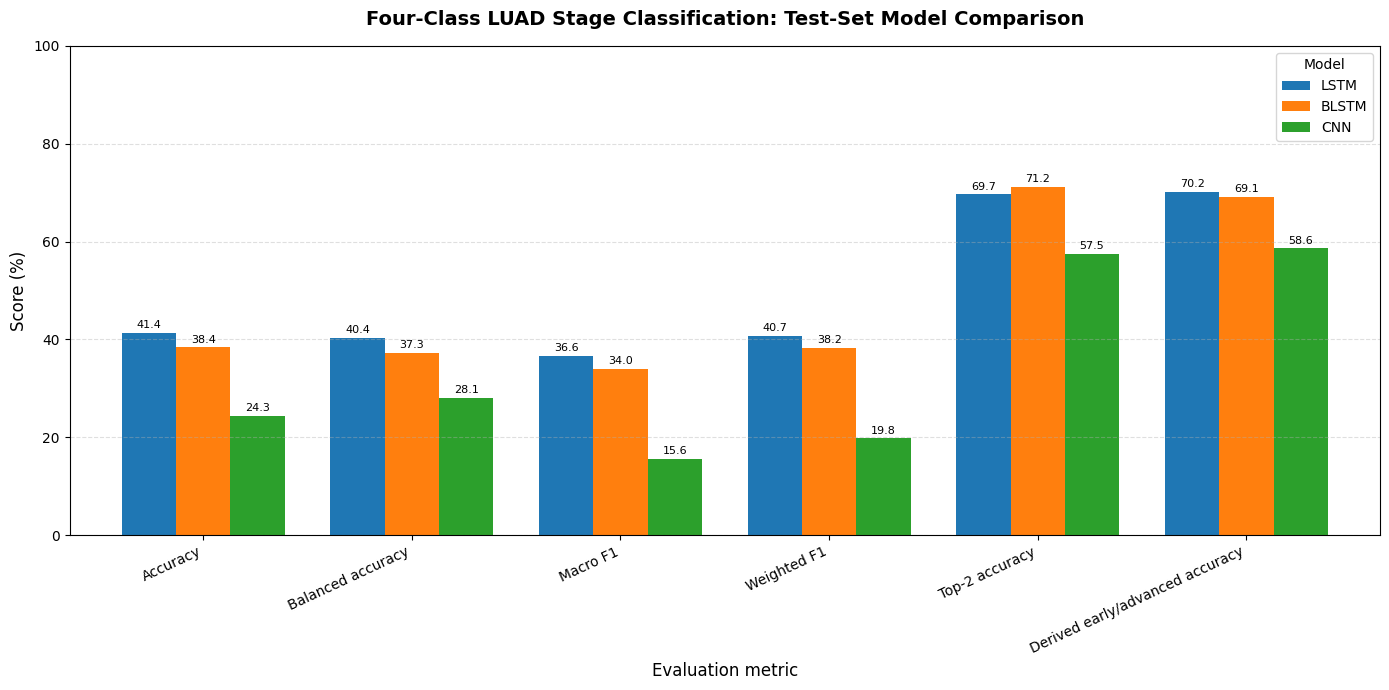

STEP 33 COMPLETED SUCCESSFULLY
Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_model_test_performance_comparison.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_model_test_performance_comparison.png
Created objects:
- four_class_model_comparison_df
- four_class_model_comparison_display_df


In [84]:
# ============================================================
# Step 33 — Comparative Visualization of Four-Class Stage-Classification Model Performance
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 33 — COMPARATIVE VISUALIZATION OF FOUR-CLASS STAGE-CLASSIFICATION MODEL PERFORMANCE")
print("=" * 100)

# ============================================================
# 1. Define project output paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
FIGURES_DIR = PROJECT_DIR / "final_luad_results" / "figures"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not FIGURES_DIR.exists():
    raise FileNotFoundError(f"Figures folder not found:\n{FIGURES_DIR}")

comparison_csv_path = RESULTS_DIR / "four_class_model_test_performance_comparison.csv"
comparison_figure_path = FIGURES_DIR / "four_class_model_test_performance_comparison.png"

print("-" * 100)
print("Output files")
print("-" * 100)
print(f"Comparison table : {comparison_csv_path}")
print(f"Comparison figure: {comparison_figure_path}")

# ============================================================
# 2. Define model performance file paths
# ============================================================

model_performance_files = {
    "LSTM": RESULTS_DIR / "four_class_lstm_train_validation_test_performance.csv",
    "BLSTM": RESULTS_DIR / "four_class_blstm_train_validation_test_performance.csv",
    "CNN": RESULTS_DIR / "four_class_cnn_train_validation_test_performance.csv",
}

missing_files = [
    f"{model_name}: {file_path}"
    for model_name, file_path in model_performance_files.items()
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following model performance files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nPlease complete evaluation for all three four-class models before creating comparison graphs."
    )

print("-" * 100)
print("All required model performance files found successfully.")

# ============================================================
# 3. Load test-set performance rows
# ============================================================

comparison_rows = []

for model_name, file_path in model_performance_files.items():
    performance_df = pd.read_csv(file_path)

    if "Split" not in performance_df.columns:
        raise KeyError(f"'Split' column not found in file:\n{file_path}")

    test_rows = performance_df[performance_df["Split"].astype(str).str.lower() == "test"]

    if len(test_rows) != 1:
        raise ValueError(
            f"Expected exactly one Test row for {model_name}, but found {len(test_rows)} rows.\n"
            f"File: {file_path}"
        )

    test_row = test_rows.iloc[0].copy()
    test_row["Model"] = model_name
    comparison_rows.append(test_row)

four_class_model_comparison_df = pd.DataFrame(comparison_rows)

# Keep professional metric order
selected_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Top2_Accuracy",
    "Derived_Early_Advanced_Accuracy",
]

missing_metric_columns = [
    metric for metric in selected_metrics
    if metric not in four_class_model_comparison_df.columns
]

if missing_metric_columns:
    raise KeyError(
        "Missing required metric columns:\n"
        + "\n".join(missing_metric_columns)
    )

four_class_model_comparison_df = four_class_model_comparison_df[
    ["Model", "Split"] + selected_metrics
].reset_index(drop=True)

# ============================================================
# 4. Prepare display and plotting tables
# ============================================================

four_class_model_comparison_display_df = four_class_model_comparison_df.copy()
four_class_model_comparison_display_df[selected_metrics] = (
    four_class_model_comparison_display_df[selected_metrics] * 100
).round(2)

four_class_model_comparison_display_df.to_csv(
    comparison_csv_path,
    index=False
)

print("=" * 100)
print("FOUR-CLASS MODEL TEST-SET PERFORMANCE COMPARISON (%)")
print("=" * 100)
display(four_class_model_comparison_display_df)

# ============================================================
# 5. Create grouped bar chart
# ============================================================

plot_df = four_class_model_comparison_display_df.set_index("Model")[selected_metrics]

metric_display_names = {
    "Accuracy": "Accuracy",
    "Balanced_Accuracy": "Balanced accuracy",
    "Macro_F1": "Macro F1",
    "Weighted_F1": "Weighted F1",
    "Top2_Accuracy": "Top-2 accuracy",
    "Derived_Early_Advanced_Accuracy": "Derived early/advanced accuracy",
}

plot_df = plot_df.rename(columns=metric_display_names)

ax = plot_df.T.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.78
)

ax.set_title(
    "Four-Class LUAD Stage Classification: Test-Set Model Comparison",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Evaluation metric", fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Model", frameon=True)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        fontsize=8,
        padding=2
    )

plt.tight_layout()

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 100)
print("STEP 33 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Saved files:")
print(f"- {comparison_csv_path}")
print(f"- {comparison_figure_path}")

print("=" * 100)
print("Created objects:")
print("- four_class_model_comparison_df")
print("- four_class_model_comparison_display_df")

# Step 34 — Test-Set Confusion Matrix Visualization for the Best Four-Class Stage-Classification Model

This step visualizes the test-set confusion matrix for the best four-class LUAD stage-classification model.

The best model is selected using test-set balanced accuracy because this metric evaluates performance across all four stages more fairly in the presence of class imbalance. The confusion matrix shows how many Stage I, Stage II, Stage III, and Stage IV patients were correctly or incorrectly classified.

STEP 34 — TEST-SET CONFUSION MATRIX VISUALIZATION FOR THE BEST FOUR-CLASS MODEL
----------------------------------------------------------------------------------------------------
Best model selected using test-set balanced accuracy
----------------------------------------------------------------------------------------------------
Best model                : LSTM
Test balanced accuracy    : 40.38%
----------------------------------------------------------------------------------------------------
Confusion matrix file
----------------------------------------------------------------------------------------------------
C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_test_confusion_matrix.csv
BEST MODEL TEST-SET CONFUSION MATRIX — COUNTS


,Stage I,Stage II,Stage III,Stage IV
Stage I,87,67,16,72
Stage II,24,19,14,15
Stage III,13,18,20,49
Stage IV,7,4,14,95


BEST MODEL TEST-SET CONFUSION MATRIX — ROW PERCENTAGE


,Stage I,Stage II,Stage III,Stage IV
Stage I,35.95,27.69,6.61,29.75
Stage II,33.33,26.39,19.44,20.83
Stage III,13.00,18.00,20.00,49.00
Stage IV,5.83,3.33,11.67,79.17


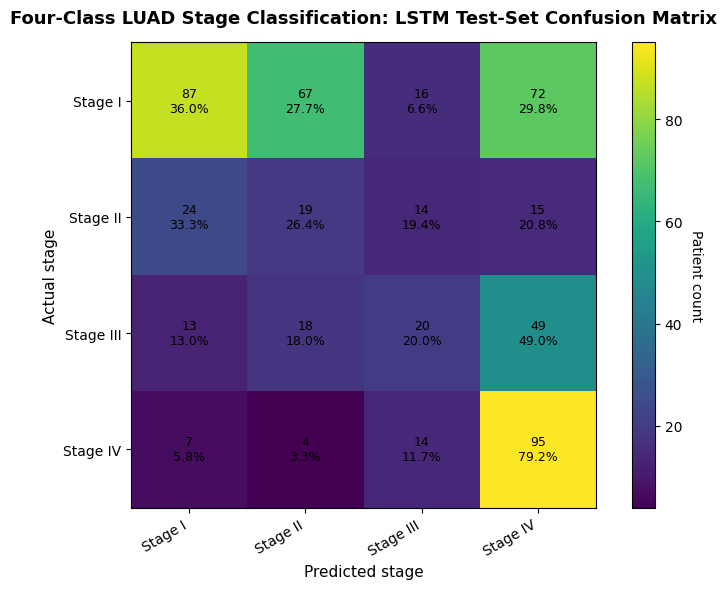

STEP 34 COMPLETED SUCCESSFULLY
Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_lstm_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_test_confusion_matrix_row_percentage.csv
Created objects:
- best_model_name
- best_confusion_matrix_df
- confusion_percentage_df


In [85]:
# ============================================================
# Step 34 — Test-Set Confusion Matrix Visualization for the Best Four-Class Stage-Classification Model
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 34 — TEST-SET CONFUSION MATRIX VISUALIZATION FOR THE BEST FOUR-CLASS MODEL")
print("=" * 100)

# ============================================================
# 1. Define project paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
FIGURES_DIR = PROJECT_DIR / "final_luad_results" / "figures"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not FIGURES_DIR.exists():
    raise FileNotFoundError(f"Figures folder not found:\n{FIGURES_DIR}")

comparison_csv_path = RESULTS_DIR / "four_class_model_test_performance_comparison.csv"

if not comparison_csv_path.exists():
    raise FileNotFoundError(
        "Four-class model comparison file not found.\n"
        f"Expected file:\n{comparison_csv_path}\n\n"
        "Please run Step 33 before running this step."
    )

# ============================================================
# 2. Load model comparison table and select best model
# ============================================================

comparison_df = pd.read_csv(comparison_csv_path)

required_columns = ["Model", "Balanced_Accuracy"]

missing_columns = [
    col for col in required_columns
    if col not in comparison_df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns in comparison table:\n"
        + "\n".join(missing_columns)
    )

best_model_row = comparison_df.sort_values(
    by="Balanced_Accuracy",
    ascending=False
).iloc[0]

best_model_name = str(best_model_row["Model"])
best_model_balanced_accuracy = float(best_model_row["Balanced_Accuracy"])

print("-" * 100)
print("Best model selected using test-set balanced accuracy")
print("-" * 100)
print(f"Best model                : {best_model_name}")
print(f"Test balanced accuracy    : {best_model_balanced_accuracy:.2f}%")

# ============================================================
# 3. Locate corresponding test confusion matrix file
# ============================================================

confusion_matrix_file_map = {
    "LSTM": RESULTS_DIR / "four_class_lstm_test_confusion_matrix.csv",
    "BLSTM": RESULTS_DIR / "four_class_blstm_test_confusion_matrix.csv",
    "CNN": RESULTS_DIR / "four_class_cnn_test_confusion_matrix.csv",
}

if best_model_name not in confusion_matrix_file_map:
    raise ValueError(
        f"Unknown model name found in comparison table: {best_model_name}\n"
        f"Expected one of: {list(confusion_matrix_file_map.keys())}"
    )

best_confusion_matrix_path = confusion_matrix_file_map[best_model_name]

if not best_confusion_matrix_path.exists():
    raise FileNotFoundError(
        "Confusion matrix file not found for best model.\n"
        f"Expected file:\n{best_confusion_matrix_path}"
    )

print("-" * 100)
print("Confusion matrix file")
print("-" * 100)
print(best_confusion_matrix_path)

# ============================================================
# 4. Load confusion matrix
# ============================================================

best_confusion_matrix_df = pd.read_csv(
    best_confusion_matrix_path,
    index_col=0
)

expected_shape = (4, 4)

if best_confusion_matrix_df.shape != expected_shape:
    raise ValueError(
        f"Expected confusion matrix shape {expected_shape}, "
        f"but found {best_confusion_matrix_df.shape}."
    )

stage_names = ["Stage I", "Stage II", "Stage III", "Stage IV"]

best_confusion_matrix_df.index = stage_names
best_confusion_matrix_df.columns = stage_names

confusion_counts = best_confusion_matrix_df.to_numpy(dtype=int)

row_totals = confusion_counts.sum(axis=1, keepdims=True)
confusion_percentages = np.divide(
    confusion_counts,
    row_totals,
    out=np.zeros_like(confusion_counts, dtype=float),
    where=row_totals != 0
) * 100

confusion_percentage_df = pd.DataFrame(
    confusion_percentages,
    index=stage_names,
    columns=stage_names
)

normalized_confusion_path = RESULTS_DIR / f"four_class_{best_model_name.lower()}_test_confusion_matrix_row_percentage.csv"

confusion_percentage_df.to_csv(
    normalized_confusion_path,
    index=True
)

print("=" * 100)
print("BEST MODEL TEST-SET CONFUSION MATRIX — COUNTS")
print("=" * 100)
display(best_confusion_matrix_df)

print("=" * 100)
print("BEST MODEL TEST-SET CONFUSION MATRIX — ROW PERCENTAGE")
print("=" * 100)
display(confusion_percentage_df.round(2))

# ============================================================
# 5. Create confusion matrix visualization
# ============================================================

figure_path = FIGURES_DIR / f"four_class_{best_model_name.lower()}_test_confusion_matrix.png"

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(confusion_counts)

ax.set_title(
    f"Four-Class LUAD Stage Classification: {best_model_name} Test-Set Confusion Matrix",
    fontsize=13,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Predicted stage", fontsize=11)
ax.set_ylabel("Actual stage", fontsize=11)

ax.set_xticks(np.arange(len(stage_names)))
ax.set_yticks(np.arange(len(stage_names)))
ax.set_xticklabels(stage_names, rotation=30, ha="right")
ax.set_yticklabels(stage_names)

for actual_index in range(confusion_counts.shape[0]):
    for predicted_index in range(confusion_counts.shape[1]):
        count_value = confusion_counts[actual_index, predicted_index]
        percentage_value = confusion_percentages[actual_index, predicted_index]

        ax.text(
            predicted_index,
            actual_index,
            f"{count_value}\n{percentage_value:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label("Patient count", rotation=270, labelpad=15)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 6. Final summary
# ============================================================

print("=" * 100)
print("STEP 34 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Saved files:")
print(f"- {figure_path}")
print(f"- {normalized_confusion_path}")

print("=" * 100)
print("Created objects:")
print("- best_model_name")
print("- best_confusion_matrix_df")
print("- confusion_percentage_df")

# Step 34 — Comparative Test-Set Confusion Matrix Visualization for Four-Class Stage-Classification Models

This step creates test-set confusion matrix visualizations for all three four-class LUAD stage-classification models: LSTM, BLSTM, and CNN.

Each confusion matrix shows how many Stage I, Stage II, Stage III, and Stage IV patients were correctly or incorrectly classified by each model. Row-wise percentages are also calculated to show the stage-wise prediction behavior of each model.

STEP 34 — COMPARATIVE TEST-SET CONFUSION MATRIX VISUALIZATION FOR FOUR-CLASS MODELS
All required confusion matrix files found successfully.
LSTM TEST-SET CONFUSION MATRIX
LSTM confusion matrix — counts


,Stage I,Stage II,Stage III,Stage IV
Stage I,87,67,16,72
Stage II,24,19,14,15
Stage III,13,18,20,49
Stage IV,7,4,14,95


LSTM confusion matrix — row percentages


,Stage I,Stage II,Stage III,Stage IV
Stage I,35.95,27.69,6.61,29.75
Stage II,33.33,26.39,19.44,20.83
Stage III,13.00,18.00,20.00,49.00
Stage IV,5.83,3.33,11.67,79.17


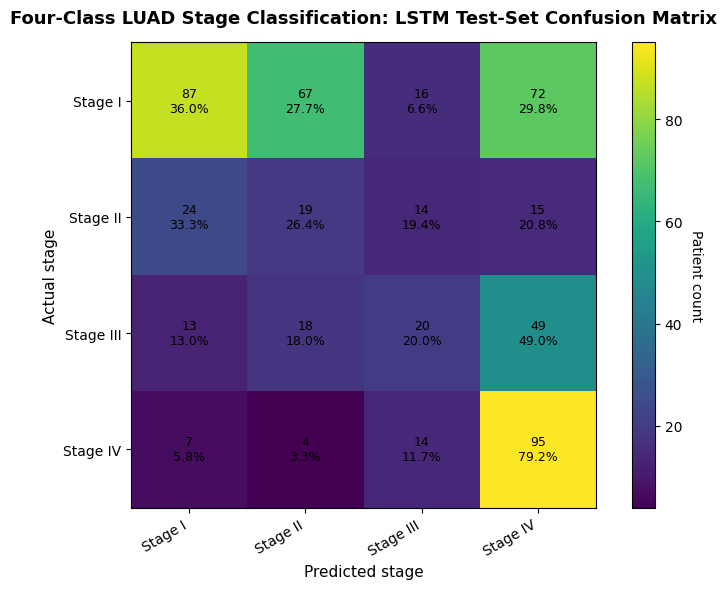

Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_lstm_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_test_confusion_matrix_row_percentage.csv
BLSTM TEST-SET CONFUSION MATRIX
BLSTM confusion matrix — counts


,Stage I,Stage II,Stage III,Stage IV
Stage I,85,71,24,62
Stage II,25,21,12,14
Stage III,15,23,15,47
Stage IV,10,5,21,84


BLSTM confusion matrix — row percentages


,Stage I,Stage II,Stage III,Stage IV
Stage I,35.12,29.34,9.92,25.62
Stage II,34.72,29.17,16.67,19.44
Stage III,15.00,23.00,15.00,47.00
Stage IV,8.33,4.17,17.50,70.00


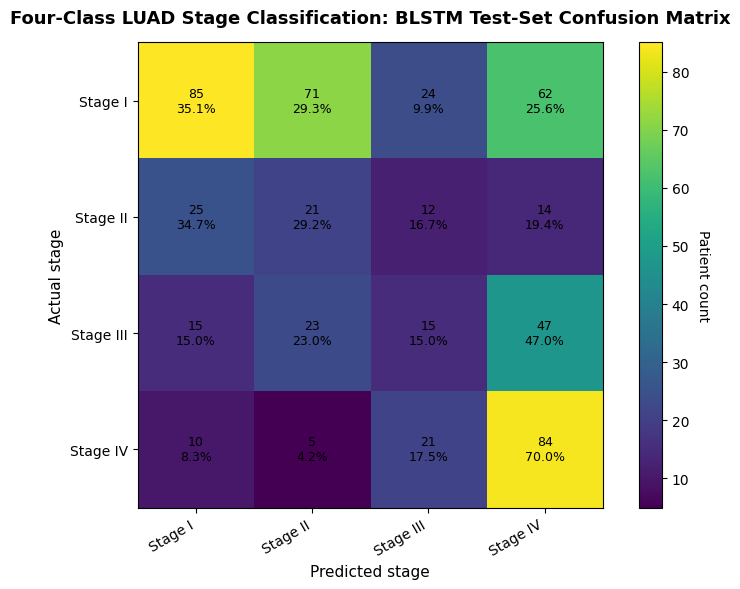

Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_blstm_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_test_confusion_matrix_row_percentage.csv
CNN TEST-SET CONFUSION MATRIX
CNN confusion matrix — counts


,Stage I,Stage II,Stage III,Stage IV
Stage I,70,168,4,0
Stage II,12,60,0,0
Stage III,28,72,0,0
Stage IV,41,76,3,0


CNN confusion matrix — row percentages


,Stage I,Stage II,Stage III,Stage IV
Stage I,28.93,69.42,1.65,0.0
Stage II,16.67,83.33,0.00,0.0
Stage III,28.00,72.00,0.00,0.0
Stage IV,34.17,63.33,2.50,0.0


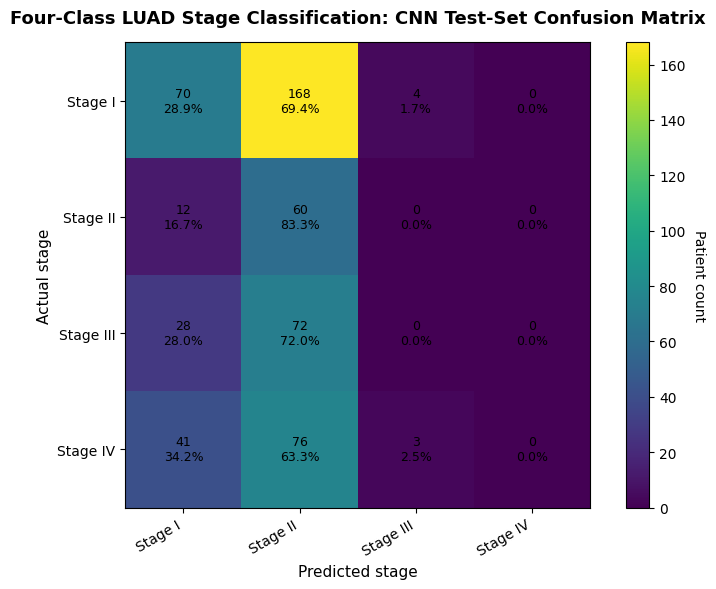

Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_cnn_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_test_confusion_matrix_row_percentage.csv
STEP 34 COMPLETED SUCCESSFULLY
Created confusion matrix visualizations for:
- LSTM
- BLSTM
- CNN
Created objects:
- four_class_confusion_matrix_tables
- four_class_confusion_percentage_tables


In [86]:
# ============================================================
# Step 34 — Comparative Test-Set Confusion Matrix Visualization for Four-Class Stage-Classification Models
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 34 — COMPARATIVE TEST-SET CONFUSION MATRIX VISUALIZATION FOR FOUR-CLASS MODELS")
print("=" * 100)

# ============================================================
# 1. Define project paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
FIGURES_DIR = PROJECT_DIR / "final_luad_results" / "figures"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not FIGURES_DIR.exists():
    raise FileNotFoundError(f"Figures folder not found:\n{FIGURES_DIR}")

# ============================================================
# 2. Define confusion matrix files for all models
# ============================================================

confusion_matrix_files = {
    "LSTM": RESULTS_DIR / "four_class_lstm_test_confusion_matrix.csv",
    "BLSTM": RESULTS_DIR / "four_class_blstm_test_confusion_matrix.csv",
    "CNN": RESULTS_DIR / "four_class_cnn_test_confusion_matrix.csv",
}

missing_files = [
    f"{model_name}: {file_path}"
    for model_name, file_path in confusion_matrix_files.items()
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following confusion matrix files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nPlease complete evaluation for LSTM, BLSTM, and CNN before running this step."
    )

print("All required confusion matrix files found successfully.")

# ============================================================
# 3. Define stage labels
# ============================================================

stage_names = ["Stage I", "Stage II", "Stage III", "Stage IV"]

# ============================================================
# 4. Load, display, and plot confusion matrices
# ============================================================

four_class_confusion_matrix_tables = {}
four_class_confusion_percentage_tables = {}

for model_name, confusion_matrix_path in confusion_matrix_files.items():

    print("=" * 100)
    print(f"{model_name} TEST-SET CONFUSION MATRIX")
    print("=" * 100)

    # ------------------------------------------------------------
    # Load confusion matrix
    # ------------------------------------------------------------

    confusion_df = pd.read_csv(
        confusion_matrix_path,
        index_col=0
    )

    if confusion_df.shape != (4, 4):
        raise ValueError(
            f"{model_name} confusion matrix should have shape (4, 4), "
            f"but found {confusion_df.shape}."
        )

    confusion_df.index = stage_names
    confusion_df.columns = stage_names

    confusion_counts = confusion_df.to_numpy(dtype=int)

    # ------------------------------------------------------------
    # Calculate row-wise percentages
    # ------------------------------------------------------------

    row_totals = confusion_counts.sum(axis=1, keepdims=True)

    confusion_percentages = np.divide(
        confusion_counts,
        row_totals,
        out=np.zeros_like(confusion_counts, dtype=float),
        where=row_totals != 0
    ) * 100

    confusion_percentage_df = pd.DataFrame(
        confusion_percentages,
        index=stage_names,
        columns=stage_names
    )

    four_class_confusion_matrix_tables[model_name] = confusion_df
    four_class_confusion_percentage_tables[model_name] = confusion_percentage_df

    # ------------------------------------------------------------
    # Save row-percentage confusion matrix
    # ------------------------------------------------------------

    percentage_output_path = RESULTS_DIR / f"four_class_{model_name.lower()}_test_confusion_matrix_row_percentage.csv"

    confusion_percentage_df.to_csv(
        percentage_output_path,
        index=True
    )

    # ------------------------------------------------------------
    # Display tables
    # ------------------------------------------------------------

    print(f"{model_name} confusion matrix — counts")
    display(confusion_df)

    print(f"{model_name} confusion matrix — row percentages")
    display(confusion_percentage_df.round(2))

    # ------------------------------------------------------------
    # Plot confusion matrix
    # ------------------------------------------------------------

    figure_path = FIGURES_DIR / f"four_class_{model_name.lower()}_test_confusion_matrix.png"

    fig, ax = plt.subplots(figsize=(8, 6))

    image = ax.imshow(confusion_counts)

    ax.set_title(
        f"Four-Class LUAD Stage Classification: {model_name} Test-Set Confusion Matrix",
        fontsize=13,
        fontweight="bold",
        pad=14
    )

    ax.set_xlabel("Predicted stage", fontsize=11)
    ax.set_ylabel("Actual stage", fontsize=11)

    ax.set_xticks(np.arange(len(stage_names)))
    ax.set_yticks(np.arange(len(stage_names)))
    ax.set_xticklabels(stage_names, rotation=30, ha="right")
    ax.set_yticklabels(stage_names)

    for actual_index in range(confusion_counts.shape[0]):
        for predicted_index in range(confusion_counts.shape[1]):
            count_value = confusion_counts[actual_index, predicted_index]
            percentage_value = confusion_percentages[actual_index, predicted_index]

            ax.text(
                predicted_index,
                actual_index,
                f"{count_value}\n{percentage_value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label("Patient count", rotation=270, labelpad=15)

    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved files:")
    print(f"- {figure_path}")
    print(f"- {percentage_output_path}")

# ============================================================
# 5. Final summary
# ============================================================

print("=" * 100)
print("STEP 34 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("Created confusion matrix visualizations for:")
print("- LSTM")
print("- BLSTM")
print("- CNN")

print("=" * 100)
print("Created objects:")
print("- four_class_confusion_matrix_tables")
print("- four_class_confusion_percentage_tables")

# Step 35 — Comparative Training Dynamics Visualization for Four-Class Stage-Classification Models

This step visualizes the training behavior of the four-class LSTM, BLSTM, and CNN models.

The plots compare validation loss, validation accuracy, and validation top-2 accuracy across training epochs. These curves help explain whether each model improved during training, stopped early, overfitted, or underfitted.

STEP 35 — COMPARATIVE TRAINING DYNAMICS VISUALIZATION FOR FOUR-CLASS MODELS
----------------------------------------------------------------------------------------------------
Output files
----------------------------------------------------------------------------------------------------
Combined history table       : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_model_training_dynamics_comparison.csv
Validation loss figure       : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_validation_loss_comparison.png
Validation accuracy figure   : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_validation_accuracy_comparison.png
Validation top-2 figure      : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_validation_top2_accuracy_comparison.png
----------------------------------------------------------------------------------------------------
All require

,Model,Total_Epochs,Best_Val_Loss_Epoch,Best_Val_Loss,Best_Val_Accuracy,Best_Val_Top2_Accuracy
0,LSTM,20,17,1.2123,0.4401,0.7228
1,BLSTM,9,7,1.2091,0.4419,0.7360
2,CNN,8,6,1.4032,0.2154,0.5805


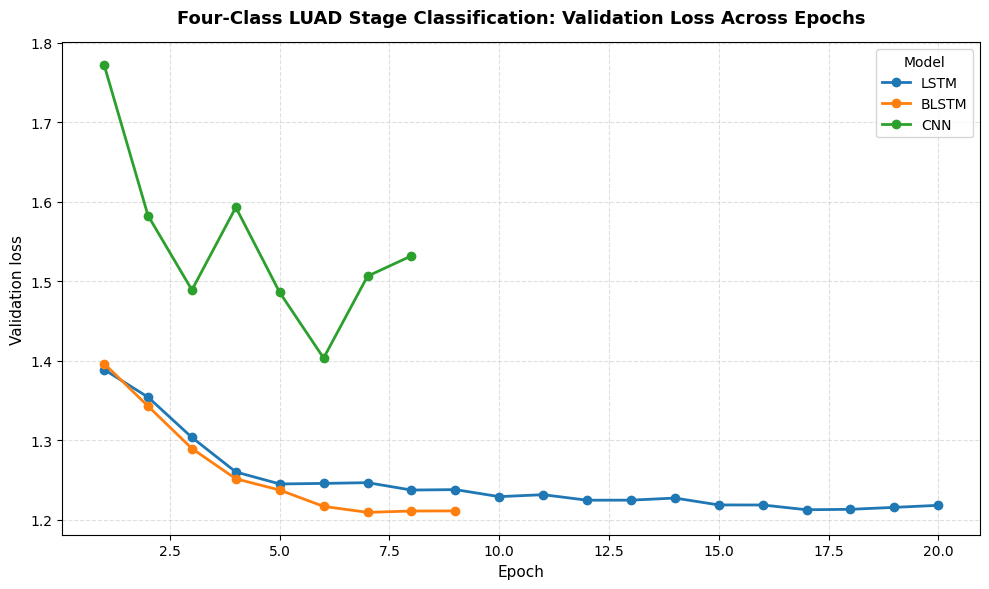

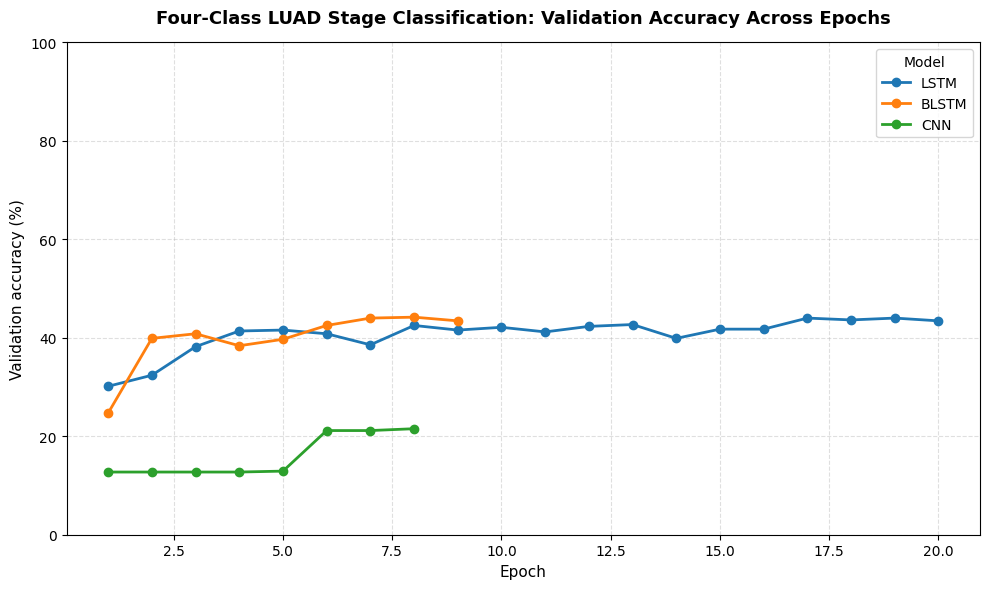

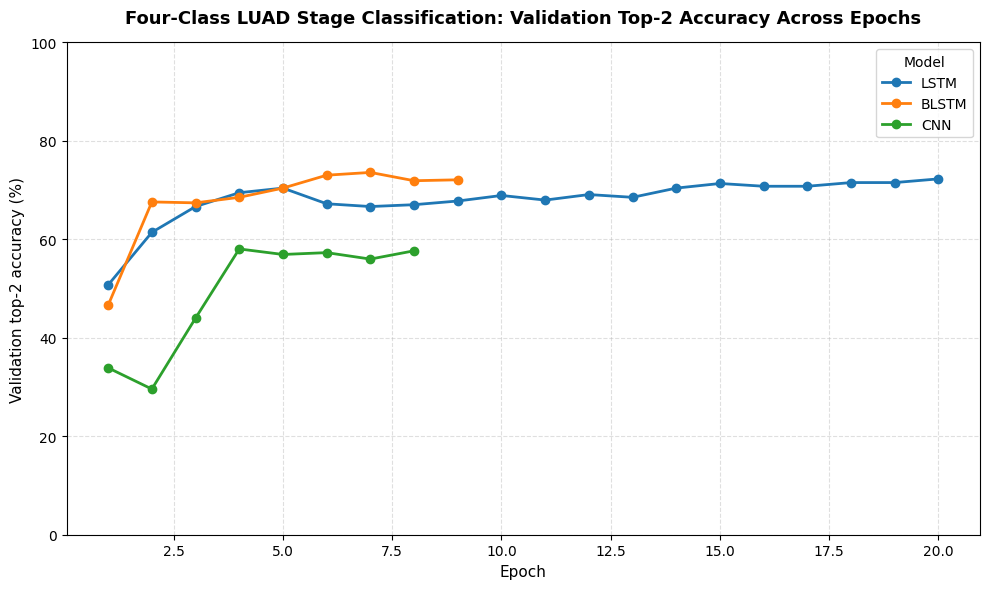

STEP 35 COMPLETED SUCCESSFULLY
Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_model_training_dynamics_comparison.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_validation_loss_comparison.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_validation_accuracy_comparison.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_validation_top2_accuracy_comparison.png
Created objects:
- four_class_training_dynamics_df
- four_class_training_summary_df


In [87]:
# ============================================================
# Step 35 — Comparative Training Dynamics Visualization for Four-Class Stage-Classification Models
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 35 — COMPARATIVE TRAINING DYNAMICS VISUALIZATION FOR FOUR-CLASS MODELS")
print("=" * 100)

# ============================================================
# 1. Define project paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
FIGURES_DIR = PROJECT_DIR / "final_luad_results" / "figures"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not FIGURES_DIR.exists():
    raise FileNotFoundError(f"Figures folder not found:\n{FIGURES_DIR}")

combined_history_path = RESULTS_DIR / "four_class_model_training_dynamics_comparison.csv"

validation_loss_figure_path = FIGURES_DIR / "four_class_validation_loss_comparison.png"
validation_accuracy_figure_path = FIGURES_DIR / "four_class_validation_accuracy_comparison.png"
validation_top2_figure_path = FIGURES_DIR / "four_class_validation_top2_accuracy_comparison.png"

print("-" * 100)
print("Output files")
print("-" * 100)
print(f"Combined history table       : {combined_history_path}")
print(f"Validation loss figure       : {validation_loss_figure_path}")
print(f"Validation accuracy figure   : {validation_accuracy_figure_path}")
print(f"Validation top-2 figure      : {validation_top2_figure_path}")

# ============================================================
# 2. Define history files
# ============================================================

history_files = {
    "LSTM": RESULTS_DIR / "four_class_lstm_training_history.csv",
    "BLSTM": RESULTS_DIR / "four_class_blstm_training_history.csv",
    "CNN": RESULTS_DIR / "four_class_cnn_training_history.csv",
}

missing_files = [
    f"{model_name}: {file_path}"
    for model_name, file_path in history_files.items()
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following training history files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nPlease complete training for all three four-class models before running this step."
    )

print("-" * 100)
print("All required training history files found successfully.")

# ============================================================
# 3. Load training history files
# ============================================================

history_tables = []

for model_name, history_path in history_files.items():
    history_df = pd.read_csv(history_path)

    if "Epoch" not in history_df.columns:
        history_df.insert(0, "Epoch", np.arange(1, len(history_df) + 1))

    required_columns = [
        "Epoch",
        "loss",
        "accuracy",
        "top2_accuracy",
        "val_loss",
        "val_accuracy",
        "val_top2_accuracy",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in history_df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns in {model_name} history file:\n"
            + "\n".join(missing_columns)
            + f"\n\nFile: {history_path}"
        )

    history_df = history_df[required_columns].copy()
    history_df.insert(0, "Model", model_name)

    history_tables.append(history_df)

four_class_training_dynamics_df = pd.concat(
    history_tables,
    ignore_index=True
)

four_class_training_dynamics_df.to_csv(
    combined_history_path,
    index=False
)

print("=" * 100)
print("FOUR-CLASS MODEL TRAINING HISTORY SUMMARY")
print("=" * 100)

summary_rows = []

for model_name in history_files.keys():
    model_history = four_class_training_dynamics_df[
        four_class_training_dynamics_df["Model"] == model_name
    ].copy()

    best_val_loss_epoch = int(model_history.loc[model_history["val_loss"].idxmin(), "Epoch"])
    best_val_loss = float(model_history["val_loss"].min())
    best_val_accuracy = float(model_history["val_accuracy"].max())
    best_val_top2_accuracy = float(model_history["val_top2_accuracy"].max())
    total_epochs = int(model_history["Epoch"].max())

    summary_rows.append({
        "Model": model_name,
        "Total_Epochs": total_epochs,
        "Best_Val_Loss_Epoch": best_val_loss_epoch,
        "Best_Val_Loss": best_val_loss,
        "Best_Val_Accuracy": best_val_accuracy,
        "Best_Val_Top2_Accuracy": best_val_top2_accuracy,
    })

four_class_training_summary_df = pd.DataFrame(summary_rows)

display(
    four_class_training_summary_df.round({
        "Best_Val_Loss": 4,
        "Best_Val_Accuracy": 4,
        "Best_Val_Top2_Accuracy": 4,
    })
)

# ============================================================
# 4. Plot validation loss comparison
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in history_files.keys():
    model_history = four_class_training_dynamics_df[
        four_class_training_dynamics_df["Model"] == model_name
    ]

    plt.plot(
        model_history["Epoch"],
        model_history["val_loss"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.title(
    "Four-Class LUAD Stage Classification: Validation Loss Across Epochs",
    fontsize=13,
    fontweight="bold",
    pad=14
)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Validation loss", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    validation_loss_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 5. Plot validation accuracy comparison
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in history_files.keys():
    model_history = four_class_training_dynamics_df[
        four_class_training_dynamics_df["Model"] == model_name
    ]

    plt.plot(
        model_history["Epoch"],
        model_history["val_accuracy"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.title(
    "Four-Class LUAD Stage Classification: Validation Accuracy Across Epochs",
    fontsize=13,
    fontweight="bold",
    pad=14
)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Validation accuracy (%)", fontsize=11)
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    validation_accuracy_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 6. Plot validation top-2 accuracy comparison
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in history_files.keys():
    model_history = four_class_training_dynamics_df[
        four_class_training_dynamics_df["Model"] == model_name
    ]

    plt.plot(
        model_history["Epoch"],
        model_history["val_top2_accuracy"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.title(
    "Four-Class LUAD Stage Classification: Validation Top-2 Accuracy Across Epochs",
    fontsize=13,
    fontweight="bold",
    pad=14
)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Validation top-2 accuracy (%)", fontsize=11)
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    validation_top2_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 7. Final summary
# ============================================================

print("=" * 100)
print("STEP 35 COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Saved files:")
print(f"- {combined_history_path}")
print(f"- {validation_loss_figure_path}")
print(f"- {validation_accuracy_figure_path}")
print(f"- {validation_top2_figure_path}")

print("=" * 100)
print("Created objects:")
print("- four_class_training_dynamics_df")
print("- four_class_training_summary_df")

# Step 35 — Comparative Test-Set Confusion Matrix Visualization for Four-Class Stage-Classification Models

This step creates test-set confusion matrix visualizations for all three four-class LUAD stage-classification models: LSTM, BLSTM, and CNN.

Each confusion matrix shows how Stage I, Stage II, Stage III, and Stage IV patients were classified by each model. The diagonal values represent correct predictions, while off-diagonal values represent stage-level misclassifications.

STEP 35 — COMPARATIVE TEST-SET CONFUSION MATRIX VISUALIZATION FOR FOUR-CLASS MODELS
All required confusion matrix files found successfully.
LSTM — TEST-SET CONFUSION MATRIX
LSTM confusion matrix — counts


,Stage I,Stage II,Stage III,Stage IV
Stage I,87,67,16,72
Stage II,24,19,14,15
Stage III,13,18,20,49
Stage IV,7,4,14,95


LSTM confusion matrix — row percentage


,Stage I,Stage II,Stage III,Stage IV
Stage I,35.95,27.69,6.61,29.75
Stage II,33.33,26.39,19.44,20.83
Stage III,13.00,18.00,20.00,49.00
Stage IV,5.83,3.33,11.67,79.17


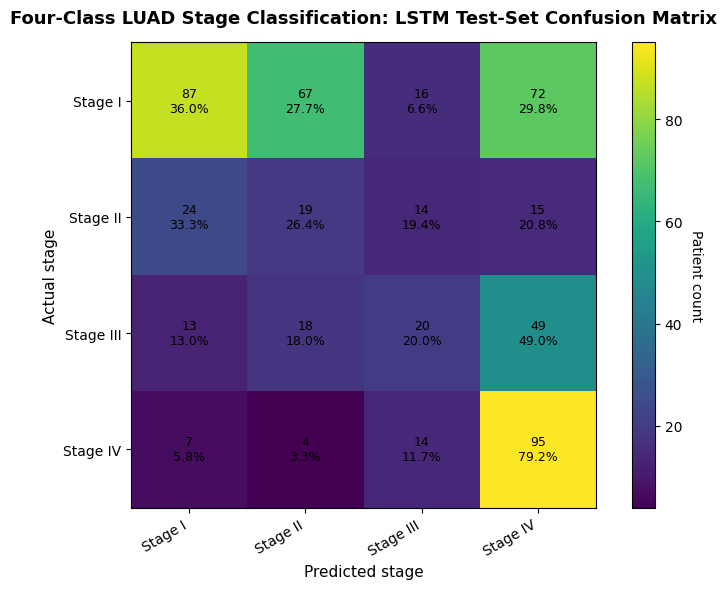

Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_lstm_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_lstm_test_confusion_matrix_row_percentage.csv
BLSTM — TEST-SET CONFUSION MATRIX
BLSTM confusion matrix — counts


,Stage I,Stage II,Stage III,Stage IV
Stage I,85,71,24,62
Stage II,25,21,12,14
Stage III,15,23,15,47
Stage IV,10,5,21,84


BLSTM confusion matrix — row percentage


,Stage I,Stage II,Stage III,Stage IV
Stage I,35.12,29.34,9.92,25.62
Stage II,34.72,29.17,16.67,19.44
Stage III,15.00,23.00,15.00,47.00
Stage IV,8.33,4.17,17.50,70.00


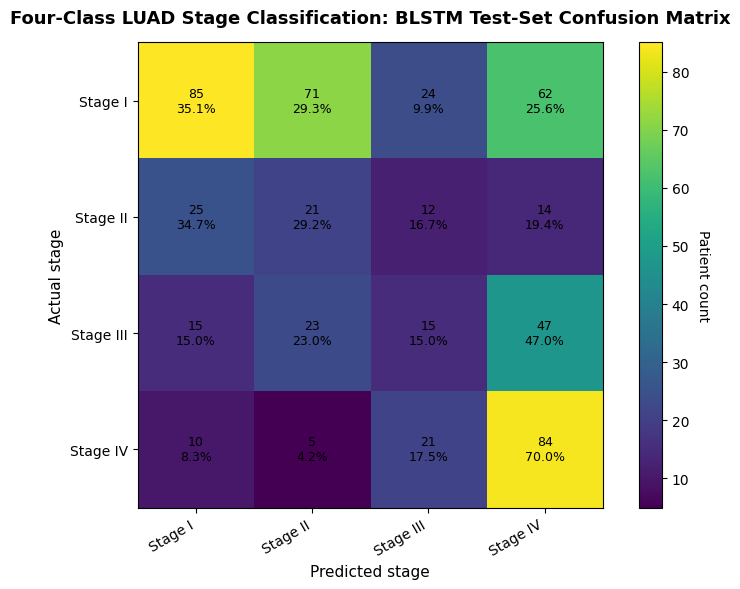

Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_blstm_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_blstm_test_confusion_matrix_row_percentage.csv
CNN — TEST-SET CONFUSION MATRIX
CNN confusion matrix — counts


,Stage I,Stage II,Stage III,Stage IV
Stage I,70,168,4,0
Stage II,12,60,0,0
Stage III,28,72,0,0
Stage IV,41,76,3,0


CNN confusion matrix — row percentage


,Stage I,Stage II,Stage III,Stage IV
Stage I,28.93,69.42,1.65,0.0
Stage II,16.67,83.33,0.00,0.0
Stage III,28.00,72.00,0.00,0.0
Stage IV,34.17,63.33,2.50,0.0


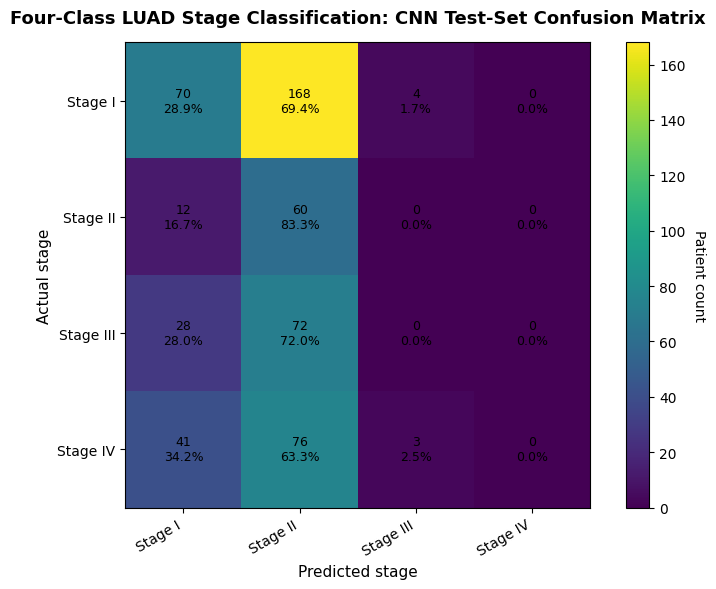

Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_cnn_test_confusion_matrix.png
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_cnn_test_confusion_matrix_row_percentage.csv
COMBINED LONG-FORMAT CONFUSION MATRIX TABLE


,Model,Actual_Stage,Predicted_Stage,Count,Row_Percentage
0,LSTM,Stage I,Stage I,87,35.950413
1,LSTM,Stage I,Stage II,67,27.685950
2,LSTM,Stage I,Stage III,16,6.611570
3,LSTM,Stage I,Stage IV,72,29.752066
4,LSTM,Stage II,Stage I,24,33.333333
5,LSTM,Stage II,Stage II,19,26.388889
6,LSTM,Stage II,Stage III,14,19.444444
7,LSTM,Stage II,Stage IV,15,20.833333
8,LSTM,Stage III,Stage I,13,13.000000
9,LSTM,Stage III,Stage II,18,18.000000


STEP 35 COMPLETED SUCCESSFULLY
Created test-set confusion matrix visualizations for:
- LSTM
- BLSTM
- CNN

Saved combined table:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_all_models_test_confusion_matrix_long_format.csv

Created objects:
- four_class_confusion_matrix_tables
- four_class_confusion_percentage_tables
- four_class_confusion_long_format_df


In [88]:
# ============================================================
# Step 35 — Comparative Test-Set Confusion Matrix Visualization for Four-Class Stage-Classification Models
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("STEP 35 — COMPARATIVE TEST-SET CONFUSION MATRIX VISUALIZATION FOR FOUR-CLASS MODELS")
print("=" * 100)

# ============================================================
# 1. Define project paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
FIGURES_DIR = PROJECT_DIR / "final_luad_results" / "figures"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not FIGURES_DIR.exists():
    raise FileNotFoundError(f"Figures folder not found:\n{FIGURES_DIR}")

# ============================================================
# 2. Define confusion matrix files
# ============================================================

confusion_matrix_files = {
    "LSTM": RESULTS_DIR / "four_class_lstm_test_confusion_matrix.csv",
    "BLSTM": RESULTS_DIR / "four_class_blstm_test_confusion_matrix.csv",
    "CNN": RESULTS_DIR / "four_class_cnn_test_confusion_matrix.csv",
}

missing_files = [
    f"{model_name}: {file_path}"
    for model_name, file_path in confusion_matrix_files.items()
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing confusion matrix files:\n"
        + "\n".join(missing_files)
        + "\n\nPlease complete four-class evaluation for LSTM, BLSTM, and CNN first."
    )

print("All required confusion matrix files found successfully.")

# ============================================================
# 3. Define stage labels
# ============================================================

stage_names = ["Stage I", "Stage II", "Stage III", "Stage IV"]

# ============================================================
# 4. Load, normalize, display, and plot confusion matrices
# ============================================================

four_class_confusion_matrix_tables = {}
four_class_confusion_percentage_tables = {}
confusion_long_format_rows = []

for model_name, confusion_matrix_path in confusion_matrix_files.items():

    print("=" * 100)
    print(f"{model_name} — TEST-SET CONFUSION MATRIX")
    print("=" * 100)

    # ------------------------------------------------------------
    # Load confusion matrix
    # ------------------------------------------------------------

    confusion_df = pd.read_csv(confusion_matrix_path, index_col=0)

    if confusion_df.shape != (4, 4):
        raise ValueError(
            f"{model_name} confusion matrix should have shape (4, 4), "
            f"but found {confusion_df.shape}."
        )

    confusion_df.index = stage_names
    confusion_df.columns = stage_names

    confusion_counts = confusion_df.to_numpy(dtype=int)

    # ------------------------------------------------------------
    # Calculate row-wise percentages
    # ------------------------------------------------------------

    row_totals = confusion_counts.sum(axis=1, keepdims=True)

    confusion_percentages = np.divide(
        confusion_counts,
        row_totals,
        out=np.zeros_like(confusion_counts, dtype=float),
        where=row_totals != 0
    ) * 100

    confusion_percentage_df = pd.DataFrame(
        confusion_percentages,
        index=stage_names,
        columns=stage_names
    )

    four_class_confusion_matrix_tables[model_name] = confusion_df
    four_class_confusion_percentage_tables[model_name] = confusion_percentage_df

    # ------------------------------------------------------------
    # Save row-wise percentage table
    # ------------------------------------------------------------

    percentage_output_path = RESULTS_DIR / f"four_class_{model_name.lower()}_test_confusion_matrix_row_percentage.csv"

    confusion_percentage_df.to_csv(
        percentage_output_path,
        index=True
    )

    # ------------------------------------------------------------
    # Build long-format comparison table
    # ------------------------------------------------------------

    for actual_stage in stage_names:
        for predicted_stage in stage_names:
            confusion_long_format_rows.append({
                "Model": model_name,
                "Actual_Stage": actual_stage,
                "Predicted_Stage": predicted_stage,
                "Count": int(confusion_df.loc[actual_stage, predicted_stage]),
                "Row_Percentage": float(confusion_percentage_df.loc[actual_stage, predicted_stage]),
            })

    # ------------------------------------------------------------
    # Display count and percentage tables
    # ------------------------------------------------------------

    print(f"{model_name} confusion matrix — counts")
    display(confusion_df)

    print(f"{model_name} confusion matrix — row percentage")
    display(confusion_percentage_df.round(2))

    # ------------------------------------------------------------
    # Plot confusion matrix
    # ------------------------------------------------------------

    figure_path = FIGURES_DIR / f"four_class_{model_name.lower()}_test_confusion_matrix.png"

    fig, ax = plt.subplots(figsize=(8, 6))

    image = ax.imshow(confusion_counts)

    ax.set_title(
        f"Four-Class LUAD Stage Classification: {model_name} Test-Set Confusion Matrix",
        fontsize=13,
        fontweight="bold",
        pad=14
    )

    ax.set_xlabel("Predicted stage", fontsize=11)
    ax.set_ylabel("Actual stage", fontsize=11)

    ax.set_xticks(np.arange(len(stage_names)))
    ax.set_yticks(np.arange(len(stage_names)))
    ax.set_xticklabels(stage_names, rotation=30, ha="right")
    ax.set_yticklabels(stage_names)

    for actual_index in range(confusion_counts.shape[0]):
        for predicted_index in range(confusion_counts.shape[1]):
            count_value = confusion_counts[actual_index, predicted_index]
            percentage_value = confusion_percentages[actual_index, predicted_index]

            ax.text(
                predicted_index,
                actual_index,
                f"{count_value}\n{percentage_value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label("Patient count", rotation=270, labelpad=15)

    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved files:")
    print(f"- {figure_path}")
    print(f"- {percentage_output_path}")

# ============================================================
# 5. Save combined long-format confusion matrix table
# ============================================================

four_class_confusion_long_format_df = pd.DataFrame(confusion_long_format_rows)

combined_confusion_path = RESULTS_DIR / "four_class_all_models_test_confusion_matrix_long_format.csv"

four_class_confusion_long_format_df.to_csv(
    combined_confusion_path,
    index=False
)

print("=" * 100)
print("COMBINED LONG-FORMAT CONFUSION MATRIX TABLE")
print("=" * 100)
display(four_class_confusion_long_format_df.head(20))

# ============================================================
# 6. Final summary
# ============================================================

print("=" * 100)
print("STEP 35 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("Created test-set confusion matrix visualizations for:")
print("- LSTM")
print("- BLSTM")
print("- CNN")

print("\nSaved combined table:")
print(f"- {combined_confusion_path}")

print("\nCreated objects:")
print("- four_class_confusion_matrix_tables")
print("- four_class_confusion_percentage_tables")
print("- four_class_confusion_long_format_df")

# Step 36 — Test-Set Macro-Average ROC Curve Comparison for Four-Class Stage-Classification Models

This step creates a test-set ROC curve comparison for the four-class LUAD stage-classification models.

Because the task contains four classes, ROC-AUC is calculated using a one-vs-rest strategy for Stage I, Stage II, Stage III, and Stage IV. A macro-average ROC curve is then generated for each model to compare the overall stage-discrimination ability of LSTM, BLSTM, and CNN on the independent test set.

STEP 36 — TEST-SET MACRO-AVERAGE ROC CURVE COMPARISON FOR FOUR-CLASS MODELS
----------------------------------------------------------------------------------------------------
Output files
----------------------------------------------------------------------------------------------------
ROC-AUC comparison table : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_model_test_macro_roc_auc_comparison.csv
ROC curve figure         : C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_model_test_macro_roc_curve_comparison.png
True test-label objects validated successfully.
All required prediction files found successfully.
----------------------------------------------------------------------------------------------------
LSTM
Test labels shape       : (534,)
Test probabilities shape: (534, 4)
----------------------------------------------------------------------------------------------------
BLSTM
Test labels shape       : (534

,Model,ROC_Type,Stage_Label,Stage_Name,ROC_AUC
0,LSTM,One-vs-Rest,0,Stage I,0.6996
1,LSTM,One-vs-Rest,1,Stage II,0.6585
2,LSTM,One-vs-Rest,2,Stage III,0.5854
3,LSTM,One-vs-Rest,3,Stage IV,0.8081
4,LSTM,Macro-Average,All,Macro-average,0.6878
5,BLSTM,One-vs-Rest,0,Stage I,0.6962
6,BLSTM,One-vs-Rest,1,Stage II,0.6546
7,BLSTM,One-vs-Rest,2,Stage III,0.5988
8,BLSTM,One-vs-Rest,3,Stage IV,0.7912
9,BLSTM,Macro-Average,All,Macro-average,0.6851


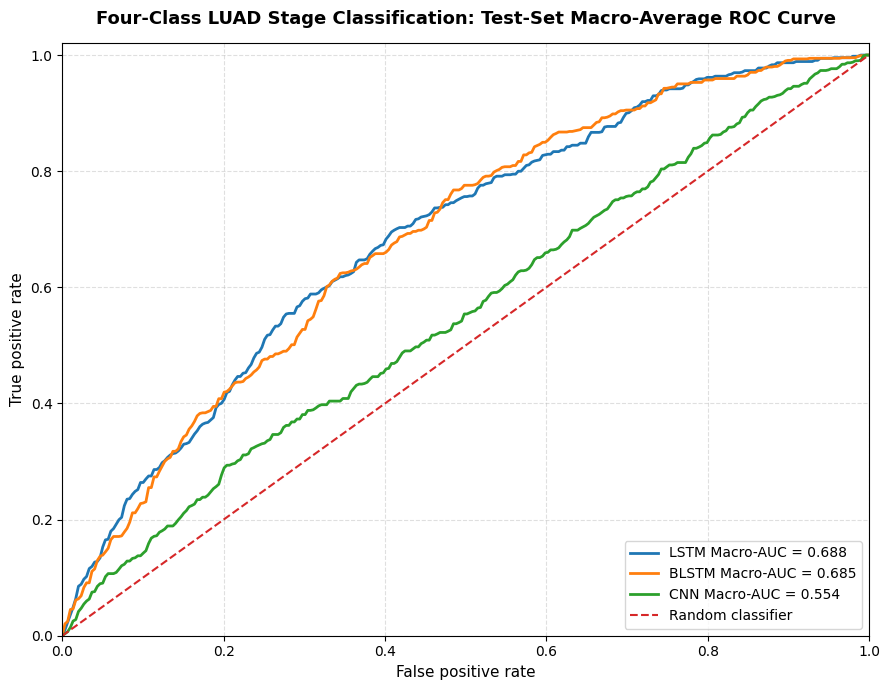

MACRO-AVERAGE ROC-AUC SUMMARY


,Model,Stage_Name,ROC_AUC
4,LSTM,Macro-average,0.6878
9,BLSTM,Macro-average,0.6851
14,CNN,Macro-average,0.5537


STEP 36 COMPLETED SUCCESSFULLY
Saved files:
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\results\four_class_model_test_macro_roc_auc_comparison.csv
- C:\Users\LAPTOP\Downloads\luad_reserch_code\final_luad_results\figures\four_class_model_test_macro_roc_curve_comparison.png

Created objects:
- four_class_roc_auc_comparison_df
- four_class_roc_auc_display_df
- macro_roc_curves
- macro_auc_summary_df


In [91]:
# ============================================================
# Step 36 — Test-Set Macro-Average ROC Curve Comparison for Four-Class Stage-Classification Models
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("=" * 100)
print("STEP 36 — TEST-SET MACRO-AVERAGE ROC CURVE COMPARISON FOR FOUR-CLASS MODELS")
print("=" * 100)

# ============================================================
# 1. Define project paths
# ============================================================

PROJECT_DIR = Path(r"C:\Users\LAPTOP\Downloads\luad_reserch_code")
RESULTS_DIR = PROJECT_DIR / "final_luad_results" / "results"
FIGURES_DIR = PROJECT_DIR / "final_luad_results" / "figures"

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found:\n{RESULTS_DIR}")

if not FIGURES_DIR.exists():
    raise FileNotFoundError(f"Figures folder not found:\n{FIGURES_DIR}")

roc_auc_table_path = RESULTS_DIR / "four_class_model_test_macro_roc_auc_comparison.csv"
roc_curve_figure_path = FIGURES_DIR / "four_class_model_test_macro_roc_curve_comparison.png"

print("-" * 100)
print("Output files")
print("-" * 100)
print(f"ROC-AUC comparison table : {roc_auc_table_path}")
print(f"ROC curve figure         : {roc_curve_figure_path}")

# ============================================================
# 2. Validate true test-label objects
# ============================================================

required_label_objects = [
    "four_class_lstm_test_labels",
    "four_class_blstm_test_labels",
    "four_class_cnn_test_labels",
]

missing_label_objects = [
    obj for obj in required_label_objects
    if obj not in globals()
]

if missing_label_objects:
    raise RuntimeError(
        "Missing required test-label objects:\n"
        + "\n".join(missing_label_objects)
        + "\n\nPlease run the four-class evaluation steps for LSTM, BLSTM, and CNN first."
    )

test_label_objects = {
    "LSTM": np.asarray(four_class_lstm_test_labels, dtype=np.int32),
    "BLSTM": np.asarray(four_class_blstm_test_labels, dtype=np.int32),
    "CNN": np.asarray(four_class_cnn_test_labels, dtype=np.int32),
}

for model_name, labels in test_label_objects.items():
    unique_labels = sorted(np.unique(labels).tolist())

    if unique_labels != [0, 1, 2, 3]:
        raise ValueError(
            f"{model_name} test labels must contain all four classes [0, 1, 2, 3]. "
            f"Found: {unique_labels}"
        )

print("True test-label objects validated successfully.")

# ============================================================
# 3. Define prediction files
# ============================================================

prediction_files = {
    "LSTM": RESULTS_DIR / "four_class_lstm_train_validation_test_predictions.csv",
    "BLSTM": RESULTS_DIR / "four_class_blstm_train_validation_test_predictions.csv",
    "CNN": RESULTS_DIR / "four_class_cnn_train_validation_test_predictions.csv",
}

missing_prediction_files = [
    f"{model_name}: {file_path}"
    for model_name, file_path in prediction_files.items()
    if not file_path.exists()
]

if missing_prediction_files:
    raise FileNotFoundError(
        "Missing prediction files:\n"
        + "\n".join(missing_prediction_files)
        + "\n\nPlease complete four-class evaluation for LSTM, BLSTM, and CNN first."
    )

print("All required prediction files found successfully.")

# ============================================================
# 4. Define stage labels and probability columns
# ============================================================

stage_label_order = [0, 1, 2, 3]

stage_name_map = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV",
}

probability_columns = [
    "Probability_Stage_I",
    "Probability_Stage_II",
    "Probability_Stage_III",
    "Probability_Stage_IV",
]

# ============================================================
# 5. Calculate one-vs-rest ROC-AUC and macro-average ROC curves
# ============================================================

roc_auc_rows = []
macro_roc_curves = {}

mean_fpr = np.linspace(0, 1, 300)

for model_name, prediction_path in prediction_files.items():

    prediction_df = pd.read_csv(prediction_path)

    if "Split" not in prediction_df.columns:
        raise KeyError(
            f"'Split' column not found in {model_name} prediction file:\n{prediction_path}"
        )

    missing_probability_columns = [
        col for col in probability_columns
        if col not in prediction_df.columns
    ]

    if missing_probability_columns:
        print("=" * 100)
        print(f"Available columns in {model_name} prediction file:")
        print("=" * 100)
        print(prediction_df.columns.tolist())

        raise KeyError(
            f"Missing probability columns in {model_name} prediction file:\n"
            + "\n".join(missing_probability_columns)
        )

    test_prediction_df = prediction_df[
        prediction_df["Split"].astype(str).str.lower() == "test"
    ].copy()

    if test_prediction_df.empty:
        raise ValueError(
            f"No Test rows found in {model_name} prediction file:\n{prediction_path}"
        )

    y_true = test_label_objects[model_name]
    y_score = test_prediction_df[probability_columns].astype(float).to_numpy()

    if len(y_true) != len(y_score):
        raise ValueError(
            f"Row mismatch for {model_name}.\n"
            f"Number of true test labels       : {len(y_true)}\n"
            f"Number of test probability rows  : {len(y_score)}\n"
            "The prediction file and test-label array must have the same row count."
        )

    print("-" * 100)
    print(f"{model_name}")
    print(f"Test labels shape       : {y_true.shape}")
    print(f"Test probabilities shape: {y_score.shape}")

    y_true_binary = np.eye(len(stage_label_order))[y_true]

    interpolated_tprs = []

    for class_index, stage_label in enumerate(stage_label_order):

        fpr, tpr, _ = roc_curve(
            y_true_binary[:, class_index],
            y_score[:, class_index]
        )

        class_auc = auc(fpr, tpr)

        interpolated_tpr = np.interp(mean_fpr, fpr, tpr)
        interpolated_tpr[0] = 0.0
        interpolated_tprs.append(interpolated_tpr)

        roc_auc_rows.append({
            "Model": model_name,
            "ROC_Type": "One-vs-Rest",
            "Stage_Label": stage_label,
            "Stage_Name": stage_name_map[stage_label],
            "ROC_AUC": class_auc,
        })

    macro_tpr = np.mean(interpolated_tprs, axis=0)
    macro_tpr[-1] = 1.0
    macro_auc = auc(mean_fpr, macro_tpr)

    macro_roc_curves[model_name] = {
        "fpr": mean_fpr,
        "tpr": macro_tpr,
        "auc": macro_auc,
    }

    roc_auc_rows.append({
        "Model": model_name,
        "ROC_Type": "Macro-Average",
        "Stage_Label": "All",
        "Stage_Name": "Macro-average",
        "ROC_AUC": macro_auc,
    })

# ============================================================
# 6. Create and save ROC-AUC comparison table
# ============================================================

four_class_roc_auc_comparison_df = pd.DataFrame(roc_auc_rows)

four_class_roc_auc_display_df = four_class_roc_auc_comparison_df.copy()
four_class_roc_auc_display_df["ROC_AUC"] = four_class_roc_auc_display_df["ROC_AUC"].round(4)

four_class_roc_auc_comparison_df.to_csv(
    roc_auc_table_path,
    index=False
)

print("=" * 100)
print("FOUR-CLASS TEST-SET ROC-AUC COMPARISON")
print("=" * 100)
display(four_class_roc_auc_display_df)

# ============================================================
# 7. Plot macro-average ROC curve comparison
# ============================================================

plt.figure(figsize=(9, 7))

for model_name, curve_data in macro_roc_curves.items():
    plt.plot(
        curve_data["fpr"],
        curve_data["tpr"],
        linewidth=2,
        label=f"{model_name} Macro-AUC = {curve_data['auc']:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.title(
    "Four-Class LUAD Stage Classification: Test-Set Macro-Average ROC Curve",
    fontsize=13,
    fontweight="bold",
    pad=14
)

plt.xlabel("False positive rate", fontsize=11)
plt.ylabel("True positive rate", fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()

plt.savefig(
    roc_curve_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 8. Display macro-AUC summary
# ============================================================

macro_auc_summary_df = four_class_roc_auc_display_df[
    four_class_roc_auc_display_df["ROC_Type"] == "Macro-Average"
].copy()

print("=" * 100)
print("MACRO-AVERAGE ROC-AUC SUMMARY")
print("=" * 100)
display(macro_auc_summary_df[["Model", "Stage_Name", "ROC_AUC"]])

print("=" * 100)
print("STEP 36 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("Saved files:")
print(f"- {roc_auc_table_path}")
print(f"- {roc_curve_figure_path}")

print("\nCreated objects:")
print("- four_class_roc_auc_comparison_df")
print("- four_class_roc_auc_display_df")
print("- macro_roc_curves")
print("- macro_auc_summary_df")